# Chapter 9 — Boundary Layers and Related Topics

*Fluid Mechanics, 5th edition — Pijush K. Kundu, Ira M. Cohen, David R. Dowling (2012).*
This notebook teaches every new idea of the chapter with plain words, step-by-step mathematics, small worked examples, tested Python from the `fluidpy` package, figures, animations and interactive explainers. It does not reproduce the book's text or figures; every equation is shown in full together with its number, so you can follow along in your copy.

---

**The big idea in one paragraph**

Air over a wing, water past a bridge pier, wind round a chimney: at high Reynolds number the flow is almost the ideal
flow of Ch. 6 everywhere except in a razor-thin layer at the wall, where friction drags the speed from zero (no slip) up
to the outer value. Prandtl saw in 1904 that this layer can be studied on its own — it is thin, so its equations are
simpler than Navier–Stokes (the streamwise diffusion and the cross-stream pressure change drop out), and the ideal outer
flow simply hands it the pressure. This chapter derives those equations, solves them exactly for a flat plate (Blasius)
and for wedges (Falkner–Skan), turns them into one integral law (von Kármán) and a one-line predictor (Thwaites), and uses
them to explain what a thin layer does to a body: it thickens, it can let go (separation), and where it lets go decides
the drag of cylinders, spheres and cricket balls. The same equations describe layers with no wall at all — the jet — and
hint at the flow a layer sets up sideways in a teacup, the doorway to the Ekman layers of Ch. 13.

**Road map** — the new ideas of this chapter, in the order they build on each other:

1. C01 how thin the layer is and which terms of Navier–Stokes survive: $u\,u_x+v\,u_y=-\frac1\rho\frac{dp}{dx}+\nu u_{yy}$ *(9.9)* and $p_y=0$ *(9.10)*
2. C02 three thicknesses of a layer that has no sharp edge: $\delta_{99}$, $\delta^*$ *(9.16)* and $\theta$ *(9.17)*
3. C03 the flat plate collapses to one ODE, $f'''+\frac12ff''=0$ *(9.27)*, by similarity
4. C04 the Blasius solution and its numbers: $f''(0)=0.332$, wall shear, drag
5. C05 wedge flows (Falkner–Skan) $f'''+\frac{n+1}2ff''-nf'^2+n=0$ *(9.36)* — one dial from stagnation flow to separation
6. C06 the von Kármán momentum integral $\frac1\rho\tau_0=\frac d{dx}[U_e^2\theta]+U_e\delta^*\frac{dU_e}{dx}$ *(9.43)*
7. C07 Thwaites' method: $\frac{\theta^2U_e^6}\nu=0.45\int_0^xU_e^5dx'+\frac{\theta_0^2U_0^6}\nu$ *(9.50)* — one integral of $U_e^5$ predicts $\theta$, wall shear and separation
8. C08 wall curvature, the inflection point and separation as $\tau_0=0$
9. C09 streamlining and form drag: the wake pressure the layer fails to recover
10. C10 the wake of a cylinder and the Kármán vortex street, stable only at $b/a=0.2805$
11. C11 the drag crisis, spheres and sports balls
12. C12 the free laminar jet: $u=u_0\,\mathrm{sech}^2(\eta/\sqrt6)$ *(9.71)* and entrainment
13. C13 the wall jet: the invariant $\frac d{dx}\int_0^\infty u\big(\int_y^\infty u^2dy'\big)dy=0$ *(9.80)*
14. C14 secondary flow in a teacup: a slowed layer under an unchanged pressure gradient

**What you should already know** (each is recapped where it is used):

- Navier–Stokes, no slip and Bernoulli (Ch. 4 §4.9–4.10)
- Reynolds number and non-dimensionalisation (Ch. 4 §4.11)
- the stream function (Ch. 4 §4.3) and continuity (Ch. 6)
- ideal flow past a cylinder and a sphere, d'Alembert's paradox (Ch. 6 §6.5, §6.8)
- point vortices (Ch. 5 §5.7)
- the two-length scaling, the similarity variable and √(νt) (Ch. 8 §8.3–8.4)

## 🎮 Interactive explainers in this chapter

| # | Explainer | What it makes clear |
|---|---|---|
| 1 | **How thin is a boundary layer — and what is its thickness?** | C01 C02: δ₉₉, δ* and θ are three integrals of one profile; the layer grows like √(νx/U) = x Re^(−1/2) |
| 2 | **Why does one curve describe the whole plate?** | C03 C04: profiles at every x fall on f′(η) once y is scaled by √(νx/U); f″(0) = 0.332 then gives wall shear, drag and momentum loss |
| 3 | **How can favourable and adverse gradients be one family?** | C05 C08: one dial n — n > 0 a fuller profile, n = 0 Blasius, n < 0 an inflection and, at n = −0.0904, zero wall shear |
| 4 | **Can one integral predict separation?** | C06 C07: θ² ∝ ∫U_e⁵dx and λ = (θ²/ν)dU_e/dx crossing its threshold say where the wall shear vanishes |
| 5 | **Why does drag fall when the flow gets faster?** | C09 C11: where the layer lets go sets the wake pressure; a turbulent layer holds on longer |
| 6 | **Why is the vortex street's shape fixed at b/a ≈ 0.28?** | C10: a staggered double row of point vortices grows a wiggle at every spacing except cosh(πb/a) = √2 |
| 7 | **A jet keeps its momentum, spreads and slows — where does the extra mass come from?** | C12: constant J forces u₀ ∝ x^(−1/3), δ ∝ x^(2/3); the jet entrains ambient fluid |
| 8 | **In a wall jet the wall eats momentum — what is conserved?** | C13: the flux of the exterior momentum flux fixes x u₀² = const and the exponent 3/4 |
| 9 | **Why do tea leaves collect at the centre?** | C14: a slowed layer under an unchanged pressure gradient is pushed inward |

Each one opens right where its idea is taught and fills the window (no scrolling). Start with the **Walkthrough**, then **Explore** with the sliders and presets, read **Explain** (every number worked out with your settings, and what it means), step through the **Derivation** where there is one, read the **Equations** and the **Code**, and finish with **Check yourself**. On the web page they are full-window; in Colab and Jupyter they appear in the cell output (use ⤢ *Full screen* or *Open in new tab* for more room).

## ⚙️ Setup — run this cell first

It works in three places without changes:
* **Google Colab** — clones the public repository into `/content/fluidpy` (the `fluidpy` package, its tests and the
  interactive explainers) and installs the one package Colab lacks (`pint`). No GPU is needed.
* **Jupyter / VS Code on your computer** — finds the repository root (the folder with `book.yaml`) and imports from it.
* **The published web page** — already executed; nothing to run.

In [1]:
# ── Setup: find (or fetch) the fluidpy repository, then load the house style ─────────────────────────────
import os, sys, subprocess, pathlib                     # standard library only, so this cell never fails on imports

IN_COLAB = "google.colab" in sys.modules                 # True when this notebook runs inside Google Colab
REPO_URL = "https://github.com/shammun/fluidpy.git"               # the public repository with the fluidpy package

if IN_COLAB:
    ROOT = pathlib.Path("/content/fluidpy")              # where the repository is cloned on Colab
    if not ROOT.exists():                                 # first run in this Colab session: clone it
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(ROOT)], check=True)
    else:                                                 # later runs: fetch the newest version
        subprocess.run(["git", "-C", str(ROOT), "pull", "--ff-only", "-q"], check=False)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(ROOT / "requirements-colab.txt")], check=True)
else:
    ROOT = pathlib.Path.cwd().resolve()                   # start where Jupyter was launched …
    while not (ROOT / "book.yaml").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent                                # … and walk up until we find the repository root

os.chdir(ROOT)                                            # relative paths (outputs/, viz/) now resolve from the root
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))                         # make `import fluidpy` work

from fluidpy.core.style import setup_notebook            # matplotlib + plotly style shared with the explainers
from fluidpy.core.embed import show_viz                  # shows an interactive explainer in the notebook
from fluidpy.core.anim import show_animation             # plays a matplotlib animation inline
FAST = setup_notebook()                                   # FAST=True (env FLUIDPY_FAST=1) shrinks grids for quick runs
print(f"IN_COLAB = {IN_COLAB} | repository root: {ROOT} | FAST = {FAST}")

IN_COLAB = False | repository root: C:\Users\sislam27\Work\Climate Dynamics PHD\Fluid Dynamics | FAST = False


In [2]:
import numpy as np                                       # arrays and maths (Ch. 1 primer P03)
import sympy as sp                                       # symbolic algebra (Ch. 1 primer P40)
import matplotlib.pyplot as plt                          # static figures (Ch. 1 primer P01)
from scipy import integrate, optimize, interpolate       # quadrature, root finding, monotone interpolation
from fluidpy import ch09_boundary_layers as ch09         # the tested chapter-9 module (re-exports the three new toolkits)
from fluidpy.core import boundary_layer as BL, jets as JET, bluff_body as BB   # the toolkits themselves
from fluidpy.core import laminar as LAM, similarity as SIM, creeping as CRP, potential as PF   # Ch. 4–8 tools we reuse
from fluidpy import ch04_conservation_laws as ch04       # Ch. 4: the wake-defect drag formula
from fluidpy import ch06_ideal_flow as ch06              # Ch. 6: ideal flow past a cylinder and a sphere
from fluidpy import ch08_laminar_flow as ch08            # Ch. 8: Stokes' first problem and its similarity solution
from fluidpy.core.interact import slider_figure, animate_figure, live   # plotly sliders (P17), time players, widgets (P47)
from fluidpy.core.anim import animate                    # matplotlib animations (P16); show_animation came with setup
from fluidpy.core.style import COLORS, savefig           # the house palette and a helper that saves PNGs to outputs/ch09
from tools.convergence import observed_order             # slope of log(error) vs log(step) (P13)
sys.path.insert(0, str(ROOT / "scripts"))                # the chapter's drawing helpers live in scripts/
from ch09_drawings import plate_layer, cylinder_sketch, jet_sketch, cup_section, profile_arrows   # drawing only
NU_AIR, RHO_AIR = 1.5e-5, 1.2                            # air: kinematic viscosity ν [m²/s], density ρ [kg/m³] (our default)
NU_W, RHO_W = 1.0e-6, 1000.0                             # water: ν [m²/s], ρ [kg/m³]
import logging                                           # Python's message system (matplotlib reports font fallbacks through it)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)   # hide harmless "font weight not found" notes


def recolor(fig, colors, dashes=None):                   # give plotly traces the notebook's colours by trace name
    for tr in fig.data:                                  # every trace of every slider step
        if tr.name in colors:                            # a name we assigned a colour to
            tr.line.color = colors[tr.name]              # same colour meaning as in the matplotlib figures
        if dashes and tr.name in dashes:                 # optional dash pattern ("dash", "dot")
            tr.line.dash = dashes[tr.name]
    return fig                                           # the same figure, restyled


def step_titles(fig, titles):                            # give each slider position of a slider_figure its own title
    old = fig.layout.sliders[0].steps                    # the steps slider_figure made (they switch curves on and off)
    fig.layout.sliders[0].steps = [dict(method=s.method, label=s.label, args=[s.args[0], {"title.text": t}])
                                   for s, t in zip(old, titles)]   # same switch + a new title text per step
    fig.layout.title.text = titles[fig.layout.sliders[0].active]   # the title of the step shown first
    return fig                                           # the same figure, now with numbers that follow the slider


def fixed_layout(fig, left=0.07, bottom=0.17, right=0.985, top=0.89, wspace=0.28):   # animations: fixed margins render twice as fast
    fig.subplots_adjust(left=left, bottom=bottom, right=right, top=top, wspace=wspace)   # margins as fractions of the figure
    fig.canvas.draw_idle = lambda *a, **k: None          # the video writer draws every frame itself; skip matplotlib's extra idle redraw
    return fig   # the values for this call


print(len([n for n in dir(ch09) if not n.startswith("_")]), "public names in fluidpy.ch09_boundary_layers")   # print the result
print("ch09.blasius_constants is BL.blasius_constants:", ch09.blasius_constants is BL.blasius_constants)   # the re-export

140 public names in fluidpy.ch09_boundary_layers
ch09.blasius_constants is BL.blasius_constants: True


**What does the code above do?**

1. Numerical, symbolic and plotting libraries (all primed in Ch. 1); from `scipy` we use `integrate` (`quad`,
   `simpson`, `cumulative_trapezoid`, `solve_ivp`, `solve_bvp`), `optimize` (`brentq`) and `interpolate` (`PchipInterpolator`) — each
   is reminded or primed where it is first used.
2. `ch09` is the chapter module. It **re-exports the three new toolkits** `core.boundary_layer` (`BL`: attached laminar layers),
   `core.jets` (`JET`: free and wall jets) and `core.bluff_body` (`BB`: cylinders, spheres, the Kármán street), so
   `ch09.blasius_constants` and `BL.blasius_constants` are the same function (the last line prints `True`). Every function cites its
   § and equation and is tested in `tests/test_ch09.py`.
3. Earlier chapters' modules are used in the recaps and for parity checks (the Ch. 4 wake-drag formula, the Ch. 6 ideal flows, the Ch. 8
   temporal boundary layer).
4. `scripts/ch09_drawings.py` only draws (a plate with its layer, a cylinder, a jet, a cup); it computes no physics.
5. `NU_AIR, RHO_AIR, NU_W, RHO_W`: air and water at room temperature, our default fluids (numbers ours).
6. `recolor` and `step_titles` only restyle plotly figures; `fixed_layout` sets the margins of an animation's figure by hand (create it with `layout="none"`: recomputing an automatic layout at every frame is twice as slow).

### ⚠️ Conventions in this chapter (read once; each is repeated where it bites)

| Symbol | Meaning here | Before (and where it bites) |
|---|---|---|
| $x$, $y$ | $x$ **along** the surface, $y$ **normal** to it; $u=\partial\psi/\partial y$, $v=-\partial\psi/\partial x$ | Ch. 6 measured cylinder angles from the downstream axis; here $\varphi$ starts at the **forward** stagnation point |
| $dp/dx$ | the book's pressure gradient: **favourable $<0$**, **adverse $>0$** | Ch. 8's `dpdx` has the same sign |
| $U_e(x)$, $U$ | edge speed of the layer (from the ideal flow), and the plate's constant speed | $U_e=U$ on a flat plate |
| $\delta=\sqrt{\nu x/U}$ | the **similarity length** — a *scale*, not any of the thicknesses below | $\delta_{99}=4.910\,\delta$ |
| $\bar\delta$, $\delta_{99}$, $\delta^*$, $\theta$, $h_{99}$ | order-of-magnitude thickness · 99 % height · displacement · momentum · jet half-width | $\theta$ is a **length** here but an **angle** in Ch. 3, 6, 8 |
| six Reynolds numbers | $\mathrm{Re}=U_\infty L/\nu$ (overall) · $\mathrm{Re}_x=Ux/\nu$ · $\mathrm{Re}_L=UL/\nu$ · jet $\mathrm{Re}_x=xu_0/\nu$ and $\mathrm{Re}_{h_{99}}$ · cylinder/sphere $\mathrm{Re}=U_\infty d/\nu$ on the **diameter** · Falkner–Skan $\mathrm{Re}_x=ax^{n+1}/\nu$ | every axis label says which |
| $n$, $\beta$ | wedge exponent in $U_e=ax^n$ (the `m` argument of the code); $\beta=2n/(n+1)$ is Hartree's parameter | — |
| $\lambda$, $L(\lambda)$, $l(\lambda)$ | Thwaites' dimensionless pressure-gradient parameter and correlations | $\lambda$ is a *wavelength* in Ch. 7; $L$ is a *length* elsewhere |
| "Blasius" | the flat-plate **boundary-layer solution** here (1908) | in Ch. 6 it was the **force theorem** $D-iL=\frac{i\rho}{2}\oint_C\big(\frac{dw}{dz}\big)^2dz$ *(6.60)* (1910) — same person, different result |
| $C$ | three different constants: $C_{fj}=\int f'^2d\eta$ (free jet), $C_{wj}$ (wall jet), and $C_f$ (skin friction) | in code: `C_fj`, `C_wj` |

We compute with the book's conventions and name the other one wherever it differs. The book also contains a few **printed slips**; each is
taught in corrected form where it is used, as "the book prints X, the correct form is Y" (with a code option that reproduces the wrong form and
fails), or as a ⚠️ *Common confusion*:

| Where | The book prints | Correct (and where it is taught) |
|---|---|---|
| the second-derivative terms of the scaled x-momentum equation, Eq. 9.7 | denominators $\partial x^*$, $\partial y^*$ without squares | the squares are needed (C01, D01 step 9) |
| $\delta_{99}$ in Eq. 9.30 | 4.93 | the root of $f'=0.99$ is 4.910 (C04) |
| the wall-jet ODE below Eq. 9.82 | $f'''+ff''+2f'^2=0$ | $4f'''+ff''+2f'^2=0$ (C13, D20) |
| the wall-jet separation of variables | $\int\frac{df}{f_\infty^{3/2}f-f^2}=\frac16\int d\eta$ | $\int\frac{df}{f_\infty^{3/2}f^{1/2}-f^2}=\frac16\int d\eta$ (C13, D21) |
| $h_{99}$ in Eq. 9.76 | 5.6152, from a 4 % point | 7.3319 for the 1 % point (C12, D18) |
| the stress in Eq. 9.56 | $\partial\tau/\partial y$ without the $1/\rho$ | kinematic stress $\nu\,\partial u/\partial y$ (C12, D15) |
| the Magnus sentence of §9.9 | "$\mathrm{Re}<\mathrm{Re}_{cr}$" twice | the second is $\mathrm{Re}>\mathrm{Re}_{cr}$ (C11) |
| §9.4 on reverse flow | "solutions exist for $n<-0.0904$ with reverse flow" | no attached bounded ($0\le f'\le1$, $f'\to1$) solution below the fold $n=-0.0904$; the reversed profiles are a second branch for $-0.0904<n<0$ (C05) |
| §9.4 on the wall curvature for adverse gradients | $(\partial^2u/\partial y^2)_{y=0}<0$ for $n<0$ | $>0$: $\mu u_{yy}=dp/dx>0$ (C05, C08) |
| §9.10 on turbulent jets | "see Chapter 13" | Chapter 12 (C12) |

Other confusions (drag of "the plate" is one side only — a trap, not a slip —, $\Psi$'s units, the transition Reynolds numbers, the sphere's eddy range, the many
meanings of $\lambda$ and $L$) are ⚠️ callouts at the place they bite.

### 🔁 Tools from earlier chapters used in this one

We list them once; each block repeats the ones it needs in a line at first use. Partial derivative (Ch. 1 P25), Taylor expansion (P26),
definite integral (P27), `solve_ivp` (P31, P94), trapezoid rule (P37), product rule for differentials (P38), sympy (P40), separation of
variables (P42), exponent rules (P43), integrating an ODE twice (P44), `np.where` (P46), chain rule (P49, P91), orders of smallness (P68),
`meshgrid`/contour/streamplot (P76, P78), numpy broadcasting (Ch. 2 P77 — e.g. `xs[None, :]` and `ys[:, None]` turn two 1-D arrays into a row and a column, so a function of both fills the whole $(y,x)$ grid at once, as in the first from-scratch cell of C01), the fundamental theorem of calculus (P84), `quad` (P87), substitution in an integral (P106),
`brentq` (P108), differentiation under the integral sign (P109), log–log axes (P13), `np.gradient` and finite differences (P21, P22),
`np.sign` crossings (P180), `np.interp` (P182), the diffusion time (P185), two-length scaling (P188), Leibniz with a moving limit (P189),
`cumulative_trapezoid` (P190), `solve_bvp` (P196), exponent matching (P197), dominant balance (P198), eigenvalues (P80), complex conjugate
(P81), hyperbolic functions (P168), `assert np.allclose` (P15), `animate` (P16), `slider_figure` (P17), `show_viz` (P18), live widgets (P47).

---

## 9.1 Introduction

**What is this section about?** Ideal flow says a body in a steady stream feels no drag (d'Alembert, Ch. 6) — yet every real body does.
Prandtl's resolution: viscosity matters only in a very thin layer next to the body, where the fluid must stick to the wall; outside it the
flow is the ideal flow you already know. This section works out how thin the layer is, which terms of the Navier–Stokes equations survive in
it, and what the outer flow must tell it. Everything in the rest of the chapter solves the equations found here.

> 🔁 **Recap — Steady two-dimensional momentum along a surface** (Ch. 4 §4.10, Ch. 8 §8.1). Ch. 8's Navier–Stokes equation $\frac{D\mathbf u}{Dt}=-\frac1\rho\nabla p+\nu\nabla^2\mathbf u$ *(8.1)* reads, for steady flow in the plane, $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=-\frac1\rho\frac{\partial p}{\partial x}+\nu\Big(\frac{\partial^2u}{\partial x^2}+\frac{\partial^2u}{\partial y^2}\Big)$ *(9.1)*; here $x$ runs along the surface and $y$ away from it, valid while the layer is thin compared with the radius of curvature $R$ of the surface ($\delta/R\ll1$). It is the starting line of D01.

> 🔁 **Recap — Scaled continuity** (Ch. 8 §8.3). The two-length scaling of Ch. 8 turned continuity into $\frac{\partial u^*}{\partial x^*}+\frac{\partial v^*}{\partial y^*}=0$ *(8.15)* with no coefficient: $v$ is scaled so that both terms have the same size. The same move returns in D01 step 6.

> 🔁 **Recap — Continuity** (Ch. 6 §6.2). Incompressible mass conservation $\frac{\partial u}{\partial x}+\frac{\partial v}{\partial y}=0$ *(6.2)*; it guarantees a stream function with $u=\partial\psi/\partial y$, $v=-\partial\psi/\partial x$ (Ch. 4).

### 🧩 The boundary-layer equations `C01`

*The question:* How thin is the layer at a wall, and which terms of the Navier–Stokes equations survive in it?

*In one line:* $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=-\frac1\rho\frac{dp}{dx}+\nu\frac{\partial^2u}{\partial y^2},\qquad \frac{\partial p}{\partial y}=0$ *(9.9,9.10)* · $-\frac1\rho\frac{dp}{dx}=U_e\frac{dU_e}{dx}$ *(9.11)*

> 🔁 **Tools from earlier chapters used here** (see `knowledge/primers.md`) — used throughout C01

- **kinematic viscosity ν = μ/ρ and its diffusion time** — ν = μ/ρ [m²/s] is a diffusivity: momentum spreads √(νt) in time t, so crossing L takes ~L²/ν (Ch. 8 P185).
- **order-of-magnitude scaling, the symbol ~** — '~' means 'has the size of': ∂u/∂x ~ U/L, ν∂²u/∂y² ~ νU/δ²; ratios of sizes decide what can be dropped (Ch. 4 P130).
- **limits and orders of smallness** — a term with a factor h → 0 vanishes relative to one without it (Ch. 2 P68); here the small factor will be 1/Re.
- **anisotropic scaling with two length scales** — x in units of L, y in units of a much smaller δ̄; the cross velocity scale comes from continuity (Ch. 8 P188).
- **scaled variables and the chain rule** — x* = x/L ⇒ ∂/∂x = (1/L)∂/∂x*: each term of an equation brings out its scale factor (Ch. 4 P133).
- **chain rule for derivatives** — df = (∂f/∂x)dx + (∂f/∂y)dy; the rate along a path is the sum of the parts (Ch. 1 P49).
- **dominant balance** — choose a quantity's scale from the two terms that must balance (Ch. 8 P198).
- **partial derivative** — ∂u/∂x is the rate of change in x with y held fixed (Ch. 1 P25).
- **sympy symbols, subs, diff, simplify** — algebra with symbols; an expression that simplifies to 0 is an identity (Ch. 1 P40).
- **finite-difference residual with np.gradient** — `np.gradient(f, x, edge_order=2)` returns central differences inside and second-order one-sided ones at the ends (Ch. 1 P22).
- **power laws and log–log plots** — a straight line of slope s on log–log axes is a power law y ∝ x^s (Ch. 1 P13).
- **Python dictionaries (fluidpy results)** — `d['Re']`: a dict maps names to values; fluidpy returns several named results this way (Ch. 1 P23).
- **matplotlib figures** — `fig, ax = plt.subplots()`, `ax.plot`, labels with units (Ch. 1 P01).
- **f-strings** — `f"{x:.3g} m"` inserts a value with 3 significant figures (Ch. 1 P04).
- **tuple unpacking** — `a, b = f()` takes a function's several return values apart (Ch. 1 P14).
- **functions as arguments and lambda** — `lambda x: 1.0` is a one-line function passed to another function (Ch. 1 P29).
- **assert np.allclose** — stops with an error if two results differ beyond a tolerance: our proof that a from-scratch version matches the library (Ch. 1 P15).

#### The problem in plain words

Blow air over a 1 m board at 1 m/s. Far from the board the air is nearly untouched; at the board it is at rest. Between them lies a
layer only a few millimetres thick in which the speed climbs from 0 to 1 m/s. How thick? And can we write simpler equations for it than
the full Navier–Stokes equations? If we can, we can solve them — and the drag, the heat transfer and the separation of the flow all follow
from that layer. (Ideal-flow theory has no layer at all: it predicts zero drag, d'Alembert's paradox of Ch. 6.)

#### The idea

```
outer flow: ideal, irrotational, U_e(x)  ──►  hands the layer its pressure p(x)
──────────────────────────────────────────────────────────────
         δ(x) ~ √(νx/U)  (grows like √x; thin: δ/L ~ Re^(−1/2))
─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─
  u(y):  0 ─▶ ─▶─▶─▶──▶ (climbs to U_e inside δ)   viscosity matters here only
═════════════════════════ wall, u = v = 0 ═══════════════════
```

The picture has two regions and a hand-over: the ideal outer flow, and a thin inner layer that receives the pressure from it.

📝 **Note.** **N01 [B]** **Prandtl's hypothesis.** At large Re viscosity acts only in a thin layer next to a solid surface (the inner problem, with no slip);
outside it the flow is irrotational and inviscid (the outer problem). The layer is not a separate fluid: it is where the vorticity created at the
wall (Ch. 5, Ch. 8) has diffused to. The zero drag of Ch. 6 fails because the $\nu\to0$ limit is singular: a tiny viscosity still enforces no slip.

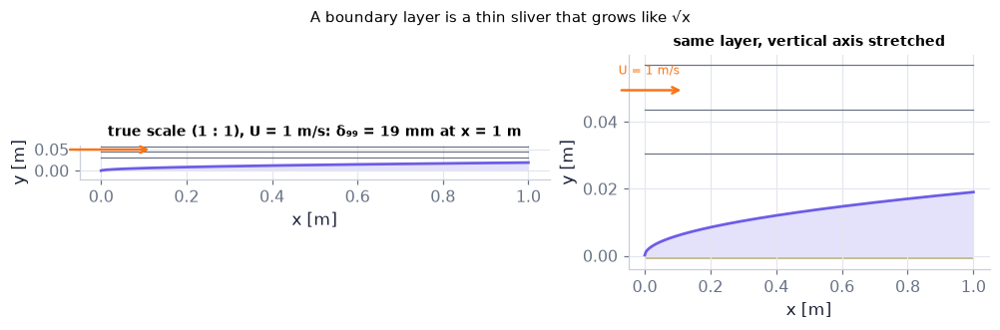

In [3]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 2.9), gridspec_kw=dict(width_ratios=[1.3, 1]))   # two views of the same plate
plate_layer(a1, U=1.0, nu=NU_AIR, L=1.0, exaggeration=1.0)      # (a) the layer on a 1 m plate ...
a1.set_aspect("equal"); a1.set_ylim(-0.02, 0.06)                # ... at true 1 : 1 scale: a thin sliver
for t_ in a1.texts:                                             # the "U = 1 m/s" label would sit on the streamlines of this flat panel: it moves to the title
    if t_.get_text().startswith("U ="):
        t_.set_visible(False)
a1.legend().remove()                                            # the drawing helper's legend would cover its own labels
a1.set_title("true scale (1 : 1), U = 1 m/s: δ₉₉ = 19 mm at x = 1 m", fontsize=9)   # what the reader sees
plate_layer(a2, U=1.0, nu=NU_AIR, L=1.0, exaggeration=1.0)      # (b) the same layer, vertical axis free (stretched)
a2.legend().remove()   # legend: one entry per curve
a2.set_title("same layer, vertical axis stretched", fontsize=9)  # say clearly that this one is stretched
fig.suptitle("A boundary layer is a thin sliver that grows like √x", fontsize=10)   # the message
plt.show()                                                      # display

**What you see.** A thin sliver along the plate in the left panel (barely visible at true scale) and a clearly growing wedge in the right panel, where the vertical axis is stretched (by about ten times relative to the horizontal one).

**How to read it.** The purple edge is the 99 % curve $\delta_{99}(x)$ (defined in C02); above it the streamlines are the ideal ones. Air at 1 m/s over 1 m gives $\delta_{99}=$ 19 mm at the trailing edge.

**What would change if…** …the plate were 4 m long: the layer at its end would be only $\sqrt4=2$ times thicker (38 mm), not 4 times — the thickness grows like $\sqrt x$.

> 📎 **Primer — six Reynolds numbers (which length?).** `P200` · The Reynolds number is a ratio of inertia to viscosity, but which length and speed? This chapter uses six flavours: the overall
$\mathrm{Re}=U_\infty L/\nu$ *(9.6)* (body length $L$), the local $\mathrm{Re}_x=Ux/\nu$ (distance from the leading edge), the plate's
$\mathrm{Re}_L=UL/\nu$, the jet's $\mathrm{Re}_x=xu_0/\nu$ and $\mathrm{Re}_{h_{99}}$, the cylinder and sphere $\mathrm{Re}=U_\infty d/\nu$ on the
**diameter**, and the Falkner–Skan $\mathrm{Re}_x=ax^{n+1}/\nu$. A statement "Re ≫ 1" is only meaningful with its length.

In [4]:
U, L, nu = 1.0, 1.0, 1.5e-5
print(U*L/nu)              # 66667: overall Re of a 1 m board at 1 m/s in air
print(U*0.1/nu)            # 6667: local Re_x at 10 cm from the leading edge (smaller: the layer is younger)
print(1.0*0.02/nu)         # 1333: a 2 cm cylinder in the same wind (diameter based)

66666.66666666667
6666.666666666667
1333.3333333333333


📝 **Note.** **N02 [B], N03 [B]** **Sizes of the two terms that compete** ($U=1$ m/s, $L=1$ m, $\nu=1.5\times10^{-5}$ m²/s). The advective term
$u\,\partial u/\partial x\sim U^2/L$ *(9.2)* equals 1 m/s². The viscous term $\nu\,\partial^2u/\partial y^2\sim\nu U/\bar\delta^2$ *(9.3)* equals 15 m/s² if the
layer is 1 mm thick and 0.15 m/s² if it is 1 cm: the layer thickness $\bar\delta$ is whatever makes them equal.

📝 **Note.** **N04 [B]** **Thickness estimate.** Setting $U^2/L\sim\nu U/\bar\delta^2$ gives $\bar\delta\sim\sqrt{\nu L/U}$, i.e. $\bar\delta/L\sim\mathrm{Re}^{-1/2}$ *(9.4)*.
It is the same square root as Ch. 8's $\sqrt{\nu t}$ with $t=L/U$: the fluid spends a time $L/U$ passing the board, and momentum diffuses a distance $\sqrt{\nu L/U}$ in that time
(the bridge to Ch. 8 §8.4). Air over 1 m at 1 m/s: 3.9 mm; water: 1.0 mm.

📝 **Note.** **N05 [B], N06 [B]** **Derivative sizes and $v$.** $\partial/\partial x\sim1/L$ and $\partial/\partial y\sim1/\bar\delta$ *(9.5)*; continuity $\partial u/\partial x+\partial v/\partial y=0$ *(6.2)* then says
$U/L\sim v/\bar\delta$, so $v\sim U\,\mathrm{Re}^{-1/2}$ — 3.9 mm/s, 250 times smaller than $u$.

#### 🧮 Derivation — Scaled equations $u^*u^*_{x^*}+v^*u^*_{y^*}=-p^*_{x^*}+\frac1{Re}u^*_{x^*x^*}+u^*_{y^*y^*}$, the layer equations and $\bar\delta/L\sim Re^{-1/2}$ `D01` (Eq. 9.7: $u^*\frac{\partial u^*}{\partial x^*}+v^*\frac{\partial u^*}{\partial y^*}=-\frac{\partial p^*}{\partial x^*}+\frac1{\mathrm{Re}}\frac{\partial^2u^*}{\partial x^{*2}}+\frac{\partial^2u^*}{\partial y^{*2}}$)

**What we want to show.** Show how thick a boundary layer is and which terms of the Navier–Stokes equations survive inside it when Re is large.

**Assumptions.** Re ≫ 1; δ̄ ≪ L; the surface radius of curvature ≫ δ̄ (Cartesian axes along the surface); steady flow; every starred quantity O(1) (step 4). Each is used where marked.

**The plan.**

1. Size the terms to find the thickness.
2. Introduce variables in which everything is of order one.
3. Substitute into all three equations.
4. Divide by the biggest term and read the powers of Re.
5. Drop what vanishes as Re → ∞.

**Tools we use** (each explained before this point): order-of-magnitude scaling (ch04 P130) · anisotropic scaling with two length scales (ch08 P188) · chain rule (ch01 P49) · dominant balance (ch08 P198) · six Reynolds numbers (primer P200) · sympy check (ch01 P40).

**We start from**

$$ \begin{array}{l}\text{The x-momentum equation (9.1)} \\ u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=-\frac1\rho\frac{\partial p}{\partial x}+\nu\big(\frac{\partial^2u}{\partial x^2}+\frac{\partial^2u}{\partial y^2}\big)\ \text{, continuity} \\ \text{(6.2)}\ \frac{\partial u}{\partial x}+\frac{\partial v}{\partial y}=0\ \text{and the y-momentum equation} \\ u\frac{\partial v}{\partial x}+v\frac{\partial v}{\partial y}=-\frac1\rho\frac{\partial p}{\partial y}+\nu\big(\frac{\partial^2v}{\partial x^2}+\frac{\partial^2v}{\partial y^2}\big)\ \text{(the book never} \\ \text{writes the last one; we do)}\end{array} $$

*In words:* steady plane flow along a thin layer.

---

**Step 1 of 14 — Size the derivatives.**

$$ \partial_x\sim\frac1L,\ \ \partial_y\sim\frac1{\bar\delta},\ \ u\sim U\ \text{(9.5)} $$

- *Why we can do this:* The flow changes over the body length L along the surface but over the thin layer δ̄ across it — the two-length picture of ch08 (8.14), $x^*=\frac xL,\ y^*=\frac yh=\frac{y}{\varepsilon L},\ t^*=\frac{Ut}{L},\ u^*=\frac uU,\ v^*=\frac{v}{\varepsilon U},\ p^*=\frac{p}{P_a}$; we write the sizes down so terms can be compared.
- *In words:* across the layer things change far faster than along it.

---

**Step 2 of 14 — Size v from continuity.**

$$ \frac UL\sim\frac v{\bar\delta}\ \Rightarrow\ v\sim\frac{\bar\delta}L\,U\ll U $$

- *Why we can do this:* Continuity (6.2), $\frac{\partial u}{\partial x}+\frac{\partial v}{\partial y}=0$ says $u_x=-v_y$, so the two terms have equal size; that fixes v once δ̄ is known (δ̄ ≪ L makes it small).
- *In words:* the cross-stream velocity is much smaller than the streamwise one.

---

**Step 3 of 14 — Balance advection against viscosity.**

$$ \frac{U^2}L\sim\frac{\nu U}{\bar\delta^2}\ \Rightarrow\ \frac{\bar\delta}L\sim Re^{-1/2}\ \text{(9.4)} $$

- *Why we can do this:* Dominant balance (P198): a layer exists where viscosity competes with advection, $uu_x\sim U^2/L$ (9.2) against $\nu u_{yy}\sim\nu U/\bar\delta^2$ (9.3); this equality *defines* δ̄.
- *In words:* at high Reynolds number the layer is thin.

---

**Step 4 of 14 — Introduce stretched variables.**

$$ x^*=\frac xL,\ y^*=\frac{\sqrt{Re}\,y}L,\ u^*=\frac uU,\ v^*=\frac{\sqrt{Re}\,v}U,\ p^*=\frac{p-p_\infty}{\rho U^2}\ \text{(9.6)} $$

- *Why we can do this:* Steps 1–3 make every starred quantity O(1). The pressure is scaled by ρU² because it must balance the advective size U²/L (contrast μU/δ̄ for slow flow, (8.42), $\mathrm{Re}\,(\mathbf u^*\cdot\nabla^*\mathbf u^*)=-\nabla^*p^*+\nabla^{*2}\mathbf u^*$).
- *In words:* each variable is measured in its natural unit.

---

**Step 5 of 14 — Convert the derivatives.**

$$ \partial_x=\frac1L\partial_{x^*},\ \ \partial_y=\frac{\sqrt{Re}}L\partial_{y^*},\ \ \partial_{yy}=\frac{Re}{L^2}\partial_{y^*y^*} $$

- *Why we can do this:* Chain rule (P49): $x^*=x/L$, $y^*=y\sqrt{Re}/L$, so each derivative gains the factor of its variable.
- *In words:* y-derivatives are magnified by √Re, and second ones by Re.

---

**Step 6 of 14 — Substitute into continuity.**

$$ \frac UL\Big(\frac{\partial u^*}{\partial x^*}+\frac{\partial v^*}{\partial y^*}\Big)=0\ \text{(8.15)} $$

- *Why we can do this:* $u_x=\frac UL u^*_{x^*}$ and $v_y=\frac U{\sqrt{Re}}\frac{\sqrt{Re}}Lv^*_{y^*}=\frac UL v^*_{y^*}$: the same factor, so no coefficient — the reason v was scaled by $Re^{-1/2}$.
- *In words:* continuity keeps its form.

---

**Step 7 of 14 — Substitute into (9.1): inertia, pressure.**

$$ \frac{U^2}L\big(u^*u^*_{x^*}+v^*u^*_{y^*}\big)=-\frac{U^2}Lp^*_{x^*}+\cdots $$

- *Why we can do this:* $vu_y=\frac U{\sqrt{Re}}\frac{U\sqrt{Re}}Lv^*u^*_{y^*}$ and $-\frac1\rho p_x=-\frac1\rho\frac{\rho U^2}Lp^*_{x^*}$: all three have the size U²/L.
- *In words:* three terms of one size.

---

**Step 8 of 14 — Substitute the viscous terms.**

$$ \nu u_{xx}+\nu u_{yy}=\frac{\nu U}{L^2}u^*_{x^*x^*}+\frac{\nu U\,Re}{L^2}u^*_{y^*y^*} $$

- *Why we can do this:* Step 5's chain-rule factors: the y-derivative carries an extra Re because y was stretched.
- *In words:* y-diffusion is Re times stronger than x-diffusion.

---

**Step 9 of 14 — Divide by U²/L, use ν = UL/Re.**

$$ u^*u^*_{x^*}+v^*u^*_{y^*}=-p^*_{x^*}+\frac1{Re}u^*_{x^*x^*}+u^*_{y^*y^*}\ \text{(9.7)} $$

- *Why we can do this:* $\frac{\nu U}{L^2}\big/\frac{U^2}L=\frac1{Re}$ and $\frac{\nu U Re}{L^2}\big/\frac{U^2}L=1$. The book prints the line with the denominators ∂x* and ∂y* and no squares, $\frac1{Re}\frac{\partial^2u^*}{\partial x^*}+\frac{\partial^2u^*}{\partial y^*}$; dimensionally the second derivatives need the squares, so the line above is the correct one.
- *In words:* only the x-diffusion term carries 1/Re.

---

**Step 10 of 14 — Substitute into y-momentum: inertia.**

$$ uv_x+vv_y=\frac{U^2}{L\sqrt{Re}}\big(u^*v^*_{x^*}+v^*v^*_{y^*}\big) $$

- *Why we can do this:* $v_x=\frac U{\sqrt{Re}\,L}v^*_{x^*}$ and $v_y=\frac ULv^*_{y^*}$ (step 6); multiplied by u = Uu* and v = Uv*/√Re each product has size U²/(L√Re).
- *In words:* inertia in y is √Re weaker than in x.

---

**Step 11 of 14 — Substitute pressure and viscous terms.**

$$ -\frac1\rho p_y=-\frac{U^2\sqrt{Re}}Lp^*_{y^*},\ \ \nu v_{xx}=\frac{U^2}{L\,Re^{3/2}}v^*_{x^*x^*},\ \ \nu v_{yy}=\frac{U^2}{L\sqrt{Re}}v^*_{y^*y^*} $$

- *Why we can do this:* $p_y=\rho U^2\frac{\sqrt{Re}}Lp^*_{y^*}$; ν = UL/Re turns the viscous terms into powers of Re.
- *In words:* the pressure term is the largest.

---

**Step 12 of 14 — Divide by $U^2\sqrt{Re}/L$.**

$$ \frac1{Re}\big(u^*v^*_{x^*}+v^*v^*_{y^*}\big)=-p^*_{y^*}+\frac1{Re^2}v^*_{x^*x^*}+\frac1{Re}v^*_{y^*y^*}\ \text{(9.8)} $$

- *Why we can do this:* Dividing by the largest term gives it coefficient 1 and every other term its power of 1/Re.
- *In words:* the pressure derivative stands alone at order one.

---

**Step 13 of 14 — Let Re → ∞ in (9.8).**

$$ \frac{\partial p^*}{\partial y^*}=0\ \Rightarrow\ \frac{\partial p}{\partial y}=0\ \text{(9.10)} $$

- *Why we can do this:* Every other term has a coefficient that vanishes as Re → ∞ while its starred factors stay O(1) (assumption of step 4).
- *In words:* the pressure does not change across the layer.

---

**Step 14 of 14 — Let Re → ∞ in (9.7), restore units.**

$$ u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=-\frac1\rho\frac{dp}{dx}+\nu\frac{\partial^2u}{\partial y^2}\ \text{(9.9)} $$

- *Why we can do this:* Drop the 1/Re x-diffusion term; the surviving $u^*_{y^*y^*}$ becomes $\nu u_{yy}$ because $\nu U\,Re/L^2=U^2/L$; p depends on x only by step 13.
- *In words:* streamwise diffusion is gone, cross-stream diffusion stays.

---

**Result**

$$ \begin{array}{l}\bar\delta/L\sim Re^{-1/2}\ \text{(9.4), and for Re ≫ 1 the layer obeys (6.2),}\ uu_x+vu_y=-\frac1\rho\frac{dp}{dx}+\nu u_{yy}\ \text{(9.9)} \\ \text{and}\ \partial p/\partial y=0\end{array} $$

*In words:* thin, with cross-stream friction and a pressure the outer flow imposes.

**What it means.** Everything in Ch. 9 solves (9.9), $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=-\frac1\rho\frac{dp}{dx}+\nu\frac{\partial^2u}{\partial y^2}$ with (9.11), $-\frac1\rho\frac{dp}{dx}=U_e\frac{dU_e}{dx}$. It fails when Re_x ≲ 1 (leading edge), when δ is not small against the radius of curvature, and after separation.

**Check it.** Units: $\nu U/\bar\delta^2$ = (m²/s)(m/s)/m² = m/s² = U²/L ✓. Air, U = 1 m/s, L = 1 m, ν = 1.5 × 10⁻⁵ m²/s: Re = 6.67 × 10⁴, δ̄/L = 3.87 × 10⁻³, dropped/kept diffusion = 1/Re = 1.5 × 10⁻⁵ ✓. `ch09.bl_nondim_sympy()` returns the coefficient table of steps 9 and 12; the printed (9.7) fails its dimension check.

> ⚠️ **Common confusion (traps in `D01`):** Taking the printed line $\frac1{Re}\frac{\partial^2u^*}{\partial x^*}+\frac{\partial^2u^*}{\partial y^*}$ of (9.7), $u^*\frac{\partial u^*}{\partial x^*}+v^*\frac{\partial u^*}{\partial y^*}=-\frac{\partial p^*}{\partial x^*}+\frac1{\mathrm{Re}}\frac{\partial^2u^*}{\partial x^{*2}}+\frac{\partial^2u^*}{\partial y^{*2}}$ at face value (missing squares); dropping 1/Re terms without checking that their factors are O(1); scaling p with μU/δ̄ (the viscous scale of Ch. 8) instead of ρU²; forgetting that the y-equation exists at all.

📝 **Note.** **N07 [B]** **The stretched variables** $x^*=\frac xL,\ y^*=\frac yL\mathrm{Re}^{1/2},\ u^*=\frac uU,\ v^*=\frac vU\mathrm{Re}^{1/2},\ p^*=\frac{p-p_\infty}{\rho U^2}$ *(9.6)* are
the $\varepsilon=\mathrm{Re}^{-1/2}$ of Ch. 8's *(8.14)*, $x^*=\frac xL,\ y^*=\frac yh=\frac{y}{\varepsilon L},\ t^*=\frac{Ut}{L},\ u^*=\frac uU,\ v^*=\frac{v}{\varepsilon U},\ p^*=\frac{p}{P_a}$, with one difference: the pressure is scaled by $\rho U^2$ (the advective size) rather than by $\mu U/h$ (the viscous size that
gave the lubrication and Stokes limits, *(8.42)*, $\mathrm{Re}\,(\mathbf u^*\cdot\nabla^*\mathbf u^*)=-\nabla^*p^*+\nabla^{*2}\mathbf u^*$).

📝 **Note.** **N08 [B], N09 [B]** **The scaled equations.** *(9.7)* is $u^*\frac{\partial u^*}{\partial x^*}+v^*\frac{\partial u^*}{\partial y^*}=-\frac{\partial p^*}{\partial x^*}+\frac1{\mathrm{Re}}\frac{\partial^2u^*}{\partial x^{*2}}+\frac{\partial^2u^*}{\partial y^{*2}}$
and *(9.8)*, $\frac1{\mathrm{Re}}\Big(u^*\frac{\partial v^*}{\partial x^*}+v^*\frac{\partial v^*}{\partial y^*}\Big)=-\frac{\partial p^*}{\partial y^*}+\frac1{\mathrm{Re}^2}\frac{\partial^2v^*}{\partial x^{*2}}+\frac1{\mathrm{Re}}\frac{\partial^2v^*}{\partial y^{*2}}$ is $\frac1{\mathrm{Re}}\big(u^*\frac{\partial v^*}{\partial x^*}+v^*\frac{\partial v^*}{\partial y^*}\big)=-\frac{\partial p^*}{\partial y^*}+\frac1{\mathrm{Re}^2}\frac{\partial^2v^*}{\partial x^{*2}}+\frac1{\mathrm{Re}}\frac{\partial^2v^*}{\partial y^{*2}}$.
The second-derivative term in $y$ keeps coefficient 1 — the difference from *(4.101)*, $\Big[\frac{\Omega l}{U}\Big]\frac{\partial\mathbf u^*}{\partial t^*}+(\mathbf u^*\cdot\nabla^*)\mathbf u^*=-\nabla^*p^*+\Big[\frac{gl}{U^2}\Big]\mathbf g^*+\Big[\frac{\mu}{\rho Ul}\Big]\nabla^{*2}\mathbf u^*$ and *(8.42)*, $\mathrm{Re}\,(\mathbf u^*\cdot\nabla^*\mathbf u^*)=-\nabla^*p^*+\nabla^{*2}\mathbf u^*$, where the two directions were scaled alike.

> ⚠️ **The book prints (9.7) with the denominators $\partial x^*$ and $\partial y^*$ (no squares):**
> $$\text{printed:}\quad \frac1{\mathrm{Re}}\frac{\partial^2u^*}{\partial x^*}+\frac{\partial^2u^*}{\partial y^*}\qquad\text{correct:}\quad\frac1{\mathrm{Re}}\frac{\partial^2u^*}{\partial x^{*2}}+\frac{\partial^2u^*}{\partial y^{*2}}$$
> A second derivative has two powers of length in its denominator; by D01 step 9 (and by the sympy engine below, which rejects the printed form) the squares belong there.

#### ✏️ Tiny example: air over a 1 m board at 1 m/s

1. $\mathrm{Re}=UL/\nu=1\times1/1.5\times10^{-5}=6.67\times10^4$.
2. $\bar\delta/L\sim\mathrm{Re}^{-1/2}=1/258=3.87\times10^{-3}$, so $\bar\delta\approx3.9$ mm.
3. $v\sim U\,\mathrm{Re}^{-1/2}=3.9$ mm/s.
4. The dropped $x$-diffusion term is $\nu U/L^2=1.5\times10^{-5}$ m/s² against the kept $\nu U/\bar\delta^2=1.0$ m/s²: ratio $1/\mathrm{Re}=1.5\times10^{-5}$.
5. A crude wall stress $\tau_0\sim\mu U/\bar\delta=1.8\times10^{-5}\times1/3.87\times10^{-3}=4.6\times10^{-3}$ Pa and $C_f\sim2/\sqrt{\mathrm{Re}}=7.7\times10^{-3}$ (Blasius will give 0.664/√Re, a factor 3 smaller).

In [5]:
sc = BL.boundary_layer_scales(U=1.0, L=1.0, nu=NU_AIR, rho=RHO_AIR)   # sizes (9.2)-(9.4) for air, 1 m/s, 1 m
for k, v in sc.items():                                        # print each named result with 4 significant figures
    print(f"{k:14s} {float(v):.4g}")                            # Re [-], δ/L [-], δ [m], v [m/s], τ0 [Pa], Cf [-], adv, visc, visc_x [m/s²]

Re             6.667e+04
delta_over_L   0.003873
delta          0.003873
v_scale        0.003873
adv            1
visc           1
visc_x         1.5e-05
tau0_scale     0.004648
cf_estimate    0.007746


**What does the code above do?**

1. `boundary_layer_scales` evaluates the sizes $u\,\partial u/\partial x\sim U^2/L$ *(9.2)*, $\nu\,\partial^2u/\partial y^2\sim\nu U/\bar\delta^2$ *(9.3)* and $\bar\delta/L\sim\mathrm{Re}^{-1/2}$ *(9.4)* for the given speed, length and viscosity.
2. `adv` ≈ `visc` (both 1 m/s²) is the *definition* of $\bar\delta$ — the two terms are equal by construction.
3. `visc_x` is the term $\nu\,\partial^2u/\partial x^2\sim\nu U/L^2$ that *(9.7)*, $u^*\frac{\partial u^*}{\partial x^*}+v^*\frac{\partial u^*}{\partial y^*}=-\frac{\partial p^*}{\partial x^*}+\frac1{\mathrm{Re}}\frac{\partial^2u^*}{\partial x^{*2}}+\frac{\partial^2u^*}{\partial y^{*2}}$ drops: $1.5\times10^{-5}$ m/s², a hundred-thousandth of the kept term.

In [6]:
res = ch09.bl_nondim_sympy()                                   # D01 by machine: substitute (9.6) into (9.1), the y-equation and (6.2)
print(res["coefficients"])                                     # powers of Re in front of each term after dividing by the largest
print(res["limit"]["x_momentum"])                              # Re -> infinity, x-momentum: this is (9.9) in scaled form
print(res["limit"]["y_momentum"])                              # Re -> infinity, y-momentum: this is (9.10) in scaled form
bad = ch09.bl_nondim_sympy(printed_9_7=True)                   # the same with the book's printed (9.7), no squares
print(bad["dimension_check"]["message"])                       # the printed form fails the dimension check

{'u*du*/dx*': 0, 'v*du*/dy*': 0, 'dp*/dx*': 0, 'd2u*/dx*2': -1, 'd2u*/dy*2': 0, 'u*dv*/dx*': -1, 'v*dv*/dy*': -1, 'dp*/dy*': 0, 'd2v*/dx*2': -2, 'd2v*/dy*2': -1, 'continuity': 0}
Eq(us(xs, ys)*Derivative(us(xs, ys), xs) + vs(xs, ys)*Derivative(us(xs, ys), ys), -Derivative(ps(xs, ys), xs) + Derivative(us(xs, ys), (ys, 2)))
Eq(0, -Derivative(ps(xs, ys), ys))


second derivative not dimensionless: ν ∂²u/∂x with a first-order denominator has dimension L²/T², not L/T² (slip R1)


**What does the code above do?**

1. `coefficients` lists the power of Re in front of each term: $\partial^2u^*/\partial x^{*2}\to-1$ (i.e. $1/\mathrm{Re}$), $\partial^2u^*/\partial y^{*2}\to0$ (order one),
   the $y$-momentum inertia $\to-1$, its pressure term $\to0$, $\partial^2v^*/\partial x^{*2}\to-2$, $\partial^2v^*/\partial y^{*2}\to-1$, continuity $\to0$ — the same table as D01 steps 9 and 12.
2. `limit` keeps only the terms whose coefficient does not vanish as $\mathrm{Re}\to\infty$: *(9.9)*, $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=-\frac1\rho\frac{dp}{dx}+\nu\frac{\partial^2u}{\partial y^2}$ and *(9.10)*, $\frac{\partial p}{\partial y}=0$ in starred form.
3. The printed *(9.7)* (no squares) fails: the engine repeats the derivation with the printed line and reports that the second derivative is not dimensionless.

📝 **Note.** **N10 [B]** **$\partial p/\partial y=0$ (9.10).** Pressure is uniform across the layer, so the wall pressure is the edge pressure, which the outer ideal flow supplies — the experimental fact behind
"the surface pressure of an attached layer equals ideal-flow theory". It fails at separation and where the surface curves as sharply as the layer is thick; everywhere else $\frac{\partial p}{\partial y}=0$ *(9.10)* holds.
To measure it we move the pressure term of *(9.8)*, $\frac1{\mathrm{Re}}\Big(u^*\frac{\partial v^*}{\partial x^*}+v^*\frac{\partial v^*}{\partial y^*}\Big)=-\frac{\partial p^*}{\partial y^*}+\frac1{\mathrm{Re}^2}\frac{\partial^2v^*}{\partial x^{*2}}+\frac1{\mathrm{Re}}\frac{\partial^2v^*}{\partial y^{*2}}$ to the left, keeping every sign:
$$\frac{\partial p^*}{\partial y^*}=-\frac1{\mathrm{Re}}\Big(u^*\frac{\partial v^*}{\partial x^*}+v^*\frac{\partial v^*}{\partial y^*}\Big)+\frac1{\mathrm{Re}^2}\frac{\partial^2v^*}{\partial x^{*2}}+\frac1{\mathrm{Re}}\frac{\partial^2v^*}{\partial y^{*2}}$$
(`BL.bl_dpdy_scaled`). Every term carries at least one factor $1/\mathrm{Re}$, so $\partial p^*/\partial y^*\to0$ as $\mathrm{Re}\to\infty$.
The next cell measures how small the cross-stream pressure change really is on a Blasius field.

$$ \frac{\partial p}{\partial y}=0 \qquad \text{(9.10)} $$

In [7]:
# tiny example of (9.8) solved for dp*/dy*: easy starred values, Re = 100
print(BL.bl_dpdy_scaled(u=1.0, v=0.5, v_x=0.2, v_y=0.4, v_xx=1.0, v_yy=2.0, Re=100.0))   # -(0.2+0.2)/100 + 1/1e4 + 2/100 = 0.0161 [-]
Res = (1e3, 1e4, 1e5, 1e6)                                       # overall Reynolds numbers U L / nu [-]
pv = {Re: BL.bl_pressure_variation(Re, n_x=21, n_y=61) for Re in Res}            # cross-stream pressure change relative to advection on a Blasius field
ratios = np.array([pv[Re]["ratio"] for Re in Res])               # max|dp*/dy*| / max|dp*/dx*|-type ratio [-]: should fall with Re
for Re, r_ in zip(Res, ratios):                                  # print the table
    print(f"Re = {Re:8.0e}   cross-stream pressure term / advection = {r_:.3e}")   # print the result
slope = observed_order(np.array(Res), ratios)                    # log-log slope of ratio against Re (P13): about -1
print("log-log slope:", round(float(slope), 2))   # print the result
assert ratios[-1] < 1e-2 and np.all(np.diff(ratios) < 0)         # small at Re = 1e6 and falling monotonically

0.0161


Re =    1e+03   cross-stream pressure term / advection = 7.643e-03
Re =    1e+04   cross-stream pressure term / advection = 7.602e-04
Re =    1e+05   cross-stream pressure term / advection = 7.597e-05
Re =    1e+06   cross-stream pressure term / advection = 7.597e-06
log-log slope: -1.0


**What does the code above do?**

1. The first line is the tiny example: $-(1\cdot0.2+0.5\cdot0.4)/100+1/100^2+2/100=-0.004+0.0001+0.02=0.0161$ — the formula above with easy numbers.
2. `bl_pressure_variation(Re)` evaluates $\partial p^*/\partial y^*$ from *(9.8)*, $\frac1{\mathrm{Re}}\Big(u^*\frac{\partial v^*}{\partial x^*}+v^*\frac{\partial v^*}{\partial y^*}\Big)=-\frac{\partial p^*}{\partial y^*}+\frac1{\mathrm{Re}^2}\frac{\partial^2v^*}{\partial x^{*2}}+\frac1{\mathrm{Re}}\frac{\partial^2v^*}{\partial y^{*2}}$ solved as above, $-\frac1{\mathrm{Re}}(u^*v^*_{x^*}+v^*v^*_{y^*})+\frac1{\mathrm{Re}^2}v^*_{x^*x^*}+\frac1{\mathrm{Re}}v^*_{y^*y^*}$, on a Blasius field at that Reynolds number.
3. The ratio to the advective term falls roughly like $1/\mathrm{Re}$ (slope near $-1$ on log–log axes): the larger Re, the truer $\partial p/\partial y=0$.
4. `observed_order(x, y)` (from Ch. 8, where it measured a scheme's order) is simply the slope of $\log y$ against $\log x$ (Ch. 1 P13): here $-1.0$, i.e. ratio $\propto1/\mathrm{Re}$.
5. The `assert` only checks the two facts the text claims: small at $10^6$ and monotone in Re.

📝 **Note.** **N11 [B]** **Matching to the outer flow.** The pressure gradient inside the layer comes from Bernoulli's equation applied to the outer flow,
$-\frac1\rho\frac{dp}{dx}=U_e\frac{dU_e}{dx}$ *(9.11)*; the outer speed $U_e(x)$ is the only forcing of every layer in this chapter. A decelerating outer
flow ($dU_e/dx<0$) means $dp/dx>0$: **adverse**.

$$ -\frac1\rho\frac{dp}{dx}=U_e\frac{dU_e}{dx} \qquad \text{(9.11)} $$

#### 🧮 Derivation — The pressure from the outer flow: $-\frac1\rho\frac{dp}{dx}=U_e\frac{dU_e}{dx}$ `D02` (Eq. 9.11: $-\frac1\rho\frac{dp}{dx}=U_e\frac{dU_e}{dx}$)

**What we want to show.** Get the pressure gradient inside the layer from the ideal outer flow, so the layer equations have no unknown pressure.

**Assumptions.** Steady, incompressible, irrotational outer flow (used in step 1); (9.10), $\frac{\partial p}{\partial y}=0$ for the constancy across the layer (step 2).

**The plan.**

1. Differentiate Bernoulli along the edge.
2. Carry the pressure through the layer with (9.10), $\frac{\partial p}{\partial y}=0$.
3. Insert it into (9.9), $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=-\frac1\rho\frac{dp}{dx}+\nu\frac{\partial^2u}{\partial y^2}$.

**Tools we use** (each explained before this point): Bernoulli's equation (Ch. 4 §4.9) · chain rule (ch01 P49).

**We start from**

$$ \begin{array}{l}\text{Bernoulli's equation along a streamline of the irrotational outer flow} \\ p+\frac12\rho U_e^2=\text{const}\ \text{(Ch. 4 §4.9) and (9.10)}\ \frac{\partial p}{\partial y}=0\end{array} $$

*In words:* outside the layer the flow is ideal; inside, the pressure is the same as at the edge.

---

**Step 1 of 5 — Write Bernoulli at the layer's edge.**

$$ p_e(x)+\tfrac12\rho\,U_e^2(x)=\text{const} $$

- *Why we can do this:* Just above the layer the flow is steady, irrotational and inviscid (Prandtl's picture), so Bernoulli holds along the edge streamline.
- *In words:* where the outer flow speeds up, the pressure falls.

---

**Step 2 of 5 — Differentiate along x.**

$$ \frac{dp_e}{dx}+\rho\,U_e\frac{dU_e}{dx}=0 $$

- *Why we can do this:* The derivative of a constant is zero; the chain rule (P49) gives $\frac d{dx}\big(\tfrac12U_e^2\big)=U_eU_e'$.
- *In words:* the pressure gradient is minus ρ U_e U_e′.

---

**Step 3 of 5 — Rearrange.**

$$ -\frac1\rho\frac{dp_e}{dx}=U_e\frac{dU_e}{dx}\ \text{(9.11)} $$

- *Why we can do this:* Divide by −ρ; nothing else changes.
- *In words:* an accelerating outer flow (U_e′ > 0) has a falling pressure — favourable.

---

**Step 4 of 5 — Carry the pressure across the layer.**

$$ p(x,y)=p_e(x)\ \Rightarrow\ \frac{\partial p}{\partial x}=\frac{dp_e}{dx} $$

- *Why we can do this:* (9.10), $\frac{\partial p}{\partial y}=0$ says p does not depend on y inside the layer, so it equals its edge value.
- *In words:* the wall feels the edge pressure.

---

**Step 5 of 5 — Insert into (9.9).**

$$ u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=U_e\frac{dU_e}{dx}+\nu\frac{\partial^2u}{\partial y^2}\ \text{(9.37, with τ = μ∂u/∂y)} $$

- *Why we can do this:* Replace $-\frac1\rho\frac{dp}{dx}$ by step 3; this is the form every later section uses.
- *In words:* the outer speed is the only forcing.

---

**Result**

$$ -\frac1\rho\frac{dp}{dx}=U_eU_e' $$

*In words:* the layer is driven only by the outer flow's speed distribution.

**What it means.** Decelerating outer flow (U_e′ < 0) means dp/dx > 0: adverse — the seed of separation (C08).

**Check it.** Units (m²/s²)/m = m/s² ✓. U_e = 10x s⁻¹ (n = 1, a = 10): at x = 0.1 m U_e = 1 m/s, U_e′ = 10 s⁻¹, dp/dx = −1.2 × 1 × 10 = −12 Pa/m (favourable) ✓ (`outer_flow("wedge", n=1, a=10)`).

> ⚠️ **Common confusion (traps in `D02`):** Applying Bernoulli *inside* the layer (it does not hold there: viscous forces act); the sign of dp/dx for a decelerating flow.

In [8]:
of = BL.outer_flow("wedge", n=1.0, a=10.0)                       # outer flow U_e = a x^n with n = 1, a = 10 1/s: flow toward a wall
print(of.Ue(0.1), of.dUe(0.1), of.dpdx(0.1, rho=RHO_AIR))       # U_e [m/s], dU_e/dx [1/s], dp/dx [Pa/m] at x = 0.1 m: 1, 10, -12

1.0 10.0 -12.0


**What does the code above do?**

1. `outer_flow("wedge", n, a)` builds $U_e=ax^n$ with its derivative; `.dpdx(x, rho)` applies *(9.11)*: $dp/dx=-\rho U_eU_e'$.
2. At $x=0.1$ m: $U_e=1$ m/s, $U_e'=10$ s⁻¹, so $dp/dx=-1.2\times1\times10=-12$ Pa/m — negative, hence favourable.

📝 **Note.** **N12 [B], N13 [B]** **Conditions on the layer.** Matching to the outer flow, $u(x,y\to\infty)=U_e(x)$ *(9.14)* (where "$y\to\infty$" means $y\gg\delta$), and an inlet profile
$u(x_0,y)=u_{in}(y)$ *(9.15)* at some $x_0$ — needed because *(9.9)*, $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=-\frac1\rho\frac{dp}{dx}+\nu\frac{\partial^2u}{\partial y^2}$ is parabolic. The wall conditions are the recaps after this block.

> 📎 **Primer — parabolic, elliptic and marching in x.** `P201` · A PDE is *elliptic* if conditions all round the domain are needed (full Navier–Stokes: what happens downstream affects what happens upstream);
*parabolic* if it has a time-like direction and a start (the heat equation, and *(9.9)* $u\frac{\partial u}{\partial x}=\nu\frac{\partial^2u}{\partial y^2}+\dots$ with $x$ in the role of time).
A parabolic problem is solved by *marching* from an inlet profile, one $x$-step at a time — information only flows downstream.

In [9]:
import numpy as np   # arrays and maths
u = np.zeros(7); u[3] = 1.0           # a spike at the middle node of seven
for step in range(3):                  # march the heat equation 'in time' (or in x)
    u[1:-1] += 0.25*(u[:-2] - 2*u[1:-1] + u[2:])
    print(u)                           # the spike spreads outwards and flattens; nothing comes back

[0.   0.   0.25 0.5  0.25 0.   0.  ]
[0.     0.0625 0.25   0.375  0.25   0.0625 0.    ]
[0.     0.0938 0.2344 0.3125 0.2344 0.0938 0.    ]


📝 **Note.** **N14 [B]** **Parabolic character.** In *(9.9)* the pair $u\,\partial u/\partial x$ and $\nu\,\partial^2u/\partial y^2$ makes $x$ a time and $y$ a space: like Stokes' first problem (Ch. 8)
the layer at $x$ is determined by the layers upstream and the outer pressure, never by anything downstream. This is why we can march (and why marching stops at separation — C08).

$$ u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=-\frac1\rho\frac{dp}{dx}+\nu\frac{\partial^2u}{\partial y^2} \qquad \text{(9.9)} $$

In [10]:
nx = 60 if not FAST else 30                                      # number of stations along the plate (FAST: fewer)
ny = 400 if not FAST else 200                                    # nodes across the layer (FAST: fewer)
x = np.linspace(0.02, 1.0, nx)                                   # stations [m], starting 2 cm behind the leading edge
yin = np.linspace(0, 12*4.91*np.sqrt(NU_AIR*x[0]), 200)          # heights of the inlet samples [m]
inlet = BL.blasius_fields(x[0], yin, 1.0, NU_AIR)                # the exact Blasius profile at x[0] [m/s]
march = BL.march_boundary_layer(BL.outer_flow("flat", U=1.0).Ue, x, NU_AIR, u_inlet=(yin, inlet["u"]),
                                ny=ny, rho=RHO_AIR)              # march (9.9) downstream from that inlet profile; tau0 in Pa
tau_exact = BL.blasius_wall_shear(x, 1.0, RHO_AIR, NU_AIR)       # exact similarity wall stress [Pa] (C03-C04 derive it)
tau_march = march["tau0"]                                        # marched wall stress [Pa]
rel = np.abs(tau_march/tau_exact - 1)                            # relative difference at every station [-]
print(f"largest relative difference for x >= 0.1 m: {rel[x >= 0.1].max():.2e}")   # expect below 1e-3

largest relative difference for x >= 0.1 m: 1.47e-03


**What does the code above do?**

1. The inlet profile at $x_0=2$ cm is the exact Blasius profile (the similarity solution of C03–C04), sampled on 200 heights.
2. `march_boundary_layer` steps *(9.9)*, $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=-\frac1\rho\frac{dp}{dx}+\nu\frac{\partial^2u}{\partial y^2}$ downstream in the **von Mises variables** $(x,\psi)$ — instead of the height $y$ it uses the stream function $\psi$ (the flow rate between the wall and a point, $u=\partial\psi/\partial y$) as the cross-stream coordinate, which removes $v$ from the equation and makes the grid follow the streamlines — with backward Euler in $x$ and central differences across, and stops if the wall shear reaches zero.
3. Its wall shear agrees with the exact similarity solution to about $1.5\times10^{-3}$ (0.15 %) for $x\ge0.1$ m: the parabolic marching works, and the exact solution is the test it passes.

In [11]:
# from scratch: the terms of (9.1) on a Blasius field, by np.gradient (second order), at three Reynolds numbers
for Re_L in (6.7e3, 6.7e4, 6.7e5):                                # overall Re = U L / nu with L = 1 m
    U = Re_L*NU_AIR                                               # free-stream speed [m/s]
    xs = np.linspace(0.5, 1.0, 200)                               # stations [m]
    dl = 4.91*np.sqrt(NU_AIR*xs[-1]/U)                            # delta_99 at the last station [m]
    ys = np.linspace(0, 3*dl, 120)                                # heights [m]
    fld = BL.blasius_fields(xs[None, :], ys[:, None], U, NU_AIR)  # u, v on the (y, x) grid [m/s]
    u_, v_ = fld["u"], fld["v"]
    ux = np.gradient(u_, xs, axis=1, edge_order=2)                # du/dx [1/s]
    uy = np.gradient(u_, ys, axis=0, edge_order=2)                # du/dy [1/s]
    uyy = np.gradient(uy, ys, axis=0, edge_order=2)               # d2u/dy2 [1/(m s)]
    uxx = np.gradient(ux, xs, axis=1, edge_order=2)               # d2u/dx2 [1/(m s)]
    adv = np.abs(u_*ux + v_*uy)[2:-2, 2:-2].max()                 # advective term u u_x + v u_y [m/s^2]
    kept = np.abs(NU_AIR*uyy)[2:-2, 2:-2].max()                   # kept viscous term nu u_yy [m/s^2]
    drop = np.abs(NU_AIR*uxx)[2:-2, 2:-2].max()                   # dropped viscous term nu u_xx [m/s^2]
    res_ = BL.bl_x_momentum_residual(xs, ys, u_, v_, 0.0, NU_AIR, RHO_AIR)   # residual of (9.9) with dp/dx = 0
    assert np.abs(res_)[2:-2, 2:-2].max() < 1e-2*adv              # the similarity solution satisfies (9.9)
    Rex = U*xs[-1]/NU_AIR                                         # local Reynolds number at the last station
    print(f"Re_L = {Re_L:8.1e}: kept/advective = {kept/adv:5.2f}, dropped/kept = {drop/kept:.2e} = {drop/kept*Rex:4.2f}/Re_x")   # print the result
    assert 0.1 < drop/kept*Rex < 10                                # the dropped term is of order 1/Re_x times the kept one

Re_L =  6.7e+03: kept/advective =  0.99, dropped/kept = 8.44e-04 = 5.66/Re_x


Re_L =  6.7e+04: kept/advective =  0.99, dropped/kept = 8.44e-05 = 5.66/Re_x


Re_L =  6.7e+05: kept/advective =  0.99, dropped/kept = 8.44e-06 = 5.66/Re_x


**What does the code above do?**

1. For three Reynolds numbers the exact Blasius $u,v$ are sampled on a $(y,x)$ grid (broadcasting `xs[None, :]`, `ys[:, None]`), three $\delta_{99}$ deep.
2. `np.gradient` (second order, P21–P22) builds $u_x$, $u_y$, $u_{yy}$ and $u_{xx}$ by finite differences; the largest sizes of the advective term, the kept viscous term $\nu u_{yy}$ and the dropped one $\nu u_{xx}$ are taken away from the grid edges.
3. The first assert checks that the similarity field satisfies the layer equation (9.9), $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=-\frac1\rho\frac{dp}{dx}+\nu\frac{\partial^2u}{\partial y^2}$ (`bl_x_momentum_residual`, below 1 % of advection).
4. The printout shows kept/advective of order one, and the second assert checks that dropped/kept is of order $1/\mathrm{Re}_x$ — the scaling of D01 measured, not assumed.

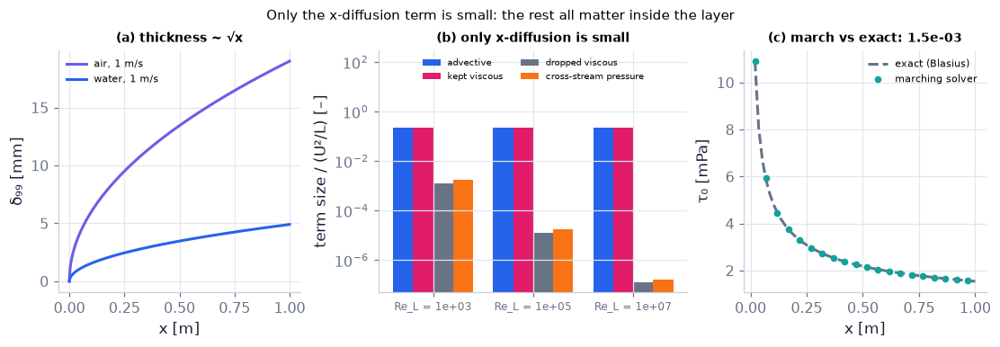

In [12]:
Res3 = (1e3, 1e5, 1e7)                                            # overall Reynolds numbers of the three bar groups
bars = {"advective": [], "kept viscous": [], "dropped viscous": [], "cross-stream pressure": []}   # sizes relative to U^2/L
for Re_L in Res3:                                                 # same construction as the from-scratch cell
    U = Re_L*NU_AIR
    xs = np.linspace(0.5, 1.0, 120)   # sample points
    ys = np.linspace(0, 3*4.91*np.sqrt(NU_AIR*1.0/U), 100)   # sample points
    fld = BL.blasius_fields(xs[None, :], ys[:, None], U, NU_AIR)
    u_, v_ = fld["u"], fld["v"]
    ux = np.gradient(u_, xs, axis=1, edge_order=2); uy = np.gradient(u_, ys, axis=0, edge_order=2)   # central differences (second order, also at the ends)
    uyy = np.gradient(uy, ys, axis=0, edge_order=2); uxx = np.gradient(ux, xs, axis=1, edge_order=2)   # central differences (second order, also at the ends)
    adv = np.abs(u_*ux + v_*uy)[2:-2, 2:-2].max()
    bars["advective"].append(adv/(U**2))                          # U^2/L with L = 1 m
    bars["kept viscous"].append(np.abs(NU_AIR*uyy)[2:-2, 2:-2].max()/(U**2))   # store the value for the plot
    bars["dropped viscous"].append(np.abs(NU_AIR*uxx)[2:-2, 2:-2].max()/(U**2))   # store the value for the plot
    bars["cross-stream pressure"].append(BL.bl_pressure_variation(Re_L, n_x=21, n_y=61)["ratio"]*adv/(U**2))   # store the value for the plot
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(10, 3.4), gridspec_kw=dict(width_ratios=[1.1, 1.4, 1.1]))   # the figure and its panels
xx = np.linspace(0.0, 1.0, 300)                                   # (a) the layer thickness against x
a1.plot(xx, 1e3*BL.blasius_delta99(xx, 1.0, NU_AIR), color=COLORS["accent"], label="air, 1 m/s")   # delta_99(x) in mm
a1.plot(xx, 1e3*BL.blasius_delta99(xx, 1.0, NU_W), color=COLORS["blue"], label="water, 1 m/s")   # draw the curve(s)
a1.set_xlabel("x [m]"); a1.set_ylabel("δ₉₉ [mm]"); a1.legend(fontsize=7, frameon=False); a1.set_title("(a) thickness ~ √x", fontsize=9)   # axis labels (with units), limits and the panel's message
w = 0.2; cols = [COLORS["blue"], COLORS["rose"], COLORS["muted"], COLORS["orange"]]   # colours by meaning
for j, (k, v) in enumerate(bars.items()):                         # (b) grouped bars, log axis
    a2.bar(np.arange(3) + (j - 1.5)*w, v, w, label=k, color=cols[j])   # bars
a2.set_yscale("log"); a2.set_xticks(range(3)); a2.set_xticklabels([f"Re_L = {r:.0e}" for r in Res3], fontsize=8)   # axis labels (with units), limits and the panel's message
a2.set_ylabel("term size / (U²/L) [–]"); a2.set_ylim(5e-8, 3e2); a2.legend(fontsize=6.5, frameon=False, loc="upper center", ncol=2); a2.set_title("(b) only x-diffusion is small", fontsize=9)   # axis labels (with units), limits and the panel's message
a3.plot(x, tau_exact*1e3, "--", color=COLORS["muted"], label="exact (Blasius)")   # (c) marched wall stress vs the exact one
a3.plot(x[::3], tau_march[::3]*1e3, "o", color=COLORS["teal"], ms=4, label="marching solver")   # draw the curve(s)
a3.set_xlabel("x [m]"); a3.set_ylabel("τ₀ [mPa]"); a3.legend(fontsize=7, frameon=False); a3.set_title(f"(c) march vs exact: {rel[x >= 0.1].max():.1e}", fontsize=9)   # axis labels (with units), limits and the panel's message
fig.suptitle("Only the x-diffusion term is small: the rest all matter inside the layer", fontsize=10)   # the figure's message as its title
plt.show()   # display the figure

**What you see.** In (b) three bar groups where the grey 'dropped' bar shrinks about a hundredfold for every hundredfold in $\mathrm{Re}$ while the blue and rose bars (advective and kept viscous) stay equal; in (c) the marching dots sit on the exact line.

**How to read it.** Advective $\approx$ viscous in every group: that is the *definition* of $\bar\delta$; the dropped/kept ratio falls like $1/\mathrm{Re}$; the orange cross-stream pressure bar is of the same small order as the grey dropped x-diffusion bar (both fall like $1/\mathrm{Re}$, about $10^{-3}$ of $U^2/L$ at $\mathrm{Re}_L=10^3$), which is why $\partial p/\partial y=0$ *(9.10)* is safe.

**What would change if…** …Re were 10 (a short board in oil): all four bars would be comparable — the layer is no longer thin and *(9.9)*, $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=-\frac1\rho\frac{dp}{dx}+\nu\frac{\partial^2u}{\partial y^2}$ fails (see N17 below).

📝 **Note.** **N16 [B]** **A crude wall stress.** $\tau_0\sim\mu U/\bar\delta$ gives $C_f=\tau_0/(\frac12\rho U^2)\sim2/\sqrt{\mathrm{Re}}$: the order and the Re-dependence are right; Blasius' exact 0.664 (C04) is a factor 3 smaller.

*↪ **N15 [C]** The two-step viscous–inviscid procedure (ideal flow ⇒ pressure ⇒ layer ⇒ displaced body ⇒ repeat) is used in C02 (the displacement correction $\delta^*$) and in Chs. 10 and 14.  **N17 [C]** Where the approximation fails: near the leading edge ($\mathrm{Re}_x\lesssim1$), where $\delta/R$ is not small, and after separation — shown in C04 (leading-edge $\tau_0\propto x^{-1/2}$) and C08.*

**What would change if…** …we asked for the drag? We need the wall stress, which needs the profile, not only its thickness. C02 defines what "thickness" means when the profile fades smoothly; C03 solves
the equations for the simplest outer flow, a constant one.

> 🔁 **Recap — No slip** (Ch. 4 §4.10, Ch. 8 §8.2). $u(x,0)=0$ *(9.12)*: the fluid sticks to a solid wall (Ch. 4 §4.10, Ch. 8 §8.2) — the reason a layer exists.

> 🔁 **Recap — No through-flow** (Ch. 8 §8.2). $v(x,0)=0$ *(9.13)*: no fluid crosses a solid wall (Ch. 8's no-through-flow condition); suction through the wall (Exercise 9.26) would change this and is only named.

---

## 9.2 Boundary-Layer Thickness Definitions

**What is this section about?** The profile fades smoothly into the outer flow, so "where does the layer end?" has no unique answer. There are three
useful answers: where the speed is 99 % of the outer speed ($\delta_{99}$, a position), how far the outer streamlines are pushed away from the wall
($\delta^*$, the displacement thickness) and how much momentum the wall has stolen ($\theta$, the momentum thickness). All later results are quoted in
these three lengths.

### 🧩 Three thicknesses of a layer without an edge `C02`

*The question:* What is the thickness of a layer that has no sharp edge — and what does the layer do to the flow outside it?

*In one line:* $\delta^*=\int_0^\infty\Big(1-\frac u{U_e}\Big)dy$ *(9.16)* · $\theta=\int_0^\infty\frac u{U_e}\Big(1-\frac u{U_e}\Big)dy$ *(9.17)*

> 🔁 **Tools from earlier chapters used here** (see `knowledge/primers.md`) — used in C02

- **definite integral** — ∫ₐᵇ f dy adds pieces f dy between limits; the deficit of a profile is such an area (Ch. 1 P27).
- **trapezoid rule** — an integral from samples by trapezoids, error ∝ Δy²; `np.trapezoid(f, y)` (Ch. 1 P37).
- **root finding with brentq** — `brentq(g, a, b)` finds the root of g inside a bracket where g changes sign (Ch. 3 P108).
- **animate and show_animation** — `update(i)` moves already-drawn artists per frame; `player="frames"` steps, `"video"` plays smoothly (Ch. 1 P16).
- **slider_figure** — computes every slider position in Python up front, so the plotly figure keeps working on the published page (Ch. 1 P17).
- **show_viz (embedded explainers)** — `show_viz("ch09", slug)` embeds a chapter explainer: a local file in Jupyter, the Pages copy in Colab, a full-window block on the page (Ch. 1 P18).

#### The problem in plain words

A wind-tunnel wall carries a slow layer. The fast air in the middle is squeezed as if the tunnel were narrower; the designer widens the walls by the layer's
"thickness" to keep the test speed. But which thickness? The 99 % point ignores how slow the fluid inside is. We want the thickness of a *fictitious* layer that would
have the same effect on the outer flow.

#### The idea

```
y                        y                          y
│      ──────U_e         │  ░░░░ deficit U_e−u      │  ░░░ loss u(U_e−u)
│    ╭──                 │ ░░░░                     │  ▒▒▒
│  ╭─╯  u(y)             │░░░░  area = U_e·δ*       │▒▒▒  area = U_e²·θ
└──╨──────────  u        └─────────────  u          └─────────── u
```

The real profile behaves, for the outer flow, like a stagnant slab of thickness $\delta^*$ under a full-speed stream — and, for momentum, like a slab of thickness $\theta$.

> 📎 **Primer — improper integral of a deficit (truncating the tail).** `P202` · An integral to infinity such as $\int_0^\infty(1-u/U_e)\,dy$ converges when the integrand dies fast enough (for the layer it dies like a Gaussian or an exponential). Numerically we integrate
to a $y_{max}$ where the integrand is negligible and add the tail (an exponential tail is integrated exactly).

In [13]:
import numpy as np   # arrays and maths
y = np.linspace(0, 30, 3001)   # sample points
d = np.exp(-y)                  # the deficit 1 - u/U for u/U = 1 - exp(-y/a), a = 1 m
print(np.trapezoid(d, y))        # 1.0000: the integral to 30 m is already the whole answer
print(np.trapezoid(d[y <= 5], y[y <= 5]))   # 0.9933: cutting at 5 m loses 0.7 %, the tail

1.000008333319351
0.9932703301708943


> 📎 **Primer — scipy.integrate.simpson and np.trapezoid.** `P203` · Both integrate a sampled profile. `np.trapezoid(f, y)` joins samples by straight lines (error ∝ Δy²); `scipy.integrate.simpson(f, x=y)` fits parabolas through triples (error ∝ Δy⁴), better for
smooth profiles. numpy 2 has no `np.trapz`; use `np.trapezoid`.

In [14]:
import numpy as np   # arrays and maths
from scipy.integrate import simpson   # a tool used below
y = np.linspace(0, 1, 11)   # sample points
print(np.trapezoid(y**3, y), simpson(y**3, x=y))   # 0.2525 vs 0.25: exact answer 1/4

0.2525 0.25


> 📎 **Primer — monotone interpolation PchipInterpolator.** `P204` · To read the height where $u/U=0.99$ from samples we interpolate the profile *without overshoot*: `PchipInterpolator` keeps monotone data monotone (a cubic spline may wiggle).
Then `brentq` finds the crossing.

In [15]:
import numpy as np   # arrays and maths
from scipy.interpolate import PchipInterpolator   # a tool used below
from scipy.optimize import brentq   # a tool used below
y = np.linspace(0, 5, 11); u = 1 - np.exp(-y)   # sample points
P_ = PchipInterpolator(y, u)
print(brentq(lambda s: P_(s) - 0.99, 0, 5), np.log(100))   # 4.6 vs exact 4.605: the 99 % height

4.60513492391525 4.605170185988092


> 📎 **Primer — control volume with a streamline as a side.** `P205` · In a control volume (Ch. 4 §4.4) mass and momentum cross faces. A *streamline* can be one face because by definition no fluid crosses it: it carries no mass flux and no momentum flux, and
the pressure on it is the ambient one. Use it as the "roof" of a box over a wall layer.

In [16]:
import numpy as np   # arrays and maths
# inflow through x=0 (height h0, speed U) must equal outflow through x=L (height h(L), profile u):
U, h0 = 2.0, 0.10
flux_in = U*h0                          # m^2/s per unit width
print(flux_in)                          # 0.2: the streamline rises to wherever u(y) integrates to this

0.2


📝 **Note.** **N18 [B]** **$\delta_{99}$** is the height where $u(x,\delta_{99})=0.99\,U_e(x)$: convenient, arbitrary (95 % and 99.9 % are used too), and it ignores what the profile does inside.
`BL.delta_level(y, u, Ue, level=0.99)` returns it by PCHIP and `brentq`.

#### 🧮 Derivation — Displacement thickness $\delta^*=\int_0^\infty\big(1-\frac u{U_e}\big)dy$ `D03` (Eq. 9.16: $\delta^*=\int_0^\infty\Big(1-\frac u{U_e}\Big)dy$)

**What we want to show.** Define one number that says how far a boundary layer pushes the outer flow away from the wall.

**Assumptions.** Incompressible flow; the layer has an edge beyond which u = U_e (used in step 5).

**The plan.**

1. Compute the missing mass flux.
2. Replace the layer by a stagnant slab with the same deficit.
3. Read off the thickness.
4. See what it does to the streamlines.

**Tools we use** (each explained before this point): improper integral of a deficit (primer P202) · definite integral (ch01 P27) · continuity (6.2), $\frac{\partial u}{\partial x}+\frac{\partial v}{\partial y}=0$.

**We start from**

$$ \begin{array}{l}\text{Mass flux through a vertical line from the wall to a height h above the layer,} \\ \text{and the same flux if there were no layer}\end{array} $$

*In words:* the layer carries less mass than an ideal stream.

---

**Step 1 of 6 — Write the real mass flux.**

$$ \dot m_{real}=\rho\int_0^h u\,dy $$

- *Why we can do this:* Definition of the mass flux per unit span through a vertical line of height h > layer thickness; the wall is at y = 0.
- *In words:* what actually flows.

---

**Step 2 of 6 — Subtract it from the ideal flux.**

$$ \rho\int_0^hU_e\,dy-\rho\int_0^hu\,dy=\rho\int_0^h(U_e-u)\,dy $$

- *Why we can do this:* Without a layer the flux would be ρU_eh; the difference is the mass the layer cannot carry, which the outer flow must divert.
- *In words:* the missing mass flux.

---

**Step 3 of 6 — Model the deficit as a stagnant slab.**

$$ \int_0^h(U_e-u)\,dy\equiv U_e\,\delta^* $$

- *Why we can do this:* Define δ* as the thickness of fluid *at rest* that removes the same flux from a stream at U_e; the outer flow cannot tell the slab from the real layer.
- *In words:* an equivalent layer of thickness δ*.

---

**Step 4 of 6 — Solve for δ*.**

$$ \delta^*=\int_0^h\Big(1-\frac u{U_e}\Big)dy $$

- *Why we can do this:* U_e does not depend on y (outer flow), so divide by it and bring it under the integral.
- *In words:* δ* is the area of the deficit 1 − u/U_e.

---

**Step 5 of 6 — Let h → ∞.**

$$ \delta^*=\int_0^\infty\Big(1-\frac u{U_e}\Big)dy\ \text{(9.16)} $$

- *Why we can do this:* Above the layer u = U_e, so the integrand is zero there (it decays like a Gaussian for Blasius): enlarging h adds nothing (P202).
- *In words:* the integral converges.

---

**Step 6 of 6 — Read the lift of the outer streamlines.**

$$ v(h)=U\frac{d\delta^*}{dx}\quad(U_e=U) $$

- *Why we can do this:* Continuity: $-v(h)=\int_0^hu_x\,dy=\frac d{dx}\int_0^hu\,dy=\frac d{dx}\big[U(h-\delta^*)\big]=-U\delta^{*\prime}$ (h fixed).
- *In words:* the layer acts like a body of thickness δ*: streamlines above rise with slope δ*′.

---

**Result**

$$ \delta^*=\int_0^\infty(1-u/U_e)dy\ \text{(9.16) and, on a flat plate,}\ v_\infty=U\,d\delta^*/dx $$

*In words:* the layer's slowness displaces the outer flow by δ*.

**What it means.** Wind-tunnel and duct designers enlarge the walls by δ* to keep the core speed; ideal-flow calculations of airfoils are corrected by displacing the body by δ* (the viscous–inviscid iteration, N15).

**Check it.** Units m ✓. u/U = 1 − $e^{-y/a}$: δ* = a exactly. Blasius: δ* = 1.7208√(νx/U); v_∞ = U d/dx(1.7208√(νx/U)) = 0.8604U/√Re_x ✓ (the same $v_\infty$ that appears in (9.39), $\int_0^\infty\frac{\partial u}{\partial x}dy=-\int_0^\infty\frac{\partial v}{\partial y}dy=-v_\infty$, C06).

> ⚠️ **Common confusion (traps in `D03`):** Confusing δ* with δ₉₉ (δ* = 0.35 δ₉₉ for Blasius); stopping the integral at δ₉₉ (loses the tail); the sign of v_∞ (outward, positive).

📝 **Note.** **N19 [B]** **$\delta^*$ moves the outer flow.** Because $\partial u/\partial x<0$ in a growing layer, continuity gives $v(y)=-\int_0^yu_x\,dy'>0$: the outer streamlines are lifted by about $\delta^*(x)$, so the outer flow
"sees" the body plus a slab of thickness $\delta^*$. Airfoil, duct and inlet designers correct the ideal calculation by $\delta^*$ (Blasius numbers in the figure below: $v_\infty=0.86\,U/\sqrt{\mathrm{Re}_x}=U\,d\delta^*/dx$).

📝 **Note.** **N20 [B]** **$\theta$ and the shape factor.** $\theta=\int_0^\infty\frac u{U_e}\big(1-\frac u{U_e}\big)dy$ *(9.17)* — the momentum flux missing compared with an ideal layer is $\rho U_e^2\theta$. It is a *length*
(in Chs. 3, 6, 8 $\theta$ is an angle!). The shape factor $H=\delta^*/\theta$ measures how "full" the profile is: 2.59 for Blasius, about 3.5–4 near separation, about 1.3 for a turbulent layer (Ch. 12).

$$ \theta=\int_0^\infty\frac u{U_e}\Big(1-\frac u{U_e}\Big)dy \qquad \text{(9.17)} $$

#### 🧮 Derivation — Momentum thickness θ and $\rho U^2\theta=\int_0^x\tau_0\,dx'$ on a flat plate `D04` (Eq. 9.17: $\theta=\int_0^\infty\frac u{U_e}\Big(1-\frac u{U_e}\Big)dy$)

**What we want to show.** Show that θ measures the momentum the wall has removed, so a plate's drag is ρU²θ.

**Assumptions.** Steady, dp/dx = 0 (flat plate) and ∂p/∂y = 0 (9.10), $\frac{\partial p}{\partial y}=0$, so the pressure force on the volume vanishes (step 4).

**The plan.**

1. Mass balance fixes the roof height.
2. Momentum balance.
3. Combine the two integrals and recognise θ.

**Tools we use** (each explained before this point): control volume with a streamline as a side (primer P205) · CV momentum balance (Ch. 4 §4.4) · improper integral of a deficit (primer P202).

**We start from**

$$ \begin{array}{l}\text{A control volume over the plate: wall below, inflow at x = 0, outflow at x, a} \\ \text{streamline as roof}\end{array} $$

*In words:* the book leaves this to Exercise 9.6; we do it.

---

**Step 1 of 9 — Draw the control volume.**

$$ 0\le y\le h(x)\ \text{with the roof the streamline through}\ (0,h_0) $$

- *Why we can do this:* A streamline carries no mass or momentum flux (P205) and has the ambient pressure on it, so it is a free side of the box.
- *In words:* a box whose roof moves with the fluid.

---

**Step 2 of 9 — Balance the mass.**

$$ \rho\int_0^hu\,dy=\rho\,U\,h_0 $$

- *Why we can do this:* Steady flow, nothing through the wall or the roof: what enters at x = 0 (speed U over height h₀) leaves at x.
- *In words:* the roof rises as the layer slows the flow.

---

**Step 3 of 9 — Write the net momentum outflow.**

$$ \rho\int_0^hu^2\,dy-\rho\,U^2h_0 $$

- *Why we can do this:* x-momentum leaves through the outlet and enters through the inlet; the roof carries none (streamline).
- *In words:* momentum out minus momentum in.

---

**Step 4 of 9 — Write the force on the fluid.**

$$ F_x=-\int_0^x\tau_0\,dx' $$

- *Why we can do this:* Uniform pressure exerts no net force on a closed surface; the wall pulls the fluid back with the stress τ₀ (Newton's third law).
- *In words:* friction is the only force.

---

**Step 5 of 9 — Apply the momentum theorem.**

$$ \rho\int_0^hu^2dy-\rho U^2h_0=-\int_0^x\tau_0\,dx' $$

- *Why we can do this:* Steady control-volume momentum balance (Ch. 4 §4.4): net outflow of momentum = net force.
- *In words:* the fluid loses the momentum the wall takes.

---

**Step 6 of 9 — Eliminate h₀ with step 2.**

$$ \rho U^2h_0=\rho U\int_0^hu\,dy $$

- *Why we can do this:* Multiply the mass balance by U so that the inlet flux uses the same integral as the outlet.
- *In words:* both fluxes in terms of u(y).

---

**Step 7 of 9 — Combine the integrals.**

$$ \int_0^x\tau_0\,dx'=\rho\int_0^hu\,(U-u)\,dy $$

- *Why we can do this:* Move to one side: $\rho U\int u-\rho\int u^2=\rho\int u(U-u)$ over the same range.
- *In words:* the deficit weighted by u.

---

**Step 8 of 9 — Let the roof rise above the layer.**

$$ \int_0^x\tau_0\,dx'=\rho U^2\int_0^\infty\frac uU\Big(1-\frac uU\Big)dy $$

- *Why we can do this:* Above the layer u = U, so u(U − u) = 0 and the upper limit may be ∞ (P202); factor out U².
- *In words:* only the layer contributes.

---

**Step 9 of 9 — Name the integral.**

$$ \int_0^x\tau_0\,dx'=\rho U^2\,\theta(x)\ \text{(9.17)} $$

- *Why we can do this:* The dimensionless integral is θ (9.17) $\theta=\int_0^\infty\frac u{U_e}\big(1-\frac u{U_e}\big)dy$: a *length*.
- *In words:* the wall's total friction equals the momentum defect ρU²θ.

---

**Result**

$$ \rho U^2\theta(x)=\int_0^x\tau_0\,dx' $$

*In words:* θ is the wall's friction integrated, expressed as a thickness.

**What it means.** Measure the momentum defect far downstream of a body and you have its drag (`ch04.wake_drag_per_span`); (9.43), $\frac1\rho\tau_0=\frac d{dx}\big[U_e^2\theta\big]+U_e\delta^*\frac{dU_e}{dx}$ generalises this to a pressure gradient (C06).

**Check it.** Units: ρU²θ = N/m ✓ = ∫τ₀dx. Blasius: ρU²θ = 1.2 × 1 × 2.572 × 10⁻³ = 3.09 × 10⁻³ N/m at x = 1 m and ∫₀¹τ₀dx = 2 × 1.543 × 10⁻³ = 3.09 × 10⁻³ ✓ (τ₀ ∝ x^(−1/2) integrates to 2τ₀(1)).

> ⚠️ **Common confusion (traps in `D04`):** Forgetting that the roof is a streamline, not a horizontal line, so mass flows out through a horizontal roof; θ is a length, not an angle (Chs. 3, 6, 8).

📝 **Note.** **N21 [B]** **Plate drag from $\theta$.** The derivation gives $\rho U^2\theta(x)=\int_0^x\tau_0\,dx'$: measure the momentum defect far behind a plate and you have its drag (the wake method of Ch. 4,
`ch04.wake_drag_per_span`).

$$ \rho U^2\theta(x)=\int_0^x\tau_0\,dx'  $$

#### ✏️ Tiny example: two profiles by hand

1. $u/U=1-e^{-y/a}$: $\delta^*=\int e^{-y/a}dy=a$; $\theta=\int(1-e^{-y/a})e^{-y/a}dy=a-a/2=a/2$; $H=2$; the 99 % height is $a\ln100=4.605\,a$.
2. Linear $u/U=y/\delta$ (cut at $\delta$): $\delta^*=\delta/2$, $\theta=\int_0^\delta(y/\delta)(1-y/\delta)dy=\delta/6$, $H=3$, $\delta_{99}=0.99\,\delta$.

Same $\delta_{99}$ to about 1 % of the length scale, yet $\delta^*/\delta_{99}=1$ (exponential, $a=\delta_{99}/4.6$: 0.22) versus $0.5$ (linear): $\delta_{99}$ tells you nothing about the displacement.

In [17]:
y = np.linspace(0, 40e-3, 4001)                                  # heights [m]: 0 to 40 mm on 4001 points
bl = BL.blasius_fields(1.0, y, 1.0, NU_AIR)                      # Blasius profile at x = 1 m, U = 1 m/s in air (C03-C04 derive it)
th = BL.thicknesses(y, bl["u"], 1.0)                             # δ99, δ*, θ [m] and H by Simpson + tail, delta_level by PCHIP + brentq
for k, v in th.items():                                          # print each, in mm where it is a length
    print(f"{k:11s} {v*1e3 if k != 'H' else v:.4g}", "mm" if k != "H" else "")   # print the result
bc = BL.blasius_constants()                                      # the same numbers as multiples of sqrt(nu x/U)
s = np.sqrt(NU_AIR*1.0/1.0)                                      # the similarity scale δ = sqrt(νx/U) at x = 1 m [m]
print(f"in units of sqrt(nu x/U) = {s*1e3:.3f} mm: eta99 = {th['delta99']/s:.4f}, delta*/delta = {th['delta_star']/s:.4f}, theta/delta = {th['theta']/s:.4f}")   # print the result
print({k: round(float(bc[k]), 4) for k in ("eta99", "delta_star", "theta", "H")})   # the computed constants for comparison
yy = np.linspace(0, 1, 5)                                        # a coarse y/δ grid just to call the shape function
for name in ("linear", "sine", "cubic", "exponential"):          # the four closed-form model profiles
    sh = BL.profile_shape(name, yy, 1.0)                         # exact δ*, θ, H, δ99 in units of the profile's scale δ (or a)
    print(f"{name:12s} delta*={sh['delta_star']:.4f}  theta={sh['theta']:.4f}  H={sh['H']:.3f}  delta99={sh['delta99']:.4f}")   # print the result

delta99     19.02 mm
delta_star  6.665 mm
theta       2.572 mm
H           2.591 
in units of sqrt(nu x/U) = 3.873 mm: eta99 = 4.9100, delta*/delta = 1.7208, theta/delta = 0.6641
{'eta99': 4.91, 'delta_star': 1.7208, 'theta': 0.6641, 'H': 2.5911}
linear       delta*=0.5000  theta=0.1667  H=3.000  delta99=0.9900
sine         delta*=0.3634  theta=0.1366  H=2.660  delta99=0.9099
cubic        delta*=0.3750  theta=0.1393  H=2.692  delta99=0.9172
exponential  delta*=1.0000  theta=0.5000  H=2.000  delta99=4.6052


**What does the code above do?**

1. `blasius_fields` gives $u(y)$ at one station (C03–C04 explain where it comes from).
2. `thicknesses` integrates *(9.16)*, $\delta^*=\int_0^\infty\Big(1-\frac u{U_e}\Big)dy$ and *(9.17)*, $\theta=\int_0^\infty\frac u{U_e}\Big(1-\frac u{U_e}\Big)dy$ with Simpson's rule plus an exponential tail, and finds $\delta_{99}$ by PCHIP and `brentq`: 19.02 mm, 6.665 mm, 2.572 mm, $H=2.591$ — that is
   4.910, 1.721, 0.6641 in units of $\sqrt{\nu x/U}=3.873$ mm.
3. `profile_shape` gives the exact closed forms of four model profiles, which the numerical routine must reproduce — the linear and sine profiles, the cubic 3η/2 − η³/2, and the exponential.

In [18]:
# from scratch: the trapezoid rule by hand for δ* and θ of u/U = 1 - exp(-y/a), a = 1 mm, then on the sampled Blasius profile
a_ = 1e-3                                                        # the length a [m]
ya = np.linspace(0, 30e-3, 3001)                                 # heights from the wall to 30 a [m]
ua = 1 - np.exp(-ya/a_)                                          # the profile u/U
d_star = np.sum(0.5*((1 - ua)[1:] + (1 - ua)[:-1])*np.diff(ya))  # trapezoid: sum of (f_i + f_{i+1})/2 * dy  for the deficit 1 - u/U
theta_ = np.sum(0.5*((ua*(1 - ua))[1:] + (ua*(1 - ua))[:-1])*np.diff(ya))   # trapezoid for u/U (1 - u/U)
assert np.isclose(d_star, 1e-3, rtol=1e-5) and np.isclose(theta_, 0.5e-3, rtol=1e-5)   # exact values: a and a/2
ub = bl["u"]                                                     # Blasius profile sampled above (U = 1)
ds_b = np.sum(0.5*((1 - ub)[1:] + (1 - ub)[:-1])*np.diff(y))    # by hand on the Blasius samples
th_b = np.sum(0.5*((ub*(1 - ub))[1:] + (ub*(1 - ub))[:-1])*np.diff(y))
assert np.isclose(ds_b, th["delta_star"], rtol=1e-6) and np.isclose(th_b, th["theta"], rtol=1e-6)   # same as BL.thicknesses
# the streamline lift: d(delta*)/dx by finite differences equals v_inf = 0.8604 U / sqrt(Re_x)
xq, hx = 1.0, 1e-5                                               # station and step [m]
dds = (BL.blasius_delta_star(xq + hx, 1.0, NU_AIR) - BL.blasius_delta_star(xq - hx, 1.0, NU_AIR))/(2*hx)   # central difference
assert np.isclose(dds, bc["v_inf"]/np.sqrt(xq/NU_AIR), rtol=1e-6)   # 0.8604/sqrt(Re_x) with Re_x = U x / nu
print("trapezoid by hand:", d_star, theta_, "| Blasius:", ds_b, th_b, "| dδ*/dx =", dds)   # print the result

trapezoid by hand: 0.001000008333319351 0.0004999916667637943 | Blasius: 0.006664582653999289 0.0025721043514107963 | dδ*/dx = 0.0033322909699824706


**What does the code above do?**

1. The trapezoid rule is written out by hand — the sum of $(g_i+g_{i+1})/2\cdot\Delta y$ — for $\delta^*$ and $\theta$ of the test profile $u/U=1-e^{-y/a}$, whose exact answers are $a$ and $a/2$.
2. The same hand-made sums on the sampled Blasius profile are compared with `BL.thicknesses` (`assert np.isclose`).
3. A central difference of $\delta^*(x)$ gives the streamline lift $d\delta^*/dx$, asserted equal to $v_\infty=0.8604\,U/\sqrt{\mathrm{Re}_x}$.

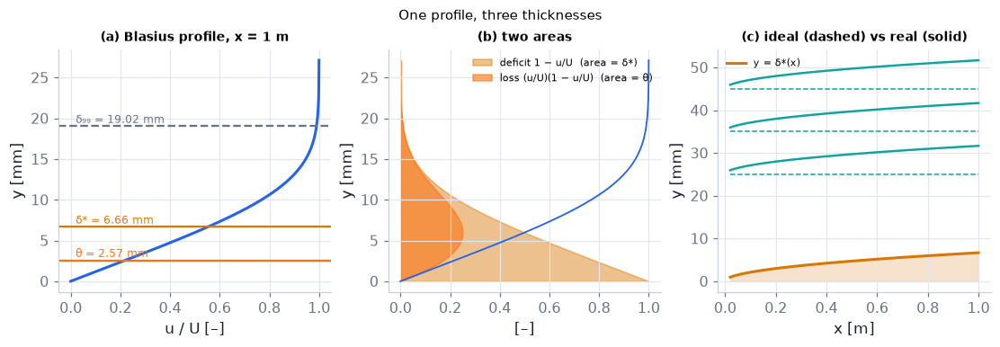

In [19]:
eta = np.linspace(0, 7, 400)                                     # similarity coordinate y/sqrt(nu x/U) for panels (a), (b)
fp = BL.blasius_profile(eta)[1]                                  # f'(eta) = u/U
ymm = eta*s*1e3                                                  # heights at x = 1 m [mm]
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(10, 3.4))   # the figure and its panels
a1.plot(fp, ymm, color=COLORS["blue"], lw=2)                     # (a) the profile with the three heights marked
for val, col, lab in ((th["delta99"], COLORS["muted"], "δ₉₉"), (th["delta_star"], COLORS["amber"], "δ*"), (th["theta"], COLORS["orange"], "θ")):   # loop over the cases
    a1.axhline(val*1e3, color=col, ls="--" if lab == "δ₉₉" else "-", lw=1.5); a1.text(0.02, val*1e3 + 0.4, f"{lab} = {val*1e3:.2f} mm", color=col, fontsize=8)   # a reference line or band
a1.set_xlabel("u / U [–]"); a1.set_ylabel("y [mm]"); a1.set_title("(a) Blasius profile, x = 1 m", fontsize=9)   # axis labels (with units), limits and the panel's message
a2.fill_betweenx(ymm, 0, 1 - fp, color=COLORS["amber"], alpha=0.45, label="deficit 1 − u/U  (area = δ*)")   # (b) the two areas
a2.fill_betweenx(ymm, 0, fp*(1 - fp), color=COLORS["orange"], alpha=0.6, label="loss (u/U)(1 − u/U)  (area = θ)")   # shade the area between two curves
a2.plot(fp, ymm, color=COLORS["blue"], lw=1.2); a2.set_xlabel("[–]"); a2.set_ylabel("y [mm]"); a2.legend(fontsize=7, frameon=False, loc="upper right"); a2.set_title("(b) two areas", fontsize=9)   # axis labels (with units), limits and the panel's message
xs_ = np.linspace(0.02, 1.0, 200)                                # (c) streamlines above the plate
dstar_x = BL.blasius_delta_star(xs_, 1.0, NU_AIR)*1e3           # displacement thickness along the plate [mm]
for y0 in (25, 35, 45):                                          # three streamlines that start far above the layer (y0 in mm)
    a3.plot(xs_, np.full_like(xs_, y0), color=COLORS["teal"], ls="--", lw=1)   # ideal flow: straight
    a3.plot(xs_, y0 + dstar_x, color=COLORS["teal"], lw=1.6)     # real flow: lifted by delta*(x)
a3.plot(xs_, dstar_x, color=COLORS["amber"], lw=2, label="y = δ*(x)"); a3.fill_between(xs_, 0, dstar_x, color=COLORS["amber"], alpha=0.2)   # shade the area between two curves
a3.set_xlabel("x [m]"); a3.set_ylabel("y [mm]"); a3.legend(fontsize=7, frameon=False, loc="upper left"); a3.set_title("(c) ideal (dashed) vs real (solid)", fontsize=9)   # axis labels (with units), limits and the panel's message
fig.suptitle("One profile, three thicknesses", fontsize=10)   # the figure's message as its title
plt.show()   # display the figure

**What you see.** In (a) the profile with three horizontal marks; in (b) the amber and orange areas; in (c) the real streamlines (solid) sitting above the ideal ones (dashed) by the amber curve $\delta^*(x)$.

**How to read it.** The amber area equals $U_e\delta^*$: $\delta^*=6.7$ mm is about $\frac13$ of $\delta_{99}=19$ mm and $H=\delta^*/\theta=2.59$; the streamline lift grows like $\sqrt x$ and reaches 6.7 mm at $x=1$ m.

**What would change if…** …the profile were fuller (turbulent-like, see the sliders below): $\delta^*$ and $\theta$ would shrink relative to $\delta_{99}$ and $H\to1.3$.

In [20]:
xa = np.linspace(0.05, 2.0, 30 if not FAST else 16)              # station positions [m] swept by the animation (the plate is 2 m long)
xg = np.linspace(0.01, 2.0, 200)                                 # x grid for the fixed curves [m]
d99g, dsg = 1e3*BL.blasius_delta99(xg, 1.0, NU_AIR), 1e3*BL.blasius_delta_star(xg, 1.0, NU_AIR)   # δ99(x) and δ*(x) [mm]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.5, 3.4), gridspec_kw=dict(width_ratios=[1.6, 1]), layout="none")   # the figure and its panels
fixed_layout(fig)                                                # fixed margins: faster frames
a1.plot(xg, d99g, color=COLORS["muted"], ls="--", lw=1.4, label="δ₉₉"); a1.plot(xg, dsg, color=COLORS["amber"], lw=1.8, label="δ*")   # fixed curves
a1.fill_between(xg, 0, dsg, color=COLORS["amber"], alpha=0.15)   # shade the area between two curves
tr_y0 = (35, 45, 55)                                             # tracer heights far upstream [mm]
tracers = [a1.plot([], [], "o", color=COLORS["teal"], ms=5)[0] for _ in tr_y0]   # tracers riding the displaced streamlines
station, = a1.plot([], [], "|", color=COLORS["accent"], ms=30, mew=2)   # the station marker
a1.set_xlim(0, 2); a1.set_ylim(0, 70); a1.set_xlabel("x [m]"); a1.set_ylabel("y [mm]"); a1.legend(fontsize=7, frameon=False, loc="upper left")   # axis labels (with units), limits and the panel's message
line, = a2.plot([], [], color=COLORS["blue"], lw=2); dot99, = a2.plot([], [], "s", color=COLORS["muted"]); dotds, = a2.plot([], [], "o", color=COLORS["amber"])   # draw the curve(s)
a2.set_xlim(0, 1.05); a2.set_ylim(0, 40); a2.set_xlabel("u / U [–]"); a2.set_ylabel("y [mm]")   # axis labels (with units), limits and the panel's message
yy_ = np.linspace(0, 40e-3, 300)                                 # heights for the profile [m]
U_all = np.array([BL.blasius_fields(xi, yy_, 1.0, NU_AIR)["u"] for xi in xa])   # every frame's profile, computed once [m/s]
D99 = 1e3*BL.blasius_delta99(xa, 1.0, NU_AIR); DS = 1e3*BL.blasius_delta_star(xa, 1.0, NU_AIR)   # δ99, δ* at every station [mm]


def update(i):                                                   # frame i = station xa[i]
    xi = xa[i]
    line.set_data(U_all[i], yy_*1e3)                             # the profile at the station, heights in mm
    dot99.set_data([0.99], [D99[i]]); dotds.set_data([0.0], [DS[i]])   # the δ99 square and the δ* dot
    for t, y0 in zip(tracers, tr_y0):                            # tracers ride y0 + δ*(x)
        t.set_data([xi], [y0 + DS[i]])
    station.set_data([xi], [D99[i]/2])
    a1.set_title(f"x = {xi:.2f} m: δ₉₉ = {D99[i]:.1f} mm, δ* = {DS[i]:.1f} mm", fontsize=9)   # axis labels (with units), limits and the panel's message
    return []   # the values for this call


show_animation(animate(update, frames=len(xa), fig=fig, interval=80))   # smooth MP4 video (P16)

**What you see.** The profile in the right panel fattens as the station moves right; the amber displacement curve lifts the three teal tracers like $\sqrt x$.

**How to read it.** At $x=1$ m the grey square sits at 19 mm; at 4 m it would sit at 38 mm ($\times2$): $\delta_{99}\propto\sqrt x$, the layer is thin because $\mathrm{Re}_x$ is large.

**What would change if…** …water instead of air: the same movie with every height divided by $\sqrt{15}\approx3.9$.

In [21]:
pp = np.linspace(1, 10, 19 if not FAST else 10)                  # exponent p of the power-law family u/U = (y/δ)^(1/p)
yh = np.linspace(0, 1, 100)                                      # y / δ


def frame(p_):                                                   # curves for one slider value p
    sh = BL.profile_shape("power", yh, 1.0, p=p_)                # exact closed forms for this profile
    return {"profile u/U": (sh["u_over_Ue"], yh),                # the profile itself
            "displacement δ*/δ": ([0, 1], [sh["delta_star"]]*2), # a horizontal line at height δ*/δ
            "momentum θ/δ": ([0, 1], [sh["theta"]]*2)}           # a horizontal line at height θ/δ


fig = slider_figure(frame, "p", pp, unit="", xlabel="u / U  [–]", ylabel="y / δ  [–]", title="", xrange=[0, 1.05], yrange=[0, 1.05])   # one figure whose curves follow the slider; every position precomputed (P17)
titles = []                                                      # one title per slider position with the numbers
for p_ in pp:   # loop over the cases
    sh = BL.profile_shape("power", yh, 1.0, p=p_)
    titles.append(f"p = {p_:.1f}: δ*/δ = {sh['delta_star']:.3f}, θ/δ = {sh['theta']:.3f}, H = {sh['H']:.2f}  (Blasius: H = 2.59 ~ p = 1.26; turbulent-like p = 7: H = 1.29)")   # store the value for the plot
step_titles(fig, titles)                                         # numbers that follow the slider
recolor(fig, {"profile u/U": COLORS["blue"], "displacement δ*/δ": COLORS["amber"], "momentum θ/δ": COLORS["orange"]})   # colours by meaning
fig.show()                                                       # interactive on the page: drag p

**What to try:** drag $p$ from 1 (a line, $H=3$) to 7 (a turbulent-like profile, $H=1.29$): the profile fills, and both horizontal marks sink toward the wall — a fuller profile displaces the outer flow
less and loses less momentum. The exact closed forms are $\delta^*/\delta=1/(p+1)$, $\theta/\delta=p/((p+1)(p+2))$, $H=(p+2)/p$.

#### 🎮 Interactive: How thin is a boundary layer — and what is its thickness?

**Why interactive rather than a static figure:** Sliding $U$, $\nu$ and $x$ shows $\delta\propto\sqrt{\nu x/U}$ and $\mathrm{Re}^{-1/2}$ in one picture, and switching the profile shape shows the three thicknesses change by different ratios — a static figure shows one case.

**What to try:**
- Set air, $U=1$ m/s and drag $x$ from 0.1 to 2 m: watch $\delta_{99}$ grow like $\sqrt x$.
- Switch the profile shape from Blasius to linear: which of $\delta^*$, $\theta$, $H$ changes most?
- Choose the preset 'layer not thin' (small $\mathrm{Re}_x$): the status warns that the layer is not thin.
- Open the Derivation tab and step through D01: the picture shows the stretched $y$.

In [22]:
show_viz("ch09", "bl_scaling_thicknesses")   # full-width explainer; ⤢ Full screen for more room

[explainer ch09/bl_scaling_thicknesses]

> ⚠️ **Common confusion:** $\delta_{99}$, $\delta^*$ and $\theta$ are three answers to three questions; none is "the" thickness. $\delta=\sqrt{\nu x/U}$ of C03 is a *scale*, not any of them ($\delta_{99}=4.91\,\delta$).

**What would change if…** …the outer speed changes along $x$? The same three integrals apply with $U_e(x)$; C06 turns them into one ODE, *(9.43)* $\frac1\rho\tau_0=\frac d{dx}[U_e^2\theta]+U_e\delta^*\frac{dU_e}{dx}$, that any layer must obey.
First, the simplest case: a constant $U_e$ over a flat plate.

---

## 9.3 Boundary Layer on a Flat Plate: Blasius Solution

**What is this section about?** The simplest outer flow is no flow change at all: a thin plate lined up with a steady stream $U$. Then the pressure gradient vanishes and the layer equations
*(9.9)*, $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=-\frac1\rho\frac{dp}{dx}+\nu\frac{\partial^2u}{\partial y^2}$, *(9.10)*, $\frac{\partial p}{\partial y}=0$ have an exact solution. Because a semi-infinite plate has no length of its own, the profiles at different distances are stretched copies of one curve; that turns the PDE into an ODE
(C03), which a computer solves in milliseconds and which gives every number we need: thickness, wall shear, drag (C04). Heinrich Blasius did this in 1908; the same trick will work for wedges and jets.

> 🔁 **Recap — Wall conditions** (§9.1). On the plate both velocity components vanish, $u=v=0$ on $y=0$ *(9.20)*, i.e. no slip $u(x,0)=0$ *(9.12)* and no through-flow $v(x,0)=0$ *(9.13)* (R04, R05 above).

> 🔁 **Recap — Edge condition** (§9.1). Far from the wall the velocity joins the outer stream: $u\to U$ as $y/\delta\to\infty$ *(9.21)*, the constant-speed case of the matching condition $u(x,y\to\infty)=U_e(x)$ *(9.14)*.

### 🧩 Blasius equation by similarity reduction `C03`

*The question:* Can the whole flat-plate layer — a PDE in $x$ and $y$ — collapse to one ordinary differential equation?

*In one line:* $\frac{d^3f}{d\eta^3}+\frac12f\frac{d^2f}{d\eta^2}=0$ *(9.27)*

> 🔁 **Tools from earlier chapters used here** (see `knowledge/primers.md`) — used in C03

- **product rule** — d(pv) = p dv + v dp; a product like δ(x) f(η) needs it, and dropping a term is the classic slip (Ch. 1 P38).

#### The problem in plain words

At $x=0.1$ m the layer on the plate is 1.9 mm thick, at 1 m it is 19 mm. Are the profiles at the two places different curves — or the same curve drawn at two magnifications? A semi-infinite plate has no length
scale except the distance $x$ itself, so the second answer is the only one that makes sense. If it holds, one function $f(\eta)$ describes the entire plate.

#### The idea

```
y     η = 4    ╱──────────────                 profile at x₁:  ▏╱‾‾   ← same shape,
│   η = 2  ╱──╯                                profile at x₂:  ▏╱‾‾‾‾  stretched by √(x₂/x₁)
│  η = 1 ╱─╯  ...   δ(x) = √(νx/U)             ψ = Uδ(x) f(y/δ(x))   →   u = U f′(η)
└─────────────────────── x
```

Lines of constant $\eta$ are parabolas $y\propto\sqrt x$; each station is the same picture zoomed in $y$ only.

📝 **Note.** **N22 [B]** **The equation to be solved.** With $dp/dx=0$ ($U_e=U$) the layer equation *(9.9)*, $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=-\frac1\rho\frac{dp}{dx}+\nu\frac{\partial^2u}{\partial y^2}$ becomes $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=\nu\frac{\partial^2u}{\partial y^2}$ *(9.18)* together with
continuity *(6.2)*, $\frac{\partial u}{\partial x}+\frac{\partial v}{\partial y}=0$. Momentum enters only through viscosity: *(9.18)* says the fluid element at height $y$ loses speed to its slower neighbour below.

$$ u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=\nu\frac{\partial^2u}{\partial y^2} \qquad \text{(9.18)} $$

> ⚠️ **Common confusion (name clash).** This Blasius solution (1908, boundary layers) is not the *Blasius force theorem* $D-iL=\frac{i\rho}{2}\oint_C\big(\frac{dw}{dz}\big)^2dz$ *(6.60)* of Ch. 6 (1910, forces on
cylinders by contour integration) — same person, different result; both return in Ch. 14.

📝 **Note.** **N23 [B]** **The similarity ansatz.** Nothing in the problem has a length except $x$, so we look for $\psi=U\delta(x)f(\eta)$, $\eta=y/\delta(x)$ *(9.19)*: $\psi$ has dimensions m²/s = (speed) × (length), so $\delta(x)$ must be a length and $f$
dimensionless. It specialises Ch. 8's *(8.32)* $\gamma=At^{-n}F(\xi/\delta(t))$ with time replaced by $x/U$; the price is that $\psi$ (not $u$) carries the $\delta$ so that continuity holds automatically.

$$ \psi=U\delta(x)f(\eta),\quad\eta=\frac y{\delta(x)} \qquad \text{(9.19)} $$

> 📎 **Primer — chain rule when the similarity variable moves with x and y.** `P206` · $\eta=y/\delta(x)$ depends on *both* variables. $\partial F/\partial y=F'(\eta)\cdot(1/\delta)$ and $\partial F/\partial x=F'(\eta)\cdot\partial\eta/\partial x=F'(\eta)\cdot(-y\delta'/\delta^2)=-F'(\eta)\,\eta\,\delta'/\delta$.
The chain rule applies each partial derivative separately; a product like $\delta(x)f(\eta)$ also needs the product rule in $x$.

In [23]:
import sympy as sp   # symbolic algebra
x, y = sp.symbols('x y', positive=True)   # symbols for sympy
delta = sp.Function('delta')(x)   # symbols for sympy
f = sp.Function('f')   # symbols for sympy
eta = y/delta
print(sp.simplify(sp.diff(f(eta), y)))     # f'(eta)/delta  (P49 chain rule, one variable)
print(sp.simplify(sp.diff(f(eta), x)))     # -y f'(eta) delta'/delta^2 = -eta f' delta'/delta

Subs(Derivative(f(_xi_1), _xi_1), _xi_1, y/delta(x))/delta(x)
-y*Derivative(delta(x), x)*Subs(Derivative(f(_xi_1), _xi_1), _xi_1, y/delta(x))/delta(x)**2


#### 🧮 Derivation — Blasius reduction: $\psi=U\delta f(\eta)$ turns into $f'''+\frac12ff''=0$ with $\delta=\sqrt{\nu x/U}$ `D05` (Eq. 9.27: $\frac{d^3f}{d\eta^3}+\frac12f\frac{d^2f}{d\eta^2}=0$)

**What we want to show.** Show that the flat-plate layer equations collapse to one ODE and find the length δ(x) that makes it so.

**Assumptions.** No imposed length scale; δ → 0 at the leading edge (9.22), $\delta\to0\ \text{as}\ x\to0$, used in step 11.

**The plan.**

1. Use a stream function.
2. Assume the profile is a stretched copy of one curve.
3. Differentiate.
4. See two terms cancel.
5. Demand that x drops out.

**Tools we use** (each explained before this point): stream function (Ch. 4 §4.3) · chain rule when η depends on x and y (primer P206) · product rule (ch01 P38) · function of x times function of η (Ch. 8 §8.2) · sympy (ch01 P40).

**We start from**

$$ \begin{array}{l}u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=\nu\frac{\partial^2u}{\partial y^2}\ \text{(9.18) with (6.2), conditions}\ u=v=0\ \text{on y = 0} \\ \text{(9.20) and}\ u\to U\ \text{(9.21)}\end{array} $$

*In words:* (9.9), $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=-\frac1\rho\frac{dp}{dx}+\nu\frac{\partial^2u}{\partial y^2}$ with no pressure gradient.

---

**Step 1 of 13 — Introduce the stream function.**

$$ u=\frac{\partial\psi}{\partial y},\qquad v=-\frac{\partial\psi}{\partial x} $$

- *Why we can do this:* Continuity (6.2), $\frac{\partial u}{\partial x}+\frac{\partial v}{\partial y}=0$ then holds automatically (mixed partial derivatives commute), so (9.18), $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=\nu\frac{\partial^2u}{\partial y^2}$ is the only equation left, for one unknown ψ.
- *In words:* one function instead of two.

---

**Step 2 of 13 — Choose the similarity form.**

$$ \psi=U\,\delta(x)\,f(\eta),\qquad\eta=\frac y{\delta(x)}\ \text{(9.19)} $$

- *Why we can do this:* The plate has no length except x, so y can only enter as y/δ(x); ψ has dimensions velocity × length, hence Uδ f.
- *In words:* each station is the same shape stretched.

---

**Step 3 of 13 — Differentiate η.**

$$ \frac{\partial\eta}{\partial y}=\frac1\delta,\qquad\frac{\partial\eta}{\partial x}=-\frac{\eta\,\delta'}{\delta} $$

- *Why we can do this:* Quotient rule on η = y/δ(x): δ depends on x, hence η does too (P206).
- *In words:* moving downstream at fixed y changes η.

---

**Step 4 of 13 — Compute u.**

$$ u=\psi_y=U\delta f'\cdot\frac1\delta=U f'(\eta)\ \text{(9.23)} $$

- *Why we can do this:* Chain rule: ∂/∂y acts on ψ only through η; the δ cancels.
- *In words:* u/U = f′(η).

---

**Step 5 of 13 — Compute v.**

$$ v=-\psi_x=U\delta'\,(\eta f'-f)\ \text{(9.24)} $$

- *Why we can do this:* Product rule: ψ_x = Uδ′f + Uδ f′·η_x = Uδ′f − Uδ′ηf′ (step 3); then change the sign.
- *In words:* v is small and comes from the layer growing.

---

**Step 6 of 13 — Differentiate u.**

$$ u_x=-U\frac{\delta'}\delta\,\eta f'',\quad u_y=\frac U\delta f'',\quad u_{yy}=\frac U{\delta^2}f''' $$

- *Why we can do this:* Chain rule with step 3 ($\eta_x=-\eta\delta'/\delta$, $\eta_y=1/\delta$), applied twice for u_yy.
- *In words:* the three derivatives (9.18), $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=\nu\frac{\partial^2u}{\partial y^2}$ needs.

---

**Step 7 of 13 — Form the advective terms.**

$$ uu_x=-\frac{U^2\delta'}\delta\,\eta f'f'',\quad vu_y=\frac{U^2\delta'}\delta\big(\eta f'f''-ff''\big) $$

- *Why we can do this:* Multiply steps 4–6: $Uf'\cdot(-U\frac{\delta'}\delta\eta f'')$ and $U\delta'(\eta f'-f)\cdot\frac U\delta f''$.
- *In words:* two products, each with an η f′ f″ piece.

---

**Step 8 of 13 — Add them.**

$$ uu_x+vu_y=-\frac{U^2\delta'}{\delta}\,ff'' $$

- *Why we can do this:* The two $\eta f'f''$ terms are equal and opposite and cancel (the first and third of the book's three terms).
- *In words:* only f f″ survives.

---

**Step 9 of 13 — Insert into (9.18).**

$$ -\Big[\frac{U^2\delta'}\delta\Big]ff''=\Big[\frac{\nu U}{\delta^2}\Big]f'''\ \text{(9.25)} $$

- *Why we can do this:* Left side from step 8, right side ν u_yy from step 6; each bracket depends on x only, the rest on η only.
- *In words:* an ODE in η whose coefficients depend on x.

---

**Step 10 of 13 — Demand similarity.**

$$ f'''+\Big[\frac{U\delta\delta'}{\nu}\Big]ff''=0,\qquad\frac{U\delta\delta'}\nu\equiv\frac12 $$

- *Why we can do this:* Divide by νU/δ². If the bracket varied with x the ODE would change from station to station; f depends on η alone only if it is constant — we choose ½, which merely defines δ.
- *In words:* the coefficient must not depend on x.

---

**Step 11 of 13 — Solve for δ.**

$$ \frac{d(\delta^2)}{dx}=\frac\nu U\ \Rightarrow\ \delta^2=\frac{\nu x}U+D=\frac{\nu x}U\ \text{(9.26)} $$

- *Why we can do this:* Integrate δδ′ = ν/(2U); δ → 0 as x → 0 (9.22), $\delta\to0\ \text{as}\ x\to0$ forces the constant D = 0.
- *In words:* δ = √(νx/U), the same root as √(νt) with t = x/U.

---

**Step 12 of 13 — State the Blasius equation.**

$$ \frac{d^3f}{d\eta^3}+\frac12f\frac{d^2f}{d\eta^2}=0\ \text{(9.27)} $$

- *Why we can do this:* Insert the bracket ½ into step 10.
- *In words:* third order, nonlinear, no parameters.

---

**Step 13 of 13 — Translate the conditions.**

$$ f(0)=f'(0)=0\ \ (9.28),\qquad f'(\infty)=1\ \ (9.29) $$

- *Why we can do this:* No slip u = Uf′(0) = 0 and no through-flow v = Uδ′(0·f′ − f(0)) = 0 from (9.20), $u=v=0\ \text{on}\ y=0$; u → U (9.21), $u\to U\ \text{as}\ y/\delta\to\infty$ gives f′ → 1; the leading-edge and edge conditions collapse into one at η = ∞, the consistency test.
- *In words:* two conditions at the wall, one at infinity.

---

**Result**

$$ f'''+\frac12ff''=0\ \text{(9.27),}\ f(0)=f'(0)=0\ \text{,}\ f'(\infty)=1\ \text{,}\ \delta=\sqrt{\nu x/U} $$

*In words:* a single curve f′(η) describes the layer at every x.

**What it means.** Profiles at different x are the same curve stretched by √x (the collapse figure); the same move works for wedges (D07) and jets (D16, D20).

**Check it.** Units: δ = √((m²/s)(m)/(m/s)) = m ✓; the bracket Uδδ′/ν is dimensionless ✓. sympy (`ch09.similarity_reduce_sympy("blasius")`): residual of (9.18), $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=\nu\frac{\partial^2u}{\partial y^2}$ with the ansatz and (9.27), $\frac{d^3f}{d\eta^3}+\frac12f\frac{d^2f}{d\eta^2}=0$ is 0. Easy numbers: x = 0.5 m, U = 1 m/s, air: δ = 2.74 mm; y = 5.48 mm is η = 2.

> ⚠️ **Common confusion (traps in `D05`):** Forgetting that η_x ≠ 0 (v would come out wrong); the constant ½ is a *choice* that fixes the meaning of δ (not δ₉₉); demanding proportional brackets is what makes x drop out.

📝 **Note.** **N25–N30 [B]** **The reduction in one box** (the pieces of D05, so you can reuse them): $\delta\to0$ as $x\to0$ *(9.22)* fixes the integration constant; $u=Uf'(\eta)$ *(9.23)*, $v=U\delta'(\eta f'-f)$ *(9.24)*;
after the two $\eta f'f''$ terms cancel the equation reads $-\big[\frac{U^2\delta'}{\delta}\big]ff''=\big[\frac{\nu U}{\delta^2}\big]f'''$ *(9.25)*; the choice $U\delta\delta'/\nu=\frac12$ gives $\delta(x)=[\nu x/U]^{1/2}$ *(9.26)* and
$\frac{d^3f}{d\eta^3}+\frac12f\frac{d^2f}{d\eta^2}=0$ *(9.27)* — third order, nonlinear, with two conditions at the wall, $f(0)=f'(0)=0$ *(9.28)*, and one at infinity, $f'(\infty)=1$ *(9.29)*.

#### ✏️ Tiny example: is a candidate δ(x) allowed?

The bracket test: the ODE keeps its $x$-independence only if $U\delta\delta'/\nu$ is a constant.
1. $\delta=\sqrt{\nu x/U}$: $\delta\delta'=\nu/(2U)$, so the test number is $\frac12$ at every $x$ ✓.
2. $\delta=kx$ with $k=0.01$ (a wedge-like layer): $Uk^2x/\nu=1\times10^{-4}x/1.5\times10^{-5}=3.33$ at $x=0.5$ m but $6.67$ at $x=1$ m ✗ — the ODE would change with $x$, no similarity.
3. $\delta$ at $x=0.5$ m for air at $U=1$ m/s: $\sqrt{1.5\times10^{-5}\times0.5}=2.74$ mm, and $y=2\delta=5.48$ mm has $\eta=2$.

In [24]:
red = ch09.similarity_reduce_sympy("blasius")                    # D05 by machine: substitute psi = U delta f(eta), form the residual of (9.18)
print("brackets:", red["brackets"])                              # the two x-only brackets of (9.25)
print("cancelled terms:", red["cancelled_terms"])                # the two eta f' f'' terms that cancel
print("ODE:", red["ode"])                                        # the reduced equation (9.27)
print("delta:", red["delta"])                                    # the length that makes the bracket ratio constant (9.26)
print("residual:", red["residual"])                              # PDE residual with the ansatz and the ODE substituted: 0

brackets: (U**2*Derivative(delta(x), x)/delta(x), U*nu/delta(x)**2)
cancelled terms: (-U**2*eta*Derivative(delta(x), x)/delta(x), U**2*eta*Derivative(delta(x), x)/delta(x))
ODE: Eq(F0*F2/2 + F3, 0)
delta: sqrt(nu)*sqrt(x)/sqrt(U)
residual: 0


**What does the code above do?**

1. sympy differentiates the ansatz for $u$ and $v$ exactly as steps 3–6 of D05 do.
2. It lists the two terms that cancel ($\eta f'f''$ with coefficient $\mp U^2\delta'/\delta$).
3. It demands proportional brackets and solves for $\delta$: $\sqrt{\nu x/U}$.
4. The residual of the PDE with the ansatz inserted and the ODE substituted is zero: the reduction is exact.

*↪ **N24 [C]** Favourable gradients ($U_e'>0$) forget the inlet profile, adverse ones never (Serrin, Peletier); Blasius sits on the border. Below, the marching solver of C01 started from two different inlets ends on the same profile — qualitative only; Ch. 10 has the numerics.*

In [25]:
d0 = 6e-3                                                        # thickness of the crude inlet profiles [m]
lin = lambda y_: np.minimum(y_/d0, 1.0)                          # inlet 1: a straight ramp up to U at y = d0 (m/s, U = 1)
sinp = lambda y_: np.sin(0.5*np.pi*np.minimum(y_/d0, 1.0))       # inlet 2: a quarter sine wave up to U
xm = np.linspace(0.02, 1.0, 60 if not FAST else 30)              # stations [m]
m1 = BL.march_boundary_layer(BL.outer_flow("flat", U=1.0).Ue, xm, NU_AIR, u_inlet=lin, ny=200)    # march from inlet 1
m2 = BL.march_boundary_layer(BL.outer_flow("flat", U=1.0).Ue, xm, NU_AIR, u_inlet=sinp, ny=200)   # march from inlet 2
for xs_ in (0.1, 0.5, 1.0):                                      # compare the two profiles at three stations
    i = int(np.argmin(np.abs(xm - xs_)))                         # nearest marched station
    u2 = np.interp(m1["y"][i], m2["y"][i], m2["u"][i])           # inlet-2 profile read at inlet-1 heights
    print(f"x = {xm[i]:.2f} m: max |u1 - u2| / U = {np.max(np.abs(m1['u'][i] - u2)):.2e}")   # print the result

x = 0.10 m: max |u1 - u2| / U = 8.81e-02
x = 0.50 m: max |u1 - u2| / U = 1.64e-02
x = 1.00 m: max |u1 - u2| / U = 7.86e-03


**What does the code above do?**

1. Two quite different inlet profiles (a ramp and a sine) are marched down a flat plate with `march_boundary_layer`.
2. The largest difference between the two profiles falls from about 9 % of $U$ at $x=0.1$ m through 1.6 % to 0.8 % at $x=1$ m: the layer slowly forgets where it started (Blasius is the fixed profile they both approach; a flat plate is the borderline case). This is a qualitative demonstration, printed and not asserted.

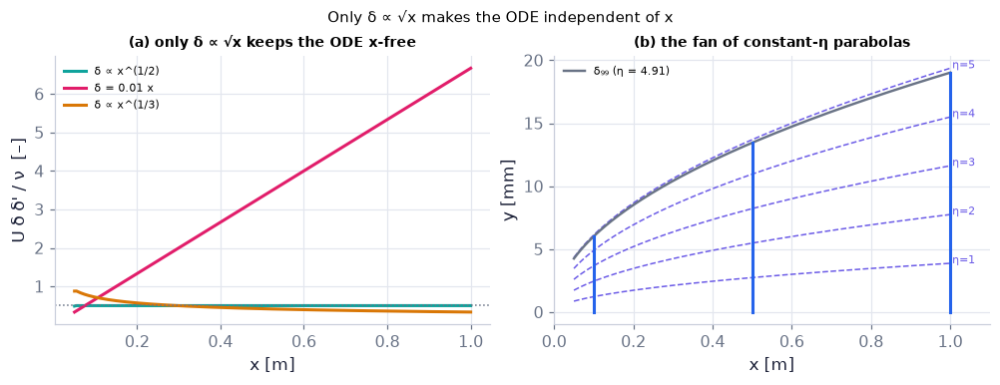

In [26]:
xx = np.linspace(0.05, 1.0, 200)                                 # stations [m]
U_, c_ = 1.0, np.sqrt(NU_AIR/1.0)                                # speed [m/s] and the scale sqrt(nu/U) [sqrt(m)]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3.4))   # the figure and its panels
for name, dl, col in (("δ ∝ x^(1/2)", c_*np.sqrt(xx), COLORS["teal"]), ("δ = 0.01 x", 0.01*xx, COLORS["rose"]), ("δ ∝ x^(1/3)", c_*xx**(1/3), COLORS["amber"])):   # loop over the cases
    test = U_*dl*np.gradient(dl, xx)/NU_AIR                      # U δ δ' / ν for each candidate thickness
    a1.plot(xx, test, color=col, lw=2, label=name)               # (a) the similarity test number
a1.axhline(0.5, color=COLORS["muted"], ls=":", lw=1); a1.set_xlabel("x [m]"); a1.set_ylabel("U δ δ' / ν  [–]"); a1.legend(fontsize=7, frameon=False)   # axis labels (with units), limits and the panel's message
a1.set_title("(a) only δ ∝ √x keeps the ODE x-free", fontsize=9)   # axis labels (with units), limits and the panel's message
for eta_ in (1, 2, 3, 4, 5):                                     # (b) lines of constant eta: parabolas
    a2.plot(xx, 1e3*eta_*np.sqrt(NU_AIR*xx/U_), color=COLORS["accent"], ls="--", lw=1)   # draw the curve(s)
    a2.text(1.005, 1e3*eta_*np.sqrt(NU_AIR/U_), f"η={eta_}", fontsize=7, color=COLORS["accent"])   # a label written on the plot
a2.plot(xx, 1e3*4.91*np.sqrt(NU_AIR*xx/U_), color=COLORS["muted"], lw=1.6, label="δ₉₉ (η = 4.91)")   # draw the curve(s)
for xs_ in (0.1, 0.5, 1.0):                                      # three stations
    a2.plot([xs_, xs_], [0, 1e3*4.91*np.sqrt(NU_AIR*xs_/U_)], color=COLORS["blue"], lw=2)   # draw the curve(s)
a2.set_xlim(0, 1.1); a2.set_xlabel("x [m]"); a2.set_ylabel("y [mm]"); a2.legend(fontsize=7, frameon=False, loc="upper left"); a2.set_title("(b) the fan of constant-η parabolas", fontsize=9)   # axis labels (with units), limits and the panel's message
fig.suptitle("Only δ ∝ √x makes the ODE independent of x", fontsize=10)   # the figure's message as its title
plt.show()   # display the figure

**What you see.** One flat teal line at 0.5 and two drifting curves in (a); in (b) parabolas fanning out from the leading edge with three blue stations.

**How to read it.** On the fan every station meets a given $\eta$ at heights that scale like $\sqrt x$: the profile at $x=1$ m is the profile at $x=0.1$ m stretched by $\sqrt{10}=3.2$ in $y$ only.

**What would change if…** …$U$ doubled: the fan flattens by $\sqrt2$ (all heights shrink) while the flat teal line stays at $\frac12$.

**What would change if…** …the outer speed varied as a power of $x$? The same steps with $U\to U_e(x)$ give C05. First, let's solve *(9.27)* $f'''+\frac12ff''=0$ and read off the numbers.

### 🧩 Blasius solution: $f''(0)=0.332$ and the numbers `C04`

*The question:* What is the profile — and what wall shear and drag does it give?

*In one line:* $\tau_0=\mu\Big(\frac{\partial u}{\partial y}\Big)_{y=0}=0.332\,\frac{\rho U^2}{\sqrt{\mathrm{Re}_x}}$ *(9.31)* · $C_f\equiv\frac{\tau_0}{\frac12\rho U^2}=\frac{0.664}{\sqrt{\mathrm{Re}_x}}$ *(9.32)* · $C_D=\frac{F_D}{\frac12\rho U^2L}=\frac{1.33}{\sqrt{\mathrm{Re}_L}}$ *(9.33)*

> 🔁 **Tools from earlier chapters used here** (see `knowledge/primers.md`) — used in C04

- **solve_ivp** — adaptive Runge–Kutta that picks its own steps to meet a tolerance (Ch. 1 P31; extras in Ch. 3 P94).
- **solve_bvp** — an ODE with conditions at both ends, written as a first-order system with a mesh and a guess (Ch. 8 P196).
- **explicit stepping (RK4 written by hand)** — four slope samples per step weighted 1-2-2-1, error ∝ Δη⁴ (Ch. 3 P95, extending Ch. 1 P30).
- **complementary error function erfc** — erfc x = 1 − erf x falls from 1 to 0: the shape of anything diffusing in from a suddenly changed wall (Ch. 4 P123).

#### The problem in plain words

A glider wing, a ship's hull, the floor of a wind tunnel: the friction drag of a smooth surface at moderate Re is set by one number, the slope of the velocity profile at the wall. Blasius' ODE has that slope as its
only unknown: $f''(0)=0.332$. Get it once and the skin friction, the drag and all three thicknesses follow.

#### The idea

```
solve  f''' + ½ f f'' = 0,  f(0) = f'(0) = 0,  f''(0) = 1     (initial-value problem)
read   f'(∞) = 2.0854 ≠ 1
rescale  f(η) = λ f₁(λη),  λ² · 2.0854 = 1  ⇒  f''(0) = λ³ = 0.33206
```

A two-point boundary problem is awkward (we know $f,f'$ at $\eta=0$ and $f'$ at $\infty$), but the equation has a scaling symmetry, so we shoot once and rescale. The conditions are the $\eta$-versions of the wall and edge conditions (R06, R07).

> 📎 **Primer — scaling symmetry of an ODE and the Töpfer trick.** `P207` · If $f_1(\eta)$ solves the ODE, sometimes $\lambda f_1(\lambda\eta)$ does too (each term scales with the same power of $\lambda$). Then a solution with one wrong end condition can be *rescaled* into one with the right condition:
solve with $f''(0)=1$, see $f'(\infty)=2.085$ instead of 1, and multiply the height by $\lambda^2=1/2.085$. (Töpfer 1912.)

In [27]:
import numpy as np   # arrays and maths
from scipy.integrate import solve_ivp   # a tool used below
rhs = lambda e, y: [y[1], y[2], -0.5*y[0]*y[2]]      # f''' = -f f''/2
s = solve_ivp(rhs, [0, 12], [0, 0, 1], rtol=1e-10)     # f''(0) = 1 guess
print(s.y[1, -1])                                    # 2.0854: f'(infinity) with the guess
print(s.y[1, -1]**-1.5)                              # 0.3321: f''(0) after rescaling, lambda^3 with lambda^2 f'(inf) = 1

2.0854098501024017
0.33205717531501117


> 📎 **Primer — shooting versus boundary-value solving.** `P208` · A *boundary-value problem* (conditions at two ends) can be solved by *shooting*: guess the missing initial slope, integrate, and adjust the guess until the far end is right (`brentq` on the mismatch $f'(\eta_{max})-1$),
or by `solve_bvp`, which treats the whole interval at once. For Blasius shooting is easy because the far value depends smoothly on the guess; near the separation member of C05 ($f''(0)\to0$, two solutions merging) the root becomes
ill-conditioned, so we shoot only for $n\ge-0.05$ and use `solve_bvp` with continuation elsewhere.

In [28]:
import numpy as np   # arrays and maths
from scipy.integrate import solve_ivp   # a tool used below
rhs = lambda e, y: [y[1], y[2], -0.5*y[0]*y[2]]
for s2 in (0.3320, 0.3321):                            # two guesses for f''(0)
    print(s2, solve_ivp(rhs, [0, 10], [0, 0, s2], rtol=1e-12).y[1, -1])   # f'(10) = 0.99988 and 1.00009: smooth, so brentq converges fast

0.332 0.999885408449305
0.3321 1.000086179255863


📝 **Note.** **N31 [B], N32 [B]** **Conditions.** $f(0)=f'(0)=0$ *(9.28)* and $f'\to1$ as $\eta\to\infty$ *(9.29)*. "Infinity" is truncated at $\eta_{max}$; the solution should not care (truncation study below:
$\eta_{max}=12$ and $16$ agree to $10^{-13}$, and even $\eta_{max}=8$ is off by only $2\times10^{-6}$).

$$ f(0)=f'(0)=0,\qquad f'(\infty)=1 \qquad \text{(9.28, 9.29)} $$

> 📎 **Primer — integration by parts.** `P218a` · The product rule $(ab)'=a'b+ab'$ integrated from $0$ to $\eta$ and rearranged: $\int_0^\eta a\,b'\,d\eta'=\big[a\,b\big]_0^\eta-\int_0^\eta a'\,b\,d\eta'$.
It moves a derivative from one factor to the other at the price of a *boundary term* $[ab]$ evaluated at the two ends. Here (D06 step 8) $a=f$ and $b=f'-1$,
and the boundary term at the wall vanishes because $f(0)=0$.

In [29]:
import numpy as np   # arrays and maths
from scipy.integrate import quad   # a tool used below
lhs = quad(lambda t: t*np.cos(t), 0, 1)[0]                   # int_0^1 a b' with a = t, b = sin t
rhs = 1*np.sin(1) - quad(lambda t: np.sin(t), 0, 1)[0]       # [a b]_0^1 - int_0^1 a' b
print(lhs, rhs)                                              # 0.38177 twice

0.3817732906760362 0.38177329067603627


#### 🧮 Derivation — Blasius numbers: f″(0) = 0.3321 by the Töpfer trick; η₉₉, δ*, θ = 2f″(0), τ₀, C_f, C_D `D06` (Eq. 9.32: $C_f\equiv\frac{\tau_0}{\frac12\rho U^2}=\frac{0.664}{\sqrt{\mathrm{Re}_x}}$)

**What we want to show.** Get every Blasius number from one numerical solution of (9.27), $\frac{d^3f}{d\eta^3}+\frac12f\frac{d^2f}{d\eta^2}=0$ and read off the wall shear and drag.

**Assumptions.** As D05; drag counted on one side of the plate (used in step 13).

**The plan.**

1. Turn the problem into an initial-value problem by a scaling symmetry.
2. Read thicknesses from the profile.
3. Convert f″
4. to stress and drag.

**Tools we use** (each explained before this point): scaling symmetry of an ODE and the Töpfer trick (primer P207) · shooting versus boundary-value solving (primer P208) · `solve_ivp` (ch01 P31) · `brentq` (ch03 P108) · integration by parts (primer P218a, just before this derivation).

**We start from**

$$ f'''+\frac12ff''=0\ \text{(9.27) with}\ f(0)=f'(0)=0\ \text{,}\ f'(\infty)=1\ \text{(9.28), (9.29)} $$

*In words:* a two-point boundary problem with one unknown, f″(0).

---

**Step 1 of 14 — Find the scaling symmetry.**

$$ f_\lambda(\eta)=\lambda f_1(\lambda\eta)\ \Rightarrow\ f_\lambda'''+\tfrac12f_\lambda f_\lambda''=\lambda^4\big(f_1'''+\tfrac12f_1f_1''\big) $$

- *Why we can do this:* Each term is a product of total weight λ⁴: f′″ brings λ⁴, f f″ brings λ·λ³; so λf₁(λη) solves (9.27), $\frac{d^3f}{d\eta^3}+\frac12f\frac{d^2f}{d\eta^2}=0$ whenever f₁ does.
- *In words:* a stretched solution is a solution.

---

**Step 2 of 14 — Integrate with a guessed slope.**

$$ f_1(0)=f_1'(0)=0,\ f_1''(0)=1\ \Rightarrow\ f_1'(\infty)=2.0854 $$

- *Why we can do this:* With all three initial values known this is an initial-value problem (`solve_ivp`); read the far value from the solution.
- *In words:* the guess gives the wrong far speed.

---

**Step 3 of 14 — Rescale to satisfy (9.29).**

$$ \lambda^2f_1'(\infty)=1\ \Rightarrow\ \lambda=0.6925,\quad f''(0)=\lambda^3=0.33206 $$

- *Why we can do this:* f_λ′(∞) = λ²f₁′(∞); choose λ to make it 1; f_λ″(0) = λ³f₁″(0).
- *In words:* one number, 0.3321.

---

**Step 4 of 14 — Read the 99 % point.**

$$ f'(\eta_{99})=0.99\ \Rightarrow\ \eta_{99}=4.910 $$

- *Why we can do this:* Root of a monotone function (`brentq`, P108); δ₉₉ = η₉₉√(νx/U). The book prints $\delta_{99}=4.93\sqrt{\nu x/U}$, read from a figure; the root of $f'=0.99$ is 4.910, 0.4 % smaller.
- *In words:* the edge sits at η = 4.91.

---

**Step 5 of 14 — Displacement thickness.**

$$ \frac{\delta^*}{\delta}=\int_0^\infty(1-f')\,d\eta=\lim_{\eta\to\infty}(\eta-f)=1.7208 $$

- *Why we can do this:* With y = δη, (9.16), $\delta^*=\int_0^\infty\Big(1-\frac u{U_e}\Big)dy$ is an integral in η; since f′ = df/dη, ∫(1 − f′)dη = η − f.
- *In words:* read it off the tail of f.

---

**Step 6 of 14 — Write the product f f″ with the velocity deficit.**

$$ f\,f''=f\,(f'-1)' $$

- *Why we can do this:* The derivative of the constant 1 is zero, so $(f'-1)'=f''$. We make this move because the momentum thickness $\theta/\delta=\int_0^\infty f'(1-f')\,d\eta$ contains the deficit $1-f'$, and we want (9.27), $\frac{d^3f}{d\eta^3}+\frac12f\frac{d^2f}{d\eta^2}=0$ to produce it.
- *In words:* The same term, rewritten so that the deficit 1 − f′ appears inside a derivative.

---

**Step 7 of 14 — Integrate (9.27) from the wall to a finite η.**

$$ f''(\eta)-f''(0)=-\frac12\int_0^\eta f\,(f'-1)'\,d\eta' $$

- *Why we can do this:* Integrate $f'''+\frac12ff''=0$ (9.27) term by term from 0 to η: the first term is an exact derivative, so the fundamental theorem of calculus gives $f''(\eta)-f''(0)$; the second term uses step 6. We stop at a finite η so that every integral is finite.
- *In words:* The change of the wall-normal shear across the layer equals minus half of an integral of f times the deficit's slope.

---

**Step 8 of 14 — Integrate by parts.**

$$ \int_0^\eta f\,(f'-1)'\,d\eta'=\Big[f\,(f'-1)\Big]_0^\eta-\int_0^\eta f'(f'-1)\,d\eta'=-f(\eta)\big(1-f'(\eta)\big)+I_\theta(\eta) $$

- *Why we can do this:* Integration by parts (primer P218a just before this derivation) with the factors $f$ and $(f'-1)'$; the boundary term at the wall vanishes because $f(0)=0$. We write $I_\theta(\eta)=\int_0^\eta f'(1-f')\,d\eta'$ for the momentum-thickness integral cut off at η.
- *In words:* The awkward integral becomes the momentum-thickness integral plus a boundary term at η.

---

**Step 9 of 14 — Solve for the wall shear f″(0).**

$$ f''(0)=\frac12I_\theta(\eta)-\frac12f(\eta)\big(1-f'(\eta)\big)+f''(\eta) $$

- *Why we can do this:* Substitute step 8 into step 7 and move $f''(0)$ to the left and everything else to the right. This holds exactly at every finite η, because no approximation has been made yet.
- *In words:* The wall slope equals half the cut-off momentum integral plus two terms that live at the cut-off η.

---

**Step 10 of 14 — Let η → ∞.**

$$ \frac\theta\delta=\int_0^\infty f'(1-f')\,d\eta=2f''(0)=0.6641 $$

- *Why we can do this:* As $\eta\to\infty$, $1-f'$ and $f''$ decay like a Gaussian, $e^{-\eta^2/4}$, while $f$ only grows like η, so $f(1-f')\to0$ and $f''(\eta)\to0$; $I_\theta(\eta)\to\theta/\delta$. Hence $f''(0)=\frac12\,\theta/\delta$.
- *In words:* θ is twice the wall slope.

---

**Step 11 of 14 — Wall shear.**

$$ \tau_0=\mu\Big(\frac{\partial u}{\partial y}\Big)_0=\mu\frac U\delta f''(0)=0.332\,\frac{\rho U^2}{\sqrt{Re_x}}\ \text{(9.31)} $$

- *Why we can do this:* u = Uf′(η), ∂η/∂y = 1/δ, and μU/δ = ρU²/√Re_x since ν = μ/ρ and δ = √(νx/U).
- *In words:* wall stress falls like x^(−1/2).

---

**Step 12 of 14 — Skin friction.**

$$ C_f=\frac{\tau_0}{\frac12\rho U^2}=\frac{2f''(0)}{\sqrt{Re_x}}=\frac{0.664}{\sqrt{Re_x}}\ \text{(9.32)} $$

- *Why we can do this:* Divide (9.31), $\tau_0=\mu\Big(\frac{\partial u}{\partial y}\Big)_{y=0}=0.332\,\frac{\rho U^2}{\sqrt{\mathrm{Re}_x}}$ by the dynamic pressure ½ρU²; 2f″(0) is the same number as θ/δ.
- *In words:* C_f√Re_x = θ/δ.

---

**Step 13 of 14 — Total friction on one side.**

$$ F_D=\int_0^L\tau_0\,dx=\frac{0.664\,\rho U^2L}{\sqrt{Re_L}} $$

- *Why we can do this:* ∫₀ᴸ x^(−1/2)dx = 2√L, so the integrable singularity at the leading edge costs nothing: the mean is twice the end value.
- *In words:* drag ∝ U^(3/2).

---

**Step 14 of 14 — Drag coefficient.**

$$ C_D=\frac{F_D}{\frac12\rho U^2L}=\frac{1.328}{\sqrt{Re_L}}\ \text{(9.33)} $$

- *Why we can do this:* Divide by the dynamic pressure and the plate length; it equals 2C_f(L). One side of the plate only.
- *In words:* a two-sided plate has twice this.

---

**Result**

$$ \begin{array}{l}f''(0)=0.33206,\ \eta_{99}=4.910,\ \dfrac{\delta^*}{\delta}=1.7208,\ \dfrac{\theta}{\delta}=0.6641\ \ (\delta=\sqrt{\nu x/U}) \\ \tau_0=\mu\Big(\frac{\partial u}{\partial y}\Big)_{y=0}=0.332\,\frac{\rho U^2}{\sqrt{\mathrm{Re}_x}}\ \text{(9.31)},\quad C_f\equiv\frac{\tau_0}{\frac12\rho U^2}=\frac{0.664}{\sqrt{\mathrm{Re}_x}}\ \text{(9.32)},\quad C_D=\frac{F_D}{\frac12\rho U^2L}=\frac{1.33}{\sqrt{\mathrm{Re}_L}}\ \text{(9.33)}\end{array} $$

*In words:* one curve gives all of them.

**What it means.** The yardstick for all approximate methods (C06–C07) and for every Ch. 10 boundary-layer code.

**Check it.** θ = 2f″(0) exactly (0.66411 = 2 × 0.33206). Air, U = 1 m/s, L = 1 m: τ₀(1 m) = 1.543 × 10⁻³ Pa, F_D = 3.09 × 10⁻³ N/m, C_D = 5.14 × 10⁻³; `solve_bvp` and the Töpfer IVP agree to 1e-9; F_D ∝ U^(3/2).

> ⚠️ **Common confusion (traps in `D06`):** Reading η₉₉ as 4.93; a factor 2 between θ/δ and f″(0) (they are equal only in this combination); one side of the plate; naive shooting with η_max large.

📝 **Note.** **N35 [B]** **$\delta_{99}$ (9.30).** The 99 % height is $\delta_{99}=4.91\sqrt{\nu x/U}$, i.e. $\delta_{99}/x=4.91/\mathrm{Re}_x^{1/2}$.

> ⚠️ **The book prints 4.93 (read off a figure); the correct value is 4.910.**
> $$\text{printed:}\ \ \delta_{99}=4.93\sqrt{\nu x/U}\qquad\text{correct:}\ \ \delta_{99}=4.910\sqrt{\nu x/U}\ \ (\text{the root of }f'=0.99)$$
> 4.910 is 0.4 % smaller; `BL.blasius_delta99(…, printed=True)` gives the printed one.

📝 **Note.** **N36 [B], N37 [B], N38 [B]** $\delta^*=1.721\sqrt{\nu x/U}$ and $\theta=0.6641\sqrt{\nu x/U}=2f''(0)\sqrt{\nu x/U}$; the wall shear is
$\tau_0=\mu\big(\frac{\partial u}{\partial y}\big)_0=0.332\,\rho U^2/\sqrt{\mathrm{Re}_x}$ *(9.31)*, which blows up like $x^{-1/2}$ at the leading edge (an integrable singularity); the skin-friction coefficient is
$C_f\equiv\frac{\tau_0}{\frac12\rho U^2}=\frac{0.664}{\sqrt{\mathrm{Re}_x}}$ *(9.32)*.

📝 **Note.** **N39 [B], N40 [B]** **Drag per unit width (one side).** $F_D=\int_0^L\tau_0\,dx=0.664\,\rho U^2L/\sqrt{\mathrm{Re}_L}$, growing like $U^{3/2}$ (Stokes flow $U$, bluff bodies $U^2$); the coefficient is
$C_D=\frac{F_D}{\frac12\rho U^2L}=\frac{1.33}{\sqrt{\mathrm{Re}_L}}$ *(9.33)*, twice the local $C_f(L)$.

> ⚠️ **Common confusion — one side only.** The book states the drag "of the plate"; *(9.33)* counts **one** wetted face. A plate with two faces has twice this drag (`BL.blasius_drag(…, sides=2)` doubles it).

📝 **Note.** **N33 [B], N34 [B]** **Far field and cross-flow.** The approach to the free stream is Gaussian: with $f\approx\eta-\delta^*$ the linearised equation $g''+\frac12(\eta-\delta^*)g'=0$ for $g=f'-1$ gives
$f'-1\approx-A\sqrt\pi\,\mathrm{erfc}\frac{\eta-\delta^*}2$ with $A=0.234$ (within 0.3 % of the solved profile for $4\le\eta\le8$); far out this is a Gaussian, which the book quotes as $(1/\eta)e^{-\eta^2/4}$ — the shift by $\delta^*$ is what makes the numbers fit.
The cross-flow $\frac vU=\frac1{2\sqrt{\mathrm{Re}_x}}(\eta f'-f)\to\frac{0.860}{\sqrt{\mathrm{Re}_x}}$ lifts the outer streamlines (this is $d\delta^*/dx$ of C02).

#### ✏️ Tiny example: a 1 m plate in air

$U=1$ m/s, $\nu=1.5\times10^{-5}$: $\mathrm{Re}_x(1\,\mathrm m)=6.67\times10^4$, $\sqrt{\mathrm{Re}}=258.2$, $\sqrt{\nu x/U}=3.873$ mm.
1. $\delta_{99}=4.910\times3.873=19.02$ mm; $\delta^*=1.7208\times3.873=6.665$ mm; $\theta=0.6641\times3.873=2.572$ mm.
2. $\tau_0=0.3321\times1.2\times1/258.2=1.543\times10^{-3}$ Pa; $C_f=0.6641/258.2=2.572\times10^{-3}$.
3. $F_D$ (one side, $L=1$ m) $=2\tau_0(L)\,L=3.086\times10^{-3}$ N/m; $C_D=1.328/258.2=5.14\times10^{-3}$. Doubling $U$ raises $F_D$ by $2^{3/2}=2.83$.

In [30]:
bc = BL.blasius_constants()                                      # solve (9.27) once (Töpfer IVP) and integrate the profile
for k in ("fpp0", "eta99", "delta_star", "theta", "H", "v_inf", "cf_coeff", "cd_coeff"):   # loop over the cases
    print(f"{k:11s} {float(bc[k]):.6f}")                          # f''(0), eta99, delta*/delta, theta/delta, H, v_inf sqrt(Re_x)/U, Cf sqrt(Re_x), CD sqrt(Re_L)
base = BL.falkner_skan(0.0, eta_max=12)["fpp0"]                  # the same equation solved as a boundary-value problem (m = 0 is Blasius)
for em in (5, 6, 8, 12, 16):                                     # truncation study: where 'infinity' is put
    print(em, BL.falkner_skan(0.0, eta_max=em)["fpp0"] - base)   # change of f''(0): 4e-3 at 5, 5e-4 at 6, 2e-6 at 8, ~1e-13 at 16
t = BL.falkner_skan(0.0, method="toepfer")["fpp0"]               # route 1: scaling of an initial-value problem
b = BL.falkner_skan(0.0, method="bvp")["fpp0"]                   # route 2: solve_bvp with the two-end conditions
print("Toepfer - bvp =", t - b); assert abs(t - b) < 1e-8          # two independent routes agree
et = np.array([1, 2, 3, 4, 5, 6.0])                              # a few values of eta
f_, fp_, fpp_ = BL.blasius_profile(et)                           # f, f', f'' at those eta
print("f'(eta)          :", np.round(fp_, 4))                    # 0.3298 0.6298 0.8460 0.9555 0.9915 0.9990
e3 = np.array([2, 5, 7.0]); f3, fp3, _ = BL.blasius_profile(e3)  # the cross-flow at three eta
print("(v/U) sqrt(Re_x) :", np.round(0.5*(e3*fp3 - f3), 4))      # 0.3048 0.8372 0.8601: (eta f' - f)/2 rising to 0.860

fpp0        0.332057
eta99       4.909990
delta_star  1.720788
theta       0.664115
H           2.591100
v_inf       0.860394
cf_coeff    0.664115
cd_coeff    1.328229


5 0.004095007689256358


6 0.0005085949883575358
8 1.855519559945673e-06
12 0.0


16

 -8.909539772616881e-14
Toepfer - bvp = -1.074140776324839e-13
f'(eta)          : [0.3298 0.6298 0.846  0.9555 0.9915 0.999 ]
(v/U) sqrt(Re_x) : [0.3048 0.8372 0.8601]


**What does the code above do?**

1. `blasius_constants` solves *(9.27)*, $\frac{d^3f}{d\eta^3}+\frac12f\frac{d^2f}{d\eta^2}=0$ once by the Töpfer initial-value problem and integrates the profile: $f''(0)=0.33206$, $\eta_{99}=4.910$, $\delta^*/\delta=1.7208$, $\theta/\delta=0.6641$, $H=2.591$, the cross-flow limit 0.8604, and the coefficients $C_f\sqrt{\mathrm{Re}_x}=0.6641$ and $C_D\sqrt{\mathrm{Re}_L}=1.328$.
2. The truncation loop shows where "infinity" is put hardly matters once it is past the layer: $\eta_{max}=12$ and $16$ agree to $10^{-13}$, $\eta_{max}=8$ is off by $2\times10^{-6}$ — but $\eta_{max}=5$ (barely past $\eta_{99}=4.91$) is off by $4\times10^{-3}$ and $\eta_{max}=6$ by $5\times10^{-4}$.
3. The two independent routes — Töpfer scaling and `solve_bvp` — agree.
4. The last two lines print the profile at $\eta=1,\dots,6$ and the cross-flow $\frac12(\eta f'-f)$ at $\eta=2,5,7$.

In [31]:
x3 = np.array([0.1, 0.5, 1.0])                                   # three stations [m]
print("delta99 [mm]:", 1e3*BL.blasius_delta99(x3, 1.0, NU_AIR))                 # 6.01, 13.4, 19.0
print("delta*  [mm]:", 1e3*BL.blasius_delta_star(x3, 1.0, NU_AIR))   # print the result
print("theta   [mm]:", 1e3*BL.blasius_theta(x3, 1.0, NU_AIR))   # print the result
print("tau0 [Pa]   :", [f"{t:.4g}" for t in BL.blasius_wall_shear(x3, 1.0, RHO_AIR, NU_AIR)])   # (9.31), 4 significant figures
ReL = 1.0/NU_AIR                                                 # Re_L of the 1 m plate at 1 m/s
print("Cf, F_D [N/m], C_D:", BL.blasius_skin_friction(ReL), BL.blasius_drag(1.0, 1.0, RHO_AIR, NU_AIR), BL.blasius_drag_coefficient(ReL))   # (9.32), (9.33)
print("printed 4.93 / true 4.910 =", BL.blasius_delta99(1.0, 1.0, NU_AIR, printed=True)/BL.blasius_delta99(1.0, 1.0, NU_AIR))   # the slip
print("two sides double the drag:", BL.blasius_drag(1.0, 1.0, RHO_AIR, NU_AIR, sides=2)/BL.blasius_drag(1.0, 1.0, RHO_AIR, NU_AIR))   # print the result

delta99 [mm]: [ 6.0135 13.4466 19.0163]
delta*  [mm]: [2.1075 4.7126 6.6646]
theta   [mm]: [0.8134 1.8188 2.5721]
tau0 [Pa]   : ['0.00488', '0.002183', '0.001543']
Cf, F_D [N/m], C_D: 0.0025721050662948874 0.0030865260795538657 0.005144210132589775
printed 4.93 / true 4.910 = 1.004075464244966
two sides double the drag: 2.0


**What does the code above do?**

1. Every closed form is the computed constant times a power of $x$: $\delta_{99}(1\,\mathrm m)=19.02$ mm, and 6.01 mm at $0.1$ m ($\sqrt{10}$ smaller).
2. $\tau_0(1\,\mathrm m)=1.543\times10^{-3}$ Pa, $C_f=2.572\times10^{-3}$, $F_D=3.086\times10^{-3}$ N/m, $C_D=5.14\times10^{-3}$ — the numbers of the worked example.
3. The printed-to-true ratio is 1.004 (the printed slip in $\delta_{99}=4.93\sqrt{\nu x/U}$ *(9.30)*, as a code option), and `sides=2` doubles the drag — that one is **not** a slip: the book's $C_D=1.33/\sqrt{\mathrm{Re}_L}$ *(9.33)* is explicitly for one side, and `sides=` only guards against the trap of forgetting it.

In [32]:
# from scratch: an RK4 loop written by hand for f''' = -f f''/2 from f''(0) = 1 (step 0.01, eta to 14), then the Töpfer rescale
def rhs3(Y):                                                     # Y = (f, f', f''); returns the derivative vector of (9.27)
    return np.array([Y[1], Y[2], -0.5*Y[0]*Y[2]])   # the values for this call
h_, N_ = 0.01, 1400                                              # step and number of steps (eta from 0 to 14)
Y = np.array([0.0, 0.0, 1.0]); e1 = np.arange(N_ + 1)*h_         # start at the wall with the guess f''(0) = 1
tab = np.zeros((N_ + 1, 3)); tab[0] = Y
for k in range(N_):                                              # classical fourth-order Runge-Kutta
    k1 = rhs3(Y); k2 = rhs3(Y + 0.5*h_*k1); k3 = rhs3(Y + 0.5*h_*k2); k4 = rhs3(Y + h_*k3)
    Y = Y + h_/6*(k1 + 2*k2 + 2*k3 + k4); tab[k + 1] = Y
lam = tab[-1, 1]**-0.5                                           # lambda with lambda^2 f1'(infinity) = 1
fpp0_mine = lam**3                                               # f''(0) after the rescale
assert np.isclose(fpp0_mine, 0.3320573362, rtol=1e-6)            # the Blasius value
from scipy.interpolate import CubicSpline                        # smooth interpolation of the RK4 table
fp1 = CubicSpline(e1, tab[:, 1])                                 # f1'(eta1)
ee = np.arange(0, 6.1, 0.5)                                      # compare on these eta
fp_mine = lam**2*fp1(lam*ee)                                     # f'(eta) = lambda^2 f1'(lambda eta)
assert np.allclose(fp_mine, BL.blasius_profile(ee)[1], atol=1e-6)   # same profile as the library
big = 12.0; fbig = BL.blasius_profile(np.array([big]))[0][0]     # identities: delta*/delta = lim (eta - f), theta/delta = 2 f''(0)
assert np.isclose(big - fbig, bc["delta_star"], rtol=1e-6) and np.isclose(bc["theta"], 2*bc["fpp0"], rtol=1e-6)   # check: stops with an error if it fails
print("f''(0) by hand =", fpp0_mine, "| library =", bc["fpp0"], "| theta/delta = 2 f''(0):", 2*bc["fpp0"])   # print the result

f''(0) by hand =

 0.3320573362191869 | library = 0.3320573362151941 | theta/delta = 2 f''(0): 0.6641146724303882


**What does the code above do?**

1. A hand-written fourth-order Runge–Kutta loop integrates $f'''=-\frac12ff''$ from the wall with the guess $f''(0)=1$.
2. The Töpfer rescale $\lambda=f_1'(\infty)^{-1/2}$ turns the guess into the true wall shear $f''(0)=\lambda^3$, asserted equal to 0.3320573362.
3. The rescaled profile $f'(\eta)=\lambda^2f_1'(\lambda\eta)$ (through a `CubicSpline` of the RK4 table) is compared with `BL.blasius_profile`.
4. The last assert checks the two identities of D06: $\delta^*/\delta=\lim(\eta-f)$ and $\theta/\delta=2f''(0)$.

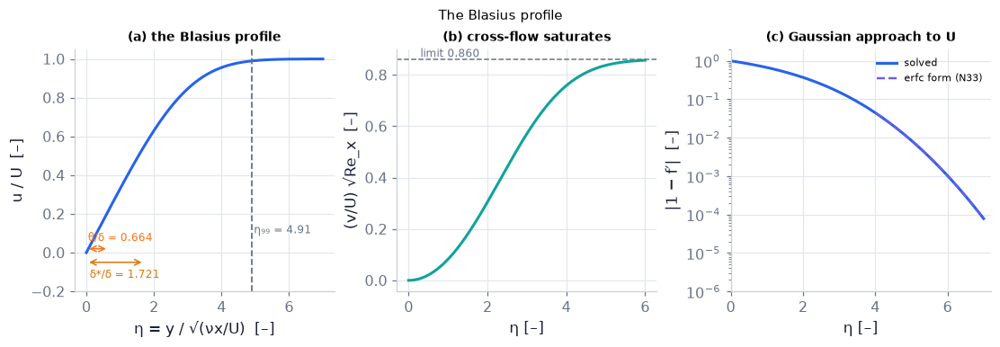

In [33]:
eta = np.linspace(0, 7, 400)                                     # similarity coordinate
f_, fp_, fpp_ = BL.blasius_profile(eta)
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(10, 3.4))   # the figure and its panels
a1.plot(eta, fp_, color=COLORS["blue"], lw=2, label="f′(η) = u/U")                # (a) the profile with its markers
a1.axvline(bc["eta99"], color=COLORS["muted"], ls="--", lw=1.2); a1.text(bc["eta99"] + 0.05, 0.1, "η₉₉ = 4.91", color=COLORS["muted"], fontsize=8)   # a reference line or band
a1.annotate("", xy=(bc["delta_star"], -0.05), xytext=(0, -0.05), arrowprops=dict(arrowstyle="<->", color=COLORS["amber"])); a1.text(0.1, -0.13, "δ*/δ = 1.721", color=COLORS["amber"], fontsize=8)   # a label written on the plot
a1.annotate("", xy=(bc["theta"], 0.02), xytext=(0, 0.02), arrowprops=dict(arrowstyle="<->", color=COLORS["orange"])); a1.text(0.05, 0.06, "θ/δ = 0.664", color=COLORS["orange"], fontsize=8)   # a label written on the plot
a1.set_ylim(-0.2, 1.05); a1.set_xlabel("η = y / √(νx/U)  [–]"); a1.set_ylabel("u / U  [–]"); a1.set_title("(a) the Blasius profile", fontsize=9)   # axis labels (with units), limits and the panel's message
a2.plot(eta[eta <= 6], 0.5*(eta*fp_ - f_)[eta <= 6], color=COLORS["teal"], lw=2); a2.axhline(bc["v_inf"], color=COLORS["muted"], ls="--", lw=1)   # (b) cross-flow with its limit
a2.text(0.3, 0.87, "limit 0.860", color=COLORS["muted"], fontsize=8); a2.set_xlabel("η [–]"); a2.set_ylabel("(v/U) √Re_x  [–]"); a2.set_title("(b) cross-flow saturates", fontsize=9)   # axis labels (with units), limits and the panel's message
ee = np.linspace(4, 7, 100)                                      # (c) far field: |1 - f'| against eta (beyond 7 the profile is 1 to plotting accuracy)
a3.semilogy(eta[eta <= 7], np.maximum(np.abs(1 - fp_), 1e-14)[eta <= 7], color=COLORS["blue"], lw=2, label="solved")   # curve(s) on logarithmic axes
a3.semilogy(ee, np.abs(BL.blasius_far_field(ee)), color=COLORS["accent"], ls="--", lw=1.6, label="erfc form (N33)")   # curve(s) on logarithmic axes
a3.set_ylim(1e-6, 2); a3.set_xlim(0, 7.2); a3.set_xlabel("η [–]"); a3.set_ylabel("|1 − f′|  [–]"); a3.legend(fontsize=7, frameon=False); a3.set_title("(c) Gaussian approach to U", fontsize=9)   # axis labels (with units), limits and the panel's message
fig.suptitle("The Blasius profile", fontsize=10)   # the figure's message as its title
plt.show()   # display the figure

**What you see.** An S-shaped profile flat at the wall in (a); a cross-flow that saturates at 0.860 in (b); and a downward-curving parabola in (c) — the Gaussian approach to the free stream — with the erfc form on top of it.

**How to read it.** At $\eta=2$ the speed is 63 % of $U$; the layer edge (99 %) sits at $\eta=4.91$; the slope at the wall is $f''(0)=0.332$; the amber and orange arrows are the areas $\delta^*/\delta=1.721$ and $\theta/\delta=0.664$ of C02.

**What would change if…** …the truncation $\eta_{max}$ were 5: the tail is cut and $f''(0)$ would be off by $4\times10^{-3}$ (1.2 %); at $\eta_{max}=6$ by $5\times10^{-4}$.

📝 **Note.** **N42 [B]** **Figs. 9.5–9.6 remade with our own solver: the collapse.** Profiles of $u(y)$ at several stations are different curves, but plotted against $\eta=y/\sqrt{
u x/U}$ they fall on the single curve $f'(\eta)$ — the heart of the Blasius solution and of the explainer below.

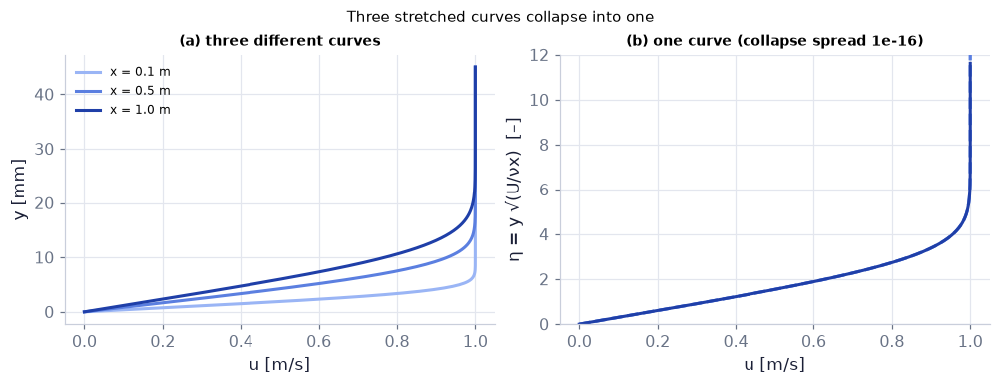

In [34]:
xs3 = (0.1, 0.5, 1.0)                                            # three stations [m]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3.4))   # the figure and its panels
for xs_, col in zip(xs3, ("#9ab5f5", "#5b7fe0", "#1f3fa8")):     # blue, darker with x
    yy = np.linspace(0, 45e-3, 300); fl = BL.blasius_fields(xs_, yy, 1.0, NU_AIR)   # sample points
    a1.plot(fl["u"], yy*1e3, color=col, lw=2, label=f"x = {xs_} m")            # (a) dimensional profiles
    a2.plot(fl["u"], fl["eta"], color=col, lw=2, ls="-" if xs_ == 1.0 else "--")   # (b) same data against eta
a1.set_xlabel("u [m/s]"); a1.set_ylabel("y [mm]"); a1.legend(fontsize=8, frameon=False); a1.set_title("(a) three different curves", fontsize=9)   # axis labels (with units), limits and the panel's message
err = ch09.similarity_collapse_error("blasius", n=0.0, m=0.5)     # spread of the rescaled profiles (exact solution): ~0
a2.set_xlabel("u [m/s]"); a2.set_ylabel("η = y √(U/νx)  [–]"); a2.set_ylim(0, 12); a2.set_title(f"(b) one curve (collapse spread {err:.0e})", fontsize=9)   # axis labels (with units), limits and the panel's message
fig.suptitle("Three stretched curves collapse into one", fontsize=10)   # the figure's message as its title
plt.show()   # display the figure

**What you see.** Three different curves in (a), one single curve in (b) (the three dashed and solid lines lie on top of each other).

**How to read it.** They differ only by the $\sqrt x$ stretch in $y$ (factors 1, 2.2, 3.2 for $x=0.1,0.5,1$ m); the collapse spread printed in the title is the machine-precision residual of the exact similarity solution.

**What would change if…** …water instead of air: every $y$ in (a) shrinks by $\sqrt{15}$ but panel (b) is unchanged.

📝 **Note.** **N41 [B]** **Blasius versus the temporal boundary layer.** Ch. 8's Stokes first problem, mapped onto the plate by $t=x/U$, gives a wall stress with $C_f\sqrt{\mathrm{Re}_x}=1.128$; the true plate layer has 0.664 locally and the plate-averaged $C_D\sqrt{\mathrm{Re}_L}=1.328$. The map overstates the local stress by about 70 %.

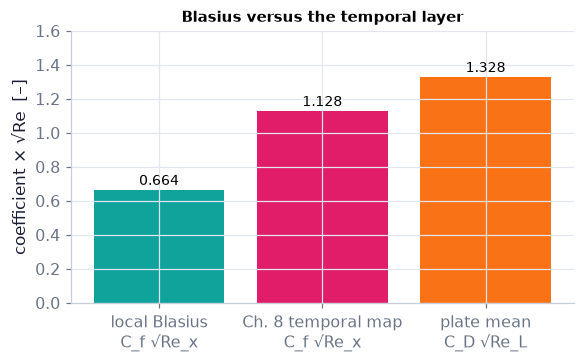

In [35]:
tb = LAM.temporal_bl_wall_stress(1.0, 1.0, NU_AIR, RHO_AIR)["Cf_coefficient"]   # Ch. 8's Stokes-layer Galilean map t = x/U: Cf sqrt(Re_x) = 1.128
vals = [bc["cf_coeff"], tb, bc["cd_coeff"]]                       # local Blasius, temporal map, plate-averaged
fig, ax = plt.subplots(figsize=(5.2, 3.2))   # the figure and its panels
ax.bar(["local Blasius\nC_f √Re_x", "Ch. 8 temporal map\nC_f √Re_x", "plate mean\nC_D √Re_L"], vals, color=[COLORS["teal"], COLORS["rose"], COLORS["orange"]])   # bars
for i, v in enumerate(vals): ax.text(i, v + 0.03, f"{v:.3f}", ha="center", fontsize=9)   # a label written on the plot
ax.set_ylabel("coefficient × √Re  [–]"); ax.set_ylim(0, 1.6); ax.set_title("Blasius versus the temporal layer", fontsize=10)   # axis labels (with units), limits and the panel's message
plt.show()   # display the figure

**What you see.** Three bars: 0.664 (local Blasius, teal), 1.128 (Ch. 8's Stokes-layer map $t=x/U$, rose) and 1.328 (plate-averaged, orange).

**How to read it.** The Galilean map overstates the wall stress by 70 %: in the plate layer the fluid near the wall moves slower than $U$ and is advected less than the map assumes; the last bar is exactly twice the first because $\int_0^Lx^{-1/2}dx=2\sqrt L$.

**What would change if…** …a plate that was sucked (Exercise 9.26): the layer would thin and the first bar would rise.

In [36]:
xa = np.linspace(0.1, 2.0, 30 if not FAST else 16)               # stations [m]
ya = np.linspace(0, 30e-3, 200); ea = np.linspace(0, 8, 200)     # heights [m] for the raw panel, eta for the scaled panel
fp_e = BL.blasius_profile(ea)[1]                                 # the one curve f'(eta)
UU = np.array([BL.blasius_fields(xi, ya, 1.0, NU_AIR)["u"] for xi in xa])   # every station's dimensional profile [m/s]
D99 = 1e3*BL.blasius_delta99(xa, 1.0, NU_AIR)                    # delta99 at each station [mm]
yd = 10e-3                                                       # a fixed height of 10 mm: the dot rides the curve as x changes
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3.4), layout="none"); fixed_layout(fig, wspace=0.3)   # the figure and its panels
l1, = a1.plot([], [], color=COLORS["blue"], lw=2); d1, = a1.plot([], [], "o", color=COLORS["rose"]); t1, = a1.plot([], [], "_", color=COLORS["muted"], ms=18, mew=2)   # draw the curve(s)
a1.set_xlim(0, 1.05); a1.set_ylim(0, 30); a1.set_xlabel("u / U [–]"); a1.set_ylabel("y [mm]"); a1.set_title("raw profile (stretches)", fontsize=9)   # axis labels (with units), limits and the panel's message
a2.plot(fp_e, ea, color=COLORS["accent"], ls="--", lw=2); d2, = a2.plot([], [], "o", color=COLORS["rose"])   # draw the curve(s)
a2.set_xlim(0, 1.05); a2.set_ylim(0, 8); a2.set_xlabel("u / U [–]"); a2.set_ylabel("η = y / √(νx/U)  [–]"); a2.set_title("rescaled: f′(η) never moves", fontsize=9)   # axis labels (with units), limits and the panel's message


def update(i):                                                   # frame i = station xa[i]
    l1.set_data(UU[i], ya*1e3); t1.set_data([0.99], [D99[i]])    # the raw profile and its delta99 tick
    ui = np.interp(yd, ya, UU[i]); d1.set_data([ui], [yd*1e3])   # the dot at y = 10 mm
    d2.set_data([ui], [yd/np.sqrt(NU_AIR*xa[i])])                # the same dot at eta = y / sqrt(nu x / U): it slides along the fixed curve
    fig.suptitle(f"x = {xa[i]:.2f} m", fontsize=10)   # the figure's message as its title
    return []   # the values for this call


show_animation(animate(update, frames=len(xa), fig=fig, interval=90))   # smooth video

**What you see.** On the left the blue profile stretches in $y$ as the station moves; on the right the purple curve never moves, and the rose dot (the fluid at 10 mm) slides along it.

**How to read it.** $y$ scales with $\sqrt x$ while $u/U$ is a function of $\eta$ only: the dot's $\eta$ falls as $x$ grows because the same 10 mm is a smaller fraction of a thicker layer.

**What would change if…** …$U$ doubled: every height shrinks by $\sqrt2$ on the left; the right panel is unchanged.

In [37]:
xs2 = np.linspace(0.05, 2.0, 25 if not FAST else 12)             # stations [m]
yh = np.linspace(0, 45e-3, 125)                                  # heights [m]
ref = BL.blasius_fields(1.0, yh, 1.0, NU_AIR)["u"]               # the reference profile at x = 1 m


def frame(x_):                                                   # curves for one station
    u_ = BL.blasius_fields(x_, yh, 1.0, NU_AIR)["u"]             # profile at the station
    d99 = 1e3*BL.blasius_delta99(x_, 1.0, NU_AIR)                # delta99 [mm]
    return {"raw profile at x": (u_, yh*1e3),   # the values for this call
            "reference at x = 1 m": (ref, yh*1e3),
            "raw rescaled by √(1 m / x)": (u_, yh*1e3*np.sqrt(1.0/x_)),   # squeeze y back: lands on the reference
            "δ₉₉": ([0, 1], [d99, d99])}


fig = slider_figure(frame, "x", xs2, unit="m", xlabel="u / U  [–]", ylabel="y [mm]", title="", xrange=[0, 1.05], yrange=[0, 45])   # one figure whose curves follow the slider; every position precomputed (P17)
recolor(fig, {"raw profile at x": COLORS["blue"], "reference at x = 1 m": COLORS["muted"], "raw rescaled by √(1 m / x)": COLORS["accent"], "δ₉₉": COLORS["amber"]},   # colours by meaning
        dashes={"reference at x = 1 m": "dash", "raw rescaled by √(1 m / x)": "dot"})
step_titles(fig, [f"x = {x_:.2f} m: δ₉₉ = {1e3*BL.blasius_delta99(x_, 1.0, NU_AIR):.1f} mm; the rescaled profile (dotted) lies on the x = 1 m reference" for x_ in xs2])   # a title with numbers for every slider position
fig.show()                                                       # interactive: drag x

**What you see.** For the station chosen with the slider: the raw Blasius profile $u(y)$ at that $x$, the reference profile at $x=1$ m, the raw profile with $y$ rescaled by $\sqrt{1\,\mathrm m/x}$, and the $\delta_{99}$ level.

**How to read it.** Slide $x$: the raw profile thickens like $\sqrt x$ and its $\delta_{99}$ line climbs, but the rescaled curve always lies exactly on the reference — one curve $f'(\eta)$ describes the whole plate.

#### 🎮 Interactive: Why does one curve describe the whole plate?

**Why interactive rather than a static figure:** Toggling raw ↔ rescaled makes the collapse happen; the truncation and shooting sliders show what '$f'\to1$ at infinity' demands; a static plot shows three profiles, not the mechanism.

**What to try:**
- Drag the three station sliders and watch raw profiles stretch but the rescaled ones stay together.
- Use the shooting slider: set $f''(0)$ to 0.30 or 0.36 and read the status (never reaches 1 / overshoots).
- Click a point on the profile: the inspector shows $\eta$, $f'$, $u$ and $y$.
- Open Derivation D05: the picture highlights where the two $\eta f'f''$ terms cancel.

In [38]:
show_viz("ch09", "blasius_similarity_collapse")   # full-width explainer; ⤢ Full screen for more room

[explainer ch09/blasius_similarity_collapse]

> ⚠️ **Common confusion (leading edge).** $\tau_0\propto x^{-1/2}$ is infinite at $x=0$: the layer equations fail where $\mathrm{Re}_x\lesssim1$ (N17), but the singularity is integrable, so the drag
$C_D=\frac{F_D}{\frac12\rho U^2L}=\frac{1.33}{\sqrt{\mathrm{Re}_L}}$ *(9.33)* is still right for $\mathrm{Re}_L\gtrsim10^3$.

**What would change if…** …the free stream accelerates or decelerates? $\delta(x)$ then carries $U_e(x)$ and the ODE gains two terms: C05.

---

## 9.4 Falkner–Skan Similarity Solutions of the Laminar Boundary-Layer Equations

**What is this section about?** Blasius has a constant outer speed. If the outer speed is a power of the distance, $U_e=ax^n$, the layer is still similar — and the single
family of ODEs contains the flat plate ($n=0$), the flow towards a wall ($n=1$) and, at $n=-0.0904$, the last attached profile before the wall shear vanishes. It is our first
laboratory for pressure-gradient effects and for separation.

### 🧩 Falkner–Skan equation: wedge flows, Blasius at $n=0$, stagnation flow at $n=1$ `C05`

*The question:* What happens to the layer when the outer flow accelerates or decelerates as a power of $x$?

*In one line:* $f'''+\frac{n+1}2ff''-nf'^2+n=0$ *(9.36)*

> 🔁 **Tools from earlier chapters used here** (see `knowledge/primers.md`) — used in C05

- **exponent rules** — a^m a^n = a^(m+n), (a^m)^n = a^(mn): with U_e = a xⁿ the scales √(νxU_e) and δ are powers of x (Ch. 1 P43).
- **live widgets** — ipywidgets sliders re-run a function while a kernel runs; frozen on the published page, so they always come with a static figure (Ch. 1 P47).

#### The problem in plain words

Wind hits a roof ridge, a bow, a wing's leading edge: the outer speed changes along the wall. If it rises as $x^n$, the pressure falls along the wall (favourable), the layer is squeezed and its wall shear is large;
if it falls ($n<0$) the pressure rises along the wall (adverse), the layer thickens and — for $n=-0.0904$ — the wall shear reaches zero, which is separation.

#### The idea

| $n$ | $\beta=2n/(n+1)$ | outer flow | pressure | profile |
|---|---|---|---|---|
| 4 | 1.60 | strongly accelerating | strongly favourable | very full |
| 1 | 1.00 | stagnation point (Hiemenz flow: wall ⊥ stream) | favourable | $\delta$ constant |
| 1/3 | 0.50 | wedge | favourable | full |
| 0 | 0 | flat plate (Blasius) | none | inflection at the wall |
| −0.05 | −0.105 | slightly decelerating | adverse | inflection at $\eta\approx1.65$ |
| −0.0904 | −0.199 | deceleration | adverse, strong | $f''(0)=0$: separation |

The ideal flow past a wedge of half-angle $\pi n/(n+1)$ is the corner flow $Az^n$ of Ch. 6; one dial, $n$, runs the whole family.

📝 **Note.** **N43 [B], N44 [B]** **Ansatz and pressure gradient.** $\psi=\sqrt{\nu xU_e}\,f(\eta)$, $\eta=\frac yx\sqrt{\mathrm{Re}_x}=y\sqrt{\frac a\nu}\,x^{(n-1)/2}$ *(9.34)* with $\mathrm{Re}_x=ax^{n+1}/\nu$; the outer flow
imposes $-\frac1\rho\frac{dp}{dx}=U_e\frac{dU_e}{dx}=na^2x^{2n-1}$ *(9.35)* ($n>0$ favourable, $n<0$ adverse).

$$ \psi=\sqrt{\nu xU_e}\,f(\eta) \qquad \text{(9.34)} $$

📝 **Note.** **N45 [B]** **Thickness.** $\delta(x)=\sqrt{\nu x/U_e}=\sqrt{\nu x^{1-n}/a}$ grows for $n<1$ and is *constant* at $n=1$ (a layer of fixed thickness under a stagnation point).
For $n=1/3$ it grows like $x^{1/3}$, for $n=0$ like $x^{1/2}$, for $n=-0.05$ like $x^{0.525}$: the adverse layers thicken fastest.

> 📎 **Primer — continuation in a parameter and a fold (saddle-node).** `P209` · To solve a family $f(\eta;n)$, start at an easy $n$ (Blasius) and move $n$ in small steps, using each solution as the guess for the next: *continuation*. A solution branch can *turn back* at a fold: two solutions merge and vanish
(a saddle-node). Beyond the fold `solve_bvp` fails — not a bug, but the mathematics saying there is no attached solution.

In [39]:
import numpy as np   # arrays and maths
n = np.linspace(-0.2, 0.2, 5)   # sample points
print(n + 0.01)              # the branch x = +sqrt(n + 0.01) exists only where this is >= 0 (a fold at n = -0.01)
print(np.sqrt(np.maximum(n + 0.01, 0)))  # the upper branch exists only where n + 0.01 >= 0

[-0.19 -0.09  0.01  0.11  0.21]
[0.     0.     0.1    0.3317 0.4583]


#### 🧮 Derivation — Falkner–Skan reduction: $\psi=\sqrt{\nu xU_e}f(\eta)$ gives $f'''+\frac{n+1}2ff''-nf'^2+n=0$ `D07` (Eq. 9.36: $f'''+\frac{n+1}2ff''-nf'^2+n=0$)

**What we want to show.** Show that a power-law outer flow keeps the similarity form and find the ODE.

**Assumptions.** U_e = axⁿ exactly; Re_x ≫ 1.

**The plan.**

1. Generalise the ansatz.
2. Differentiate with two x-dependences.
3. Watch the η terms cancel.
4. Collect.

**Tools we use** (each explained before this point): chain rule with η(x, y) (primer P206) · power laws (ch01 P43) · sympy (ch01 P40).

**We start from**

$$ uu_x+vu_y=U_eU_e'+\nu u_{yy}\ \text{(9.9) with (9.11),}\ U_e=ax^n\ \text{so}\ -\frac1\rho\frac{dp}{dx}=U_eU_e'=na^2x^{2n-1}\ \text{(9.35)} $$

*In words:* Blasius' problem with a pressure gradient.

---

**Step 1 of 12 — Note the forcing.**

$$ U_eU_e'=\frac{n\,U_e^2}{x} $$

- *Why we can do this:* Differentiate $U_e=ax^n$ to get $U_e'=nax^{n-1}=nU_e/x$; we do this first because it turns the pressure term into a multiple of $U_e^2/x$, the natural size of the advective terms.
- *In words:* the pressure term is n times the natural scale U_e²/x.

---

**Step 2 of 12 — Choose the ansatz.**

$$ \psi=\sqrt{\nu xU_e}\,f(\eta),\quad\eta=\frac y\delta,\quad\delta=\sqrt{\frac{\nu x}{U_e}}\ \text{(9.34)} $$

- *Why we can do this:* Blasius' (9.19), $\psi=U\delta(x)f(\eta),\quad\eta=\frac y{\delta(x)}$ with U replaced by U_e(x): ψ = U_eδ f has the same form; no length other than x is imposed.
- *In words:* δ(x) is the local Blasius scale.

---

**Step 3 of 12 — Write powers of x.**

$$ g\equiv\sqrt{\nu xU_e}\propto x^{\frac{n+1}2},\quad\delta\propto x^{\frac{1-n}2},\quad\frac g\delta=U_e $$

- *Why we can do this:* Exponent rules (P43) with U_e = axⁿ; then $g'=\frac{n+1}{2x}g$ and $\eta_x=-\frac{1-n}{2x}\eta$.
- *In words:* both scales are power laws.

---

**Step 4 of 12 — Compute u.**

$$ u=\psi_y=\frac g\delta f'=U_ef'(\eta) $$

- *Why we can do this:* Chain rule: ∂/∂y reaches ψ only through η, so $\psi_y=gf'/\delta$; step 3 gives $g/\delta=U_e$. We need $u$ to build the advective terms.
- *In words:* u/U_e = f′(η).

---

**Step 5 of 12 — Compute v.**

$$ v=-\psi_x=-\frac g{2x}\big[(n+1)f+(n-1)\eta f'\big] $$

- *Why we can do this:* Product rule on g f(η) with step 3: $-g'f-gf'\eta_x=-\frac{(n+1)g}{2x}f+\frac{(1-n)g}{2x}\eta f'$.
- *In words:* v is small, from the growth of the layer.

---

**Step 6 of 12 — Differentiate u in x.**

$$ u_x=\frac{U_e}x\Big[nf'-\frac{1-n}2\eta f''\Big] $$

- *Why we can do this:* Product rule: U_e′f′ + U_ef″η_x with U_e′ = nU_e/x.
- *In words:* two contributions: the outer speed changes and η moves.

---

**Step 7 of 12 — Differentiate u in y.**

$$ u_y=\frac{U_e}\delta f'',\qquad u_{yy}=\frac{U_e^2}{\nu x}f''' $$

- *Why we can do this:* Chain rule with η_y = 1/δ, and $1/\delta^2=U_e/(\nu x)$.
- *In words:* the viscous term in the same units.

---

**Step 8 of 12 — Form u u_x.**

$$ uu_x=\frac{U_e^2}x\Big[nf'^2-\frac{1-n}2\eta f'f''\Big] $$

- *Why we can do this:* Multiply the velocity of step 4 by its x-derivative of step 6, term by term; this is the first advective term we need for the left side of (9.36), $f'''+\frac{n+1}2ff''-nf'^2+n=0$.
- *In words:* an n f′² term and an ηf′f″ term.

---

**Step 9 of 12 — Form v u_y.**

$$ vu_y=-\frac{U_e^2}{2x}\big[(n+1)ff''+(n-1)\eta f'f''\big] $$

- *Why we can do this:* Multiply steps 5 and 7 with g/δ = U_e.
- *In words:* an f f″ term and another ηf′f″ term.

---

**Step 10 of 12 — Add the advective terms.**

$$ uu_x+vu_y=\frac{U_e^2}x\Big[nf'^2-\frac{n+1}2ff''\Big] $$

- *Why we can do this:* The η f′ f″ coefficients are $-\frac{1-n}2$ and $-\frac{n-1}2$, which sum to zero: they cancel.
- *In words:* again the ηf′f″ terms vanish.

---

**Step 11 of 12 — Form the right side.**

$$ U_eU_e'+\nu u_{yy}=\frac{U_e^2}x\big[n+f'''\big] $$

- *Why we can do this:* Step 1 for the pressure term and step 7 for the viscous term.
- *In words:* n plus the viscous curvature.

---

**Step 12 of 12 — Equate and divide by U_e²/x.**

$$ f'''+\frac{n+1}2ff''-nf'^2+n=0\ \text{(9.36)} $$

- *Why we can do this:* Move the advective terms to the right: n f′² − ((n+1)/2) f f″ = n + f‴; all x-dependence has cancelled — similarity holds with (9.28), $f(0)=f'(0)=0$, (9.29), $f'(\infty)=1$.
- *In words:* n = 0 is Blasius (9.27), $\frac{d^3f}{d\eta^3}+\frac12f\frac{d^2f}{d\eta^2}=0$; n = 1 is stagnation flow.

---

**Result**

$$ f'''+\frac{n+1}2ff''-nf'^2+n=0 $$

*In words:* one family of ODEs for every wedge-like outer flow, parameter n.

**What it means.** The pressure gradient enters only through the constant n; separation shows up as f″(0) → 0 at n = −0.0904 (C05, C08).

**Check it.** n = 0: (9.27), $\frac{d^3f}{d\eta^3}+\frac12f\frac{d^2f}{d\eta^2}=0$ ✓. sympy (`ch09.similarity_reduce_sympy("falkner_skan")`) residual 0. n = 1, a = 10 s⁻¹: δ = √(ν/a) = 1.22 mm at every x ✓ (constant).

> ⚠️ **Common confusion (traps in `D07`):** Differentiating η with respect to x once too few times; forgetting that U_e also depends on x; the forcing appears as +n because it is the pressure term moved to the left.

📝 **Note.** **N46 [B]** **The family (Fig. 9.7 remade).** The shear $f''(0)$ rises monotonically with $n$; the sign of the wall curvature is the sign of $n$: setting $\eta=0$ in *(9.36)*, $f'''+\frac{n+1}2ff''-nf'^2+n=0$ (where $f=f'=0$) gives $f'''(0)=-n$, so
$(\partial^2u/\partial y^2)_{wall}\propto-n$: negative (no inflection) for $n>0$, zero at $n=0$, positive for $n<0$ (an inflection appears at finite $y$, C08).

> ⚠️ **The book prints, for $n<0$, $(\partial^2u/\partial y^2)_{y=0}<0$; the correct sign is positive.**
> $$\text{printed:}\ \Big(\frac{\partial^2u}{\partial y^2}\Big)_{y=0}<0\quad(n<0)\qquad\text{correct:}\ \Big(\frac{\partial^2u}{\partial y^2}\Big)_{y=0}=\frac1\mu\frac{dp}{dx}>0$$
> Equation *(9.9)*, $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=-\frac1\rho\frac{dp}{dx}+\nu\frac{\partial^2u}{\partial y^2}$ at the wall gives $\mu u_{yy}=dp/dx$ (C08 derives it), positive for an adverse gradient; $f'''(0)=-n>0$ agrees.

$$ f'''(0)=-n \qquad \text{(9.36 at the wall)} $$

📝 **Note.** **N47 [B]** **The separation member.** As $n$ decreases from 0 the wall shear $f''(0)$ falls; it reaches zero at $n=-0.0904$ ($\beta=-0.1988$) — the fold of the attached branch.

> ⚠️ **The book says that solutions "exist for $n<-0.0904$ with reverse flow"; that is not supported.** With $f'\to1$ and $0\le f'\le1$ there is *no* attached solution below the fold. The reversed-flow profiles ($f''(0)<0$) form a **second branch for $-0.0904<n<0$**
> (Stewartson 1954): it joins the attached one at the fold. `BL.falkner_skan(-0.095).success` is `False`; `BL.falkner_skan(n, branch="reversed")` returns the second branch.

$$ f''(0)=0\ \text{at}\ n=-0.0904 \qquad \text{(fold)} $$

#### ✏️ Tiny example: stagnation flow, a = 10 s⁻¹, air

$U_e=10x$, so $U_e(0.1\,\mathrm m)=1$ m/s, $dU_e/dx=10$ s⁻¹; $dp/dx=-\rho U_eU_e'=-1.2\times1\times10=-12$ Pa/m (favourable). $\delta=\sqrt{\nu/a}=\sqrt{1.5\times10^{-6}}=1.225$ mm at every $x$.
$f''(0)=1.2326$ (from the table below): $\tau_0=\mu U_ef''(0)/\delta=1.8\times10^{-5}\times1\times1.2326/1.225\times10^{-3}=1.81\times10^{-2}$ Pa — 3.7 times the flat-plate value at the same $x$ and $U$
($4.9\times10^{-3}$ Pa at $x=0.1$ m); and $\tau_0\propto U_e$ at constant $\delta$, so $\tau_0(0.2\,\mathrm m)=3.62\times10^{-2}$ Pa.

In [40]:
print("     n    f''(0)      H    inflection eta")                   # the family: wall shear, shape factor, where the inflection sits
for n in (4, 1, 1/3, 1/9, 0, -0.05, -0.0654, -0.0904):           # the exponents of the book's figure
    st = BL.falkner_skan_state(n)                                # solve (9.36) by solve_bvp with continuation; integrate the thicknesses
    print(f"{n:8.4f} {st['fpp0']:8.4f} {st['H']:7.3f}   {st['inflection_eta']}")   # f''(0), H = delta*/theta, inflection point (None: none)
print(BL.falkner_skan_separation())                              # the fold: f''(0) = 0 at m_sep, beta_sep
print("n = -0.095 attached solution exists:", BL.falkner_skan(-0.095)["success"])   # False: below the fold
sol = BL.falkner_skan(1.0)                                       # stagnation flow
assert np.allclose(sol["fppp"][0], -1.0, atol=1e-6)              # f'''(0) = -n, read off (9.36) at the wall
# the same stagnation numbers in dimensional form
fs = BL.falkner_skan_fields(0.1, np.linspace(0, 6e-3, 4), 1.0, 10.0, NU_AIR)   # x = 0.1 m, n = 1, a = 10 1/s
print("delta =", 1e3*BL.falkner_skan_thickness(np.array([0.1, 0.2]), 1.0, 10.0, NU_AIR), "mm at x = 0.1, 0.2 m (constant)")   # print the result
tau_stag = 1.8e-5*1.0*BL.falkner_skan_state(1.0)["fpp0"]/BL.falkner_skan_thickness(0.1, 1.0, 10.0, NU_AIR)   # mu U_e f''(0) / delta [Pa]
print(f"tau0 stagnation = {tau_stag:.3e} Pa;  flat plate at x = 0.1 m: {BL.blasius_wall_shear(0.1, 1.0, RHO_AIR, NU_AIR):.3e} Pa")   # print the result

     n    f''(0)      H    inflection eta


  4.0000   2.4057   2.172   None
  1.0000   1.2326   2.216   None
  0.3333   0.7574   2.297   None
  0.1111   0.5118   2.411   None
  0.0000   0.3321   2.591   0.0


 -0.0500   0.2135   2.818   1.6495730493657146
 -0.0654   0.1640   2.963   2.0507734821644132


 -0.0904   0.0048   3.970   3.422685874856008


{'m_sep': -0.09042856227067894, 'beta_sep': -0.19883773504679803, 'fpp0_at_sep': 0.0}
n = -0.095 attached solution exists: False
delta = [1.2247 1.2247] mm at x = 0.1, 0.2 m (constant)
tau0 stagnation = 1.812e-02 Pa;  flat plate at x = 0.1 m: 4.880e-03 Pa


**What does the code above do?**

1. `falkner_skan_state` solves *(9.36)*, $f'''+\frac{n+1}2ff''-nf'^2+n=0$ by `solve_bvp` with continuation in $n$ and integrates $I_\delta=\int(1-f')d\eta$ and $I_\theta=\int f'(1-f')d\eta$: $f''(0)$ falls from 2.406 ($n=4$) through 0.3321 (Blasius) to 0.0048 at $n=-0.0904$, while $H$ rises from 2.17 to 3.97.
2. The inflection point (a sign change of $u_{yy}$) is at the wall for Blasius, at $\eta=1.65$ for $n=-0.05$ and moves out as the fold nears; there is none for $n>0$.
3. The fold is located by parametrising with $f''(0)$: $n_{sep}=-0.09043$, $\beta_{sep}=-0.19884$. Below it nothing attached exists.
4. The stagnation-flow numbers of the worked example (wall stress 3.7 times the plate's) come out of the same functions.

In [41]:
# from scratch: brentq on the initial slope s = f''(0) so that f'(8) = 1, for n = 1/3 and n = 1 (solve_ivp, rtol 1e-11)
def far_speed(s, n, em=8.0):                                     # f'(em) for the initial curvature s
    rhs = lambda e, Y: [Y[1], Y[2], -0.5*(n + 1)*Y[0]*Y[2] + n*Y[1]**2 - n]   # (9.36): f''' = -(n+1)/2 f f'' + n f'^2 - n
    return integrate.solve_ivp(rhs, [0, em], [0, 0, s], method="DOP853", rtol=1e-11, atol=1e-13).y[1, -1]   # the values for this call
for n_, (lo_, hi_) in ((1/3, (0.5, 1.0)), (1.0, (1.15, 1.35))):    # brackets around each root (far-off trial slopes make f' blow up)
    s_ = optimize.brentq(lambda s: far_speed(s, n_) - 1.0, lo_, hi_, xtol=1e-12)   # shoot until f'(8) = 1
    ref_ = BL.falkner_skan_state(n_)["fpp0"]                     # the library value
    print(f"n = {n_:.3f}: shooting f''(0) = {s_:.6f}   library = {ref_:.6f}")   # print the result
    assert np.isclose(s_, ref_, atol=1e-5)                        # same number by an independent route

n = 0.333: shooting f''(0) = 0.757448   library = 0.757448


n = 1.000: shooting f''(0) = 1.232588   library = 1.232588


**What does the code above do?**

1. `far_speed(s, n)` integrates the Falkner–Skan equation from the wall with the trial curvature $f''(0)=s$ and returns $f'(8)$.
2. `brentq` adjusts $s$ until $f'(8)=1$ — shooting — inside a bracket around the root, for $n=1/3$ and $n=1$.
3. The shot value is compared with the library's `solve_bvp` value (`falkner_skan_state`): two independent routes, one number.

*The table used below.* `BL.falkner_skan_table(fast=True)` solves $f'''+\frac{n+1}2ff''-nf'^2+n=0$ *(9.36)* once for 23 exponents between the fold and $n=4$ and stores, for each, $f,f',f''$ on an $\eta$ grid together with $I_\delta$, $I_\theta$, $\lambda$, $l$ and $H$ (defined in C07) — our own table, reused by the animation, the sliders and C07's figures.

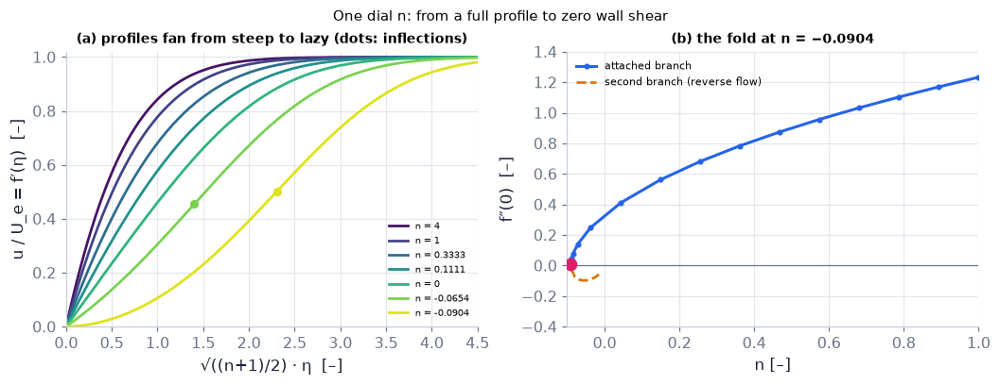

In [42]:
tab = BL.falkner_skan_table(fast=True)                           # our own Falkner-Skan table (23 exponents, 81 eta points): reused below
ns_show = (4, 1, 1/3, 1/9, 0, -0.0654, -0.0904)                  # the exponents of the book's Fig. 9.7
cols = plt.cm.viridis(np.linspace(0.05, 0.95, len(ns_show)))     # one colour per exponent
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.5, 3.6))   # the figure and its panels
for n_, c_ in zip(ns_show, cols):                                # (a) f' against the scaled variable sqrt((n+1)/2) eta
    s_ = BL.falkner_skan(n_)                                     # profile
    a1.plot(np.sqrt((n_ + 1)/2)*s_["eta"], s_["fp"], color=c_, lw=1.8, label=f"n = {n_:.4g}")   # draw the curve(s)
    ie = BL.falkner_skan_state(n_)["inflection_eta"]             # inflection point (None if there is none)
    if ie is not None:                                           # 0.0 (Blasius: inflection at the wall) is a real value, so test for None
        a1.plot(np.sqrt((n_ + 1)/2)*ie, np.interp(ie, s_["eta"], s_["fp"]), "o", color=c_, ms=5)   # dot on the profile
a1.set_xlim(0, 4.5); a1.set_ylim(0, 1.02); a1.set_xlabel("√((n+1)/2) · η  [–]"); a1.set_ylabel("u / U_e = f′(η)  [–]")   # axis labels (with units), limits and the panel's message
a1.legend(fontsize=6.5, frameon=False, loc="lower right"); a1.set_title("(a) profiles fan from steep to lazy (dots: inflections)", fontsize=9)   # axis labels (with units), limits and the panel's message
a2.plot(tab["m"], tab["fpp0"], "-o", color=COLORS["blue"], ms=3, label="attached branch")      # (b) the fold
a2.plot(tab["m"][0], tab["fpp0"][0], "o", color=COLORS["rose"], ms=8, zorder=5)                 # the last attached member
if not FAST:                                                     # the second branch (slow first call: the path is built once)
    mr = np.linspace(-0.0899, -0.015, 8)   # sample points
    fr = [BL.falkner_skan(m_, branch="reversed", n=5)["fpp0"] for m_ in mr]
    a2.plot(mr, fr, "--", color=COLORS["amber"], lw=1.8, label="second branch (reverse flow)")   # draw the curve(s)
a2.axhline(0, color=COLORS["muted"], lw=0.8); a2.set_xlim(-0.1, 1.0); a2.set_ylim(-0.4, 1.4)   # axis labels (with units), limits and the panel's message
a2.set_xlabel("n [–]"); a2.set_ylabel("f″(0)  [–]"); a2.legend(fontsize=7, frameon=False); a2.set_title("(b) the fold at n = −0.0904", fontsize=9)   # axis labels (with units), limits and the panel's message
fig.suptitle("One dial n: from a full profile to zero wall shear", fontsize=10)   # the figure's message as its title
plt.show()   # display the figure

**What you see.** Profiles fanning from steep (large $n$) to lazy (the last one has zero slope at the wall) in (a); a blue curve that ends at the red dot at $n=-0.0904$ and an amber dashed branch that continues back toward $n=0$ with negative $f''(0)$ in (b).

**How to read it.** A steeper wall slope means larger friction; the last blue curve has zero slope at the wall. In (b) the red dot is $f''(0)=0$: the attached branch stops there; the amber branch is the reversed-flow family.

**What would change if…** …$n=-0.1$: nothing at all — below the fold there is no attached bounded solution with $0\le f'\le1$ and $f'\to1$; the amber reversed branch also ends at the fold (it exists only for $-0.0904<n<0$). A layer marched into $n=-0.1$ separates (the bracket cell in C08).

In [43]:
rows = np.argsort(-tab["m"])                                     # table rows from the largest n (4) down to the fold
rows = rows[::2] if FAST else rows                               # FAST: every second row
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3.4), gridspec_kw=dict(width_ratios=[1.4, 1]), layout="none"); fixed_layout(fig)   # the figure and its panels
prof, = a1.plot([], [], color=COLORS["blue"], lw=2); tang, = a1.plot([], [], color=COLORS["ink"], lw=1.5); infl, = a1.plot([], [], "o", color=COLORS["rose"])   # draw the curve(s)
a1.set_xlim(0, 8); a1.set_ylim(0, 1.05); a1.set_xlabel("η [–]"); a1.set_ylabel("u / U_e = f′(η)  [–]")   # axis labels (with units), limits and the panel's message
a2.plot(tab["m"], tab["fpp0"], "-", color=COLORS["muted"], lw=1); mark, = a2.plot([], [], "o", color=COLORS["rose"], ms=8)   # draw the curve(s)
a2.set_xlim(-0.1, 4.1); a2.set_ylim(0, 2.6); a2.set_xlabel("n [–]"); a2.set_ylabel("f″(0)  [–]")   # axis labels (with units), limits and the panel's message


def update(j):                                                   # frame j = table row rows[j]
    r = rows[j]; n_ = tab["m"][r]; s0 = tab["fpp0"][r]
    prof.set_data(tab["eta"], tab["fp"][r])                      # the profile
    L_ = min(1.2, 0.95/max(s0, 1e-3))                            # length of the tangent segment in eta (kept inside the frame)
    tang.set_data([0, L_], [0, L_*s0])                           # the wall tangent: slope f''(0) at eta = 0
    ie = tab["inflection_eta"][r]
    infl.set_data([ie] if np.isfinite(ie) else [], [np.interp(ie, tab["eta"], tab["fp"][r])] if np.isfinite(ie) else [])   # inflection dot
    mark.set_data([n_], [s0])
    a1.set_title(f"n = {n_:.4f}:  f″(0) = {s0:.4f}", fontsize=9)   # axis labels (with units), limits and the panel's message
    return []   # the values for this call


show_animation(animate(update, frames=len(rows), fig=fig, interval=350), player="frames", dpi=64)   # a step player: stop at n = 0 and at the fold

**What you see.** The blue profile relaxes from a full curve to a lazy one; the black wall tangent lies down as $n$ decreases; the marker on the right slides down the $f''(0)$ curve to zero.

**How to read it.** Use the ◀ ▶ buttons to stop at $n=0$ (Blasius, inflection at the wall) and at the last frame ($n=-0.0903$: zero slope = zero shear).

**What would change if…** …run it backwards: the layer refills as the pressure gradient turns favourable.

In [44]:
rows = np.arange(len(tab["m"]))[::-1]                            # from the largest n down to the fold
rows = rows[::2] if FAST else rows
ms = tab["m"][rows]


def frame(m_):                                                   # curves for one exponent (slider value)
    r = int(np.argmin(np.abs(tab["m"] - m_)))
    s0 = tab["fpp0"][r]
    return {"profile f′(η)": (tab["fp"][r], tab["eta"]),         # note: u/U_e on x, eta on y
            "wall tangent (slope f″(0))": ([0, s0*min(1.5, 0.95/max(s0, 1e-9))], [0, min(1.5, 0.95/max(s0, 1e-9))])}   # tangent line u = f''(0) eta at the wall


fig = slider_figure(frame, "n", ms, unit="", xlabel="u / U_e = f′  [–]", ylabel="η [–]", title="", xrange=[0, 1.05], yrange=[0, 8])   # one figure whose curves follow the slider; every position precomputed (P17)
step_titles(fig, [f"n = {m_:.4f}: f″(0) = {tab['fpp0'][int(np.argmin(np.abs(tab['m'] - m_)))]:.4f}, H = {tab['H'][int(np.argmin(np.abs(tab['m'] - m_)))]:.3f}" for m_ in ms])   # a title with numbers for every slider position
recolor(fig, {"profile f′(η)": COLORS["blue"], "wall tangent (slope f″(0))": COLORS["ink"]})   # colours by meaning
fig.show()                                                       # interactive: drag n

**What you see.** The Falkner–Skan profile $f'(\eta)$ for the exponent $n$ on the slider, with the short wall tangent whose slope is the wall shear $f''(0)$ (value in the title).

**How to read it.** Slide $n$ from 4 down to the fold: the tangent swings up towards the $\eta$ axis as $f''(0)\to0$ at $n=-0.0904$ (zero wall shear: $u$ no longer grows at the wall); the profile first becomes S-shaped (an inflection) once $n<0$.

> ▶️ **Live cell.** The widget below needs a running Python kernel. On the web page it is frozen — open this notebook in Colab (button at the top) or run it locally to drag the sliders.

In [45]:
def fs_explorer(n=0.0, Re_x=1e4):                                # a free choice of n and Re_x: profile, delta(x) and tau0
    st = BL.falkner_skan_state(float(n)); s_ = BL.falkner_skan(float(n))
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(8, 3))   # the figure and its panels
    a1.plot(s_["fp"], s_["eta"], color=COLORS["blue"]); a1.set_xlabel("u / U_e"); a1.set_ylabel("η"); a1.set_title(f"n = {n:.3f}: f″(0) = {st['fpp0']:.4f}", fontsize=9)   # axis labels (with units), limits and the panel's message
    cf = 2*st["fpp0"]/np.sqrt(Re_x); a2.bar(["C_f"], [cf], color=COLORS["rose"]); a2.set_ylabel("C_f  [–]"); a2.set_title(f"C_f = 2 f″(0)/√Re_x = {cf:.4f}", fontsize=9)   # axis labels (with units), limits and the panel's message
    plt.show()   # display the figure


live(fs_explorer, n=(-0.09, 4.0, 0.01), Re_x=(1e3, 1e6, 1e3))   # kernel-only sliders (the page shows a note)

interactive(children=(FloatSlider(value=1.955, continuous_update=False, description='n', layout=Layout(width='…

<function __main__.fs_explorer(n=0.0, Re_x=10000.0)>

#### 🎮 Interactive: How can favourable and adverse gradients be one family?

**Why interactive rather than a static figure:** The profile, its curvature at the wall and the shear $f''(0)$ change continuously with $n$; the inflection slides in from infinity and the wall shear reaches zero at exactly one $n$ — seven static curves cannot show the approach.

**What to try:**
- Drag $n$ from 1 to 0 to −0.05: where does the inflection appear?
- Press the 'separation' preset: what is $f''(0)$ and the status?
- Switch the scaled variable to the book's $\sqrt{(n+1)/2}\,\eta$ and compare curves.
- Compare the terms bars: $u_{yy}$ and the pressure gradient are equal at the wall.

In [46]:
show_viz("ch09", "falkner_skan_family")   # full-width explainer; ⤢ Full screen for more room

[explainer ch09/falkner_skan_family]

*↪ **N48 [C]** Real flows are rarely of power-law form, which is why the approximate methods of the next two sections exist; the full numerical solution is Ch. 10.*

**What would change if…** …we do not want to solve an ODE at all? The momentum integral (C06) removes $y$ from the equation, at the price of guessing the profile.

---

## 9.5 Von Karman Momentum Integral Equation

**What is this section about?** Instead of solving for the whole profile, integrate the momentum equation across the layer. What remains is one ordinary differential equation in $x$ linking the three
quantities we already met — the momentum thickness $\theta$, the displacement thickness $\delta^*$ and the wall stress $\tau_0$ — for any pressure gradient, laminar or (time-averaged) turbulent. It has three
unknowns and one equation, so we need a closure; Thwaites' choice is the next section.

### 🧩 The von Kármán momentum integral equation `C06`

*The question:* Can we get the wall shear from an ordinary differential equation instead of the PDE?

*In one line:* $\frac1\rho\tau_0=\frac d{dx}\big[U_e^2\theta\big]+U_e\delta^*\frac{dU_e}{dx}$ *(9.43)*

> 🔁 **Tools from earlier chapters used here** (see `knowledge/primers.md`) — used in C06 and its derivation D08

- **Leibniz rule and differentiation under the integral sign** — with fixed limits d/dx ∫F dy = ∫∂F/∂x dy; moving limits add end terms (Ch. 3 P109).
- **Leibniz rule with a moving limit** — ∂/∂x ∫₀^(h(x)) u dy = ∫₀^h ∂u/∂x dy + u(x,h)∂h/∂x (Ch. 8 P189); here h is a constant height, so no end term.
- **fundamental theorem of calculus** — ∫ₐᵇ f′ dx = f(b) − f(a): an integral of a derivative is a difference of end values (Ch. 2 P84).

#### The problem in plain words

An engineer wants $\tau_0(x)$ along a wing or a duct for a given pressure distribution and has an afternoon, not a supercomputer. The layer equation is a PDE in $x$ and $y$; if we integrate it across the layer, $y$ disappears and
all we need is the size of the profile ($\theta$, $\delta^*$), not its shape.

#### The idea

```
d/dx (momentum flux U_e²θ)  +  (pressure-gradient term U_e δ* U_e′)  =  wall friction τ₀/ρ
```

A **momentum balance on a slab** of the layer: what leaves minus what enters = wall friction + pressure. It is the integral form of Ch. 4's control volume, done on the differential equation — that is why it holds for turbulent time averages too.

📝 **Note.** **N49 [B]** **Start.** With the pressure gradient replaced by *(9.11)*, $-\frac1\rho\frac{dp}{dx}=U_e\frac{dU_e}{dx}$, the layer equation reads $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=U_e\frac{dU_e}{dx}+\frac1\rho\frac{\partial\tau}{\partial y}$ *(9.37)* with $\tau=\mu\,\partial u/\partial y$.

$$ u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=U_e\frac{dU_e}{dx}+\frac1\rho\frac{\partial\tau}{\partial y} \qquad \text{(9.37)} $$

#### 🧮 Derivation — The von Kármán momentum integral: $\frac1\rho\tau_0=\frac d{dx}\big[U_e^2\theta\big]+U_e\delta^*\frac{dU_e}{dx}$ `D08` (Eq. 9.43: $\frac1\rho\tau_0=\frac d{dx}\big[U_e^2\theta\big]+U_e\delta^*\frac{dU_e}{dx}$)

**What we want to show.** Integrate the layer equation across the layer to get one ODE in x that any layer must obey.

**Assumptions.** Steady, incompressible; τ → 0 outside the layer; u = v = 0 at the wall.

**The plan.**

1. Put the equation in flux form.
2. Integrate over y.
3. Remove v with continuity.
4. Rearrange with the product rule.

**Tools we use** (each explained before this point): product rule (ch01 P38) · differentiation under the integral sign (ch03 P109) · Leibniz with a moving limit (ch08 P189) · fundamental theorem of calculus (ch02 P84).

**We start from**

$$ \text{(9.37)}\ u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=U_e\frac{dU_e}{dx}+\frac1\rho\frac{\partial\tau}{\partial y}\ \text{and (6.2)} $$

*In words:* (9.9), $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=-\frac1\rho\frac{dp}{dx}+\nu\frac{\partial^2u}{\partial y^2}$ with the pressure from (9.11), $-\frac1\rho\frac{dp}{dx}=U_e\frac{dU_e}{dx}$ and τ = μ∂u/∂y.

---

**Step 1 of 11 — Restate (9.37).**

$$ uu_x+vu_y=U_eU_e'+\frac1\rho\frac{\partial\tau}{\partial y}\ \text{(9.37)} $$

- *Why we can do this:* Replace −(1/ρ)dp/dx by U_eU_e′ using (9.11), $-\frac1\rho\frac{dp}{dx}=U_e\frac{dU_e}{dx}$ and νu_yy by (1/ρ)∂τ/∂y with τ = μu_y.
- *In words:* the layer equation with the outer forcing.

---

**Step 2 of 11 — Add u times continuity.**

$$ \frac{\partial(u^2)}{\partial x}+\frac{\partial(uv)}{\partial y}=U_eU_e'+\frac1\rho\frac{\partial\tau}{\partial y}\ \text{(9.38)} $$

- *Why we can do this:* (6.2), $\frac{\partial u}{\partial x}+\frac{\partial v}{\partial y}=0$ says u(u_x + v_y) = 0; adding gives 2uu_x + uv_y + vu_y, which the product rule reads as ∂(u²)/∂x + ∂(uv)/∂y.
- *In words:* the flux form.

---

**Step 3 of 11 — Integrate continuity across the layer.**

$$ \int_0^h\frac{\partial u}{\partial x}dy=-v(h)\ \text{, so}\ -v_\infty\ \text{as h → ∞ (9.39)} $$

- *Why we can do this:* u_x = −v_y and the fundamental theorem (P84): $-[v]_0^h$ with v(0) = 0 (no through-flow).
- *In words:* the layer's slowing pushes fluid outward.

---

**Step 4 of 11 — Integrate (9.38) up to a height h.**

$$ \int_0^h\partial_x(u^2)dy+U_ev(h)-U_eU_e'h=-\frac{\tau_0}\rho\ \text{(9.40)} $$

- *Why we can do this:* Fundamental theorem: [uv]₀ʰ = U_ev(h); τ(h) = 0 outside, τ(0) = τ₀. Keep h finite: ∫u²dy and ∫U_eU_e′dy diverge separately as h → ∞.
- *In words:* every term is now a number per unit x.

---

**Step 5 of 11 — Pull d/dx out, eliminate v(h).**

$$ \frac d{dx}\int_0^hu^2dy-U_eU_e'h-U_e\int_0^h\frac{\partial u}{\partial x}dy=-\frac{\tau_0}\rho\ \text{(9.41)} $$

- *Why we can do this:* h is a constant, so d/dx passes through the integral (P109); step 3 replaces v(h) by −∫u_xdy.
- *In words:* only integrals of u remain.

---

**Step 6 of 11 — Rewrite the last integral.**

$$ U_e\int_0^hu_x\,dy=\frac d{dx}\Big(U_e\int_0^hu\,dy\Big)-U_e'\int_0^hu\,dy $$

- *Why we can do this:* Product rule (P38): d(U_eG)/dx = U_e′G + U_eG′ with G = ∫u dy.
- *In words:* U_e moved inside the derivative.

---

**Step 7 of 11 — Substitute and collect.**

$$ \frac d{dx}\int_0^h(u^2-U_eu)\,dy+U_e'\int_0^h(u-U_e)\,dy=-\frac{\tau_0}\rho\ \text{(9.42)} $$

- *Why we can do this:* Combine the two d/dx terms; the leftover $-U_eU_e'h+U_e'\int u\,dy$ is $U_e'\int_0^h(u-U_e)dy$.
- *In words:* both integrands now vanish above the layer.

---

**Step 8 of 11 — Let h → ∞.**

$$ \text{the same with upper limits ∞} $$

- *Why we can do this:* Both integrands are zero where u = U_e, so each integral converges and the limit is allowed (the reason we combined them first).
- *In words:* h has dropped out.

---

**Step 9 of 11 — Factor out U_e², flip the sign.**

$$ \frac{\tau_0}\rho=\frac d{dx}\Big[U_e^2\!\int_0^\infty\!\frac u{U_e}\Big(1-\frac u{U_e}\Big)dy\Big]+U_e'U_e\!\int_0^\infty\!\Big(1-\frac u{U_e}\Big)dy $$

- *Why we can do this:* u² − U_eu = −U_e²(u/U_e)(1 − u/U_e) and u − U_e = −U_e(1 − u/U_e); U_e(x) is independent of y, so it moves in or out of the y-integrals.
- *In words:* dimensionless integrals.

---

**Step 10 of 11 — Name θ and δ*.**

$$ \frac1\rho\tau_0=\frac d{dx}\big[U_e^2\theta\big]+U_e\delta^*\frac{dU_e}{dx}\ \text{(9.43)} $$

- *Why we can do this:* The integrals are the definitions (9.17), $\theta=\int_0^\infty\frac u{U_e}\Big(1-\frac u{U_e}\Big)dy$ and (9.16), $\delta^*=\int_0^\infty\Big(1-\frac u{U_e}\Big)dy$.
- *In words:* wall friction = rate of change of momentum thickness + pressure-gradient term.

---

**Step 11 of 11 — Test on Blasius.**

$$ \frac{\tau_0}\rho=U^2\frac{d\theta}{dx}=\frac{0.332\,U^2}{\sqrt{Re_x}} $$

- *Why we can do this:* U_e = U constant, θ = 0.6641√(νx/U), dθ/dx = θ/(2x); the result equals (9.31), $\tau_0=\mu\Big(\frac{\partial u}{\partial y}\Big)_{y=0}=0.332\,\frac{\rho U^2}{\sqrt{\mathrm{Re}_x}}$.
- *In words:* (9.43), $\frac1\rho\tau_0=\frac d{dx}\big[U_e^2\theta\big]+U_e\delta^*\frac{dU_e}{dx}$ is exact, so it holds for every exact solution.

---

**Result**

$$ \frac1\rho\tau_0=\frac d{dx}[U_e^2\theta]+U_e\delta^*\frac{dU_e}{dx} $$

*In words:* one ODE linking θ, δ* and τ₀ for any layer, laminar or time-averaged turbulent; three unknowns need a closure.

**What it means.** Thwaites (C07), Ch. 12 (turbulent layers) and Ch. 14 all start here.

**Check it.** Units: τ₀/ρ = m²/s² and U²·dθ/dx = m²/s² ✓. `BL.momentum_integral_residual` is about $10^{-7}$ of the largest τ₀ or smaller (the code cell below prints 2.9e-7, 1.9e-7 and 3.6e-8 for its three layers). At x = 1 m in air τ₀/ρ = 1.286 × 10⁻³ m²/s².

> ⚠️ **Common confusion (traps in `D08`):** Letting h → ∞ before combining the integrals (each diverges); dropping the −v_∞ term; forgetting τ(∞) = 0.

📝 **Note.** **N50–N54 [B]** **The stations of D08, for reference.** Add $u$ times continuity: $\frac{\partial(u^2)}{\partial x}+\frac{\partial(uv)}{\partial y}=U_e\frac{dU_e}{dx}+\frac1\rho\frac{\partial\tau}{\partial y}$ *(9.38)*; integrate continuity:
$\int_0^\infty\frac{\partial u}{\partial x}dy=-v_\infty$ *(9.39)*; integrate *(9.38)*: $\int_0^\infty\big(\frac{\partial(u^2)}{\partial x}-U_e\frac{dU_e}{dx}\big)dy+U_ev_\infty=-\frac1\rho\tau_0$ *(9.40)*; eliminate $v_\infty$ and pull $d/dx$ out:
$\frac d{dx}\int_0^\infty u^2dy-\int_0^\infty U_e\frac{dU_e}{dx}dy-U_e\int_0^\infty\frac{\partial u}{\partial x}dy=-\frac1\rho\tau_0$ *(9.41)*; use the product rule to combine the integrals (each diverges alone, together they converge):
$\frac d{dx}\int_0^\infty(u^2-U_eu)\,dy+\frac{dU_e}{dx}\int_0^\infty(u-U_e)\,dy=-\frac1\rho\tau_0$ *(9.42)*; and the final rearrangement is *(9.43)* $\frac1\rho\tau_0=\frac d{dx}[U_e^2\theta]+U_e\delta^*\frac{dU_e}{dx}$.

📝 **Note.** **N55 [B]** **Closure problem.** *(9.43)*, $\frac1\rho\tau_0=\frac d{dx}\big[U_e^2\theta\big]+U_e\delta^*\frac{dU_e}{dx}$ has three unknowns ($\theta$, $\delta^*$, $\tau_0$) and one equation. Pohlhausen (1921) assumes a profile shape with one free parameter (a cubic in $y/\delta$); Thwaites (1949, C07) assumes instead that shear and shape depend on a single number $\lambda$.

#### ✏️ Tiny example: does Blasius satisfy (9.43)?

$U_e=U$ constant: $\tau_0/\rho=U^2\,d\theta/dx$. With $\theta=0.6641\sqrt{\nu x/U}$: $d\theta/dx=\theta/(2x)$; so $U^2\cdot0.6641\cdot\frac12\sqrt{\nu/(Ux)}=0.3321\,U^2/\sqrt{\mathrm{Re}_x}$ and $\tau_0/\rho=0.3321\,U^2/\sqrt{\mathrm{Re}_x}$ from
*(9.31)* $\tau_0=0.332\rho U^2/\sqrt{\mathrm{Re}_x}$ ✓ — the momentum integral is exact, so it must hold for every exact solution. At $x=1$ m in air: $\tau_0/\rho=1.286\times10^{-3}$ m²/s².

In [47]:
x6 = np.linspace(0.2, 1.0, 400)                                  # stations [m] (a fine grid: the residual is a difference of 4th-order finite differences)
for n_ in (0.0, 1/3, -0.05):                                     # three exact Falkner-Skan layers: flat plate, accelerating, decelerating
    st = BL.falkner_skan_state(n_)                               # I_delta, I_theta, f''(0) from the solved profile
    Ue = 1.0*x6**n_                                              # outer speed U_e = a x^n with a = 1 (units m^(1-n)/s) [m/s]
    scale = np.sqrt(NU_AIR*x6/Ue)                                # local similarity length sqrt(nu x / U_e) [m]
    theta = st["I_theta"]*scale; dstar = st["I_delta"]*scale     # theta and delta* [m]
    tau0 = RHO_AIR*NU_AIR*Ue*st["fpp0"]/scale                    # wall stress mu U_e f''(0) / delta  [Pa]  (rho nu = mu)
    r = BL.momentum_integral_residual(x6, Ue, theta, dstar, tau0, RHO_AIR)   # difference of the two sides of (9.43), 4th-order differences
    print(f"n = {n_:7.4f}: max residual / max tau0 = {np.abs(r).max()/np.abs(tau0).max():.1e}")   # expect about 1e-7

n =  0.0000: max residual / max tau0 = 2.9e-07
n =  0.3333: max residual / max tau0 = 1.9e-07
n = -0.0500: max residual / max tau0 = 3.6e-08


**What does the code above do?**

1. Build $\theta$, $\delta^*$ and $\tau_0$ of an exact Falkner–Skan layer from the solved profile: $\theta=I_\theta\sqrt{\nu x/U_e}$, $\delta^*=I_\delta\sqrt{\nu x/U_e}$, $\tau_0=\mu U_ef''(0)/\sqrt{\nu x/U_e}$ (D10 step 1 and 4 show why).
2. `momentum_integral_residual` is the difference between the two sides of *(9.43)*, $\frac1\rho\tau_0=\frac d{dx}\big[U_e^2\theta\big]+U_e\delta^*\frac{dU_e}{dx}$ using fourth-order finite differences; it is zero up to the discretisation (about $10^{-7}$ of $\tau_0$ on this grid) for every exact layer — flat, accelerating or decelerating.

In [48]:
# from scratch on Blasius: np.gradient for d(U^2 theta)/dx, compared with tau0/rho
xb = np.linspace(0.2, 1.0, 200)                                  # stations [m]
thb = BL.blasius_theta(xb, 1.0, NU_AIR)                          # theta(x) [m]
dth = np.gradient(1.0**2*thb, xb, edge_order=2)                  # d(U^2 theta)/dx [m/s^2] with U_e = U = 1
tau_b = BL.blasius_wall_shear(xb, 1.0, RHO_AIR, NU_AIR)          # exact wall stress [Pa]
assert np.allclose(RHO_AIR*dth, tau_b, rtol=3e-4)                # (9.43) with dU_e/dx = 0: tau0 = rho U^2 dtheta/dx
rb = BL.momentum_integral_residual(xb, np.ones_like(xb), thb, BL.blasius_delta_star(xb, 1.0, NU_AIR), tau_b, RHO_AIR)   # the library route
assert np.abs(rb).max() < 1e-5*tau_b.max()                       # both routes agree
print("tau0/rho at x = 1 m =", tau_b[-1]/RHO_AIR, "m^2/s^2   d(U^2 theta)/dx =", dth[-1])   # print the result

tau0/rho at x = 1 m = 0.0012860525331474437 m^2/s^2   d(U^2 theta)/dx = 0.0012860472976816695


**What does the code above do?**

1. `np.gradient` differentiates $U^2\theta(x)$ along the plate (here $U_e=U=1$ m/s, so $dU_e/dx=0$).
2. The momentum integral then says $\tau_0=\rho\,d(U^2\theta)/dx$; the assert compares that with the exact Blasius wall stress.
3. The library route `BL.momentum_integral_residual` must give (almost) zero on the same data.

In [49]:
xk = np.linspace(0.02, 1.0, 200)                                 # stations [m] (the assumed-profile solver needs x[0] > 0)
s1 = np.sqrt(NU_AIR*1.0/1.0)                                     # sqrt(nu x / U) at x = 1 m [m]
for prof in ("cubic", "sine"):                                   # two assumed profile shapes (ours): 3 eta/2 - eta^3/2 and sin(pi eta/2)
    kp = BL.karman_pohlhausen(BL.outer_flow("flat", U=1.0).Ue, xk, NU_AIR, profile=prof, rho=RHO_AIR)   # solve (9.43) for delta(x)
    tau_c = kp["tau0"][-1]/(RHO_AIR*NU_AIR/s1)                   # tau0 in units of mu U / sqrt(nu x / U)
    print(f"{prof:5s} delta = {kp['delta'][-1]/s1:.3f}  theta = {kp['theta'][-1]/s1:.4f} ({kp['theta'][-1]/s1/bc['theta'] - 1:+.1%})  "   # print the result
          f"delta* = {kp['delta_star'][-1]/s1:.3f} ({kp['delta_star'][-1]/s1/bc['delta_star'] - 1:+.1%})  tau0 coeff = {tau_c:.4f} ({tau_c/bc['tau_coeff'] - 1:+.1%})")

cubic delta = 4.641  theta = 0.6464 (-2.7%)  delta* = 1.740 (+1.1%)  tau0 coeff = 0.3232 (-2.7%)
sine  delta = 4.795  theta = 0.6551 (-1.4%)  delta* = 1.743 (+1.3%)  tau0 coeff = 0.3276 (-1.4%)


**What does the code above do?**

1. `karman_pohlhausen` closes *(9.43)*, $\frac1\rho\tau_0=\frac d{dx}\big[U_e^2\theta\big]+U_e\delta^*\frac{dU_e}{dx}$ by assuming a profile shape with one free length $\delta(x)$ (a cubic or a sine — our choices) and integrates the resulting ODE for $\delta$.
2. In units of $\sqrt{\nu x/U}$: the cubic gives $\delta=4.641$, $\theta=0.6464$ ($-2.7$ %), $\delta^*=1.740$ ($+1.1$ %) and a wall-stress coefficient 0.3232 ($-2.7$ %); the sine gives 4.795, 0.6551 and 0.3276 ($-1.4$ %).
3. An assumed shape closes *(9.43)* and lands within 3 % of Blasius — the idea Thwaites improves on (the closure there is fitted to exact solutions).

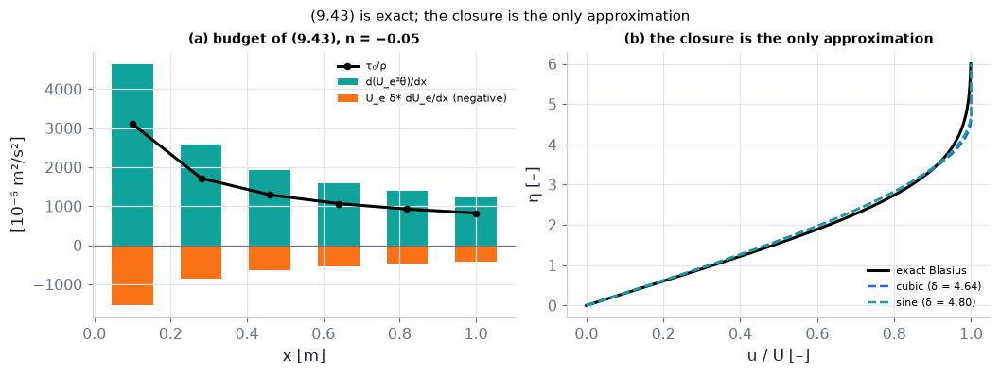

In [50]:
xs_b = np.linspace(0.1, 1.0, 6)                                  # stations for the bars [m]
st = BL.falkner_skan_state(-0.05); n_ = -0.05                    # a decelerating layer, a = 1
Ue = xs_b**n_; scale = np.sqrt(NU_AIR*xs_b/Ue)
theta = st["I_theta"]*scale; dstar = st["I_delta"]*scale
xf = np.linspace(0.05, 1.0, 300); Uf = xf**n_; sf = np.sqrt(NU_AIR*xf/Uf)   # sample points
th_f = st["I_theta"]*sf                                          # theta(x) on a fine grid, for the derivative
d_U2th = np.interp(xs_b, xf, np.gradient(Uf**2*th_f, xf, edge_order=2))    # d(U_e^2 theta)/dx at the bar stations [m/s^2]
pgterm = Ue*dstar*(n_*xs_b**(n_ - 1))                            # U_e delta* dU_e/dx  (negative for n < 0) [m/s^2]
tau_rho = NU_AIR*Ue*st["fpp0"]/scale                             # tau0 / rho [m/s^2]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.5, 3.5))   # the figure and its panels
w = 0.6*(xs_b[1] - xs_b[0])
a1.bar(xs_b, 1e6*d_U2th, w, color=COLORS["teal"], label="d(U_e²θ)/dx")                 # (a) the budget: the two terms stacked
a1.bar(xs_b, 1e6*pgterm, w, color=COLORS["orange"], label="U_e δ* dU_e/dx (negative)")   # bars
a1.plot(xs_b, 1e6*tau_rho, "k-o", ms=4, label="τ₀/ρ")                                   # their sum
a1.axhline(0, color=COLORS["muted"], lw=0.8); a1.set_xlabel("x [m]"); a1.set_ylabel("[10⁻⁶ m²/s²]"); a1.legend(fontsize=7, frameon=False); a1.set_title("(a) budget of (9.43), n = −0.05", fontsize=9)   # axis labels (with units), limits and the panel's message
eta = np.linspace(0, 6, 300); fpb = BL.blasius_profile(eta)[1]   # sample points
a2.plot(fpb, eta, "k-", lw=2, label="exact Blasius")                                    # (b) exact and assumed profiles
for name, col in (("cubic", COLORS["blue"]), ("sine", COLORS["teal"])):   # loop over the cases
    kp_ = BL.karman_pohlhausen(BL.outer_flow("flat", U=1.0).Ue, np.linspace(0.02, 1.0, 100), NU_AIR, profile=name, rho=RHO_AIR)   # sample points
    d_ = kp_["delta"][-1]/s1; u_ = np.where(eta < d_, 1.5*eta/d_ - 0.5*(eta/d_)**3 if name == "cubic" else np.sin(0.5*np.pi*eta/d_), 1.0)
    a2.plot(u_, eta, "--", color=col, lw=1.6, label=f"{name} (δ = {d_:.2f})")   # draw the curve(s)
a2.set_xlabel("u / U [–]"); a2.set_ylabel("η [–]"); a2.legend(fontsize=7, frameon=False, loc="lower right"); a2.set_title("(b) the closure is the only approximation", fontsize=9)   # axis labels (with units), limits and the panel's message
fig.suptitle("(9.43) is exact; the closure is the only approximation", fontsize=10)   # the figure's message as its title
plt.show()   # display the figure

**What you see.** In (a) the teal and (negative) orange bars add up to the black line; in (b) three profiles that lie close to each other, the exact one in black.

**How to read it.** For the adverse case the pressure-gradient term subtracts, so $\tau_0$ falls faster than the growth of $\theta$ alone would suggest; the exact identity holds whatever profile you believe in.

**What would change if…** …$n>0$: the orange term turns positive and adds to the friction.

**What would change if…** …we choose the closure from the exact Falkner–Skan family instead of a profile? Then $\theta$, $\delta^*$ and $\tau_0$ depend on the single number $\lambda$ and *(9.43)*, $\frac1\rho\tau_0=\frac d{dx}\big[U_e^2\theta\big]+U_e\delta^*\frac{dU_e}{dx}$ integrates in closed form: Thwaites, next.

---

## 9.6 Thwaites’ Method

**What is this section about?** The momentum integral *(9.43)* $\frac1\rho\tau_0=\frac d{dx}[U_e^2\theta]+U_e\delta^*\frac{dU_e}{dx}$ has three unknowns. Thwaites noticed that for the exact solutions the wall shear and the shape of
the profile both depend on a single dimensionless number, the pressure-gradient parameter $\lambda=(\theta^2/\nu)\,dU_e/dx$. With that closure *(9.43)* becomes a first-order linear equation whose solution is one integral of
$U_e^5$. Give the outer speed of any body and you get $\theta(x)$, the wall shear and the separation point in a minute of arithmetic. We build the closure from our own Falkner–Skan solutions, so the notebook does not need the
book's table.

### 🧩 Thwaites' method and the separation test `C07`

*The question:* Can one integral of the outer speed predict wall shear and separation without solving a PDE?

*In one line:* $\frac{\theta^2U_e^6}\nu=0.45\int_0^xU_e^5\,dx'+\frac{\theta_0^2U_0^6}\nu$ *(9.50)*

> 🔁 **Tools from earlier chapters used here** (see `knowledge/primers.md`) — used in C07

- **running integral with cumulative_trapezoid** — `cumulative_trapezoid(f, x, initial=0)` returns the running integral at every sample: the numerical antiderivative (Ch. 8 P190).
- **sign-change search with np.sign** — `np.sign` gives −1, 0, +1; neighbours of different sign bracket a crossing, `np.nonzero` lists where (Ch. 7 P180).
- **np.interp** — `np.interp(x_new, x, y)` reads a curve between samples along straight lines (Ch. 7 P182).
- **pressure-gradient sign convention** — adverse means $dp/dx>0$, i.e. a decelerating outer flow, $dU_e/dx<0$: the sign of λ = (θ²/ν)dU_e/dx is the opposite of that of dp/dx (C01, N11).

#### The problem in plain words

You have a pressure distribution on a duct wall or an airfoil — $U_e(x)$ from ideal-flow theory — and want to know: how thick does the layer get, how much friction does it cause, and does it separate, and where? The answer in one
pass: integrate $U_e^5$, read off $\lambda$, compare with the threshold.

#### The idea

```
U_e(x) ──► ∫U_e⁵dx ──► θ(x) ──► λ = (θ²/ν)U_e′ ──► l(λ), H(λ) ──► τ₀ = μ(U_e/θ) l(λ),  δ* = Hθ
                                       │
                              λ falls to the threshold (l = 0)  ⇒  τ₀ = 0  ⇒  separation predicted
```

The threshold is $\lambda=-0.09$ in Thwaites' fit (the book's criterion) and $\lambda=-0.0681$ on the exact Falkner–Skan family; both are reported.

📝 **Note.** **N56 [B], N57 [B], N58 [B]** **Definitions (Holstein–Bohlen).** The pressure-gradient parameter $\lambda\equiv\frac{\theta^2}\nu\frac{dU_e}{dx}$ *(9.44)* ($\lambda<0$: decelerating, adverse); the shear correlation
$\tau_0\equiv\mu\frac{U_e}\theta\,l(\lambda)$ *(9.45)*; the shape factor $\frac{\delta^*}\theta\equiv H(\lambda)$ *(9.46)*. The claim is that $l$ and $H$ depend on $\lambda$ alone.

> ⚠️ **Common confusion (names).** $\lambda$ here has nothing to do with the wavelength of Ch. 7; $L(\lambda)$ below is a correlation, while $L$ elsewhere is a length; Thwaites' own $m$ is $-\lambda$; and $\theta_0$ is the initial momentum thickness.

$$ \lambda\equiv\frac{\theta^2}\nu\frac{dU_e}{dx},\quad\tau_0\equiv\mu\frac{U_e}\theta\,l(\lambda),\quad\frac{\delta^*}\theta\equiv H(\lambda) \qquad \text{(9.44–9.46)} $$

📝 **Note.** **N59 [B]** **The closure, from our own solutions (the book's Table 9.1 is not reproduced).** For a Falkner–Skan layer everything depends on $n$ only: with $I_\delta=\int(1-f')d\eta$ and $I_\theta=\int f'(1-f')d\eta$,
$\lambda=nI_\theta^2$, $l=I_\theta f''(0)$, $H=I_\delta/I_\theta$ (D10 below). Solving *(9.36)*, $f'''+\frac{n+1}2ff''-nf'^2+n=0$ for 60 values of $n$ gives $l(\lambda)$ and $H(\lambda)$ for $-0.0681\le\lambda\le0.1065$ (`closure="falkner_skan"`); the attached
family ends at $\lambda=-0.0681$ (below it the exact closure returns $l=0$: separated) and above 0.1065 a fit scaled to match continues it. The book's own criterion is reproduced by `closure="white"`, the fit $l\approx(\lambda+0.09)^{0.62}$,
which reaches zero at $\lambda=-0.09$. Exact separation of the family: $\lambda=-0.068148$ (computed from the fold, `ch09.LAMBDA_SEP_FS`; written $-0.0681$ below; $l=0.004$, $H=3.97$ at $n=-0.0904$); Thwaites' fit puts $l=0$ at $\lambda=-0.09$ — two criteria, both reported.

In [51]:
tab7 = BL.thwaites_closure_table(60 if not FAST else 30)          # each row is one solved Falkner-Skan member: n, lambda, l, H, L
print(len(tab7["lam"]), "members, lambda from", round(float(tab7["lam"].min()), 4), "to", round(float(tab7["lam"].max()), 4))   # print the result
print("   lambda      l(lambda)   H(lambda)")   # print the result
for lam in (-0.06, 0.0, 0.0855):                                 # adverse, Blasius, Hiemenz (stagnation)
    print(f"{lam:9.4f} {BL.thwaites_l(lam):11.4f} {BL.thwaites_H(lam):11.4f}")   # PCHIP interpolation between the rows
print("near the fold:", BL.thwaites_l(-0.0675), BL.thwaites_H(-0.0675), "| exact-family l at lambda = -0.0681:", BL.thwaites_l(-0.0681))   # print the result
print("(9.44) with numbers: theta = 2.572 mm, dU_e/dx = -1 1/s ->", BL.holstein_bohlen(2.572e-3, -1.0, NU_AIR))   # lambda = theta^2 dU/dx / nu

64 members, lambda from -0.0681 to 0.106
   lambda      l(lambda)   H(lambda)
  -0.0600      0.0649      3.3557
   0.0000      0.2205      2.5911
   0.0855      0.3604      2.2161
near the fold: 0.016685182776709048 3.8099315757925063 | exact-family l at lambda = -0.0681: 0.0013850322140327627
(9.44) with numbers: theta = 2.572 mm, dU_e/dx = -1 1/s -> -0.44101226666666665


**What does the code above do?**

1. `thwaites_closure_table` solves *(9.36)*, $f'''+\frac{n+1}2ff''-nf'^2+n=0$ for 60 exponents and stores $\lambda=nI_\theta^2$, $l=I_\theta f''(0)$, $H=I_\delta/I_\theta$ and $L=2l-2(2+H)\lambda$ for each.
2. `thwaites_l` and `thwaites_H` interpolate between the rows with PCHIP: $l(0)=0.2205$, $H(0)=2.591$ (Blasius); at $\lambda=0.0855$ (stagnation) $l=0.360$, $H=2.216$; near $-0.0675$ the shear has almost gone ($l\approx0.017$) and $H\approx3.8$.
3. `holstein_bohlen` evaluates *(9.44)*, $\lambda\equiv\frac{\theta^2}\nu\frac{dU_e}{dx}$ for given $\theta$, $dU_e/dx$ and $\nu$: a 2.6 mm layer in a stream decelerating at 1 s⁻¹ has $\lambda=-0.44$ — far beyond separation, so such a strong deceleration cannot be resisted.

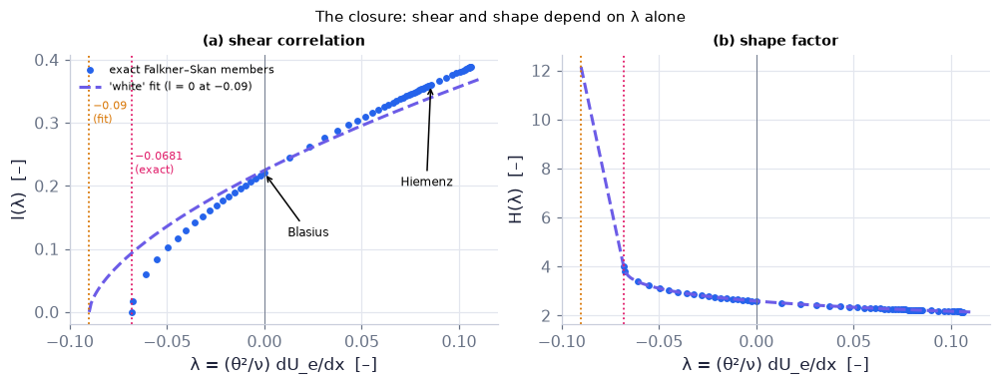

In [52]:
lam_w = np.linspace(-0.09, 0.11, 200)                            # lambda range for the fit
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3.4))   # the figure and its panels
a1.plot(tab7["lam"], tab7["l"], "o", color=COLORS["blue"], ms=3.5, label="exact Falkner–Skan members")     # (a) l(lambda)
a1.plot(lam_w, BL.thwaites_l(lam_w, closure="white"), "--", color=COLORS["accent"], label="'white' fit (l = 0 at −0.09)")   # draw the curve(s)
a2.plot(tab7["lam"], tab7["H"], "o", color=COLORS["blue"], ms=3.5); a2.plot(lam_w, BL.thwaites_H(lam_w, closure="white"), "--", color=COLORS["accent"])   # (b) H(lambda)
for a_, yl in ((a1, "l(λ)  [–]"), (a2, "H(λ)  [–]")):   # loop over the cases
    a_.axvline(-0.0681, color=COLORS["rose"], ls=":", lw=1.2); a_.axvline(-0.09, color=COLORS["amber"], ls=":", lw=1.2)     # the two separation criteria
    a_.axvline(0.0, color=COLORS["muted"], lw=0.6); a_.set_xlabel("λ = (θ²/ν) dU_e/dx  [–]"); a_.set_ylabel(yl)   # axis labels (with units), limits and the panel's message
a1.text(-0.0665, 0.22, "−0.0681\n(exact)", color=COLORS["rose"], fontsize=7); a1.text(-0.088, 0.30, "−0.09\n(fit)", color=COLORS["amber"], fontsize=7)   # a label written on the plot
a1.annotate("Blasius", (0, BL.thwaites_l(0.0)), xytext=(0.012, 0.12), fontsize=8, arrowprops=dict(arrowstyle="->")); a1.annotate("Hiemenz", (0.0855, BL.thwaites_l(0.0855)), xytext=(0.07, 0.2), fontsize=8, arrowprops=dict(arrowstyle="->"))   # a label written on the plot
a1.legend(fontsize=7, frameon=False, loc="upper left"); a1.set_title("(a) shear correlation", fontsize=9); a2.set_title("(b) shape factor", fontsize=9)   # axis labels (with units), limits and the panel's message
fig.suptitle("The closure: shear and shape depend on λ alone", fontsize=10)   # the figure's message as its title
plt.show()   # display the figure

**What you see.** Blue dots (our exact solutions) rising smoothly in (a) and falling in (b); a purple dashed fit through them; two vertical dotted lines at the separation thresholds.

**How to read it.** At $\lambda=0$ (Blasius) $l=0.22$, $H=2.59$; near $-0.07$ the shear is almost zero and $H\approx4$; the exact family stops at $-0.0681$, where the fit still shows some shear until $-0.09$.

**What would change if…** …a stronger favourable gradient: $H$ tends to 2.1 and $l$ saturates.

> 📎 **Primer — first-order linear ODE and the integrating factor.** `P210` · An equation $y'+p(x)\,y=q(x)$ is solved by multiplying by a *factor* $\mu(x)$ chosen so that the left side is one derivative: with $\mu'=p\mu$ ($\mu=e^{\int p}$) we get $(\mu y)'=\mu q$, which integrates directly.
Here $p=6U_e'/U_e$, so $\mu=U_e^6$.

In [53]:
import sympy as sp   # symbolic algebra
x = sp.symbols('x', positive=True)   # symbols for sympy
z = sp.Function('z')   # symbols for sympy
print(sp.dsolve(sp.Eq(z(x).diff(x) + 6/x*z(x), 1), z(x)))   # z = x/7 + C/x**6: the factor x**6 makes (x**6 z)' = x**6

Eq(z(x), C1/x**6 + x/7)


#### 🧮 Derivation — Thwaites' closed form: $\frac{\theta^2U_e^6}\nu=0.45\int_0^xU_e^5dx'+\frac{\theta_0^2U_0^6}\nu$ `D09` (Eq. 9.50: $\frac{\theta^2U_e^6}\nu=0.45\int_0^xU_e^5\,dx'+\frac{\theta_0^2U_0^6}\nu$)

**What we want to show.** Turn the momentum integral (9.43), $\frac1\rho\tau_0=\frac d{dx}\big[U_e^2\theta\big]+U_e\delta^*\frac{dU_e}{dx}$, with an empirical closure, into a formula that gives θ(x) from one integral of the outer speed.

**Assumptions.** l and H are functions of λ only (empirical, checked in D10); the linear fit L ≈ 0.45 − 6λ (step 9).

**The plan.**

1. Make (9.43), $\frac1\rho\tau_0=\frac d{dx}\big[U_e^2\theta\big]+U_e\delta^*\frac{dU_e}{dx}$ dimensionless.
2. Express everything through λ, l and H.
3. Eliminate θ to get an equation for λ.
4. Use Thwaites' linear fit and an integrating factor.

**Tools we use** (each explained before this point): product rule (ch01 P38) · first-order linear ODE and the integrating factor (primer P210) · sympy `dsolve` (ch01 P40).

**We start from**

$$ \begin{array}{l}\text{(9.43)}\ \frac1\rho\tau_0=\frac d{dx}[U_e^2\theta]+U_e\delta^*\frac{dU_e}{dx}\ \text{with the definitions}\ \lambda=\frac{\theta^2}\nu\frac{dU_e}{dx}\ \text{(9.44),} \\ \tau_0=\mu\frac{U_e}\theta l(\lambda)\ \text{(9.45),}\ \frac{\delta^*}\theta=H(\lambda)\ \text{(9.46)}\end{array} $$

*In words:* three unknowns, but shear and shape are assumed to depend on λ alone.

---

**Step 1 of 10 — Restate (9.43).**

$$ \frac{\tau_0}\rho=\frac d{dx}\big[U_e^2\theta\big]+U_e\delta^*U_e' $$

- *Why we can do this:* Starting point: one equation, three unknowns (θ, δ*, τ₀).
- *In words:* we must close it.

---

**Step 2 of 10 — Multiply by $\rho\theta/(\mu U_e)$.**

$$ \frac{\theta\tau_0}{\mu U_e}=\frac{\theta}{\nu U_e}\frac{d(U_e^2\theta)}{dx}+\frac{\theta\delta^*U_e'}\nu\ \text{(9.47)} $$

- *Why we can do this:* With ν = μ/ρ every term becomes dimensionless and θ²/ν appears, the combination in λ.
- *In words:* a dimensionless form.

---

**Step 3 of 10 — Expand the derivative.**

$$ \frac{d(U_e^2\theta)}{dx}=2U_eU_e'\,\theta+U_e^2\,\theta' $$

- *Why we can do this:* Product rule (P38) on $U_e^2\theta$: both factors depend on $x$, and expanding separates the pressure-gradient part $U_eU_e'\theta$ from the growth part $\theta'$.
- *In words:* two pieces.

---

**Step 4 of 10 — Collect the terms.**

$$ \frac{\theta\tau_0}{\mu U_e}=2\frac{\theta^2}\nu U_e'+\frac{U_e\theta\theta'}\nu+\frac{\theta^2}\nu\frac{\delta^*}\theta U_e' $$

- *Why we can do this:* Multiply out $\frac\theta{\nu U_e}(2U_eU_e'\theta+U_e^2\theta')$ and rewrite the last term with δ* = (δ*/θ)θ.
- *In words:* every piece has θ²/ν or θθ′.

---

**Step 5 of 10 — Recognise λ, H and θθ′.**

$$ \frac{\theta\tau_0}{\mu U_e}=(2+H)\lambda+\frac{U_e}2\frac d{dx}\Big(\frac{\theta^2}\nu\Big) $$

- *Why we can do this:* λ = θ²U_e′/ν (9.44), δ*/θ = H (9.46), $\frac{\delta^*}\theta\equiv H(\lambda)$, and θθ′ = ½(θ²)′ by the chain rule.
- *In words:* two terms: pressure gradient and growth.

---

**Step 6 of 10 — Use the shear correlation.**

$$ l(\lambda)=(2+H)\lambda+\frac{U_e}2\frac d{dx}\Big(\frac{\theta^2}\nu\Big) $$

- *Why we can do this:* (9.45), $\tau_0\equiv\mu\frac{U_e}\theta\,l(\lambda)$ makes the left side exactly l(λ) (the unnumbered relation the book states without the algebra).
- *In words:* l is fixed by λ and the growth of θ².

---

**Step 7 of 10 — Eliminate θ with (9.44).**

$$ \frac{\theta^2}\nu=\frac\lambda{U_e'} $$

- *Why we can do this:* Invert the definition of λ, so the only unknown function is λ(x).
- *In words:* θ² is λ over the pressure gradient.

---

**Step 8 of 10 — Define the universal function.**

$$ U_e\frac d{dx}\Big(\frac\lambda{U_e'}\Big)=2l-2(2+H)\lambda\equiv L(\lambda)\ \text{(9.48)} $$

- *Why we can do this:* Multiply step 6 by 2 and insert step 7; l and H depend on λ alone, so the right side is a function of λ only.
- *In words:* one equation for λ(x).

---

**Step 9 of 10 — Use Thwaites' linear fit.**

$$ L\approx0.45-6\lambda\ \Rightarrow\ \frac d{dx}\Big(\frac{\theta^2}\nu\Big)+\frac{6U_e'}{U_e}\frac{\theta^2}\nu=\frac{0.45}{U_e}\ \text{(9.49)} $$

- *Why we can do this:* With Z = θ²/ν = λ/U_e′, (9.48), $U_e\frac d{dx}\Big(\frac\lambda{U_e'}\Big)=2l-2(2+H)\lambda\equiv L(\lambda)$ reads U_eZ′ = 0.45 − 6ZU_e′; divide by U_e. The fit is empirical (D10).
- *In words:* a linear ODE for θ²/ν.

---

**Step 10 of 10 — Multiply by the integrating factor $U_e^6$.**

$$ \frac d{dx}\Big(U_e^6\frac{\theta^2}\nu\Big)=0.45\,U_e^5\ \Rightarrow\ \frac{\theta^2U_e^6}\nu=0.45\int_0^xU_e^5dx'+\frac{\theta_0^2U_0^6}\nu\ \text{(9.50)} $$

- *Why we can do this:* μ′ = (6U_e′/U_e)μ gives μ = U_e⁶ (P210), turning the left side into one derivative; integrate from x = 0, the constant coming from the initial θ₀ (zero at a stagnation point).
- *In words:* θ² is one integral of U_e⁵.

---

**Result**

$$ \theta^2=\frac{0.45\,\nu}{U_e^6(x)}\int_0^xU_e^5dx'+\frac{\theta_0^2U_0^6}{U_e^6(x)}\ \text{(9.50); then λ (9.44), τ₀ (9.45), δ} $$

*In words:* the layer remembers the whole pressure history through ∫U_e⁵.

**What it means.** One integral, a few lines of arithmetic: predicts shear and separation for any body given its ideal-flow speed.

**Check it.** Units: θ²U_e⁶/ν = m⁶/s⁵ and ∫U_e⁵dx = m⁶/s⁵ ✓. U_e = U: θ² = 0.45νx/U ⇒ θ = 0.6708√(νx/U), 1.0 % above Blasius 0.6641 ✓ (`ch09.example_9_1()`). Diffuser U_e = U₁/(1 + x/L): λ = −(0.45/4)[(1 + x/L)⁴ − 1] ✓.

> ⚠️ **Common confusion (traps in `D09`):** Where 0.45 and 6.0 come from (an empirical fit, not derivation); the integrating factor U_e⁶ blows up at a stagnation point, so θ₀ = 0 and the limit θ² ∝ x is needed; l and H are *closures*, not consequences of (9.43), $\frac1\rho\tau_0=\frac d{dx}\big[U_e^2\theta\big]+U_e\delta^*\frac{dU_e}{dx}$.

📝 **Note.** **N60–N64 [B]** **The stations of D09, for reference.** Multiply *(9.43)*, $\frac1\rho\tau_0=\frac d{dx}\big[U_e^2\theta\big]+U_e\delta^*\frac{dU_e}{dx}$ by $\rho\theta/(\mu U_e)$: $\frac{\theta\tau_0}{\mu U_e}=\frac\theta{\nu U_e}\frac{d(U_e^2\theta)}{dx}+\frac{\theta\delta^*}\nu\frac{dU_e}{dx}$ *(9.47)*; the book then states, without the algebra,
$l(\lambda)=(2+H)\lambda+\frac{U_e}2\frac{d}{dx}\big(\frac{\theta^2}\nu\big)$ (the step we added); the universal function is $U_e\frac d{dx}\big(\frac\lambda{U_e'}\big)=2l-2(2+H)\lambda\equiv L(\lambda)$ *(9.48)*; and with Thwaites' linear fit
$\frac d{dx}\big(\frac{\theta^2}\nu\big)+\frac{6U_e'}{U_e}\frac{\theta^2}\nu=\frac{0.45}{U_e}$ *(9.49)*, whose integrating factor is $U_e^6$.

📝 **Note.** **N63 [B]** **Fig. 9.8 remade: the fit $L\approx0.45-6.0\lambda$.** On the Falkner–Skan family $L(\lambda)=2l-2(2+H)\lambda$ is nearly linear (0.441 at Blasius; 0.818 at $\lambda=-0.0675$; about 0 at $n=1$); the line $0.45-6\lambda$ is Thwaites'
fit to several *families* (Falkner–Skan, Schubauer's ellipse, Howarth's linear retardation, Iglisch). It is a fit, not exact — D10 below measures how good.

#### 🧮 Derivation — The exact closure on the Falkner–Skan family: λ = nI_θ², l = I_θ f″(0), H = I_δ/I_θ, and L(λ) against 0.45 − 6λ `D10` (Eq. 9.48: $U_e\frac d{dx}\Big(\frac\lambda{U_e'}\Big)=2l-2(2+H)\lambda\equiv L(\lambda)$)

**What we want to show.** Build the functions l(λ) and H(λ) of (9.45), $\tau_0\equiv\mu\frac{U_e}\theta\,l(\lambda)$, (9.46), $\frac{\delta^*}\theta\equiv H(\lambda)$ from our own solved layers, and see how good Thwaites' linear fit of L(λ) is.

**Assumptions.** Similar flows only; the closure is exact for them and a fit across families.

**The plan.**

1. Express θ, δ*, τ₀ and λ through integrals of f.
2. Tabulate over n.
3. Evaluate L and compare with the line.

**Tools we use** (each explained before this point): Falkner–Skan solver (C05) · PCHIP interpolation (primer P204) · sympy for the identities (ch01 P40).

**We start from**

$$ \text{Falkner–Skan solutions of}\ f'''+\frac{n+1}2ff''-nf'^2+n=0\ \text{(9.36) for}\ U_e=ax^n $$

*In words:* for these flows every quantity is a function of n only, so it is a function of λ only.

---

**Step 1 of 9 — Use the local scale.**

$$ \theta=I_\theta\sqrt{\tfrac{\nu x}{U_e}},\ \ \delta^*=I_\delta\sqrt{\tfrac{\nu x}{U_e}} $$

- *Why we can do this:* For Falkner–Skan y = δη with δ = √(νx/U_e), so (9.17), $\theta=\int_0^\infty\frac u{U_e}\Big(1-\frac u{U_e}\Big)dy$ and (9.16), $\delta^*=\int_0^\infty\Big(1-\frac u{U_e}\Big)dy$ become integrals in η: $I_\theta=\int f'(1-f')d\eta$, $I_\delta=\int(1-f')d\eta$ (as in D06 steps 5–6).
- *In words:* thicknesses in units of the local scale.

---

**Step 2 of 9 — Form the shape factor.**

$$ H=\frac{\delta^*}\theta=\frac{I_\delta}{I_\theta}\ \text{(9.46)} $$

- *Why we can do this:* Ratio of the two integrals; the common scale cancels.
- *In words:* H depends on n only.

---

**Step 3 of 9 — Form λ.**

$$ \lambda=\frac{\theta^2}\nu U_e'=n\,I_\theta^2\ \text{(9.44)} $$

- *Why we can do this:* θ² = I_θ²νx/U_e and U_e′ = nU_e/x, so x and U_e cancel.
- *In words:* λ depends on n only.

---

**Step 4 of 9 — Form the wall shear.**

$$ \tau_0=\mu\frac{U_e}{\delta}f''(0)=\mu\frac{U_e}\theta\,I_\theta f''(0) $$

- *Why we can do this:* The wall slope of u = U_ef′(η) is U_ef″(0)/δ; multiply and divide by θ = I_θδ.
- *In words:* the shear in the form of (9.45), $\tau_0\equiv\mu\frac{U_e}\theta\,l(\lambda)$.

---

**Step 5 of 9 — Read off l.**

$$ l=\frac{\theta\tau_0}{\mu U_e}=I_\theta\,f''(0)\ \text{(9.45)} $$

- *Why we can do this:* Compare the line above with the definition $\tau_0\equiv\mu\frac{U_e}\theta l(\lambda)$: what multiplies $\mu U_e/\theta$ is $l$, and it contains no $x$.
- *In words:* l depends on n only.

---

**Step 6 of 9 — Tabulate over n.**

$$ n\ \mapsto\ (\lambda,\ l,\ H) $$

- *Why we can do this:* Solve (9.36), $f'''+\frac{n+1}2ff''-nf'^2+n=0$ for 60 values from just above the fold (−0.0904) to large n; PCHIP through the rows (P204) gives l(λ), H(λ) on −0.0681 ≤ λ ≤ 0.1065.
- *In words:* our own closure table.

---

**Step 7 of 9 — Evaluate the universal function.**

$$ L=2l-2(2+H)\lambda\ \text{(9.48)} $$

- *Why we can do this:* Apply the definition to each row: Blasius (λ = 0) 2 × 0.2205 = 0.441; n = 1 (λ = 0.0855) 0.7207 − 0.7206 ≈ 0; λ = −0.0675 gives 0.818.
- *In words:* a nearly straight function of λ.

---

**Step 8 of 9 — Compare with the line.**

$$ 0.45-6\lambda:\ 0.450,\ -0.063,\ 0.855\ \text{at}\ \lambda=0,\ 0.0855,\ -0.0675 $$

- *Why we can do this:* Thwaites fitted several families (Falkner–Skan, Schubauer's ellipse, Howarth); along Falkner–Skan alone the line is 0.01 too high at Blasius, 0.06 too low for strong acceleration, 0.04 too high near separation.
- *In words:* a good fit, not exact.

---

**Step 9 of 9 — Note the two separation criteria.**

$$ l(\lambda_{sep})=0\ \text{: exact family}\ \lambda=-0.0681\ \text{(}\ H\approx4.0\ \text{); Thwaites' fit}\ \lambda=-0.09 $$

- *Why we can do this:* The attached family ends at the fold n = −0.0904 where f″(0) = 0 (l = 0); the empirical table puts l = 0 at −0.09. We report both.
- *In words:* two thresholds, 0.0681 and 0.09.

---

**Result**

$$ \begin{array}{l}\lambda=nI_\theta^2,\ l=I_\theta f''(0),\ H=I_\delta/I_\theta\ \text{;}\ L(\lambda)\approx0.45-6\lambda\ \text{within 0.063 (worst at λ = 0.0855; within} \\ \text{0.05 on −0.068 ≤ λ ≤ 0.05)}\end{array} $$

*In words:* Thwaites' closure is exact for similar flows and a fit for the rest.

**What it means.** The closure is why Thwaites' method is good to a few per cent for smooth outer flows and poor for strong acceleration (measured: θ −6 % at n = 1, −8 % at n = 4).

**Check it.** Blasius: $I_\theta=0.6641$, $f''(0)=0.33206$ ⇒ $l=0.2205$, $H=2.5911$; $n=1$: $\lambda=0.0855$, $l=0.3604$, $H=2.216$ — the rows that `BL.thwaites_closure_table` prints in the code cell below. Thwaites' own fit of $l(\lambda)$, $H(\lambda)$ is the `closure="white"` option of `BL.thwaites`; the figure below shows how it departs from the exact family as λ approaches separation.

> ⚠️ **Common confusion (traps in `D10`):** The fit is *not* exact for Falkner–Skan; two separation thresholds (−0.0681 exact, −0.09 Thwaites); l(λ) is undefined beyond the fold.

In [54]:
lamF = tab7["lam"]; LF = tab7["L"]                               # the family: lambda and L(lambda) at every member
order_ = np.argsort(lamF); lam_sorted, L_sorted = lamF[order_], LF[order_]
mem = np.linspace(0, len(lamF) - 1, 30 if not FAST else 12).astype(int)   # which members the slider visits
line_x = np.linspace(-0.07, 0.11, 50)   # sample points


def frame(i):                                                    # curves for the highlighted member i
    i = int(i)
    return {"L(λ) on Falkner–Skan members": (lam_sorted, L_sorted),   # the values for this call
            "line 0.45 − 6λ": (line_x, 0.45 - 6*line_x),
            "member": ([lamF[i]], [LF[i]])}


fig = slider_figure(frame, "member", mem, unit="", xlabel="λ  [–]", ylabel="L(λ) = 2l − 2(2+H)λ  [–]", title="",   # one figure whose curves follow the slider; every position precomputed (P17)
                    xrange=[-0.075, 0.115], yrange=[-0.2, 1.0], modes={"member": "markers"})
recolor(fig, {"L(λ) on Falkner–Skan members": COLORS["blue"], "line 0.45 − 6λ": COLORS["accent"], "member": COLORS["rose"]}, dashes={"line 0.45 − 6λ": "dash"})   # colours by meaning
step_titles(fig, [f"member {int(i)} of {len(lamF) - 1}: n = {tab7['m'][int(i)]:.4f}, λ = {lamF[int(i)]:.4f}, L = {LF[int(i)]:.3f} vs line {0.45 - 6*lamF[int(i)]:.3f}" for i in mem])   # a title with numbers for every slider position
fig.show()                                                       # drag the member index: the rose dot walks along the family

**What to try:** drag the slider — the rose dot walks along the exact family and stays within a few hundredths of Thwaites' line; the gap is largest at the strongly accelerating end ($\lambda\approx0.1$), where the line is 0.06 too low.

📝 **Note.** **N65 [B]** **Accuracy.** The book quotes ±3 % (favourable) and ±10 % (adverse) and warns that Thwaites predicts *whether* a layer separates better than *where*. We measure it on the exact Falkner–Skan family: the ratio
$\theta_{Thwaites}/\theta_{exact}=\sqrt{0.45/((5n+1)I_\theta^2)}$ (from *(9.50)*, $\frac{\theta^2U_e^6}\nu=0.45\int_0^xU_e^5\,dx'+\frac{\theta_0^2U_0^6}\nu$ with $\int_0^xU_e^5dx'=a^5x^{5n+1}/(5n+1)$) is printed below instead of quoting percentages.

In [55]:
print("     n    theta error of Thwaites' fit vs the exact Falkner-Skan layer")   # print the result
for n in (-0.05, 0.0, 1/3, 1.0, 4.0):   # loop over the cases
    st = BL.falkner_skan_state(n)                                # exact I_theta for this member
    err = np.sqrt(0.45/((5*n + 1)*st["I_theta"]**2)) - 1         # theta_Thwaites / theta_exact - 1
    print(f"{n:8.3f}   {err:+.1%}")                              # +3.1 %, +1.0 %, -4.2 %, -6.3 %, -7.6 %

     n    theta error of Thwaites' fit vs the exact Falkner-Skan layer
  -0.050   +3.1%
   0.000   +1.0%
   0.333   -4.2%
   1.000   -6.3%
   4.000   -7.6%


**What does the code above do?**

1. For $U_e=ax^n$: $\int_0^xU_e^5=a^5x^{5n+1}/(5n+1)$, so *(9.50)*, $\frac{\theta^2U_e^6}\nu=0.45\int_0^xU_e^5\,dx'+\frac{\theta_0^2U_0^6}\nu$ gives $\theta^2=0.45\,\nu x/((5n+1)U_e)$, i.e. $\theta/\sqrt{\nu x/U_e}=\sqrt{0.45/(5n+1)}$, to be compared with the exact $I_\theta$.
2. The fit $L=0.45-6\lambda$ is best near Blasius (+1.0 %); for strong acceleration it undershoots $\theta$ by up to 8 %, and near separation it overshoots by a few per cent — measured, not the book's percentages.

📝 **Note.** **N66 [B]** **Example 9.1.** Thwaites' method applied to a flat plate ($U_e=U$): the worked example and the code cell below show that one integral of a constant reproduces Blasius to about 1 %.

#### ✏️ Tiny example: Example 9.1 — Thwaites for a flat plate

$U_e=U$ constant, so $U_e'=0$, $\lambda=0$, and *(9.50)* $\frac{\theta^2U_e^6}\nu=0.45\int_0^xU_e^5dx'+\frac{\theta_0^2U_0^6}\nu$ with $\theta_0=0$ gives $\theta^2=0.45\nu x/U$, $\theta=0.6708\sqrt{\nu x/U}$: 1.0 % above the exact Blasius 0.6641.
$\delta^*=H(0)\theta=2.591\times0.6708=1.738\sqrt{\nu x/U}$ (+1.0 % over 1.721). $\tau_0=\mu(U/\theta)\,l(0)$ gives $C_f\sqrt{\mathrm{Re}_x}=2l(0)/0.6708=0.6575$ (−1.0 % against 0.6641). One integral of a constant reproduces Blasius to 1 %.

In [56]:
ex = ch09.example_9_1()                                          # Example 9.1 in closed form (theta coefficient, delta*, Cf)
print({k: round(float(ex[k]), 4) for k in ("theta_coef", "theta_err", "delta_star_coef", "cf_sqrtRex", "cf_err")})   # print the result
xp = np.linspace(0.0, 1.0, 401)                                  # numerical route: march (9.50) along a 1 m plate
tp = BL.thwaites(xp, BL.outer_flow("flat", U=1.0).Ue, NU_AIR)    # theta, delta*, tau0, cf, lambda ... along x
print("theta(1 m) =", 1e3*tp["theta"][-1], "mm  (0.6708 x 3.873 mm =", 1e3*ex["theta_coef"]*np.sqrt(NU_AIR), "mm)")   # print the result
assert np.isclose(tp["theta"][-1], ex["theta_coef"]*np.sqrt(NU_AIR), rtol=1e-6)   # closed form and marching agree

{'theta_coef': 0.6708, 'theta_err': 0.0101, 'delta_star_coef': 1.7382, 'cf_sqrtRex': 0.6575, 'cf_err': -0.01}
theta(1 m) = 2.598076211353316 mm  (0.6708 x 3.873 mm = 2.598076211353316 mm)


**What does the code above do?**

1. `example_9_1` is the closed form of the worked example: $\theta=0.6708\sqrt{\nu x/U}$ (+1.0 %), $\delta^*=1.738\sqrt{\nu x/U}$, $C_f\sqrt{\mathrm{Re}_x}=0.6575$ (−1.0 %).
2. `thwaites` is the numerical route (a running integral of $U_e^5$, then $\lambda$, $l$, $H$); at $x=1$ m it gives $\theta=2.598$ mm, the same as the closed form to $10^{-6}$.

📝 **Note.** **N67 [B]** **Example 9.2.** A straight diffuser, $U_e=U_1/(1+x/L)$: $\lambda(x/L)$ in closed form and the separation station where $\lambda$ reaches its threshold (worked example and code below).

#### ✏️ Tiny example: Example 9.2 — a straight diffuser

The area grows $A=A_1(1+x/L)$, so $U_e=U_1/(1+x/L)$. With $\theta_0=0$: $\int U_e^5dx=U_1^5L[1-(1+x/L)^{-4}]/4$ and $dU_e/dx=-U_1/(L(1+x/L)^2)$, so $\lambda=-\frac{0.45}4[(1+x/L)^4-1]$: at $x/L=0.05,0.10,0.15,0.20$ that is
$-0.0242,-0.0522,-0.0843,-0.1208$.

**First, the book's criterion** $\lambda_{sep}=-0.090$: $-\frac{0.45}4[(1+x/L)^4-1]=-0.09$ gives $(1+x/L)^4=1+0.09\cdot4/0.45=1.8$, so $x/L=1.8^{1/4}-1=0.1583$. With an initial $\theta_0=0.1$ mm ($U_1=10$ m/s, $L=0.5$ m, $\nu=1.5\times10^{-5}$) the extra term $-0.01333(1+x/L)^4$ moves the crossing to $x/L=0.1263$:
a thicker inlet layer separates sooner.

**Then the exact Falkner–Skan fold** $\lambda_{sep}=-0.068148$ (where the exact-family shear $l(\lambda)$ reaches zero, computed in C07): $(1+x/L)^4=1+0.068148\cdot4/0.45=1.6058$, so $x/L=0.1257$ ($\theta_0=0$). The two criteria differ by about 20 % in $x_{sep}$ — a reminder that a one-parameter closure is an estimate.

In [57]:
ex2 = ch09.example_9_2(theta0=0.0, nu=NU_AIR, U1=10.0, L=0.5)     # diffuser, closed forms (theta0 = 0)
ex2b = ch09.example_9_2(theta0=1e-4, nu=NU_AIR, U1=10.0, L=0.5)   # with a 0.1 mm inlet layer
print("lambda(x/L = 0.05, 0.10, 0.15, 0.20) =", np.round(ex2["lam"](np.array([0.05, 0.10, 0.15, 0.20])), 5))   # print the result
for crit in ex2["criteria"]:                                     # the book's criterion first, then the exact Falkner-Skan fold
    print(f"{crit['name']:32s} lambda_sep = {crit['lam_sep']:.6f}  ->  x_sep/L = {crit['x_sep_over_L']:.5f}")   # 0.15829, then 0.1257
print("book criterion with theta0 = 0.1 mm: x_sep/L =", round(ex2b["x_sep_over_L"], 4))   # a thicker inlet layer separates sooner
xd = np.linspace(0, 0.3, 601)*0.5                                # 0 to 0.15 m along the diffuser
Ue_d = BL.outer_flow("diffuser", U1=10.0, L=0.5).Ue              # U_e = U1/(1 + x/L)
thw = BL.thwaites(xd, Ue_d, NU_AIR, closure="white")             # marching (9.50) with the book-style fit: separation at lambda = -0.090
th = BL.thwaites(xd, Ue_d, NU_AIR)                               # the same with the exact-family closure: separation at lambda = -0.068148
print("numerical x_sep/L: 'white' (book) closure", round(thw["x_sep"]/0.5, 4), "| exact-FS closure", round(th["x_sep"]/0.5, 4))   # print the result
assert np.isclose(np.interp(0.05*0.5, th["x"], th["lam"]), ex2["lam"](0.05), atol=2e-4)   # closed form vs marching

lambda(x/L = 0.05, 0.10, 0.15, 0.20) = [-0.0242 -0.0522 -0.0843 -0.1208]
book (Table 9.1 zero shear)      lambda_sep = -0.090000  ->  x_sep/L = 0.15829
exact Falkner–Skan zero shear    lambda_sep = -0.068148  ->  x_sep/L = 0.12569
book criterion with theta0 = 0.1 mm: x_sep/L = 0.1263
numerical x_sep/L: 'white' (book) closure 0.1583 | exact-FS closure 0.1257


**What does the code above do?**

1. `example_9_2` returns the closed form $\lambda(x/L)=-\frac{0.45}4[(1+x/L)^4-1]-\dots$ (a callable of $x/L$) and a list `criteria` — the book's $\lambda_{sep}=-0.090$ first ($x/L=0.15829$), then the exact Falkner–Skan fold $-0.068148$, computed from the fold and never typed ($x/L=0.1257$); with $\theta_0=0.1$ mm the book-criterion crossing moves upstream to 0.1263.
2. `thwaites` marches the same diffuser numerically; the `white` (book-style) closure separates at 0.1583 and the exact-Falkner–Skan closure at 0.1257 — separation is where $l(\lambda)\to0$.
3. The closed form and the marching agree at $x/L=0.05$ to $2\times10^{-4}$.

In [58]:
# from scratch: Thwaites in six lines with cumulative_trapezoid, then a hand search for the crossing of -0.09 with np.sign and np.interp
xs = np.linspace(0, 0.15, 1501); s = xs/0.5                       # stations [m] and x/L
Ue = 10.0/(1 + s)                                                 # U_e = U1/(1 + x/L) [m/s]
I5 = integrate.cumulative_trapezoid(Ue**5, xs, initial=0)         # running integral of U_e^5 [m^6/s^5]
th2 = 0.45*NU_AIR*I5/Ue**6                                        # theta^2 from (9.50) with theta0 = 0 [m^2]
lam_mine = th2*np.gradient(Ue, xs)/NU_AIR                         # lambda = (theta^2/nu) dU_e/dx  (9.44)
assert np.allclose(lam_mine, -(0.45/4)*((1 + s)**4 - 1), atol=2e-4)   # the diffuser closed form of Example 9.2
sgn = np.sign(lam_mine + 0.09)                                    # +1 before the crossing, -1 after
k = int(np.nonzero(sgn[:-1] != sgn[1:])[0][0])                    # index just before the sign change
xs_mine = np.interp(-0.09, [lam_mine[k + 1], lam_mine[k]], [xs[k + 1], xs[k]])   # linear interpolation for the crossing [m]
assert np.isclose(xs_mine, 0.1583*0.5, rtol=2e-3)                 # x_sep = 0.1583 L
print("hand-made separation station:", xs_mine, "m  = ", xs_mine/0.5, "L")   # print the result

hand-made separation station: 0.07914607863481264 m  =  0.15829215726962528 L


**What does the code above do?**

1. `cumulative_trapezoid` builds the running integral $\int_0^xU_e^5dx'$ for the diffuser, and $\theta^2=0.45\nu\int U_e^5dx/U_e^6$ follows.
2. $\lambda=(\theta^2/\nu)\,dU_e/dx$ is compared with the closed form $-\frac{0.45}4[(1+x/L)^4-1]$ of Example 9.2.
3. `np.sign` marks where $\lambda+0.09$ changes sign and `np.interp` places the crossing between the two samples: $x_{sep}=0.1583L$, asserted.

> 📎 **Primer — integrals of powers of sine (∫sin⁵ by c = cos φ).** `P211` · $\int\sin^5\varphi\,d\varphi$ is done by writing $\sin^5\varphi\,d\varphi=(1-\cos^2\varphi)^2\sin\varphi\,d\varphi$ and substituting $c=\cos\varphi$, $dc=-\sin\varphi\,d\varphi$: $\int(1-c^2)^2(-dc)=-c+\frac23c^3-\frac{c^5}5$.
The definite integral from 0 to $\varphi$ is that minus its value at $c=1$: $\frac8{15}-c+\frac23c^3-\frac{c^5}5$.

In [59]:
import numpy as np   # arrays and maths
from scipy.integrate import quad   # a tool used below
phi = np.radians(60); c = np.cos(phi)
print(8/15 - c + 2/3*c**3 - c**5/5, quad(lambda p: np.sin(p)**5, 0, phi)[0])   # 0.1104 twice

0.1104166666666666 0.11041666666666662


#### 🧮 Derivation — Thwaites on the cylinder: λ(φ) = 0.45 cos φ F(φ)/sin⁶φ and separation at φ ≈ 103° for the ideal pressure `D11` (Eq. 9.50: $\frac{\theta^2U_e^6}\nu=0.45\int_0^xU_e^5\,dx'+\frac{\theta_0^2U_0^6}\nu$)

**What we want to show.** Predict where a laminar layer on a cylinder would separate if the outer flow were the ideal one.

**Assumptions.** Ideal-flow pressure all the way (wrong beyond separation); laminar attached layer; θ₀ = 0 since U_e(0) = 0.

**The plan.**

1. Write U_e, U_e′ in φ.
2. Do the integral of U_e⁵.
3. Form λ.
4. Find where it reaches the threshold.

**Tools we use** (each explained before this point): integrals of powers of sine (primer P211) · substitution in an integral (ch03 P106) · `brentq` (ch03 P108).

**We start from**

$$ \text{(9.50) with θ₀ = 0 and the ideal surface speed}\ U_e=2U\sin\varphi\ \text{(Ch. 6)} $$

*In words:* the layer starts at the forward stagnation point and is pushed along by the ideal-flow speed.

---

**Step 1 of 8 — Write the outer flow along the surface.**

$$ U_e=2U\sin\varphi,\quad x=a\varphi,\quad U_e'=\frac{2U}a\cos\varphi $$

- *Why we can do this:* Ideal-flow surface speed of a cylinder, φ measured from the forward stagnation point, arc length x = aφ.
- *In words:* the speed rises to 2U at 90° and falls again.

---

**Step 2 of 8 — Insert into Thwaites.**

$$ \theta^2=\frac{0.45\,\nu}{U_e^6}\int_0^xU_e^5dx' $$

- *Why we can do this:* (9.50), $\frac{\theta^2U_e^6}\nu=0.45\int_0^xU_e^5\,dx'+\frac{\theta_0^2U_0^6}\nu$ with θ₀ = 0 because x = 0 is a stagnation point.
- *In words:* the layer starts from nothing.

---

**Step 3 of 8 — Change the integration variable.**

$$ \int_0^xU_e^5dx'=a(2U)^5\!\int_0^\varphi\sin^5\varphi'\,d\varphi' $$

- *Why we can do this:* x′ = aφ′ so dx′ = a dφ′; (2U)⁵ is constant.
- *In words:* an integral of sin⁵.

---

**Step 4 of 8 — Evaluate the integral.**

$$ F(\varphi)=\frac8{15}-\cos\varphi+\frac23\cos^3\varphi-\frac15\cos^5\varphi $$

- *Why we can do this:* sin⁵φ dφ = −(1 − c²)²dc with c = cos φ (P211); integrate from c = 1 to cos φ.
- *In words:* a polynomial in cos φ.

---

**Step 5 of 8 — Form λ.**

$$ \lambda=\frac{\theta^2}\nu U_e'=\frac{0.45\cos\varphi\,F(\varphi)}{\sin^6\varphi} $$

- *Why we can do this:* Insert steps 1–4: 0.45·(2U/a)cos φ · a(2U)⁵F/(2U sin φ)⁶ — U, a and ν all cancel.
- *In words:* the same curve for every cylinder, speed and fluid.

---

**Step 6 of 8 — Take the limit at the stagnation point.**

$$ F\approx\frac{\varphi^6}6,\ \sin\varphi\approx\varphi\ \Rightarrow\ \lambda\to\frac{0.45}6=0.075 $$

- *Why we can do this:* For small φ, sin⁵ ≈ φ⁵ so F ≈ φ⁶/6; compare the exact Hiemenz value 0.0855 (D10).
- *In words:* Thwaites is 12.3 % low relative to the exact 0.0855 (equivalently the exact value is 14 % above Thwaites' 0.075).

---

**Step 7 of 8 — Find the crossing.**

$$ \lambda(\varphi_{sep})=-0.09\ \Rightarrow\ \varphi_{sep}=103.1^\circ\quad(100.9^\circ\text{ for }-0.0681) $$

- *Why we can do this:* `brentq` on λ(φ) between 60° and 120°; λ passes through 0 at 90°, where cos φ = 0 (the speed peaks).
- *In words:* it separates about 13° behind the shoulder.

---

**Step 8 of 8 — Compare with observation.**

$$ \varphi_{sep}^{obs}\approx82^\circ<103^\circ $$

- *Why we can do this:* The calculation uses the ideal pressure; once the wake exists the real pressure differs and the layer lets go earlier (C09). 82° is the book's rounded experimental value.
- *In words:* an attached-flow prediction that reality overrules.

---

**Result**

$$ \lambda(\varphi)=\frac{0.45\cos\varphi\,F(\varphi)}{\sin^6\varphi},\qquad \varphi_{sep}=103.1^\circ\ \text{(Thwaites)}\ \text{or}\ 100.9^\circ\ \text{(exact Falkner–Skan closure)} $$

*In words:* independent of size, speed and viscosity.

**What it means.** The method flags separation but the location from ideal pressure is too late: the reason for the drag-crisis story of C09–C11.

**Check it.** λ(30°, 60°, 82°, 90°, 100°) = 0.0722, 0.0589, 0.0263, 0.0000, −0.0603; `BL.thwaites_cylinder` (numerical) equals the closed form to 1e-4.

> ⚠️ **Common confusion (traps in `D11`):** φ is from the *forward* stagnation point (ch06's θ is from the downstream axis); ideal pressure, not the real one; U_e → 0 at φ = 0 needs the limit.

In [60]:
print("separation angle of the ideal-flow cylinder:", BL.thwaites_cylinder_separation(), "deg (lambda = -0.09),", BL.thwaites_cylinder_separation(lam_sep=-0.0681), "deg (-0.0681)")   # print the result
ph = np.radians([30, 60, 82, 90, 100, 103])                      # angles from the FORWARD stagnation point
print("lambda(phi):", np.round(BL.thwaites_cylinder_closed_form(ph), 4))            # 0.0722 0.0589 0.0263 0.0000 -0.0603 -0.0888
assert np.allclose(BL.thwaites_cylinder_closed_form(ph), BL.thwaites_cylinder(np.degrees(ph)), atol=1e-4)   # closed form vs numerical march
print("limit at the stagnation point:", BL.thwaites_cylinder_closed_form(np.radians(0.5)), "-> 0.45/6 = 0.075")   # print the result

separation angle of the ideal-flow cylinder: 103.11050212783354 deg (lambda = -0.09), 100.89492665291492 deg (-0.0681)
lambda(phi): [ 0.0722  0.0589  0.0263  0.     -0.0603 -0.0888]
limit at the stagnation point: 0.07494470098931527 -> 0.45/6 = 0.075


**What does the code above do?**

1. `thwaites_cylinder_separation` finds the angle where $\lambda(\varphi)=0.45\cos\varphi\,F(\varphi)/\sin^6\varphi$ reaches the threshold: 103.11° for $-0.09$ and 100.89° for $-0.0681$.
2. $\lambda(30^\circ,60^\circ,82^\circ,90^\circ,100^\circ)=0.0722,0.0589,0.0263,0.0000,-0.0603$; it crosses zero at 90°, where the ideal speed $2U\sin\varphi$ peaks.
3. Thwaites applied to the *ideal-flow* speed predicts separation near 103°, but real cylinders separate near 82° (the book's rounded experimental value, C09): the ideal pressure is wrong once a wake exists.

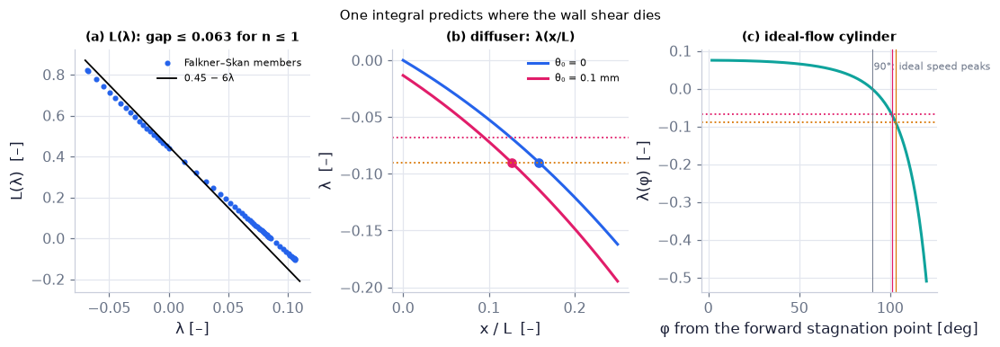

In [61]:
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(10, 3.4))   # the figure and its panels
a1.plot(tab7["lam"], tab7["L"], "o", color=COLORS["blue"], ms=3, label="Falkner–Skan members"); lx = np.linspace(-0.07, 0.11, 50)      # (a) Fig. 9.8 remade
a1.plot(lx, 0.45 - 6*lx, "k-", lw=1.2, label="0.45 − 6λ"); resid = np.max(np.abs(tab7["L"] - (0.45 - 6*tab7["lam"]))[tab7["lam"] <= 0.0856])   # largest gap of the line for n <= 1 (lambda <= 0.0855)
a1.set_xlabel("λ [–]"); a1.set_ylabel("L(λ)  [–]"); a1.legend(fontsize=7, frameon=False); a1.set_title(f"(a) L(λ): gap ≤ {resid:.3f} for n ≤ 1", fontsize=9)   # axis labels (with units), limits and the panel's message
xi = np.linspace(0, 0.25, 200)                                    # (b) the diffuser
for th0, col, lab in ((0.0, COLORS["blue"], "θ₀ = 0"), (1e-4, COLORS["rose"], "θ₀ = 0.1 mm")):   # loop over the cases
    e2 = ch09.example_9_2(theta0=th0, nu=NU_AIR, U1=10.0, L=0.5)
    a2.plot(xi, e2["lam"](xi), color=col, lw=2, label=lab)   # draw the curve(s)
    a2.plot(e2["x_sep_over_L"], -0.09, "o", color=col, ms=6)     # the crossing of -0.09
a2.axhline(-0.09, color=COLORS["amber"], ls=":", lw=1.2); a2.axhline(-0.0681, color=COLORS["rose"], ls=":", lw=1.2)   # a reference line or band
a2.set_xlabel("x / L  [–]"); a2.set_ylabel("λ  [–]"); a2.legend(fontsize=7, frameon=False); a2.set_title("(b) diffuser: λ(x/L)", fontsize=9)   # axis labels (with units), limits and the panel's message
phd = np.linspace(2, 120, 300); lc = BL.thwaites_cylinder_closed_form(np.radians(phd))     # (c) the cylinder
a3.plot(phd, lc, color=COLORS["teal"], lw=2); a3.axhline(-0.09, color=COLORS["amber"], ls=":", lw=1.2); a3.axhline(-0.0681, color=COLORS["rose"], ls=":", lw=1.2)   # a reference line or band
a3.axvline(BL.thwaites_cylinder_separation(), color=COLORS["amber"], lw=0.8); a3.axvline(BL.thwaites_cylinder_separation(lam_sep=-0.0681), color=COLORS["rose"], lw=0.8)   # a reference line or band
a3.axvline(90, color=COLORS["muted"], lw=0.6); a3.text(91, 0.05, "90°: ideal speed peaks", fontsize=7, color=COLORS["muted"])   # a reference line or band
a3.set_xlabel("φ from the forward stagnation point [deg]"); a3.set_ylabel("λ(φ)  [–]"); a3.set_title("(c) ideal-flow cylinder", fontsize=9)   # axis labels (with units), limits and the panel's message
fig.suptitle("One integral predicts where the wall shear dies", fontsize=10)   # the figure's message as its title
plt.show()   # display the figure

**What you see.** In (a) the nearly straight $L(\lambda)$ of the family beside Thwaites' line; in (b) $\lambda(x/L)$ falling through the dotted threshold lines, earlier for the thicker inlet layer; in (c) $\lambda(\varphi)$ crossing zero at 90° and the thresholds near 101–103°.

**How to read it.** A bigger $\theta_0$ moves the crossing upstream; in (c) the layer separates about 13° behind the shoulder — but only in the ideal-flow pressure, which no real wake obeys.

**What would change if…** …the diffuser were twice as long ($\theta_0=0$): the same curve in $x/L$ — in this model separation depends only on the area ratio $1+x/L$ (here 1.158 for $\lambda_{sep}=-0.09$), not on $U_1$ or on the angle; a thicker inlet layer is what moves it upstream.

In [62]:
nfr = 24 if not FAST else 12
idx = np.linspace(2, len(th["x"]) - 2, nfr).astype(int)          # stations from the start to just before separation (the march stops there)
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(10, 3.3), layout="none"); fixed_layout(fig, left=0.06, wspace=0.32)   # the figure and its panels
pr, = a1.plot([], [], color=COLORS["blue"], lw=2); a1.set_xlim(0, 1.05); a1.set_ylim(0, 6); a1.set_xlabel("u / U_e [–]"); a1.set_ylabel("y / θ [–]")   # axis labels (with units), limits and the panel's message
a2.plot(th["x"]/0.5, th["lam"], color=COLORS["muted"], lw=1); a2.axhline(-0.0681, color=COLORS["rose"], ls=":"); a2.axhline(-0.09, color=COLORS["amber"], ls=":")   # a reference line or band
mk, = a2.plot([], [], "o", color=COLORS["rose"], ms=8); a2.set_xlim(0, th["x"][idx[-1]]/0.5*1.05); a2.set_ylim(-0.11, 0.01); a2.set_xlabel("x / L [–]"); a2.set_ylabel("λ [–]")   # axis labels (with units), limits and the panel's message
a3.plot(th["x"][1:]/0.5, th["tau0"][1:], color=COLORS["muted"], lw=1); mk3, = a3.plot([], [], "o", color=COLORS["rose"], ms=8)   # draw the curve(s)
a3.set_xlim(0, th["x"][idx[-1]]/0.5*1.05); a3.set_ylim(0, 1.05*np.max(th["tau0"][idx])); a3.set_xlabel("x / L [–]"); a3.set_ylabel("τ₀ [Pa]")   # axis labels (with units), limits and the panel's message


def update(j):                                                    # frame j = station idx[j]
    i = idx[j]; lam = th["lam"][i]
    r = int(np.argmin(np.abs(tab["lam"] - lam)))                  # the Falkner-Skan member with the same lambda gives the profile shape
    pr.set_data(tab["fp"][r], tab["eta"]/tab["I_theta"][r])       # its profile with y measured in units of theta (I_theta = theta / delta)
    mk.set_data([th["x"][i]/0.5], [lam]); mk3.set_data([th["x"][i]/0.5], [th["tau0"][i]])
    a1.set_title(f"θ = {1e3*th['theta'][i]:.2f} mm, H = {th['H'][i]:.2f}", fontsize=9)   # axis labels (with units), limits and the panel's message
    a2.set_title(f"λ = {lam:.4f}", fontsize=9); a3.set_title(f"τ₀ = {th['tau0'][i]:.3f} Pa", fontsize=9)   # axis labels (with units), limits and the panel's message
    return []   # the values for this call


show_animation(animate(update, frames=nfr, fig=fig, interval=300), player="frames", dpi=64)   # a step player: stop where the marker touches the line

**What you see.** The profile in the left panel loses its fullness ($H$ rises), the red marker in the middle slides down to the dotted line and the wall stress on the right shrinks toward zero.

**How to read it.** $\tau_0=0$ where $\lambda$ reaches the threshold; the profile drawn is the Falkner–Skan member with the same $\lambda$ (the closure's assumption in one picture).

**What would change if…** …$\theta_0$ larger: the marker starts closer to the line and touches it sooner.

#### 🎮 Interactive: Can one integral predict separation?

**Why interactive rather than a static figure:** The reader chooses the body's outer flow, the $\theta$, $\lambda$, $H$, $\tau_0$ curves update along $x$, and the separation point jumps as the diffuser angle, $\theta_0$ or closure changes; static curves for one body cannot show that.

**What to try:**
- Choose 'diffuser' and raise $\theta_0$: how far upstream does separation move?
- Switch the closure to 'white' and compare the −0.09 and −0.0681 criteria.
- Choose 'cylinder' and read the predicted separation angle; then compare with 82°.
- Click on the $\theta^2$ bars: which term is larger downstream, $\int U_e^5$ or the $\theta_0$ memory?

In [63]:
show_viz("ch09", "thwaites_marching")   # full-width explainer; ⤢ Full screen for more room

[explainer ch09/thwaites_marching]

**What would change if…** …the outer flow keeps decelerating? $\lambda$ keeps falling and $l(\lambda)$ reaches zero: the wall shear vanishes. Next section: what that means physically, and what it does to a body.

---

## 9.7 Transition, Pressure Gradients, and Boundary-Layer Separation

**What is this section about?** Three things can happen to a laminar layer as it runs along a body: it can turn turbulent (transition), it can be squeezed and stay attached under a favourable pressure gradient, or, under an adverse
gradient, it can stop clinging to the wall (separation). Separation is the boundary layer's way of failing: the stream leaves the wall, a wake forms and a drag appears that ideal-flow theory never saw. We first see why an adverse
gradient must end in zero wall shear (C08), then what separation does to a body's drag (C09).

### 🧩 Boundary-layer separation: wall curvature, the inflection point and $\tau_0=0$ `C08`

*The question:* Why does an adverse pressure gradient make the wall shear vanish?

*In one line:* $\Big(\frac{\partial^2u}{\partial y^2}\Big)_{wall}<0\quad(dp/dx<0)$ *(9.51)* · $\Big(\frac{\partial^2u}{\partial y^2}\Big)_{wall}>0\quad(dp/dx>0)$ *(9.52)*

#### The problem in plain words

Roll a marble up a hill: it slows and, if the hill is steep or long enough, turns back. The fluid nearest the wall has almost no momentum (it is slowed by friction), so a rising pressure along the wall — an adverse gradient — reverses it first.
When the wall shear reaches zero the layer separates: the stream detaches, a wake forms, the wing stalls.

#### The idea

```
favourable dp/dx<0      zero dp/dx = 0         adverse dp/dx>0           separation
  ▏ ╭─────               ▏ ╭─────               ▏  ╭───╮ inflection      ▏   ╭──►
  ▏╭╯   u_yy(0)<0        ▏╭╯   u_yy(0)=0        ▏ ╭╯   ╰──  u_yy(0)>0     ▏  ╭╯       τ₀ = 0, u_y(0) = 0
  ▏╯   no inflection     ▏╯ (inflection at wall) ▏ ╯                       ▏◄─╯ reverse flow near wall
```

Four profiles at the same $x$: the sign of the wall curvature follows the sign of the pressure gradient, and the last one has lost its wall shear.

> 📎 **Primer — inflection point.** `P212` · An *inflection point* of a curve is where its second derivative changes sign (the curve stops bending one way and starts bending the other). For a velocity profile $u(y)$ it is where $u_{yy}=0$ and changes sign. Profiles with an
inflection are the ones Ch. 11 shows to be unstable to small disturbances (Rayleigh's criterion).

In [64]:
import numpy as np   # arrays and maths
y = np.linspace(0, 1, 201)   # sample points
u = 3*y**2 - 2*y**3 - 0.3*y            # a made-up profile
uyy = np.gradient(np.gradient(u, y), y)     # second derivative
i = np.nonzero(np.diff(np.sign(uyy[2:-2])))[0][0] + 2
print(y[i])                          # 0.5: u_yy = 6 - 12 y changes sign at y = 1/2

0.495


📝 **Note.** **N70 [B]** **Read (9.9), $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=-\frac1\rho\frac{dp}{dx}+\nu\frac{\partial^2u}{\partial y^2}$ at the wall.** There $u=v=0$, so the two advective terms vanish and $0=-\frac1\rho\frac{dp}{dx}+\nu\big(\frac{\partial^2u}{\partial y^2}\big)_{wall}$, i.e. $\mu\big(\frac{\partial^2u}{\partial y^2}\big)_{wall}=\frac{dp}{dx}$ — the wall curvature *is* the pressure gradient (divided by $\mu$).

$$ \mu\Big(\frac{\partial^2u}{\partial y^2}\Big)_{wall}=\frac{dp}{dx} \qquad \text{(9.9 at y = 0)} $$

#### 🧮 Derivation — Wall curvature μ u_yy = dp/dx, the inflection points and separation as τ₀ = 0 `D12` (Eq. 9.52: $\Big(\frac{\partial^2u}{\partial y^2}\Big)_{wall}>0\quad(dp/dx>0)$)

**What we want to show.** Show why a favourable pressure gradient keeps a profile convex-up and an adverse one gives an inflection and finally zero wall shear.

**Assumptions.** Attached laminar layer with a single edge; no suction (v = 0 at the wall).

**The plan.**

1. Evaluate at the wall.
2. Compare the curvature at the wall and near the edge.
3. Conclude.

**Tools we use** (each explained before this point): evaluating a PDE on a boundary · inflection point (primer P212) · intermediate value idea (a continuous function that changes sign has a zero).

**We start from**

$$ u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=-\frac1\rho\frac{dp}{dx}+\nu\frac{\partial^2u}{\partial y^2}\ \text{(9.9) at the wall}\ y=0 $$

*In words:* what the equation says exactly at y = 0.

---

**Step 1 of 6 — Evaluate (9.9) at the wall.**

$$ 0=-\frac1\rho\frac{dp}{dx}+\nu\Big(\frac{\partial^2u}{\partial y^2}\Big)_{wall} $$

- *Why we can do this:* No slip (9.12), $u(x,0)=0$ and no through-flow (9.13), $v(x,0)=0$ make u = v = 0 at y = 0, so both advective terms vanish.
- *In words:* only pressure and friction are left at the wall.

---

**Step 2 of 6 — Rearrange.**

$$ \mu\Big(\frac{\partial^2u}{\partial y^2}\Big)_{wall}=\frac{dp}{dx} $$

- *Why we can do this:* Multiply by ρ (μ = ρν).
- *In words:* the wall curvature is the pressure gradient (over μ).

---

**Step 3 of 6 — Look near the edge.**

$$ \frac{\partial u}{\partial y}>0\ \text{falls to}\ 0\ \Rightarrow\ \frac{\partial^2u}{\partial y^2}<0\ \ (y\to\delta) $$

- *Why we can do this:* The profile rises to U_e and joins it smoothly, so its slope decreases from positive to zero.
- *In words:* near the edge the profile always bends over.

---

**Step 4 of 6 — Accelerating stream.**

$$ \Big(\frac{\partial^2u}{\partial y^2}\Big)_{wall}<0\quad\text{for }\frac{dp}{dx}<0\ \text{(9.51)} $$

- *Why we can do this:* Step 2 with dp/dx < 0: the same sign as near the edge, so no sign change is required — no inflection point.
- *In words:* favourable gradient: one smooth bend.

---

**Step 5 of 6 — Decelerating stream.**

$$ \Big(\frac{\partial^2u}{\partial y^2}\Big)_{wall}>0\quad\text{for }\frac{dp}{dx}>0\ \text{(9.52)} $$

- *Why we can do this:* Positive at the wall (step 2), negative near the edge (step 3); a continuous u_yy must pass through zero in between: an inflection point at finite y (Ch. 11 links it to instability).
- *In words:* adverse gradient: the profile gets an S-bend.

---

**Step 6 of 6 — Follow the wall shear.**

$$ \tau_0=\mu\Big(\frac{\partial u}{\partial y}\Big)_{wall}\to0\ \text{(separation)} $$

- *Why we can do this:* A stronger or longer adverse gradient keeps flattening the wall slope; when it reaches zero the wall fluid stops, and beyond it reverses.
- *In words:* separation is zero shear.

---

**Result**

$$ \mu u_{yy}|_{wall}=dp/dx\ \text{(9.51)–(9.52); adverse ⇒ inflection; separation at τ₀ = 0} $$

*In words:* the pressure gradient is the wall curvature.

**What it means.** Every adverse-gradient flow (diffusers, airfoils past the suction peak) is at risk; the mechanism returns in Ch. 14 (stall).

**Check it.** Falkner–Skan: f‴(0) = −n ⇒ u_yy(wall) = −nU_e²/(νx) = (1/μ)dp/dx since dp/dx = −ρnU_e²/x ✓. n = −0.05: f‴(0) = +0.05 and the inflection at η = 1.650 ✓.

> ⚠️ **Common confusion (traps in `D12`):** Assuming the wall curvature is zero (only true for Blasius); mixing the sign of dp/dx (adverse > 0).

📝 **Note.** **N71 [B], N72 [B]** **Accelerating and decelerating streams.** For an accelerating stream, $\big(\frac{\partial^2u}{\partial y^2}\big)_{wall}<0$ *(9.51)*, no inflection; for a decelerating one $\big(\frac{\partial^2u}{\partial y^2}\big)_{wall}>0$ *(9.52)*, hence an inflection point
(the hook to Ch. 11's Rayleigh criterion, which says such profiles can be unstable).

#### ✏️ Tiny example: sign and size

Air, adverse $dp/dx=+20$ Pa/m: $u_{yy}(\text{wall})=20/1.8\times10^{-5}=1.1\times10^6$ (m s)⁻¹ $>0$; near the edge $u_{yy}<0$ (the profile rounds off onto $U_e$), so $u_{yy}$ must change sign somewhere in between: an inflection.
For a Falkner–Skan layer $f'''(0)=-n$: $n=-0.05$ gives $+0.05$ (positive, inflection at $\eta=1.65$); $n=+1$ gives $-1$ (negative, no inflection); $n=0$ gives $0$ (the inflection sits at the wall).

In [65]:
print("wall curvature for dp/dx = +20 Pa/m in air:", BL.wall_curvature(20.0, 1.8e-5), "1/(m s)")   # mu u_yy = dp/dx  =>  u_yy = dp/dx / mu
for n in (1.0, 0.0, -0.05):                                      # accelerating, flat plate, decelerating
    sol = BL.falkner_skan(n)                                     # solved profile
    print(n, "f'''(0) =", round(float(sol["fppp"][0]), 4), "| inflection at eta =", BL.profile_inflection(sol["eta"], sol["fp"]))   # None: no inflection
x_d = th["x"]                                                    # the diffuser march of C07 (exact-Falkner-Skan closure)
print("separation of the diffuser: x_sep =", th["x_sep"], "m  (x/L =", th["x_sep"]/0.5, ") from the interpolated crossing; first zero sample:", BL.separation_point(th["x"], th["tau0"]))   # print the result
print("with the book-style 'white' closure: x_sep =", thw["x_sep"], "m (x/L =", thw["x_sep"]/0.5, ")")   # print the result

wall curvature for dp/dx = +20 Pa/m in air: 1111111.111111111 1/(m s)
1.0 f'''(0) = -1.0 | inflection at eta = None
0.0 f'''(0) = 0.0 | inflection at eta = 0.0
-0.05 f'''(0) = 0.05 | inflection at eta = 1.6495943696020603
separation of the diffuser: x_sep = 0.06284690841974316 m  (x/L = 0.12569381683948633 ) from the interpolated crossing; first zero sample: 0.063
with the book-style 'white' closure: x_sep = 0.07914605332602732 m (x/L = 0.15829210665205465 )


**What does the code above do?**

1. `wall_curvature(dpdx, mu)` is $u_{yy}=\frac1\mu\frac{dp}{dx}$: $1.1\times10^6$ (m s)⁻¹ for 20 Pa/m in air.
2. For the Falkner–Skan layers `fppp[0]` is $f'''(0)=-n$ exactly ($-1$, $0$, $+0.05$), and `profile_inflection` finds the sign change of $u_{yy}$: none for $n=1$, at the wall for $n=0$, at $\eta=1.650$ for $n=-0.05$.
3. `separation_point` interpolates the first zero of $\tau_0(x)$: the diffuser of Example 9.2 separates at $x=0.0628$ m ($x/L=0.1257$) with the exact-family closure whose $l$ reaches zero at $\lambda=-0.0681$, and at 0.0791 m ($x/L=0.1583$) with the book-style $-0.09$ criterion.

📝 **Note.** **N73 [B]** **Adverse gradient thickens the layer.** $v(y)=-\int_0^yu_x\,dy'$: in a decelerating stream $u_x<0$ also *outside* the layer, so there is more fluid to push outward; the layer thickens by diffusion *and* by being lifted off the wall (the three profiles in the figure below).

In [66]:
# from scratch: the sign-change search written by hand (np.sign + linear interpolation) on the tau0 array of the diffuser march
tx, tt = th["x"], th["tau0"]                                      # tau0(x) [Pa] up to separation
sg = np.sign(tt - 1e-12)                                          # +1 while positive, -1 once it has (numerically) reached zero
kk = int(np.nonzero(sg[:-1] != sg[1:])[0][0])                     # index just before the sign change
x_mine = np.interp(0.0, [tt[kk + 1], tt[kk]], [tx[kk + 1], tx[kk]]) if tt[kk + 1] != tt[kk] else tx[kk + 1]   # linear interpolation of the zero
print("by hand:", x_mine, " library:", BL.separation_point(tx, tt))   # print the result
assert np.isclose(x_mine, BL.separation_point(tx, tt), rtol=2e-3)  # same station (both interpolate the last two samples)

by hand: 0.063  library: 0.063


**What does the code above do?**

1. `np.sign(tau0)` is $+1$ while the wall stress is positive and changes at separation; `np.nonzero` finds the last positive sample.
2. `np.interp` puts the zero on the straight line through the last two samples.
3. The assert compares this hand-made station with `BL.separation_point`, which does the same interpolation.

**Marching near the fold: a bracket, not a number.** Close to $n=-0.0904$ the wall shear is tiny and the marched separation station depends on the inlet profile, so we quote a *bracket* and not a station: in dimensionless units
($\nu=1$, $a=1$, $U_e=x^n$, a ramp-shaped inlet at $x_0=0.05$) the layer with $n=-0.089$ (just above the fold) stays attached all the way to $x=50$, while the layer with $n=-0.12$ (below the fold, where no similar solution exists) separates within $x<1$.

In [67]:
for n_ in (-0.089, -0.12):                                       # just above and just below the fold n = -0.0904 (dimensionless: nu = 1, a = 1)
    of_ = BL.outer_flow("wedge", n=n_, a=1.0)                    # outer flow U_e = x^n
    U0_ = of_.Ue(0.05); d0_ = 4.0*np.sqrt(0.05/U0_)              # inlet speed and a ramp thickness at x0 = 0.05
    ramp = lambda y_, U0_=U0_, d0_=d0_: U0_*np.minimum(y_/d0_, 1.0)   # a ramp-shaped inlet profile (our choice: the answer depends on it)
    mm_ = BL.march_boundary_layer(of_.Ue, np.geomspace(0.05, 50.0, 200), 1.0, u_inlet=ramp, ny=200)   # march (9.9) downstream
    print(f"n = {n_}: separated = {mm_['separated']}, x_sep = {mm_['x_sep']}, tau0 at the last station = {mm_['tau0'][-1]:.3e}")   # print the result

n = -0.089: separated = False, x_sep = None, tau0 at the last station = 3.171e-03
n = -0.12: separated = True, x_sep = 0.08491602157740998, tau0 at the last station = 1.287e-02


**What does the code above do?**

1. `lambda y_, U0_=U0_, d0_=d0_: …` is a one-line function of $y$; the *default arguments* `U0_=U0_, d0_=d0_` freeze the current loop values inside it (without them the function would look the names up later, when the loop has moved on). It is the ramp inlet $u=U_0\min(y/d_0,1)$.
2. The layer just above the fold keeps a positive wall shear out to $x=50$; the layer just below it separates early. *Where* exactly depends on the inlet profile (a different ramp gives another station), which is why only the bracket — attached to $x=50$ above the fold, separated within $x<1$ below it — is quotable; the marched value is qualitative.

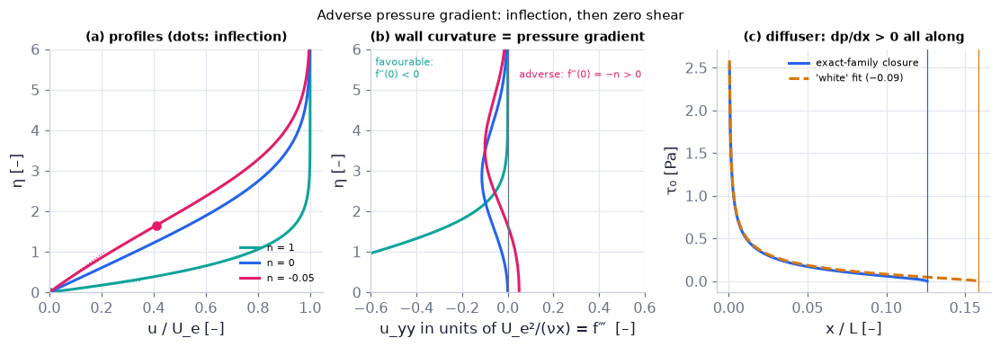

In [68]:
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(10, 3.4))   # the figure and its panels
for n_, col in ((1.0, COLORS["teal"]), (0.0, COLORS["blue"]), (-0.05, COLORS["rose"])):   # loop over the cases
    s_ = BL.falkner_skan(n_); st_ = BL.falkner_skan_state(n_)
    a1.plot(s_["fp"], s_["eta"], color=col, lw=2, label=f"n = {n_:g}")                                  # (a) profiles
    a1.plot([0, 0.35*st_["fpp0"]/max(st_["fpp0"], 0.35)*1.0], [0, 0.35/max(st_["fpp0"], 0.35)], color=col, lw=0.8, ls=":")   # the wall tangent u = f''(0) eta (short)
    if st_["inflection_eta"] is not None: a1.plot(np.interp(st_["inflection_eta"], s_["eta"], s_["fp"]), st_["inflection_eta"], "o", color=col, ms=6)   # draw the curve(s)
    a2.plot(s_["fppp"], s_["eta"], color=col, lw=2)                                                     # (b) u_yy ~ f'''
a1.set_ylim(0, 6); a1.set_xlim(0, 1.05); a1.set_xlabel("u / U_e [–]"); a1.set_ylabel("η [–]"); a1.legend(fontsize=7, frameon=False, loc="lower right"); a1.set_title("(a) profiles (dots: inflection)", fontsize=9)   # axis labels (with units), limits and the panel's message
a2.axvline(0, color=COLORS["muted"], lw=0.8); a2.set_ylim(0, 6); a2.set_xlim(-0.6, 0.6); a2.set_xlabel("u_yy in units of U_e²/(νx) = f‴  [–]"); a2.set_ylabel("η [–]")   # axis labels (with units), limits and the panel's message
a2.text(0.05, 5.3, "adverse: f‴(0) = −n > 0", fontsize=7, color=COLORS["rose"]); a2.text(-0.58, 5.3, "favourable:\nf‴(0) < 0", fontsize=7, color=COLORS["teal"]); a2.set_title("(b) wall curvature = pressure gradient", fontsize=9)   # axis labels (with units), limits and the panel's message
a3.plot(th["x"][1:]/0.5, th["tau0"][1:], color=COLORS["blue"], lw=2, label="exact-family closure"); a3.plot(thw["x"][1:]/0.5, thw["tau0"][1:], color=COLORS["amber"], lw=2, ls="--", label="'white' fit (−0.09)")   # draw the curve(s)
a3.axvline(th["x_sep"]/0.5, color=COLORS["blue"], lw=0.8); a3.axvline(thw["x_sep"]/0.5, color=COLORS["amber"], lw=0.8)   # a reference line or band
a3.set_xlabel("x / L [–]"); a3.set_ylabel("τ₀ [Pa]"); a3.legend(fontsize=7, frameon=False); a3.set_title("(c) diffuser: dp/dx > 0 all along", fontsize=9)   # axis labels (with units), limits and the panel's message
fig.suptitle("Adverse pressure gradient: inflection, then zero shear", fontsize=10)   # the figure's message as its title
plt.show()   # display the figure

**What you see.** In (a) the rose profile ($n=-0.05$) gets a second bend (its dot is the inflection) while the teal one is a single smooth bend; in (b) $f'''$ is negative at the wall for $n>0$, zero for $n=0$ and positive for $n<0$; in (c) $\tau_0$ falls to zero in the diffuser.

**How to read it.** Wall curvature = pressure gradient: an adverse gradient bends the wall end of the profile the other way, which puts an inflection into it; when the curvature is strong enough the slope at the wall reaches zero.

**What would change if…** …$dp/dx$ stronger (a wider-angle diffuser): the wall tangent lies flatter and $\tau_0$ reaches zero sooner.

In [69]:
rows7 = np.arange(len(tab["m"]))[::-1]                            # from n = 4 down to the fold
rows7 = rows7[tab["m"][rows7] <= 1.0001]                          # keep n <= 1 (favourable ... separation)
rows7 = rows7[::1 if not FAST else 2]
ms7 = tab["m"][rows7]


def frame(m_):                                                    # profile and wall tangent for exponent m_
    r = int(np.argmin(np.abs(tab["m"] - m_))); s0 = tab["fpp0"][r]
    e_ = min(1.5, 0.95/max(s0, 1e-9))
    return {"profile f′(η)": (tab["fp"][r], tab["eta"]), "wall tangent": ([0, s0*e_], [0, e_])}   # the values for this call


fig = slider_figure(frame, "n", ms7, unit="", xlabel="u / U_e  [–]", ylabel="η [–]", title="", xrange=[0, 1.05], yrange=[0, 6])   # one figure whose curves follow the slider; every position precomputed (P17)
def verdict(m_):   # a small helper used below
    return "no inflection (u_yy < 0 at the wall: accelerating)" if m_ > 1e-9 else ("inflection at the wall (u_yy = 0)" if abs(m_) <= 1e-9 else "inflection at η = %.2f (u_yy > 0 at the wall: adverse)" % tab["inflection_eta"][int(np.argmin(np.abs(tab["m"] - m_)))])   # the values for this call
step_titles(fig, [f"n = {m_:.4f}: f‴(0) = {-m_:+.4f} — {verdict(m_)}" for m_ in ms7])   # a title with numbers for every slider position
recolor(fig, {"profile f′(η)": COLORS["blue"], "wall tangent": COLORS["ink"]})   # colours by meaning
fig.show()                                                        # drag n from 1 to the fold

**What you see.** One Falkner–Skan profile for $n\le1$ with its wall tangent; the title gives $n$, $f''(0)$ and whether the profile has an inflection.

**How to read it.** The wall tangent is the wall shear; for $n>0$ the profile bends one way only, at $n=0$ the curvature vanishes at the wall, and for $n<0$ an inflection appears inside the layer — the sign of $\mu u_{yy}=dp/dx$ at the wall in action — until the tangent lies along the $\eta$ axis at the fold.

*↪ **N74 [C]** After separation the boundary-layer equations fail (the Goldstein singularity: marching stops at $\tau_0=0$; the reversed flow is not thin, the pressure is no longer the ideal one, the flow is unsteady). Chs. 10 and 14.*

**What would change if…** …the layer were turbulent? Its wall-nearest fluid has more momentum, so it survives a stronger adverse gradient: separation is delayed. That is the whole of the drag crisis (C11). First: what does separation do to the drag?

### 🧩 Streamlining and form drag: separated wake pressure `C09`

*The question:* Why does letting go of the wall create drag, and how does streamlining reduce it?

> 🔁 **Tools from earlier chapters used here** (see `knowledge/primers.md`) — used in C09

- **Gauss–Legendre quadrature** — n nodes integrate polynomials of degree 2n − 1 exactly; split the interval at a jump so each piece is smooth (Ch. 5 P143).

#### The problem in plain words

Ideal flow past a cylinder is symmetrical front to back: the pressure that pushes on the front is recovered on the rear and the net force is zero (d'Alembert). A real cylinder has a wide wake at low, nearly uniform pressure —
the rear pressure is not recovered — so the front pushes and the rear does not push back. That missing recovery is the *form drag* (pressure drag). Streamlining is the art of keeping the layer on the wall long enough to recover pressure.

*Pressure coefficient (recalled from Ch. 6).* the surface pressure is reported as $C_p=\frac{p-p_\infty}{\frac12\rho U^2}$; for ideal flow past a cylinder $C_p=1-4\sin^2\varphi$, which is $+1$ at the stagnation points and $-3$ at the shoulders ($\varphi=90^\circ$).

#### The idea

```
C_p   1 ●╲                        ideal (potential) flow: 1 − 4 sin²φ, recovers to 1 at φ = 180°
      0 ──╲──────────╱────         real: follows the ideal curve up to separation φ_s, then stays
     −2    ╲__    __╱              flat at the low wake pressure C_b  ⇒  drag = ½∮(C_p − C_p,ideal) cos φ dφ
   0°     φ_s ────────── 180°      turbulent 125° vs laminar 82°: the drag falls only because the base pressure rises (C_b), not because φ_s is later
```

The angle $\varphi$ is measured from the **forward** stagnation point (Ch. 6 measured it from the downstream axis).

📝 **Note.** **N68 [B]** **Transition.** A laminar layer becomes unstable beyond a critical Reynolds number (free-stream turbulence, roughness, curvature and pressure gradient move it); on a flat plate, roughly $\mathrm{Re}_x\approx10^6$ within a factor of five *(qualitative)*.
The regimes along a plate: leading edge ($\mathrm{Re}_x\sim1$), the laminar similarity region, first instability (Tollmien–Schlichting waves, Ch. 11), nonlinear breakdown, fully turbulent.

> ⚠️ **Common confusion (which Reynolds number?).** The text uses $\mathrm{Re}_L=UL/\nu$ of the whole plate and the local $\mathrm{Re}_x=5\times10^5$ for the start of transition, and $10^6$ or $10^7$ elsewhere; these are *rounded, experimental* values.
> `BL.transition_state(Re_x, Re_cr=5e5)` keeps $\mathrm{Re}_{cr}$ an argument, so you choose your own.

In [70]:
print([BL.transition_state(r) for r in (1e5, 5e5, 2e6, 1e7)])     # laminar, transitional, transitional, turbulent (qualitative thresholds)
print(BL.transition_state(2e6, Re_cr=3e6))                        # a quieter free stream delays transition: still laminar at 2e6

['laminar', 'transitional', 'transitional', 'turbulent']
laminar


**What does the code above do?**

`transition_state` compares a local Reynolds number with the (argument) $\mathrm{Re}_{cr}$ and ten times it: laminar below $\mathrm{Re}_{cr}$, "transitional" up to $10\,\mathrm{Re}_{cr}$, then turbulent. The thresholds are the book's rounded values, experimental and qualitative — never a computed result.

📝 **Note.** **N69 [B]** **The plate drag curve (Fig. 9.11 remade).** Laminar: $C_D=1.33/\sqrt{\mathrm{Re}_L}$ *(9.33)*, $C_D=\frac{F_D}{\frac12\rho U^2L}$; turbulent (Prandtl's one-seventh-law form, Ch. 12): $0.074\,\mathrm{Re}_L^{-1/5}$ — **a secondary-sourced correlation (Schlichting; White), not derived here**;
mixed: the turbulent line minus a patch $A/\mathrm{Re}_L$ with $A=\mathrm{Re}_{tr}(C_{turb}-C_{lam})\approx1743$ at $\mathrm{Re}_{tr}=5\times10^5$. At the same $\mathrm{Re}_L$ a turbulent layer has *more* friction drag than a laminar one would (fuller profile, larger wall shear), but a laminar
layer cannot be kept that long; real plates follow the laminar line up to the transition Reynolds number and then bend toward the turbulent one.

In [71]:
print("  Re_L      laminar    turbulent    mixed (Re_tr = 5e5)")   # print the result
for r in (1e5, 1e6, 1e7):   # loop over the cases
    print(f"{r:8.0e} {BL.plate_drag_coefficient(r, 'laminar'):10.3e} {BL.plate_drag_coefficient(r, 'turbulent'):10.3e} {BL.plate_drag_coefficient(r, 'mixed'):10.3e}")   # print the result
print("mixed at the transition point equals laminar:", BL.plate_drag_coefficient(5e5, "mixed"), BL.plate_drag_coefficient(5e5, "laminar"))   # print the result

  Re_L      laminar    turbulent    mixed (Re_tr = 5e5)
   1e+05  4.200e-03  7.400e-03  4.200e-03
   1e+06  1.328e-03  4.669e-03  2.927e-03
   1e+07  4.200e-04  2.946e-03  2.772e-03
mixed at the transition point equals laminar: 0.0018783999534440407 0.0018783999534440407


**What does the code above do?**

`plate_drag_coefficient(Re_L, regime, Re_tr)` returns one-sided coefficients: laminar $1.328/\sqrt{\mathrm{Re}_L}$ (computed from Blasius), turbulent $0.074\,\mathrm{Re}_L^{-1/5}$ (secondary-sourced), and the mixed curve, which coincides with the laminar one at $\mathrm{Re}_L=\mathrm{Re}_{tr}$ ($1.878\times10^{-3}$) and joins the turbulent line by $10^7$.

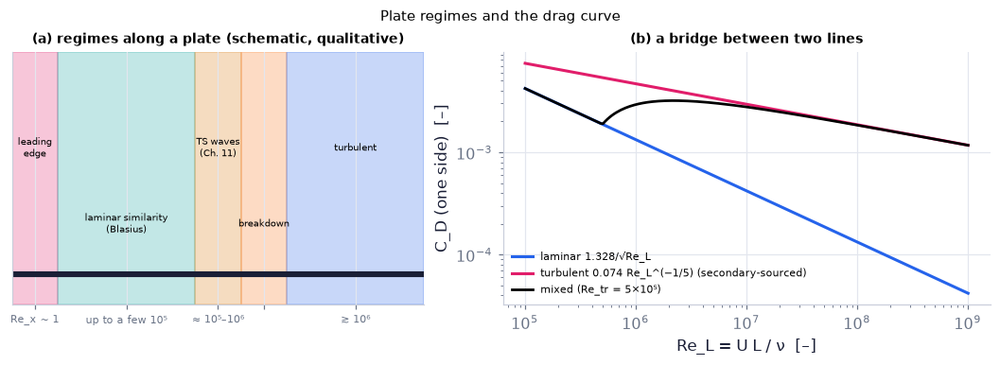

In [72]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.5, 3.4), gridspec_kw=dict(width_ratios=[1.1, 1.3]))   # the figure and its panels
regs = [(0, 1, "leading\nedge", COLORS["rose"]), (1, 4, "laminar similarity\n(Blasius)", COLORS["teal"]), (4, 5, "TS waves\n(Ch. 11)", COLORS["amber"]), (5, 6, "breakdown", COLORS["orange"]), (6, 9, "turbulent", COLORS["blue"])]
for x0, x1, lab, col in regs:                                     # (a) schematic of the regimes along a plate (ours, qualitative)
    a1.axvspan(x0, x1, color=col, alpha=0.25); a1.text(0.5*(x0 + x1), 0.62 if (x0 % 2 == 0) else 0.32, lab, ha="center", va="center", fontsize=6.5)   # a reference line or band
a1.axhline(0.12, xmin=0.0, xmax=1.0, color=COLORS["ink"], lw=4); a1.set_xlim(0, 9); a1.set_ylim(0, 1); a1.set_yticks([])   # axis labels (with units), limits and the panel's message
a1.set_xticks([0.5, 2.5, 4.5, 5.5, 7.5]); a1.set_xticklabels(["Re_x ~ 1", "up to a few 10⁵", "≈ 10⁵–10⁶", "", "≳ 10⁶"], fontsize=7); a1.set_title("(a) regimes along a plate (schematic, qualitative)", fontsize=9)   # axis labels (with units), limits and the panel's message
Re_ = np.logspace(5, 9, 200)                                      # (b) drag curve
a2.loglog(Re_, BL.plate_drag_coefficient(Re_, "laminar"), color=COLORS["blue"], lw=2, label="laminar 1.328/√Re_L")   # curve(s) on logarithmic axes
a2.loglog(Re_, BL.plate_drag_coefficient(Re_, "turbulent"), color=COLORS["rose"], lw=2, label="turbulent 0.074 Re_L^(−1/5) (secondary-sourced)")   # curve(s) on logarithmic axes
a2.loglog(Re_, BL.plate_drag_coefficient(Re_, "mixed"), "k-", lw=1.8, label="mixed (Re_tr = 5×10⁵)")   # curve(s) on logarithmic axes
a2.set_xlabel("Re_L = U L / ν  [–]"); a2.set_ylabel("C_D (one side)  [–]"); a2.legend(fontsize=7, frameon=False); a2.set_title("(b) a bridge between two lines", fontsize=9)   # axis labels (with units), limits and the panel's message
fig.suptitle("Plate regimes and the drag curve", fontsize=10)   # the figure's message as its title
plt.show()   # display the figure

**What you see.** Two straight lines on log–log axes (slopes $-\frac12$ and $-\frac15$) and a black curve leaving the laminar line near $5\times10^5$ and approaching the turbulent line by $10^7$.

**How to read it.** At $\mathrm{Re}_L=10^6$ a fully laminar plate would have $C_D=1.3\times10^{-3}$, a mixed one $2.9\times10^{-3}$ and a fully turbulent one $4.7\times10^{-3}$; panel (a) is a cartoon of the regimes, its Reynolds numbers are rounded and experimental.

**What would change if…** …a rougher leading edge trips the layer earlier: the bridge moves to the left ($\mathrm{Re}_{tr}$ is an argument).

#### 🧮 Derivation — Pressure drag of the separated model: $C_{D,p}=\sin\varphi_s\big(1-\frac43\sin^2\varphi_s-C_b\big)$ `D13`

**What we want to show.** Show how the position of separation and the wake pressure set a cylinder's form drag.

**Assumptions.** Pressure drag only (friction is small on blunt bodies); symmetric separation; constant C_b; φ from the forward stagnation point.

**The plan.**

1. The pressure force in the flow direction.
2. A coefficient.
3. Integrate the model.

**Tools we use** (each explained before this point): force from pressure on a surface · substitution in an integral (ch03 P106) · Gauss–Legendre check (ch05 P143).

**We start from**

$$ C_p=1-4\sin^2\varphi\ \ (0\le\varphi\le\varphi_s),\qquad C_p=C_b\ \ (\varphi_s\le\varphi\le2\pi-\varphi_s) $$

*In words:* ideal-flow pressure (Ch. 6) up to the separation angle, then a constant wake pressure: our simple model; the ideal case has zero drag (d'Alembert)

---

**Step 1 of 7 — Write the pressure force element.**

$$ dF_x=-p\,n_x\,dS=p\cos\varphi\;a\,d\varphi\ \text{(per unit span)} $$

- *Why we can do this:* The force on the body is −p n dS; with φ from the forward stagnation point the outward normal has n_x = −cos φ.
- *In words:* front pressure pushes downstream, rear pressure upstream.

---

**Step 2 of 7 — Subtract the ambient pressure.**

$$ dF_x=(p-p_\infty)\cos\varphi\;a\,d\varphi $$

- *Why we can do this:* ∮cos φ dφ = 0, so a uniform p∞ exerts no net force.
- *In words:* only differences matter.

---

**Step 3 of 7 — Form a coefficient.**

$$ C_{D,p}=\frac{F_x}{\tfrac12\rho U^2\,(2a)}=\frac12\oint C_p\cos\varphi\,d\varphi $$

- *Why we can do this:* C_p = (p − p∞)/(½ρU²) and the frontal area per unit span is 2a.
- *In words:* an integral of C_p weighted by cos φ.

---

**Step 4 of 7 — State the model.**

$$ C_p=1-4\sin^2\varphi\ \ (0\le\varphi\le\varphi_s),\qquad C_p=C_b\ \ (\varphi_s\le\varphi\le2\pi-\varphi_s) $$

- *Why we can do this:* Ideal-flow pressure until the layer lets go (C08), then a flat wake pressure; symmetric about the axis (our model, qualitative).
- *In words:* the wake does not recover pressure.

---

**Step 5 of 7 — Integrate the front part.**

$$ 2\int_0^{\varphi_s}(1-4\sin^2\varphi)\cos\varphi\,d\varphi=2\Big(\sin\varphi_s-\tfrac43\sin^3\varphi_s\Big) $$

- *Why we can do this:* Substitute s = sin φ (P106): ∫(1 − 4s²)ds = s − 4s³/3; the two halves are equal.
- *In words:* the push on the front.

---

**Step 6 of 7 — Integrate the wake part.**

$$ C_b\int_{\varphi_s}^{2\pi-\varphi_s}\cos\varphi\,d\varphi=-2C_b\sin\varphi_s $$

- *Why we can do this:* ∫cos φ dφ = sin φ, and sin(2π − φ_s) − sin φ_s = −2 sin φ_s.
- *In words:* the wake sucks back.

---

**Step 7 of 7 — Add and halve.**

$$ C_{D,p}=\sin\varphi_s\Big(1-\tfrac43\sin^2\varphi_s-C_b\Big) $$

- *Why we can do this:* ½ × (step 5 + step 6). Ideal limit: φ_s → π with C_b → 1 gives sin φ_s → 0, so C_D,p → 0 (d'Alembert).
- *In words:* only a higher wake pressure (C_b rising) lowers the drag; at fixed C_b = −1.2 the model gives D(82°) = 0.884, D(90°) = 0.867, D(125°) = 1.07, so later separation alone does not.

---

**Result**

$$ C_{D,p}=\sin\varphi_s\big(1-\frac43\sin^2\varphi_s-C_b\big) $$

*In words:* form drag = missing pressure recovery.

**What it means.** Explains why streamlining (delaying separation) and the drag crisis (separation 82° → 125°) reduce drag; the numbers are qualitative.

**Check it.** φ_s = 90°, C_b = −3 (ideal at 90°): 2.667; C_b = −1: 0.667. φ_s = 82°, C_b = −1.2: 0.884; φ_s = 125°, C_b = −0.6: 0.578 (illustrative pair, ours). The Gauss–Legendre integral of the piecewise C_p equals the formula to 1e-12.

> ⚠️ **Common confusion (traps in `D13`):** φ from the *forward* stagnation point (Ch. 6 measured φ from downstream, in Ch. 6's derivation D09); the crude default C_b = ideal value at φ_s gives 2.59 at 82° — the wake pressure is a *model input*.

#### ✏️ Tiny example: the drag of the separated model by hand

Take $\varphi_s=90^\circ$ and the ideal value of $C_p$ there, $C_b=1-4=-3$: $C_D=1\cdot(1-\frac43+3)=2.667$. A realistic wake pressure $C_b=-1$ gives $1\cdot(1-\frac43+1)=0.667$; $C_b=-1.2$ and $\varphi_s=82^\circ$ gives $0.9903\times(1-1.3075+1.2)=0.884$
($\sin82^\circ=0.9903$, $\sin^2=0.9806$); $\varphi_s=125^\circ$ with $C_b=-0.6$: $0.8192\times(1-0.8947+0.6)=0.578$. And $\varphi_s\to180^\circ$ gives 0: d'Alembert. (The two $C_b$ values are illustrative, ours.)

In [73]:
phi = np.linspace(0, 180, 361)                                    # angle from the forward stagnation point [deg]
cp_ideal = 1 - 4*np.sin(np.radians(phi))**2                       # ideal-flow surface pressure coefficient (Ch. 6)
cp_sub = BB.separated_cp(phi, 82.0, cp_base=-1.2)                 # separated model, laminar layer (illustrative C_b, ours)
cp_sup = BB.separated_cp(phi, 125.0, cp_base=-0.6)                # separated model, turbulent layer (illustrative C_b, ours)
for ps, cb in ((82., -1.2), (125., -0.6), (90., None), (179.9, None)):   # loop over the cases
    print(f"phi_s = {ps:6.1f} deg, C_b = {cb}: C_D,p = {BB.separated_pressure_drag(ps, cb):.6g}")   # 0.8840, 0.5778, 2.667, ~1e-8
Cq = BB.pressure_drag_from_cp(lambda ph: BB.separated_cp(np.degrees(ph), 82.0, -1.2), breakpoints=[np.radians(82.0)])   # Gauss-Legendre split at the jump
print("quadrature of the piecewise C_p:", Cq, "vs closed form", BB.separated_pressure_drag(82.0, -1.2))   # print the result
assert np.isclose(Cq, BB.separated_pressure_drag(82.0, -1.2), rtol=1e-10)     # independent route agrees
print("fixed C_b = -1.2:", [round(BB.separated_pressure_drag(p_, -1.2), 3) for p_ in (82., 90., 125.)])   # later separation alone does NOT lower the drag

phi_s =   82.0 deg, C_b = -1.2: C_D,p = 0.883807
phi_s =  125.0 deg, C_b = -0.6: C_D,p = 0.577764
phi_s =   90.0 deg, C_b = None: C_D,p = 2.66667
phi_s =  179.9 deg, C_b = None: C_D,p = 1.41775e-08
quadrature of the piecewise C_p: 0.8838065299423481 vs closed form 0.8838065299423499
fixed C_b = -1.2: [0.884, 0.867, 1.069]


**What does the code above do?**

1. The ideal pressure coefficient is $C_p=1-4\sin^2\varphi$ (Ch. 6); `separated_cp` freezes it at the wake value $C_b$ from $\varphi_s$ on (our model, qualitative).
2. `separated_pressure_drag` is D13's closed form $C_{D,p}=\sin\varphi_s(1-\frac43\sin^2\varphi_s-C_b)$: 0.8840 for the laminar pair, 0.5778 for the turbulent pair, 2.667 when the base pressure is the ideal value at 90°, and about $10^{-8}$ as $\varphi_s\to180^\circ$. Its default `cp_base` is the illustrative $-1.2$ (a typical subcritical magnitude, ours); passing `None` switches to the crude rule "$C_b$ = the ideal value at $\varphi_s$", which gives an unphysical 2.59 at 82° — that is why the rows above pass $C_b$ explicitly.
3. The independent route integrates the piecewise $C_p$ by Gauss–Legendre, splitting the interval at the jump: it agrees to $10^{-12}$.
4. At a *fixed* $C_b=-1.2$ the model gives 0.884 (82°), 0.867 (90°), 1.07 (125°): later separation alone does **not** lower the drag — only a higher base pressure does.

In [74]:
# from scratch: a hand trapezoid of (1/2) * integral of C_p cos(phi) over 0..2 pi (symmetric halves), 4001 points
ph = np.linspace(0, np.pi, 4001)                                   # upper half of the cylinder [rad]
cpm = BB.separated_cp(np.degrees(ph), 82.0, -1.2)                  # separated-model C_p
integrand = cpm*np.cos(ph)
cd_mine = np.sum(0.5*(integrand[1:] + integrand[:-1])*np.diff(ph))  # (1/2) * 2 * int_0^pi C_p cos(phi) dphi
assert np.isclose(cd_mine, BB.separated_pressure_drag(82.0, -1.2), rtol=1e-3)   # trapezoid across a jump: error ~ grid step
print("trapezoid by hand:", cd_mine, " closed form:", BB.separated_pressure_drag(82.0, -1.2))   # print the result

trapezoid by hand: 0.8837542262359223  closed form: 0.8838065299423499


**What does the code above do?**

1. The separated-model $C_p(\varphi)$ is sampled on the upper half of the cylinder (4001 points).
2. The trapezoid sum of $C_p\cos\varphi$ over $0\ldots\pi$ is the drag coefficient $\frac12\oint C_p\cos\varphi\,d\varphi$ (the two halves are mirror images).
3. It agrees with D13's closed form to $10^{-3}$ — the trapezoid rule loses accuracy at the jump of $C_p$, which is why the library splits there.

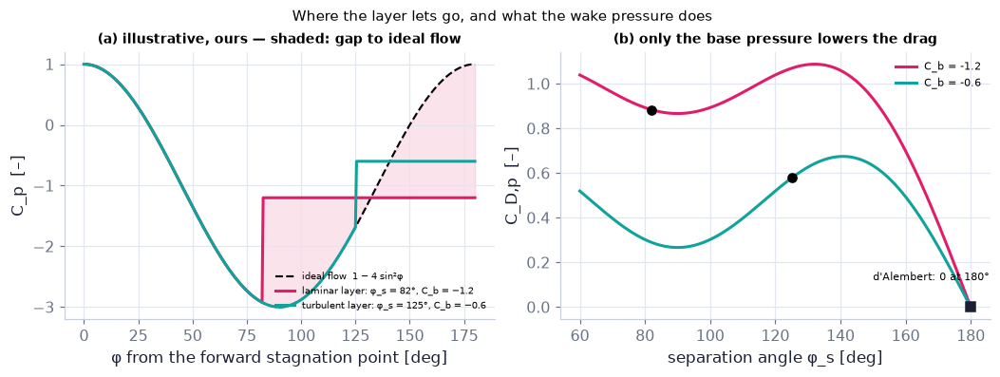

In [75]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.5, 3.5))   # the figure and its panels
a1.plot(phi, cp_ideal, "k--", lw=1.4, label="ideal flow  1 − 4 sin²φ")                                  # (a) surface pressure: ideal and two separated models
a1.plot(phi, cp_sub, color=COLORS["rose"], lw=2, label="laminar layer: φ_s = 82°, C_b = −1.2")   # draw the curve(s)
a1.plot(phi, cp_sup, color=COLORS["teal"], lw=2, label="turbulent layer: φ_s = 125°, C_b = −0.6")   # draw the curve(s)
a1.fill_between(phi, cp_sub, cp_ideal, where=phi >= 82, color=COLORS["rose"], alpha=0.12)             # the gap between real and ideal C_p (weighted by cos φ it is the form drag)
a1.set_xlabel("φ from the forward stagnation point [deg]"); a1.set_ylabel("C_p  [–]"); a1.set_ylim(-3.2, 1.2); a1.legend(fontsize=6.5, frameon=False, loc="lower right")   # axis labels (with units), limits and the panel's message
a1.set_title("(a) illustrative, ours — shaded: gap to ideal flow", fontsize=9)   # axis labels (with units), limits and the panel's message
ps_ = np.linspace(60, 179.5, 200)                                  # (b) C_D,p against the separation angle at two fixed base pressures
for cb, col in ((-1.2, COLORS["rose"]), (-0.6, COLORS["teal"])):   # loop over the cases
    a2.plot(ps_, [BB.separated_pressure_drag(p_, cb) for p_ in ps_], color=col, lw=2, label=f"C_b = {cb}")   # draw the curve(s)
a2.plot([82, 125], [BB.separated_pressure_drag(82., -1.2), BB.separated_pressure_drag(125., -0.6)], "ko", ms=6)   # the two operating points
a2.plot(180, 0, "s", color=COLORS["ink"]); a2.text(150, 0.12, "d'Alembert: 0 at 180°", fontsize=7)   # a label written on the plot
a2.set_xlabel("separation angle φ_s [deg]"); a2.set_ylabel("C_D,p  [–]"); a2.legend(fontsize=7, frameon=False); a2.set_title("(b) only the base pressure lowers the drag", fontsize=9)   # axis labels (with units), limits and the panel's message
fig.suptitle("Where the layer lets go, and what the wake pressure does", fontsize=10)   # the figure's message as its title
plt.show()   # display the figure

**What you see.** A pink wake plateau and a teal one that sits higher in (a); in (b) two curves of drag against separation angle with the two operating points (black dots) and the d'Alembert limit at 180°.

**How to read it.** The shaded gap between the real and the ideal $C_p$ is the missing pressure recovery; the form drag is that gap **weighted by** $\cos\varphi$, $C_{D,p}=\frac12\oint(C_p-C_{p,ideal})\cos\varphi\,d\varphi$ (the ideal part integrates to zero) — not its plain area: from $82^\circ$ up to where the ideal curve climbs back to the wake value, $1-4\sin^2\varphi=C_b=-1.2$, i.e. $\sin^2\varphi=0.55$, $\varphi\approx132^\circ$, the real pressure sits *above* the ideal one (it does not dip to $-3$ at the shoulder); beyond $132^\circ$ it sits *below* it (no recovery); and $\cos\varphi$ changes sign at $90^\circ$, so parts of the gap push forward and parts backward. At a fixed base pressure $C_b=-1.2$ the model gives $D(82^\circ)=0.884$, $D(90^\circ)=0.867$, $D(125^\circ)=1.07$: later separation alone does not lower it — the drop from 0.884 to 0.578 needs the base pressure to rise from $-1.2$ to $-0.6$.

**What would change if…** …a lower $C_b$ (more wake suction): bigger drag at the same $\varphi_s$.

In [76]:
ps_s = np.linspace(60, 180, 25 if not FAST else 12)                # separation angles [deg]


def frame(p_):                                                     # C_p(phi) for one separation angle at C_b = -1.2 (illustrative)
    return {"ideal": (phi[::2], cp_ideal[::2]), "separated model": (phi[::2], BB.separated_cp(phi[::2], p_, cp_base=-1.2))}   # the values for this call


fig = slider_figure(frame, "φ_s", ps_s, unit="deg", xlabel="φ from the forward stagnation point [deg]", ylabel="C_p  [–]", title="",   # one figure whose curves follow the slider; every position precomputed (P17)
                    xrange=[0, 180], yrange=[-3.2, 1.2])
step_titles(fig, [f"φ_s = {p_:.0f}°, C_b = −1.2 (illustrative): C_D,p = {BB.separated_pressure_drag(min(p_, 179.9), -1.2):.3f}" for p_ in ps_s])   # a title with numbers for every slider position
recolor(fig, {"ideal": COLORS["muted"], "separated model": COLORS["rose"]}, dashes={"ideal": "dash"})   # colours by meaning
fig.show()                                                         # drag the separation angle

**What you see.** The ideal pressure coefficient $1-4\sin^2\varphi$ and the separated model that follows it up to $\varphi_s$ (the slider) and then stays at $C_b=-1.2$; the title gives the model's $C_{D,p}$.

**How to read it.** Slide $\varphi_s$ at this fixed wake pressure: the drag does *not* fall steadily as separation moves back (it dips near 90°, rises again beyond it, and only drops to zero as $\varphi_s\to180^\circ$) — only a higher $C_b$ lowers it, and $\varphi_s=180^\circ$ recovers d'Alembert's zero.

*↪ **N75 [C]** Internal separation in diffusers, elbows and valves is the same mechanism (Example 9.2 is a diffuser); Ch. 12 pipes.*

> ⚠️ **Common confusion:** Streamlined bodies have mostly friction drag, bluff bodies mostly form drag; the same body can change class by delaying separation.

**What would change if…** …the Reynolds number grew until the layer went turbulent before separating? Then $\varphi_s$ moves back and the drag falls. That is the subject of the next two blocks, after we meet the wake at lower Re.

---

## 9.8 Flow Past a Circular Cylinder

**What is this section about?** A cylinder in a stream is the standard bluff body. As the Reynolds number rises from below 1 to above $10^6$ the flow passes through a ladder of states: symmetric creeping flow, two steady eddies behind the body,
a periodic **vortex street**, an irregular wake, and finally the layer itself turns turbulent (the drag crisis). We take the ladder in two blocks: the wake and its street (C10) and the crisis (C11).

### 🧩 Cylinder wake regimes and the Kármán vortex street `C10`

*The question:* Why does a steady stream past a cylinder shed a periodic street — and why has the street a fixed shape?

> 🔁 **Tools from earlier chapters used here** (see `knowledge/primers.md`) — used in C10

- **eigenvalues and eigenvectors** — A·b = λb: A only stretches b; non-zero b exist when det(A − λI) = 0; `np.linalg.eigvals` returns them (Ch. 2 P80).
- **complex conjugate** — z̄ = a − ib; z z̄ = |z|² ≥ 0 and z is real exactly when z = z̄ (Ch. 2 P81).
- **the complex plane in numpy** — z = x + iy with `1j`; `np.abs`, `np.angle`, `np.conj` work on whole arrays (Ch. 6 P153).
- **hyperbolic functions cosh, sinh, tanh** — cosh² − sinh² = 1, (tanh)′ = sech²; cosh x ≥ 1 with cosh 0 = 1 (Ch. 7 P168).
- **finite-difference Jacobian** — the matrix of all partial derivatives of a vector function, one column per input, by central differences (Ch. 1 P21).
- **complex velocity of a point vortex** — a vortex Γ at z₀ induces w = u − iv = (Γ/2πi)/(z − z₀), and the vortex itself moves with the conjugate of the others' w (Ch. 5 §5.7, Ch. 6).

#### The problem in plain words

Wind sings in power lines, chimneys sway, clouds line up in a zig-zag downstream of an island. Behind a cylinder the steady wake is unstable: it breaks into vortices of alternating sign. Kármán (1912) modelled them as two rows of point vortices and found that only one shape of the street
survives — the ratio of row separation to spacing is 0.28.

#### The idea

```
Re:  <1        4…40             40…200          ≳200 (irregular)     several thousand+      3×10⁵ (crisis)
     creeping  two steady       laminar         irregular vortices,   turbulent wake        layer turbulent,
     symmetric attached eddies  Kármán street   St ≈ 0.2 persists     beyond a few d        wake narrows
street:   ●  ○  ●  ○   row A (Γ), spacing a          b/a = 0.2805 ⇒ cosh(πb/a) = √2
            ○  ●  ○  ●   row B (−Γ), offset a/2
```

The thresholds in the ladder are the book's rounded, experimental values — the code returns them as labels, not as computed results.

📝 **Note.** **N76 [B], N77 [B], N80 [B]** **Regimes (the book's rounded thresholds — experimental, not computed).** $\mathrm{Re}<1$: symmetric creeping flow (vorticity diffuses, then is advected; Ch. 8's Oseen picture); $4<\mathrm{Re}<40$: two steady eddies whose length grows with Re;
$\mathrm{Re}\gtrsim40$: the wake oscillates and sheds a street; $\mathrm{Re}<200$: laminar street; above 200 irregular vortices but the shedding frequency stays; several thousand: periodic only near the cylinder, a turbulent wake beyond.

In [77]:
print("     Re   cylinder regime (the book's rounded thresholds, experimental / qualitative)")   # print the result
for Re in (0.5, 10, 100, 1000, 1e5, 1e6):   # loop over the cases
    print(f"{Re:8.1e}   {BB.cylinder_flow_regime(Re)['label']}")   # a look-up, not a calculation

     Re   cylinder regime (the book's rounded thresholds, experimental / qualitative)
 5.0e-01   creeping flow: symmetric, no wake
 1.0e+01   two steady attached eddies
 1.0e+02   laminar Karman street
 1.0e+03   irregular vortices, St stays near 0.2
 1.0e+05   subcritical: laminar separation, wide wake
 1.0e+06   supercritical: turbulent separation, narrow wake


**What does the code above do?**

`cylinder_flow_regime(Re)` returns the label of the regime and its rounded thresholds (1, 4, 40, 200, 3000, $3\times10^5$, $6\times10^5$ for the cylinder; the sphere has its own table); the numbers are the book's experimental values and enter no test — they are a look-up, marked qualitative.

📝 **Note.** **N78 [B]** **Strouhal number.** $\mathrm{St}=\frac{\Omega d}{U_\infty}\approx0.2$ *(4.102)* (recalled from Ch. 4): here the book's $\Omega$ is the shedding frequency in cycles per second, so $f=\mathrm{St}\,U/d$ — a wire of $d=2$ mm in a 10 m/s wind sings at $f=0.2\times10/0.002=1000$ Hz.

> ⚠️ **Common confusion ($\Omega$ versus $f$).** Read $\Omega$ as an *angular* frequency (rad/s) and the same formula gives $\mathrm{St}=2\pi\times0.2=1.26$; the angular frequency of the 1000 Hz tone is 6283 rad/s. Say which one your $\Omega$ is.

$$ \mathrm{St}=\frac{\Omega d}{U_\infty}\approx0.2 \qquad \text{(4.102)} $$

In [78]:
w = BB.shedding_frequency(10.0, 0.002)                             # a 2 mm wire in a 10 m/s wind, St = 0.2
print(w)                                                           # f = 1000 Hz, omega = 6283 rad/s
print(SIM.strouhal_number(1000.0, 0.002, 10.0), SIM.strouhal_number(6283.19, 0.002, 10.0))   # St with Omega = f (0.2) and with the angular frequency (1.257): the trap

{'f': 1000.0, 'omega_rad': 6283.185307179586}
0.2 1.256638


**What does the code above do?**

1. `shedding_frequency(U, d, St)` returns the cyclic frequency $f=\mathrm{St}\,U/d$ (1000 Hz) and the angular one $2\pi f$ (6283 rad/s).
2. `strouhal_number(Omega, l, U)` from Ch. 4: with $\Omega=f$ it gives 0.2; fed the angular frequency it gives $1.2566=2\pi\times0.2$ — the trap.

*↪ **N79 [C]** Vortex-induced vibration (spiral strakes break the spanwise coherence) and atmospheric Kármán streets behind mountains — stratification makes the flow two-dimensional; Ch. 13.*

> 📎 **Primer — a row of vortices: the cotangent sum.** `P213` · A point vortex of strength $\Gamma$ at $z_0$ induces the conjugate velocity $w=u-iv=\frac{\Gamma}{2\pi i}\frac1{z-z_0}$ (Ch. 5). An infinite row at $z_0+na$ ($n=0,\pm1,\pm2,\dots$) adds up, pairing $+n$ with $-n$ so the sum converges, to
$\frac{\Gamma}{2ia}\cot\frac{\pi(z-z_0)}a$. Similar lattice sums: $\sum1/(z-na)^2=(\pi/a)^2/\sin^2(\pi z/a)$ and $\sum(-1)^n/(z-na)^2=(\pi/a)^2\cos(\pi z/a)/\sin^2(\pi z/a)$.

In [79]:
import numpy as np   # arrays and maths
z = 0.3 + 0.2j                              # a point off the row (a = 1)
n = np.arange(-2000, 2001)   # sample points
print(np.sum(1/(z - n)), np.pi/np.tan(np.pi*z))   # both about 1.353-2.297j: the row sum equals pi cot(pi z)
print(np.sum(1/(z - n)**2), (np.pi/np.sin(np.pi*z))**2)   # squares: pi^2/sin^2

(1.3534145660084764-2.296811182187121j) (1.3531146409967265-2.2970111321992848j)
(6.423263741267462-6.216238787052616j) (6.424263491321619-6.216238787022636j)


> 📎 **Primer — linear stability of a steady configuration (perturb, linearise, eigenvalues).** `P214` · To test whether a steady arrangement is stable: displace it slightly, keep only terms linear in the displacement to get $d(\text{displacement})/dt=M\times\text{displacement}$, and find the eigenvalues $\lambda$ of $M$: a solution grows like
$e^{\lambda t}$, so $\mathrm{Re}\,\lambda>0$ for any eigenvalue means instability; if all $\mathrm{Re}\,\lambda\le0$ the configuration is stable (or neutral when $\mathrm{Re}\,\lambda=0$).

In [80]:
import numpy as np   # arrays and maths
M = np.array([[0., 1.], [1., 0.]])       # d/dt (x, v) = (v, x): a saddle
print(np.linalg.eigvals(M))              # [ 1. -1.]: one growing mode (Re lambda = 1 > 0): unstable
print(np.linalg.eigvals(np.array([[0., 1.], [-1., 0.]])))   # +-i: neutral oscillation

[ 1. -1.]
[0.+1.j 0.-1.j]


#### 🧮 Derivation — Kármán street stability: growth rate $\frac{\pi\Gamma}{2a^2}\lvert\frac12-\mathrm{sech}^2\frac{\pi b}a\rvert$, marginal at $\cosh\frac{\pi b}a=\sqrt2$, $b/a=0.2805$ `D14`

**What we want to show.** Explain why only one spacing of a staggered double row of point vortices does not grow.

**Assumptions.** Inviscid point vortices; infinite rows; small displacements; the alternating disturbance (wavenumber π/a) is the fastest-growing one — confirmed by scanning all k numerically (notebook).

**The plan.**

1. Sum the rows.
2. Find the street's own speed.
3. Perturb and linearise.
4. Take the alternating disturbance and reduce to a 4 × 4 matrix.
5. Read its eigenvalues.

**Tools we use** (each explained before this point): a row of vortices: the cotangent sum (primer P213) · linear stability (primer P214) · eigenvalues (ch02 P80) · complex conjugate (ch02 P81) · hyperbolic functions (ch07 P168) · sympy (ch01 P40).

**We start from**

$$ \text{The velocity of a point vortex}\ w=u-iv=\frac{\Gamma}{2\pi i}\frac1{z-z_0}\ \text{(Ch. 5; Ch. 6 complex potential)} $$

*In words:* the book only states Kármán's result 0.28; we derive it (we call it the closed form of the linear stability).

---

**Step 1 of 16 — Set up the street.**

$$ z_A=na+\tfrac{ib}2\ (\Gamma),\qquad z_B=(n+\tfrac12)a-\tfrac{ib}2\ (-\Gamma) $$

- *Why we can do this:* Two rows of counter-rotating vortices, spacing a, separation b, the lower row shifted by a/2 (the staggered street); the facing rows are checked in step 16.
- *In words:* two staggered rows.

---

**Step 2 of 16 — Recall one vortex.**

$$ w=\frac{\Gamma}{2\pi i}\,\frac1{z-z_0},\qquad\frac{dz}{dt}=\bar w $$

- *Why we can do this:* The conjugate velocity of a point vortex (Ch. 5, Ch. 6); the vortex is carried by the local velocity of all the others.
- *In words:* each vortex moves with the flow the others make.

---

**Step 3 of 16 — Sum a whole row.**

$$ w_{row}=\frac{\Gamma}{2ia}\cot\frac{\pi(z-z_0)}a $$

- *Why we can do this:* Σₙ 1/(z − na) = (π/a)cot(πz/a): pairing +n with −n makes the sum converge (primer P213).
- *In words:* an infinite row gives a cotangent.

---

**Step 4 of 16 — Find the street's own speed.**

$$ U_s=\frac\Gamma{2a}\tanh\frac{\pi b}a $$

- *Why we can do this:* Vortex A feels only row B (its own row cancels by symmetry): w = −(Γ/2ia)cot(πζ/a) with ζ = z_A − z_B = −a/2 + ib, and cot(−π/2 + iπb/a) = −i tanh(πb/a); w is real and the same for A and B, so the street translates rigidly.
- *In words:* the pattern moves as a whole.

---

**Step 5 of 16 — Perturb and linearise.**

$$ \dot\delta_i=\sum_{j,n}\frac{\Gamma_j}{2\pi i}\,\frac{\bar\delta_i-\bar\delta_{j,n}}{\overline{(z_i-z_{j,n})}^{\,2}} $$

- *Why we can do this:* Displace each vortex z → z + δ; differentiate w_i = Σ(Γ_j/2πi)/(z_i − z_j) to first order: dw = −Σ(Γ_j/2πi)(δ_i − δ_j)/(z_i − z_j)², and dδ/dt = conj(dw).
- *In words:* a linear equation for the displacements.

---

**Step 6 of 16 — Take the alternating disturbance.**

$$ \delta_{A,n}=d_A(-1)^n,\qquad\delta_{B,n}=d_B(-1)^n $$

- *Why we can do this:* The wavenumber π/a is the most dangerous one (the k-scan in the notebook confirms it for every b/a tried); it reduces the infinite system to two complex unknowns.
- *In words:* neighbours move in opposite directions.

---

**Step 7 of 16 — Reduce the sums to lattice sums.**

$$ P_{ij}=\sum_n\frac1{(\zeta_{ij}-na)^2},\qquad Q_{ij}=\sum_n\frac{(-1)^n}{(\zeta_{ij}-na)^2} $$

- *Why we can do this:* Step 6 in step 5 gives $\dot d_i=\sum_j\frac{\Gamma_j}{2\pi i}\big(\bar d_i\bar P_{ij}-\bar d_j\bar Q_{ij}\big)$; P = π²/(a² sin²(πζ/a)), Q = π² cos/(a² sin²) (P213); for i = j (n ≠ 0): π²/3a² and −π²/6a².
- *In words:* closed forms.

---

**Step 8 of 16 — Write the two equations.**

$$ \dot d_A=\frac\Gamma{2\pi i}\Big[\frac{\pi^2}{2a^2}\bar d_A-\bar P\bar d_A+\bar Q\bar d_B\Big];\ \ \dot d_B=-\frac\Gamma{2\pi i}\Big[\frac{\pi^2}{2a^2}\bar d_B-\bar P\bar d_B+\bar Q\bar d_A\Big] $$

- *Why we can do this:* Own row: P_ii − Q_ii = π²/2a²; the other row has the opposite circulation; P_BA = P_AB and Q_BA = Q_AB because sin² and cos are even.
- *In words:* two coupled equations.

---

**Step 9 of 16 — Evaluate at the staggered offset.**

$$ \sin\frac{\pi\zeta}a=-\cosh\frac{\pi b}a,\ \ \cos\frac{\pi\zeta}a=i\sinh\frac{\pi b}a $$

- *Why we can do this:* ζ = −a/2 + ib: sin(−π/2 + iπb/a) = −cos(iπb/a) = −cosh and cos(−π/2 + iπb/a) = sin(iπb/a) = i sinh. Hence P = π²/(a²cosh²) is real and Q = iπ² sinh/(a²cosh²) imaginary.
- *In words:* the lattice sums in hyperbolic functions.

---

**Step 10 of 16 — Conjugate the lattice sums.**

$$ \bar P=\frac{\pi^2}{a^2\cosh^2(\pi b/a)},\qquad \bar Q=-\frac{i\pi^2\sinh(\pi b/a)}{a^2\cosh^2(\pi b/a)} $$

- *Why we can do this:* Step 9 made P real and Q purely imaginary, so complex conjugation leaves P unchanged and flips the sign of Q; these barred sums are the ones that stand in the two equations of step 8, and we need them before we can simplify those equations.
- *In words:* the two sums, ready to insert.

---

**Step 11 of 16 — Insert and simplify.**

$$ \dot d_A=-\frac{i\pi}2\big[\gamma\bar d_A-i\sigma\bar d_B\big],\ \ \dot d_B=\frac{i\pi}2\big[\gamma\bar d_B-i\sigma\bar d_A\big] $$

- *Why we can do this:* With Γ = a = 1: Γ/2πi = −i/2π; γ = ½ − sech²(πb) and σ = sinh(πb)/cosh²(πb) collect the coefficients (units Γ/a² restored at the end).
- *In words:* two numbers γ, σ control everything.

---

**Step 12 of 16 — Split into real and imaginary parts.**

$$ \dot{\mathbf x}=\frac\pi2\begin{pmatrix}0&-\gamma&-\sigma&0\\-\gamma&0&0&\sigma\\\sigma&0&0&\gamma\\0&-\sigma&\gamma&0\end{pmatrix}\mathbf x,\ \ \mathbf x=(x_A,y_A,x_B,y_B) $$

- *Why we can do this:* d = x + iy, d̄ = x − iy: collect real and imaginary parts of step 11. A real linear system: its eigenvalues decide stability (P214).
- *In words:* a 4 × 4 matrix.

---

**Step 13 of 16 — Factorise the characteristic polynomial.**

$$ \det(M-\mu I)=\big[(\mu-\gamma)^2+\sigma^2\big]\big[(\mu+\gamma)^2+\sigma^2\big] $$

- *Why we can do this:* Direct expansion of the determinant (sympy check): two conjugate quadratics; the ODE eigenvalues are λ = (πΓ/2a²)μ.
- *In words:* μ = ±γ ± iσ.

---

**Step 14 of 16 — Read the growth rate.**

$$ \mathrm{Re}\,\lambda=\frac{\pi\Gamma}{2a^2}\Big\lvert\tfrac12-\mathrm{sech}^2\frac{\pi b}a\Big\rvert $$

- *Why we can do this:* The real part of μ = ±γ ± iσ is ±γ; growth is the positive one, |γ|.
- *In words:* it grows unless γ = 0.

---

**Step 15 of 16 — Find the marginal spacing.**

$$ \gamma=0\ \Leftrightarrow\ \cosh\frac{\pi b}a=\sqrt2\ \Leftrightarrow\ \frac ba=\frac1\pi\cosh^{-1}\sqrt2=0.2805 $$

- *Why we can do this:* γ = ½ − 1/cosh² vanishes when cosh² = 2; there σ = ½, so λ = ±i(π/4)Γ/a²: pure oscillation.
- *In words:* one neutral spacing.

---

**Step 16 of 16 — Check the facing rows.**

$$ \begin{array}{l}\det(M-\mu I)=\Big(\mu^2-\frac14\Big)^2\ \Rightarrow\ \mathrm{Re}\,\lambda=\frac{\pi\Gamma}{4a^2}\ \text{(μ = eigenvalue of M/(π/2) as in steps 12–15;} \\ \text{in λ = (π/2)μ the polynomial is}\ (\lambda^2-\pi^2/16)^2\ \text{; eigenvalues ±π/4 either way)}\end{array} $$

- *Why we can do this:* Repeat steps 7–13 with ζ = ib: P = −π²/(a² sinh²), Q = −π² cosh/(a² sinh²) (real); the polynomial no longer depends on b (sympy check): unstable at every spacing.
- *In words:* facing rows never settle.

---

**Result**

$$ \begin{array}{l}\text{growth}\ =\frac{\pi\Gamma}{2a^2}\lvert\frac12-\mathrm{sech}^2\frac{\pi b}a\rvert\ \text{, zero only at}\ b/a=\frac1\pi\cosh^{-1}\sqrt2=0.2805\ \text{; facing rows grow} \\ \text{at π/4 Γ/a² for every b}\end{array} $$

*In words:* the street's shape is fixed.

**What it means.** Nature's streets have b/a ≈ 0.28 (and St ≈ 0.2, C10); viscosity and finite cores are not in the model, so it explains the shape, not the onset at Re ≈ 40.

**Check it.** Units 1/s ✓ (Γ/a²). Γ = a = 1: b/a = 0.1 → 0.6400, 0.2 → 0.2982, 0.25 → 0.1099, 0.3 → 0.0663, 0.5 → 0.5359 (all equal to the numerical maximum over k of the full linearisation, 1e-6). At 0.2805 the eigenvalues are ±0.7854 i. Street speed at the stable spacing: tanh(arccosh √2) = 1/√2, U_s = 0.3536 Γ/a.

In [81]:
import sympy as sp                                               # symbolic algebra
b = sp.symbols('b', positive=True)                               # b/a, with a = Gamma = 1
C, S = sp.symbols('C S', positive=True)                          # C = cosh(pi b), S = sinh(pi b); we use C^2 - S^2 = 1 at the end
lam = sp.symbols('lam')                                          # eigenvalue variable of the ODE
xA, yA, xB, yB = sp.symbols('xA yA xB yB', real=True)            # displacements d_A = xA + i yA, d_B = xB + i yB
dA, dB = xA + sp.I*yA, xB + sp.I*yB                              # the two complex unknowns of step 6
def jacobian(Pbar, Qbar):                                        # steps 8 and 11 rebuilt: the real 4 x 4 matrix from the conjugated lattice sums
    c = 1/(2*sp.pi*sp.I)                                         # Gamma/(2 pi i) with Gamma = 1
    rhsA = c*((sp.pi**2/2 - Pbar)*sp.conjugate(dA) + Qbar*sp.conjugate(dB))    # d/dt d_A of step 8
    rhsB = -c*((sp.pi**2/2 - Pbar)*sp.conjugate(dB) + Qbar*sp.conjugate(dA))   # d/dt d_B of step 8 (the other row has -Gamma)
    rows = [f(sp.expand(e)) for e in (rhsA, rhsB) for f in (sp.re, sp.im)]   # real and imaginary parts of both equations
    return sp.Matrix([[sp.diff(r, v) for v in (xA, yA, xB, yB)] for r in rows])   # linear system: the Jacobian is the matrix
M = jacobian(sp.pi**2/C**2, -sp.I*sp.pi**2*S/C**2)               # staggered street: conjugated sums of step 10 (P real, Q imaginary)
gam, sig = sp.Rational(1, 2) - 1/C**2, S/C**2                    # step 11: gamma and sigma
p = sp.expand((M - lam*sp.eye(4)).det().subs(S, sp.sqrt(C**2 - 1)))    # characteristic polynomial, with S^2 = C^2 - 1
q = sp.expand(((lam - sp.pi*gam/2)**2 + (sp.pi*sig/2)**2)*((lam + sp.pi*gam/2)**2 + (sp.pi*sig/2)**2)).subs(S, sp.sqrt(C**2 - 1))   # step 13's factorisation
print("step 13, factorisation of the characteristic polynomial:", sp.simplify(p - sp.expand(q)))   # 0
print("step 15, marginal spacing:", sp.solve(sp.cosh(sp.pi*b)**2 - 2, b))   # b = acosh(sqrt 2)/pi
Mf = jacobian(-sp.pi**2/S**2, -sp.pi**2*C/S**2)                  # facing rows (step 16): P and Q are real, xi = i b
pf = sp.simplify(sp.expand((Mf - lam*sp.eye(4)).det().subs(C, sp.sqrt(S**2 + 1))))   # its characteristic polynomial
print("step 16, facing rows:", sp.simplify(pf - (lam**2 - sp.pi**2/16)**2))   # 0: independent of b, eigenvalues +-pi/4

step 13, factorisation of the characteristic polynomial: 0
step 15, marginal spacing: [log(1 + sqrt(2))/pi]


step 16, facing rows: 0


> ⚠️ **Common confusion (traps in `D14`):** The sum over images converges only in symmetric pairs; both rows are counter-rotating; the growth is zero only at the marginal spacing (a V-shaped curve); the alternating mode is the worst, not the only one; overall factors Γ/a².

#### ✏️ Tiny example: the street speed and the wire

At the stable spacing $\tanh(\pi b/a)=\tanh(\cosh^{-1}\sqrt2)=1/\sqrt2$ (since $\mathrm{sech}^2=\frac12$), so the street moves at $U_s=\frac{\Gamma}{2a}/\sqrt2$. For $a=5$ cm and $\Gamma=0.5$ m²/s that is $5\times0.7071=3.54$ m/s — slower than
the 10 m/s wind that created it (the vortices are left behind). The row separation is $b=0.2805\,a=1.40$ cm. For $d=2$ mm in a 10 m/s wind, $f=1000$ Hz.

In [82]:
ratio = BB.karman_street_ratio()                                  # arccosh(sqrt 2)/pi: the neutral spacing b/a
print("b/a =", ratio)                                             # 0.280550
print("  b/a    growth (numerical max over k)   closed form (pi Gamma / 2 a^2)|1/2 - sech^2(pi b/a)|")   # print the result
for r in (0.1, 0.2, 0.25, ratio, 0.3, 0.5, 1.0):   # loop over the cases
    print(f"{r:7.4f} {BB.karman_street_growth(r):14.4f} {BB.karman_street_growth_closed(r):24.4f}")   # Gamma = a = 1: growth rate in units of Gamma/a^2
print("non-staggered rows (offset 0):", BB.karman_street_growth(0.3, offset=0.0), " pi/4 =", np.pi/4)   # print the result
print("spectrum at the neutral spacing:", np.round(BB.karman_street_spectrum(ratio), 6))   # print the result
print("street speed for a = 5 cm, Gamma = 0.5 m^2/s:", BB.karman_street_velocity(0.05, 0.05*ratio, 0.5), "m/s")   # print the result

b/a = 0.28054992616959007
  b/a    growth (numerical max over k)   closed form (pi Gamma / 2 a^2)|1/2 - sech^2(pi b/a)|
 0.1000         0.6400                   0.6400


 0.2000         0.2982                   0.2982
 0.2500         0.1099                   0.1099


 0.2805         0.0000                   0.0000
 0.3000         0.0663                   0.0663


 0.5000         0.5359                   0.5359
 1.0000         0.7737                   0.7737


non-staggered rows (offset 0): 0.785398163397449  pi/4 = 0.7853981633974483
spectrum at the neutral spacing: [-0.+0.7854j -0.-0.7854j  0.-0.7854j  0.+0.7854j]
street speed for a = 5 cm, Gamma = 0.5 m^2/s: 3.5355339059327378 m/s


**What does the code above do?**

1. `karman_street_growth` builds the linearised velocity of the periodic street from lattice sums and takes the largest growth rate over the perturbation wavenumber $k\in(0,\pi/a]$ (in units of $\Gamma/a^2$).
2. The closed form $\frac{\pi\Gamma}{2a^2}\big|\frac12-\mathrm{sech}^2\frac{\pi b}a\big|$ (D14 step 14) is its value at $k=\pi/a$, the most dangerous mode: 0.6400 at $b/a=0.1$, 0.2982 at 0.2, 0.1099 at 0.25, 0 at 0.2805, 0.0663 at 0.3, 0.5359 at 0.5, 0.7737 at 1.
3. A non-staggered (facing) pair of rows grows at $\pi/4$ for every $b/a$; at the neutral spacing the four eigenvalues are $\pm0.7854i$ — pure oscillation. The street speed at the neutral spacing is 3.536 m/s for the wire example.

In [83]:
# from scratch: the induced velocity of a periodic street by brute-force summation (a = Gamma = 1, images n = -2000..2000), its 4 x 4 Jacobian by central differences
def street_rhs(state, b, N=2000):                                 # d/dt of (d_A, d_B) for the alternating mode; state = (xA, yA, xB, yB)
    dA_, dB_ = state[0] + 1j*state[1], state[2] + 1j*state[3]     # displacements of vortex A0 and B0 (every other vortex carries +/- the same, alternately)
    n = np.arange(-N, N + 1); sg = (-1.0)**n                      # image index and the alternating sign
    zA = n + 0.5j*b + dA_*sg; zB = (n + 0.5) - 0.5j*b + dB_*sg    # positions of all A and B vortices (Gamma_A = +1, Gamma_B = -1)
    zA0, zB0 = 0.5j*b + dA_, 0.5 - 0.5j*b + dB_                   # the two vortices whose velocities we want
    wA = (np.sum(1/(zA0 - zA[n != 0])) - np.sum(1/(zA0 - zB)))/(2j*np.pi)   # conj velocity at A0: own row (without itself) minus the other row
    wB = (np.sum(1/(zB0 - zA)) - np.sum(1/(zB0 - zB[n != 0])))/(2j*np.pi)   # conj velocity at B0: row A minus own row (without itself)
    vA, vB = np.conj(wA), np.conj(wB)                             # dz/dt = conj(w)
    return np.array([vA.real, vA.imag, vB.real, vB.imag])   # the values for this call
for b_ in (0.2, 0.5):   # loop over the cases
    h_ = 1e-6; J = np.zeros((4, 4))                               # central-difference Jacobian at the undisturbed street
    for j in range(4):   # loop over the cases
        e_ = np.zeros(4); e_[j] = h_
        J[:, j] = (street_rhs(e_, b_) - street_rhs(-e_, b_))/(2*h_)
    ev = np.linalg.eigvals(J)                                     # eigenvalues of the linearised system
    print(f"b/a = {b_}: max Re(eigenvalue) = {ev.real.max():.6f}   closed form = {BB.karman_street_growth_closed(b_):.6f}")   # print the result
    assert np.isclose(ev.real.max(), BB.karman_street_growth_closed(b_), rtol=1e-4)   # the closed form is the alternating-mode growth
from fluidpy.core import biot_savart as BS                        # Ch. 5: velocity induced by point vortices
u1 = BS.point_vortex_velocity(np.array([1.0, 0.0]), np.array([[0.0], [0.0]]), np.array([1.0]))   # one vortex (Gamma = 1) seen from distance 1
print("one vortex at distance 1:", u1, " Gamma/(2 pi r) =", 1/(2*np.pi)); assert np.isclose(np.hypot(*u1), 1/(2*np.pi))   # the building block of the street

b/a = 0.2: max Re(eigenvalue) = 0.298247   closed form = 0.298247
b/a = 0.5: max Re(eigenvalue) = 0.535906   closed form = 0.535906
one vortex at distance 1: [-0.      0.1592]  Gamma/(2 pi r) = 0.15915494309189535


**What does the code above do?**

1. `street_rhs` sums the velocity induced at the two reference vortices by 4001 images in each row (brute force, no closed-form lattice sums), for a small alternating displacement.
2. A central-difference Jacobian (4 × 4) linearises that velocity about the undisturbed street; its eigenvalues are the growth rates.
3. The largest real part is asserted equal to the closed form `karman_street_growth_closed` of D14, for $b/a=0.2$ and $0.5$.
4. The last lines check the building block: one point vortex induces $\Gamma/2\pi r$ at distance $r$ (Ch. 5).

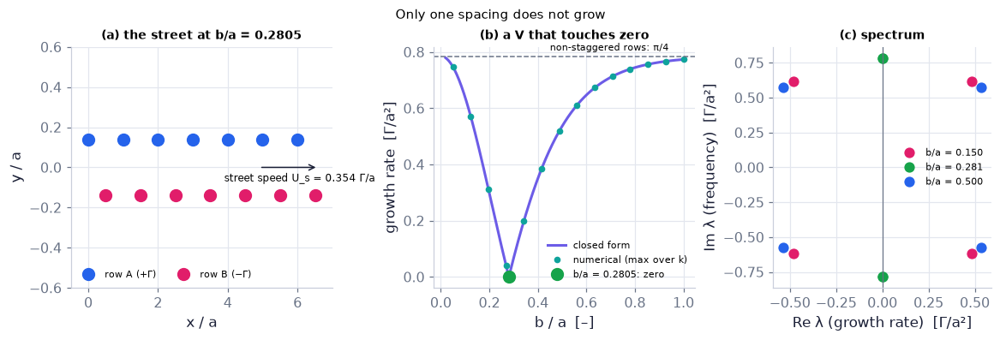

In [84]:
ratio = BB.karman_street_ratio()
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(10.5, 3.5), gridspec_kw=dict(width_ratios=[1.2, 1.2, 1]))   # the figure and its panels
n_ = np.arange(7)                                                  # (a) the staggered street at the stable spacing (a = 1)
a1.plot(n_, np.full(7, ratio/2), "o", color=COLORS["blue"], ms=9, label="row A (+Γ)"); a1.plot(n_ + 0.5, np.full(7, -ratio/2), "o", color=COLORS["rose"], ms=9, label="row B (−Γ)")   # draw the curve(s)
Us = BB.karman_street_velocity(1.0, ratio, 1.0)                    # street speed in units of Gamma/a
a1.annotate("", xy=(6.6, 0.0), xytext=(4.9, 0.0), arrowprops=dict(arrowstyle="->", color=COLORS["ink"])); a1.text(3.9, -0.07, f"street speed U_s = {Us:.3f} Γ/a", fontsize=8)   # a label written on the plot
a1.set_ylim(-0.6, 0.6); a1.set_xlim(-0.5, 7); a1.set_xlabel("x / a"); a1.set_ylabel("y / a"); a1.legend(fontsize=7, frameon=False, ncol=2, loc="lower left"); a1.set_title(f"(a) the street at b/a = {ratio:.4f}", fontsize=9)   # axis labels (with units), limits and the panel's message
rr = np.linspace(0.05, 1.0, 14); grow = [BB.karman_street_growth(r_) for r_ in rr]        # (b) growth rate against b/a
rc = np.linspace(0.02, 1.0, 300)   # sample points
a2.plot(rc, BB.karman_street_growth_closed(rc), color=COLORS["accent"], lw=2, label="closed form")   # draw the curve(s)
a2.plot(rr, grow, "o", color=COLORS["teal"], ms=4, label="numerical (max over k)")   # draw the curve(s)
a2.plot(ratio, 0, "o", color="#16a34a", ms=9, label="b/a = 0.2805: zero"); a2.axhline(np.pi/4, color=COLORS["muted"], ls="--", lw=1); a2.text(0.45, np.pi/4 + 0.02, "non-staggered rows: π/4", fontsize=7)
a2.set_xlabel("b / a  [–]"); a2.set_ylabel("growth rate  [Γ/a²]"); a2.legend(fontsize=7, frameon=False, loc="lower right"); a2.set_title("(b) a V that touches zero", fontsize=9)   # axis labels (with units), limits and the panel's message
for r_, col in ((0.15, COLORS["rose"]), (ratio, "#16a34a"), (0.5, COLORS["blue"])):              # (c) eigenvalues in the complex plane
    ev = BB.karman_street_spectrum(r_); a3.plot(ev.real, ev.imag, "o", color=col, ms=7, label=f"b/a = {r_:.3f}")   # draw the curve(s)
a3.axvline(0, color=COLORS["muted"], lw=0.8); a3.set_xlabel("Re λ (growth rate)  [Γ/a²]"); a3.set_ylabel("Im λ (frequency)  [Γ/a²]"); a3.legend(fontsize=7, frameon=False); a3.set_title("(c) spectrum", fontsize=9)   # axis labels (with units), limits and the panel's message
fig.suptitle("Only one spacing does not grow", fontsize=10)   # the figure's message as its title
plt.show()   # display the figure

**What you see.** A V-shaped growth curve touching zero at 0.2805 in (b) and, in (c), the four eigenvalues sitting on the imaginary axis (pure oscillation) for the green spacing but off it, in quartets $\lambda=\pm\lambda_r\pm i\lambda_i$ for the others (eigenvalue $\lambda$ as in D14: growth rate $\lambda_r=\mathrm{Re}\,\lambda$, frequency $\lambda_i=\mathrm{Im}\,\lambda$; this $\lambda$ has nothing to do with Thwaites' $\lambda$ of C07).

**How to read it.** At 0.2805 all four eigenvalues have $\mathrm{Re}=0$: neither growth nor decay; anywhere else at least one pair has $\mathrm{Re}\ne0$. A non-staggered pair of rows (facing vortices) grows at $\pi/4$ whatever the spacing.

**What would change if…** …offset 0 (non-staggered): growth rate $\mathrm{Re}\,\lambda=\pi/4$ at every $b/a$, no neutral point at all.

In [85]:
nfr = 30 if not FAST else 16
tt = np.linspace(0, 10, nfr)                                        # time in units of a^2/Gamma
fig, axs = plt.subplots(2, 1, figsize=(9, 3.6), sharex=True, layout="none"); fixed_layout(fig, left=0.07, bottom=0.14, top=0.90, wspace=0.1); fig.subplots_adjust(hspace=0.35)   # the figure and its panels
cases = ((ratio, COLORS["blue"], "b/a = 0.2805: neutral"), (0.15, COLORS["rose"], "b/a = 0.15: grows"))
arts = []
for ax_, (r_, col, lab) in zip(axs, cases):   # loop over the cases
    sA, = ax_.plot([], [], "o", color=COLORS["blue"], ms=6); sB, = ax_.plot([], [], "o", color=COLORS["rose"], ms=6)   # draw the curve(s)
    ax_.set_xlim(-0.5, 11.5); ax_.set_ylim(-0.7, 0.7); ax_.set_ylabel("y / a"); arts.append((sA, sB, r_, ax_, lab))   # axis labels (with units), limits and the panel's message
axs[1].set_xlabel("x / a  (street frame; linear theory — beyond |ζ| ~ b it is only a picture)")   # axis labels (with units), limits and the panel's message


def update(i):                                                      # frame i = time tt[i]
    for sA, sB, r_, ax_, lab in arts:   # loop over the cases
        pos = BB.karman_street_positions(tt[i], r_, eps=0.004, mode="unstable", n_cells=12)   # linear evolution of a small alternating kick
        sA.set_data(pos["zA"].real, pos["zA"].imag); sB.set_data(pos["zB"].real, pos["zB"].imag)
        ax_.set_title(f"{lab} — growth rate {pos['growth']:.3f} Γ/a²", fontsize=9)   # axis labels (with units), limits and the panel's message
    return []   # the values for this call


show_animation(animate(update, frames=nfr, fig=fig, interval=100))   # smooth video

**What you see.** The upper street (spacing 0.2805) keeps its zig-zag, wobbling gently; the lower one (spacing 0.15) is torn: the alternating kick grows until the vortices bunch.

**How to read it.** The growth e-folds every $1/\mathrm{Re}\,\lambda\approx2$ time units for $b/a=0.15$ (growth rate $\mathrm{Re}\,\lambda=0.48$), so a 0.4 % kick reaches order $a$ within ten units; at the neutral spacing the kick only oscillates.

**What would change if…** …$b/a=0.5$: growth again ($\mathrm{Re}\,\lambda=0.54$), from the other side of the neutral spacing.

#### 🎮 Interactive: Why is the vortex street's shape fixed at b/a ≈ 0.28?

**Why interactive rather than a static figure:** Dragging $b/a$ and the stagger changes the growth live, and a small kick visibly grows or not; the eigenvalue spectrum collapses onto the imaginary axis at exactly $\cosh(\pi b/a)=\sqrt2$.

**What to try:**
- Drag $b/a$ from 0.1 to 0.5: where does the growth touch zero?
- Set the stagger to 0: what happens?
- Press 'kick' at the stable spacing and at 0.15.
- Open Derivation D14 and watch the factorised polynomial.

In [86]:
show_viz("ch09", "karman_street_stability")   # full-width explainer; ⤢ Full screen for more room

[explainer ch09/karman_street_stability]

**What would change if…** …viscosity and finite cores are added? The point-vortex street is only marginally stable at 0.2805; real streets are helped by viscous spreading. Kármán's result explains the shape, not the onset at Re ≈ 40 — that is Ch. 11.

### 🧩 The drag crisis: the layer turns turbulent and the drag falls `C11`

*The question:* Why does the drag fall when the flow gets faster?

#### The problem in plain words

Roughen a golf ball with dimples and it flies farther; a rough cylinder can have less drag than a smooth one; a cricket ball swings when its seam side is rough. In each case the same thing: transition to a turbulent layer happens at a lower speed on the rough side.
Faster is not always more drag.

#### The idea

```
laminar layer separates near 82° (from the front stagnation point)  →  wide wake, low pressure, C_D ~ 1
turbulent layer, fuller profile, holds on to ~125°                  →  narrower wake, higher wake pressure, C_D ~ 0.3–0.6
```

The angles and drag levels are the book's rounded experimental values (qualitative); the causal chain is what the notebook computes.

📝 **Note.** **N81 [B]** **Subcritical flow (below the crisis).** Laminar separation near 82°, a nearly flat wake pressure below the front value, and drag that is mostly form drag: $C_D$ near unity and constant over decades of Re. The measured $C_p$ distribution is drawn qualitatively by
the separated model of C09 (Fig. 9.20 remade below); the numbers 82°, 125° and $3\times10^5$ are the book's rounded, experimental values.

In [87]:
for Re, rough in ((1e5, False), (3e5, False), (1e6, False), (1e5, True)):    # subcritical, at the band edge, supercritical, rough (already supercritical)
    s = BB.drag_crisis_state(Re, rough=rough)
    print(f"Re = {Re:7.1e} rough = {str(rough):5s} {s['label']:52s} phi_s = {s['phi_sep_deg']:5.1f} deg  C_b = {s['cb']}  C_D,p(model) = {s['cd_model']:.3f}")   # print the result
print("schematic C_D of a smooth cylinder (qualitative, no dataset):", np.round(BB.cylinder_cd_schematic(np.logspace(-1, 7, 5)), 3))   # sample points

Re = 1.0e+05 rough = False subcritical: laminar separation, wide wake           phi_s =  82.0 deg  C_b = -1.2  C_D,p(model) = 0.884
Re = 3.0e+05 rough = False critical: drag crisis                                phi_s =  82.0 deg  C_b = -1.2  C_D,p(model) = 0.884
Re = 1.0e+06 rough = False supercritical: turbulent separation, narrow wake     phi_s = 125.0 deg  C_b = -0.6  C_D,p(model) = 0.578
Re = 1.0e+05 rough = True  supercritical: turbulent separation, narrow wake     phi_s = 125.0 deg  C_b = -0.6  C_D,p(model) = 0.578
schematic C_D of a smooth cylinder (qualitative, no dataset): [58.386  2.8    1.     1.176  0.7  ]


**What does the code above do?**

1. `drag_crisis_state` looks up the regime and returns our illustrative separation angle (82° below the crisis, 125° above), base pressure ($-1.2$ or $-0.6$, ours) and the model's pressure drag; every value is marked qualitative.
2. A rough cylinder at $\mathrm{Re}=10^5$ is already supercritical: roughness moves the transition to a lower Reynolds number.
3. `cylinder_cd_schematic` interpolates rounded anchor points: a *schematic*, not a dataset. Below $\mathrm{Re}=1$ it follows **Lamb's asymptote**, Lamb's (1911) low-Reynolds-number (Oseen-type) formula for a cylinder, $C_D\approx8\pi/[\mathrm{Re}\,(2.002-\ln\mathrm{Re})]$, in which the drag coefficient grows like $1/\mathrm{Re}$ (the creeping-flow limit of Ch. 8), with a slowly varying logarithmic correction.
4. Our pressure-only model lowers the drag from 0.884 to 0.578 across the crisis, a ratio of only 0.65 — a **weaker** drop than the book's; measured cylinders lose a much larger fraction (the book says roughly a factor of three to four). The model has no skin friction and no wake-width physics, so it shows the *mechanism* (later separation and a higher base pressure), not the size — a qualitative statement.

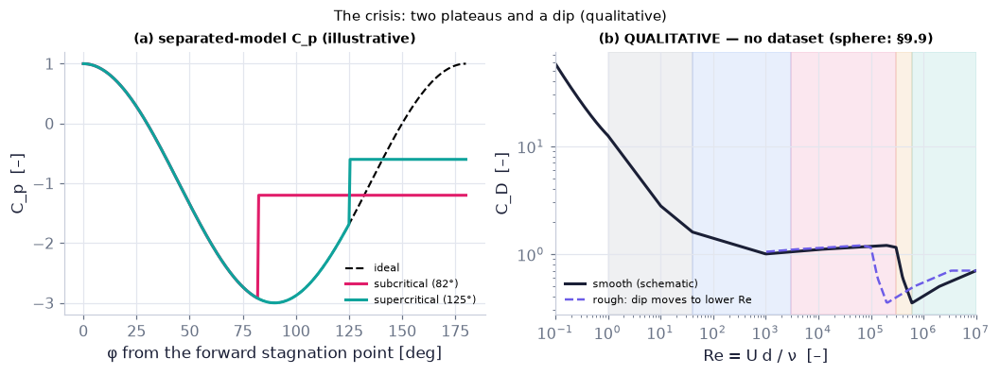

In [88]:
Rev = np.logspace(-1, 7, 400)   # sample points
th_ = BB.cylinder_flow_regime(1.0)["thresholds"]                  # the book's rounded thresholds (qualitative)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.5, 3.5))   # the figure and its panels
a1.plot(phi, cp_ideal, "k--", lw=1.4, label="ideal"); a1.plot(phi, cp_sub, color=COLORS["rose"], lw=2, label="subcritical (82°)"); a1.plot(phi, cp_sup, color=COLORS["teal"], lw=2, label="supercritical (125°)")   # draw the curve(s)
a1.set_xlabel("φ from the forward stagnation point [deg]"); a1.set_ylabel("C_p  [–]"); a1.legend(fontsize=7, frameon=False, loc="lower right"); a1.set_title("(a) separated-model C_p (illustrative)", fontsize=9)   # axis labels (with units), limits and the panel's message
for lo, hi, col in ((th_["creeping"], th_["street_onset"], COLORS["muted"]), (th_["street_onset"], th_["turbulent_wake"], COLORS["blue"]), (th_["turbulent_wake"], th_["critical"], COLORS["rose"]), (th_["critical"], th_["supercritical"], COLORS["amber"]), (th_["supercritical"], 1e7, COLORS["teal"])):   # loop over the cases
    a2.axvspan(lo, hi, color=col, alpha=0.10)                     # regimes shaded
a2.loglog(Rev, BB.cylinder_cd_schematic(Rev), color=COLORS["ink"], lw=2, label="smooth (schematic)")   # curve(s) on logarithmic axes
rr_ = Rev >= 1e3                                                 # roughness matters only once the layer is thin and separating (Re >~ 10^3)
a2.loglog(Rev[rr_], BB.cylinder_cd_schematic(3*Rev[rr_]), color=COLORS["accent"], lw=1.6, ls="--", label="rough: dip moves to lower Re")   # curve(s) on logarithmic axes
a2.set_xlim(0.1, 1e7); a2.set_xlabel("Re = U d / ν  [–]"); a2.set_ylabel("C_D  [–]"); a2.legend(fontsize=7, frameon=False, loc="lower left"); a2.set_title("(b) QUALITATIVE — no dataset (sphere: §9.9)", fontsize=9)   # axis labels (with units), limits and the panel's message
fig.suptitle("The crisis: two plateaus and a dip (qualitative)", fontsize=10)   # the figure's message as its title
plt.show()   # display the figure

**What you see.** Two $C_p$ plateaus (a lower pink one and a higher teal one) in (a); in (b) a schematic $C_D(\mathrm{Re})$ with shaded regimes, a plateau near unity and a dip at the critical band, and a dashed copy with the dip moved to lower Re.

**How to read it.** Before the crisis $C_D\approx1$, after it about 0.3–0.6 (the book's rounded values); panel (b) is a schematic and must not be used for numbers — the tested sphere curve is in §9.9 below.

**What would change if…** …a rougher surface: the dip appears at a smaller Re (dashed curve).

#### 🎮 Interactive: Why does drag fall when the flow gets faster?

**Why interactive rather than a static figure:** Re is a log-scale dial from 0.1 to $10^7$ that moves the schematic flow, the separation angle, the $C_p$ distribution and $C_D$ together, so the reader sees the causal chain, not four disconnected figures; the roughness toggle shows the crisis move.

**What to try:**
- Slide Re from 10 to $10^7$: name each regime as the status changes.
- Set 'rough' at Re = $10^5$ (before the crisis): what happened to $C_D$?
- Switch to the sphere mode: how does the dip compare?
- Change the wake pressure $C_b$: how sensitive is the drag?

In [89]:
show_viz("ch09", "cylinder_drag_crisis")   # full-width explainer; ⤢ Full screen for more room

[explainer ch09/cylinder_drag_crisis]

**N82 [C]** — three counter-intuitive points.

> ⚠️ **Common confusion.** (i) A tiny viscosity changes everything ($\nu\to0$ is singular: d'Alembert's paradox is resolved by the boundary layer and separation, C01 and C09); (ii) a symmetric problem has an
asymmetric solution (the street); (iii) roughness can *reduce* the drag of a blunt body. Ch. 11 and Ch. 14 return to them.

---

## 9.9 Flow Past a Sphere and the Dynamics of Sports Balls

**What is this section about?** The sphere shows the same drag crisis as the cylinder (at a higher Reynolds number, near $5\times10^5$ for a smooth sphere) — and the crisis explains why a cricket ball swings, why a tennis ball can curve the "wrong" way,
and why a baseball knuckles. These are all consequences of C11, so the notes below continue that block; each has a figure and a number from our functions, none from the book.

**C11 (continued): the sphere.**

📝 **Note.** **N83 [B]** **Sphere regimes.** At low Re a doughnut-shaped attached eddy; above $\mathrm{Re}\approx130$ the wake oscillates and sheds loops, not a regular street; transition at $\mathrm{Re}_{cr}\approx5\times10^5$ with a sudden dip of $C_D$.
*Flag:* the book says about $5\times10^5$ for the sphere, while the code's default $\mathrm{Re}_{cr}=3\times10^5$ is an illustrative argument (Morrison's correlation, benchmarked in Ch. 4, dips near $4\times10^5$: the same crisis, differently rounded).

> ⚠️ **Common confusion.** The book borrows the cylinder's $4<\mathrm{Re}<40$ range for the sphere's steady eddy; sphere separation actually starts near $\mathrm{Re}\approx20$ (literature value, not the book's).

In [90]:
Rs = np.logspace(-1, 7, 200)                                       # Reynolds numbers on the diameter
cd = SIM.sphere_drag_coefficient(Rs, "morrison")                   # Morrison's correlation (tested in Ch. 4): the sphere C_D(Re) curve
print(np.round(SIM.sphere_drag_coefficient(np.array([1e2, 1e5, 2e5, 4e5, 1e6])), 4))   # 1.038 0.4257 0.4159 0.093 0.1296: the dip near 4e5
print("Stokes 24/Re and Oseen at Re = 0.1:", CRP.stokes_drag_coefficient(0.1), CRP.oseen_drag_coefficient(0.1), "| Morrison:", SIM.sphere_drag_coefficient(0.1, "morrison"))   # print the result
for Re in (0.5, 50, 1e3, 1e5, 5e5, 1e6):   # loop over the cases
    print(f"{Re:8.1e}  {BB.sphere_flow_regime(Re)['label']}")      # the sphere's regime look-up (rounded thresholds; critical band 3e5-8e5)

[1.0381 0.4257 0.4159 0.093  0.1296]
Stokes 24/Re and Oseen at Re = 0.1: 240.0 244.5 | Morrison: 240.22115950498508
 5.0e-01  creeping flow: symmetric, no wake
 5.0e+01  steady wake with an attached doughnut eddy
 1.0e+03  unsteady wake, loops shed (no regular street)
 1.0e+05  unsteady wake, loops shed (no regular street)
 5.0e+05  critical: drag crisis
 1.0e+06  supercritical: turbulent separation, narrow wake


**What does the code above do?**

1. `sphere_drag_coefficient(Re, "morrison")` is the empirical curve of Ch. 4: 1.038 at $\mathrm{Re}=100$, a plateau near 0.4 up to $2\times10^5$, a sudden dip to 0.093 at $4\times10^5$ and a partial recovery.
2. Stokes ($24/\mathrm{Re}$) and Oseen ($\frac{24}{\mathrm{Re}}(1+\frac3{16}\mathrm{Re})$) agree with Morrison's curve at $\mathrm{Re}=0.1$ within 2 %.
3. `sphere_flow_regime` is the regime look-up (the book's rounded thresholds; its critical band starts at $3\times10^5$ in code, $\approx5\times10^5$ in the book).

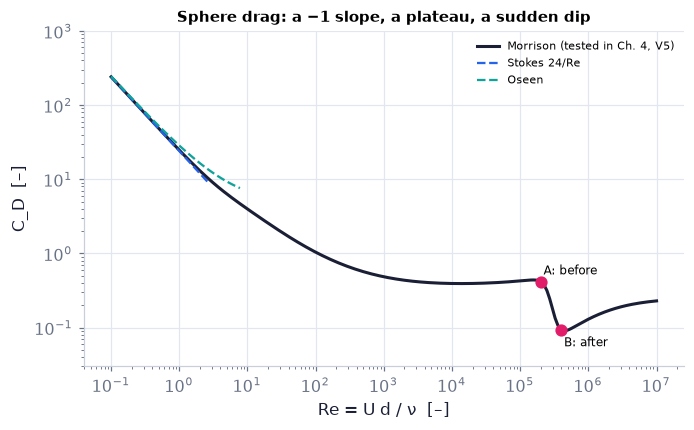

In [91]:
fig, ax = plt.subplots(figsize=(6.2, 3.8))   # the figure and its panels
ax.loglog(Rs, cd, color=COLORS["ink"], lw=2, label="Morrison (tested in Ch. 4, V5)")   # curve(s) on logarithmic axes
lo = Rs < 3; ax.loglog(Rs[lo], 24/Rs[lo], "--", color=COLORS["blue"], lw=1.5, label="Stokes 24/Re")   # curve(s) on logarithmic axes
ax.loglog(Rs[Rs < 8], 24/Rs[Rs < 8]*(1 + 3*Rs[Rs < 8]/16), "--", color=COLORS["teal"], lw=1.5, label="Oseen")   # curve(s) on logarithmic axes
for Re_, lab in ((2e5, "A: before"), (4e5, "B: after")):   # loop over the cases
    ax.plot(Re_, SIM.sphere_drag_coefficient(Re_, "morrison"), "o", color=COLORS["rose"], ms=7); ax.text(Re_*1.1, SIM.sphere_drag_coefficient(Re_, "morrison")*(1.25 if Re_ < 3e5 else 0.6), lab, fontsize=8)   # a label written on the plot
ax.set_xlabel("Re = U d / ν  [–]"); ax.set_ylabel("C_D  [–]"); ax.legend(fontsize=7, frameon=False); ax.set_ylim(0.03, 1e3); ax.set_title("Sphere drag: a −1 slope, a plateau, a sudden dip", fontsize=10)   # axis labels (with units), limits and the panel's message
plt.show()   # display the figure

**What you see.** A straight $-1$ slope on log–log axes (Stokes and Oseen dashed), a plateau near 0.4, and a sudden dip at a few $10^5$ with points A and B on either side.

**How to read it.** The dip at 3–5 × 10⁵ is the layer turning turbulent: separation moves aft and the wake narrows; before it the layer is laminar and separates early.

**What would change if…** …a rough sphere: the dip appears earlier (at a smaller Re), as for the rough cylinder.

📝 **Note.** **N84 [B]** **Cricket-ball swing.** A new ball with a smooth side and a seam-tripped side, at a speed just below the crisis: the smooth side stays laminar and separates early (about 85°), the seam side turns turbulent and separates late (about 120°): the pressure on the seam side is nearer the
ideal minimum ($C_{p,min}=-\frac54$, from $C_p=1-\frac94\sin^2\theta$ *(6.91)* at $\theta=90^\circ$) — a net side force $F$. A constant force gives a parabolic path $y=\frac12\frac Fmt^2=\frac12\frac FWg\big(\frac dU\big)^2$ over the flight time $t=d/U$.

$$ y=\frac12\frac FWg\Big(\frac dU\Big)^2 \qquad \text{(constant force, t = d/U)} $$

#### ✏️ Tiny example: a swinging ball by hand

A ball flies $d=18$ m at $U=35$ m/s, so the flight time is $t=d/U=18/35=0.514$ s. If the side force is a fifth of the weight, $F/W=0.2$, the sideways acceleration is $F/m=0.2\,g=1.96$ m/s², so
$y=\frac12(F/m)\,t^2=\frac12\times1.96\times0.514^2=0.259$ m. At 25 m/s the time is 0.72 s and the swing 0.51 m; at 40 m/s the time is 0.45 s and the swing 0.20 m. (The value $F/W=0.2$ is our illustration, not a measured number.)

In [92]:
print("deflection over d = 18 m with F/W = 0.2 at 35 m/s:", BB.ball_swing_deflection(0.2, 18.0, 35.0), "m  (flight time", 18.0/35.0, "s)")   # print the result
for U in (25, 30, 35, 40):                                         # slower balls have more time to swing
    print(U, "m/s:", round(BB.ball_swing_deflection(0.2, 18.0, U), 4), "m")   # our numbers (F/W = 0.2, d = 18 m), not the book's

deflection over d = 18 m with F/W = 0.2 at 35 m/s: 0.25946448979591835 m  (flight time 0.5142857142857142 s)
25 m/s: 0.5086 m
30 m/s: 0.3532 m
35 m/s: 0.2595 m
40 m/s: 0.1987 m


**What does the code above do?**

`ball_swing_deflection(F_over_W, d, U)` is $\frac12(F/W)\,g\,(d/U)^2$: 0.2595 m for our example at 35 m/s (flight time 0.514 s), 0.51 m at 25 m/s and 0.20 m at 40 m/s — the slower the ball, the longer the side force acts.

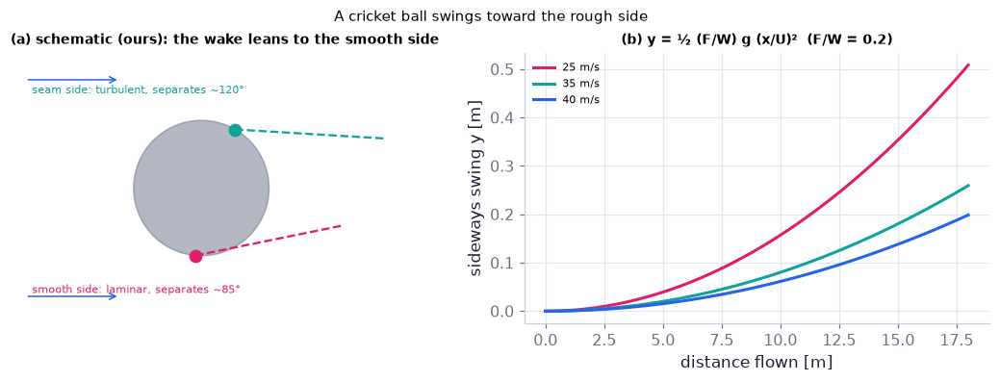

In [93]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.5, 3.5))   # the figure and its panels
th_ = np.linspace(0, 2*np.pi, 200); a1.fill(np.cos(th_), np.sin(th_), color=COLORS["muted"], alpha=0.5)   # (a) the ball seen from above, flow from the left
for s, ang, col, lab in ((+1, 120.0, COLORS["teal"], "seam side: turbulent, separates ~120°"), (-1, 85.0, COLORS["rose"], "smooth side: laminar, separates ~85°")):   # loop over the cases
    px, py = -np.cos(np.radians(ang)), s*np.sin(np.radians(ang)); a1.plot(px, py, "o", color=col, ms=8)   # draw the curve(s)
    a1.plot([px, px + 2.2], [py, py*0.5 + (0.3 if s > 0 else -0.05)], color=col, lw=1.5, ls="--"); a1.text(-2.5, 1.35*s + (0.05 if s > 0 else -0.2), lab, color=col, fontsize=7)   # a label written on the plot
for y0 in (-1.6, 1.6): a1.annotate("", xy=(-1.2, y0), xytext=(-2.6, y0), arrowprops=dict(arrowstyle="->", color=COLORS["blue"]))   # a label written on the plot
a1.set_aspect("equal"); a1.set_xlim(-2.7, 3.4); a1.set_ylim(-2.0, 2.0); a1.axis("off"); a1.set_title("(a) schematic (ours): the wake leans to the smooth side", fontsize=9)   # axis labels (with units), limits and the panel's message
xt = np.linspace(0, 18, 100)                                       # (b) the swing of the flight path for three speeds
for U, col in ((25, COLORS["rose"]), (35, COLORS["teal"]), (40, COLORS["blue"])):   # loop over the cases
    a2.plot(xt, [BB.ball_swing_deflection(0.2, x_, U) for x_ in xt], color=col, lw=2, label=f"{U} m/s")   # draw the curve(s)
a2.set_xlabel("distance flown [m]"); a2.set_ylabel("sideways swing y [m]"); a2.legend(fontsize=7, frameon=False); a2.set_title("(b) y = ½ (F/W) g (x/U)²  (F/W = 0.2)", fontsize=9)   # axis labels (with units), limits and the panel's message
fig.suptitle("A cricket ball swings toward the rough side", fontsize=10)   # the figure's message as its title
plt.show()   # display the figure

**What you see.** A ball with two separation points (85° and 120°) and a wake leaning to one side in (a); three parabolic swing curves in (b), the slowest ball swinging most.

**How to read it.** The wake is pushed toward the early-separating (smooth) side, so the ball is pushed toward the seam side; the swing grows like $(x/U)^2$.

**What would change if…** …the ball is too slow (both sides laminar) or too fast (both turbulent): there is no asymmetry, no side force, no swing.

📝 **Note.** **N85 [B]** **Spin and the sign of the Magnus force.** Ch. 6's ideal Magnus lift $L=\rho U\Gamma$ *(6.40)* pushes a backspinning ball up. With a boundary layer the sign can flip: on a smooth ball at a speed below the crisis, the side moving against the stream has the higher *relative* speed, its layer turns
turbulent first, separates later and the force reverses (**negative Magnus effect**); a rough tennis ball has a lower $\mathrm{Re}_{cr}$, both sides are past the crisis, and the faster side now separates *earlier* (**positive**).

> ⚠️ **The book's sentence has "$\mathrm{Re}<\mathrm{Re}_{cr}$" twice; the second must be "$\mathrm{Re}>\mathrm{Re}_{cr}$".** The negative case needs the slow side laminar and the fast side turbulent: $\mathrm{Re}_{slow}<\mathrm{Re}_{cr}\le\mathrm{Re}_{fast}$; with both sides past the crisis, $\mathrm{Re}_{cr}\le\mathrm{Re}_{slow}$, the sign is positive. Both sides below $\mathrm{Re}_{cr}$ (both layers laminar) is not discussed by the book and the code does not assert an answer for it.

$$ L=\rho U\Gamma \qquad \text{(6.40)} $$

In [94]:
for lo, hi in ((0.8e5, 1.2e5), (2e5, 4e5), (4e5, 6e5)):            # (Re of the slow side, Re of the fast side) around Re_cr = 3e5 (illustrative)
    print(f"Re_slow = {lo:8.2e}, Re_fast = {hi:8.2e}:  sign of the Magnus force = {BB.magnus_sign(lo, hi, 3e5)}")   # print the result

Re_slow = 8.00e+04, Re_fast = 1.20e+05:  sign of the Magnus force = none
Re_slow = 2.00e+05, Re_fast = 4.00e+05:  sign of the Magnus force = −
Re_slow = 4.00e+05, Re_fast = 6.00e+05:  sign of the Magnus force = +


**What does the code above do?**

`magnus_sign(Re_slow, Re_fast, Re_cr)` is the truth table of the corrected sentence: "−" when $\mathrm{Re}_{slow}<\mathrm{Re}_{cr}\le\mathrm{Re}_{fast}$ (only the side moving against the stream is past the crisis), "+" when both sides are past it ($\mathrm{Re}_{cr}\le\mathrm{Re}_{slow}$), and "none" when both sides are laminar (the book does not treat that case) or when there is no spin. `Re_fast` belongs to the side whose surface moves *against* the oncoming stream (the larger relative speed).

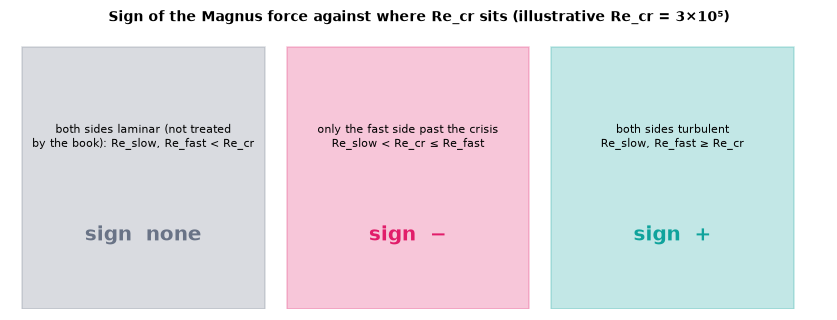

In [95]:
cases = [((0.8e5, 1.2e5), "both sides laminar (not treated\nby the book): Re_slow, Re_fast < Re_cr"), ((2e5, 4e5), "only the fast side past the crisis\nRe_slow < Re_cr ≤ Re_fast"), ((4e5, 6e5), "both sides turbulent\nRe_slow, Re_fast ≥ Re_cr")]
fig, ax = plt.subplots(figsize=(7.5, 2.8))   # the figure and its panels
for i, ((lo_, hi_), lab) in enumerate(cases):   # loop over the cases
    sg = BB.magnus_sign(lo_, hi_, 3e5); col = {"+": COLORS["teal"], "−": COLORS["rose"]}.get(sg, COLORS["muted"])   # teal '+', rose '−', grey: not asserted
    ax.add_patch(plt.Rectangle((i*2.4, 0), 2.2, 1.6, color=col, alpha=0.25)); ax.text(i*2.4 + 1.1, 1.05, lab, ha="center", va="center", fontsize=7.5)   # a label written on the plot
    ax.text(i*2.4 + 1.1, 0.45, f"sign  {sg}", ha="center", va="center", fontsize=13, weight="bold", color=col)   # a label written on the plot
ax.set_xlim(-0.1, 7.3); ax.set_ylim(0, 1.7); ax.axis("off"); ax.set_title("Sign of the Magnus force against where Re_cr sits (illustrative Re_cr = 3×10⁵)", fontsize=9)   # axis labels (with units), limits and the panel's message
plt.show()   # display the figure

**What you see.** Three tiles: a grey one ('none': both sides laminar, a case the book does not treat), a rose '−' when only the fast side is past the crisis, and a teal '+' when both are.

**How to read it.** The sign flips exactly when $\mathrm{Re}_{cr}$ lies between the two sides' Reynolds numbers; that is the corrected sentence in one picture.

**What would change if…** …$\mathrm{Re}_{cr}$ lowered by roughness: a rough tennis ball moves from the grey or the middle tile to the right one ($\mathrm{Re}_{cr}\le\mathrm{Re}_{slow}$).

*↪ **N86 [C]** Baseball: a curveball has sidespin like the tennis ball; a knuckleball, with almost no spin, tumbles so the seam's position varies and the side force is irregular. See Ch. 6 (Magnus) and Ch. 14. (The backup explainer `ball_swing_magnus` is built only if an explainer above fails review.)*

**What would change if…** …the surface has no wall at all? The same layer equations *(9.18)* $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=\nu\frac{\partial^2u}{\partial y^2}$ describe a jet, where a wall's friction is replaced by entrainment. Next section.

---

## 9.10 Two-Dimensional Jets

**What is this section about?** The layer equations *(9.18)*, $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=\nu\frac{\partial^2u}{\partial y^2}$ do not need a wall. A slot that blows fluid into still fluid makes a **free jet**: it is a boundary layer without a boundary, and *(9.18)* has an exact similarity solution, the
$\mathrm{sech}^2$ profile. Blown along a wall it makes a **wall jet**: a boundary layer under a free jet. Two conservation laws decide the shapes: in the free jet the momentum flux is constant and the mass flux grows (entrainment); in the wall jet
the ordinary momentum flux dies at the wall, but a hidden "flux of exterior momentum flux" survives. Jets and their entrainment recur in turbulent jets (Ch. 12) and plumes (Ch. 13).

### 🧩 The free two-dimensional laminar jet `C12`

*The question:* A jet keeps its momentum but spreads and slows down — how do these fit, and where does the extra mass come from?

*In one line:* $u=u_0\,\mathrm{sech}^2\Big(\frac\eta{\sqrt6}\Big)$ *(9.71)* · $\dot m=\rho\int u\,dy=(36J\rho^2\nu x)^{1/3}$ *(9.73)*

> 🔁 **Tools from earlier chapters used here** (see `knowledge/primers.md`) — used in C12 (D16)

- **exponent matching for similarity forms** — if c₁x^a F(η) + c₂x^b G(η) = 0 for every x and η then a = b: matching powers of x fixes the exponents (Ch. 8 P197).

#### The problem in plain words

Air leaves a narrow slot at 30 m/s into a quiet room. A metre downstream the stream is wider, slower — and carries more air than left the slot. The jet drags in the room's air by viscous friction (entrainment). Momentum has nothing to push on: there is no wall and, with the
pressure uniform, no net force — so the *momentum flux* stays the same all the way, while the *mass flux* grows. That single fact fixes how fast the jet slows and widens. (The profile we shall find is a bell curve called $\mathrm{sech}^2$, where $\mathrm{sech}\,x=1/\cosh x$; primer P215 below makes it precise.)

#### The idea

```
slot ══►   ──── x ────►      J = ρ∫u²dy  constant  (momentum flux, N/m)
══►     ╲   u₀(x) ∝ x^(−1/3) (slower)         ṁ = ρ∫u dy  grows ∝ x^(1/3)
══►  ───►  δ(x) ∝ x^(2/3)   (wider)           arrows in from both sides: entrainment
══►     ╱   profile: sech²(η/√6) at every x, η = y/δ(x)
```

Same layer equation as the flat plate, no wall: the conserved quantity is a momentum *flux*, not a boundary value.

📝 **Note.** **N87 [B], N88–N90 [B]** **Set-up.** A slot in the $x$-direction into still fluid; the boundary-layer approximation ($\partial/\partial y\gg\partial/\partial x$, $v\ll u$) and no external pressure gradient ($dp/dx=0$), so *(9.18)* $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=\nu\frac{\partial^2u}{\partial y^2}$ and *(6.2)*, $\frac{\partial u}{\partial x}+\frac{\partial v}{\partial y}=0$ again.
The jet is symmetric about $y=0$; wakes and shear layers obey the same equations. **Conditions:** $u=0$ for $y\to\pm\infty$, $x>0$ *(9.53)*; $v=0$ on the axis $y=0$ *(9.54)*; an inlet profile $u=\tilde u(y)$ on $x=x_0$ *(9.55)*, forgotten far downstream.

> 📎 **Primer — momentum flux and mass flux through a cross-section.** `P217` · Through a vertical line at $x$, per unit span, the *mass flux* is $\dot m=\rho\int u\,dy$ [kg/(m s)] and the *momentum flux* is $J=\rho\int u^2dy$ [N/m] (the $x$-momentum carried across). A jet in still fluid at constant pressure has no force on it, so $J$ cannot change with $x$
(control volume, Ch. 4); $\dot m$ can, because fluid enters through the sides.

In [96]:
import numpy as np   # arrays and maths
y = np.linspace(-0.05, 0.05, 2001)                 # m, across a 10 cm wide stream
u = 20*np.exp(-(y/0.01)**2)                        # a Gaussian jet, 20 m/s on the axis
rho = 1.2
print(rho*np.trapezoid(u, y), rho*np.trapezoid(u**2, y))   # mdot = 0.4254 kg/(m s), J = 6.02 N/m

0.4253889242166697 6.015907859114401


#### 🧮 Derivation — Jet momentum flux is conserved: $\frac d{dx}\int_{-\infty}^\infty u^2dy=0$, $\int u^2dy=J/\rho$ `D15` (Eq. 9.57: $\frac d{dx}\int_{-\infty}^\infty u^2dy=0$)

**What we want to show.** Show that a free jet keeps its momentum flux J constant, so we may use it to fix the exponents.

**Assumptions.** dp/dx = 0; u and ∂u/∂y → 0 as y → ±∞ (9.53), $u=0\ \text{for}\ y\to\pm\infty,\ x>0$, v bounded.

**The plan.**

1. Make the equation a flux balance.
2. Integrate over all y.
3. Show the boundary terms vanish.

**Tools we use** (each explained before this point): product rule read backwards (ch01 P38) · fundamental theorem of calculus (ch02 P84) · momentum flux (primer P217).

**We start from**

$$ \text{(9.18)}\ u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=\nu\frac{\partial^2u}{\partial y^2}\ \text{and (6.2), with dp/dx = 0} $$

*In words:* a layer with no pressure gradient and no wall.

---

**Step 1 of 7 — Multiply continuity by u.**

$$ u\frac{\partial u}{\partial x}+u\frac{\partial v}{\partial y}=0 $$

- *Why we can do this:* (6.2), $\frac{\partial u}{\partial x}+\frac{\partial v}{\partial y}=0$ equals zero, so any multiple is zero; we want a flux form.
- *In words:* a harmless zero.

---

**Step 2 of 7 — Add it to (9.18).**

$$ 2u\frac{\partial u}{\partial x}+u\frac{\partial v}{\partial y}+v\frac{\partial u}{\partial y}=\nu\frac{\partial^2u}{\partial y^2} $$

- *Why we can do this:* Sum of the two equations; the left side now contains total derivatives.
- *In words:* three advective pieces.

---

**Step 3 of 7 — Read the left side as derivatives.**

$$ \frac{\partial(u^2)}{\partial x}+\frac{\partial(uv)}{\partial y}=\frac{\partial}{\partial y}\Big(\nu\frac{\partial u}{\partial y}\Big) $$

- *Why we can do this:* Product rule backwards: 2uu_x = ∂(u²)/∂x and uv_y + vu_y = ∂(uv)/∂y. The right side is the derivative of the kinematic stress ν∂u/∂y (the book's right-hand side $\int\frac{\partial\tau}{\partial y}dy$ writes the stress τ, in Pa, next to terms in m²/s²: a unit slip — the 1/ρ is missing).
- *In words:* every term is a derivative.

---

**Step 4 of 7 — Integrate over all y.**

$$ \frac d{dx}\int_{-\infty}^\infty u^2dy+\big[uv\big]_{-\infty}^{\infty}=\Big[\nu\frac{\partial u}{\partial y}\Big]_{-\infty}^{\infty}\ \text{(9.56)} $$

- *Why we can do this:* Fundamental theorem for the y-derivatives; the limits do not depend on x, so d/dx passes through the first integral.
- *In words:* boundary terms remain.

---

**Step 5 of 7 — Check the boundary terms.**

$$ \big[uv\big]_{-\infty}^\infty=0,\qquad\Big[\nu\frac{\partial u}{\partial y}\Big]_{-\infty}^{\infty}=0 $$

- *Why we can do this:* u → 0 and ∂u/∂y → 0 far away (9.53), $u=0\ \text{for}\ y\to\pm\infty,\ x>0$ while v stays bounded.
- *In words:* nothing leaks out of the sides.

---

**Step 6 of 7 — Read the result.**

$$ \frac d{dx}\int_{-\infty}^\infty u^2\,dy=0\ \text{(9.57)} $$

- *Why we can do this:* Step 4 left $\frac d{dx}\int u^2dy$ plus two boundary terms, and step 5 showed both boundary terms vanish, so the derivative alone equals zero.
- *In words:* the momentum flux is the same at every x.

---

**Step 7 of 7 — Name the constant.**

$$ \int_{-\infty}^\infty u^2dy=\int\tilde u^2dy=\frac J\rho\ \text{(9.58)} $$

- *Why we can do this:* Evaluate at the inlet profile ũ (9.55), $u=\tilde u(y)\ \text{on}\ x=x_0$; J is the momentum flux per unit span, in N/m.
- *In words:* J is set by the slot.

---

**Result**

$$ \rho\int u^2dy=J\ \text{at every x} $$

*In words:* the jet keeps its momentum.

**What it means.** With the conserved J the similarity exponents follow (D16); the mass flux ρ∫u dy is *not* conserved: the jet entrains fluid.

**Check it.** Units: ρ∫u²dy = kg/m³ · m²/s² · m = N/m ✓. The notebook integrates u = u₀sech² at four stations: J = 1.0000 N/m each.

> ⚠️ **Common confusion (traps in `D15`):** The printed right-hand side $\int\frac{\partial\tau}{\partial y}dy$ of (9.56), $\int_{-\infty}^\infty2u\frac{\partial u}{\partial x}dy+\int_{-\infty}^\infty\Big[u\frac{\partial v}{\partial y}+v\frac{\partial u}{\partial y}\Big]dy=\int_{-\infty}^\infty\frac{\partial}{\partial y}\Big(\nu\frac{\partial u}{\partial y}\Big)dy$ writes τ without 1/ρ; the boundary terms are dropped because u and u_y decay, not because they are zero at the wall (no wall here).

📝 **Note.** **N91–N93 [B]** **The stations of D15.** The integrated equation is $\int_{-\infty}^\infty2u\frac{\partial u}{\partial x}dy+\int_{-\infty}^\infty\big[u\frac{\partial v}{\partial y}+v\frac{\partial u}{\partial y}\big]dy=\int_{-\infty}^\infty\frac{\partial}{\partial y}\big(\nu\frac{\partial u}{\partial y}\big)dy$ *(9.56)* (in the
kinematic-stress form); its result is $\frac d{dx}\int_{-\infty}^\infty u^2dy=0$ *(9.57)*, i.e. $\int_{-\infty}^\infty u^2dy=\text{const}=J/\rho$ *(9.58)*.

> ⚠️ **The book prints the right-hand side of (9.56) with $\partial\tau/\partial y$ and no $1/\rho$.** A stress $\tau$ is in Pa, the left-hand terms are in m²/s², so the units do not match:
> $$\text{printed:}\ \int\frac{\partial\tau}{\partial y}dy\qquad\text{correct:}\ \int\frac{\partial}{\partial y}\Big(\nu\frac{\partial u}{\partial y}\Big)dy=\int\frac1\rho\frac{\partial\tau}{\partial y}dy$$

📝 **Note.** **N94–N96 [B]** **Similarity from the invariant.** Look for $\psi=u_0(x)\delta(x)f(\eta)$, $\eta=y/\delta(x)$, $\delta=[\nu x/u_0(x)]^{1/2}$ *(9.59)* — the ansatz of C03 with the outer speed replaced by the unknown centre-line speed $u_0$; then $u=\partial\psi/\partial y=u_0f'(\eta)$ *(9.60)* and
$\frac J\rho=u_0^2\delta\int f'^2d\eta$ *(9.61)*. The number $C\equiv\int f'^2d\eta$ is a constant: the $x$-dependence of $J/\rho$ must cancel, which fixes $u_0$ and $\delta$ (next).

📝 **Note.** **N97–N99 [B]** **Exponents.** $u_0(x)=\big[J^2/(C^2\rho^2\nu x)\big]^{1/3}\propto x^{-1/3}$ *(9.62)*, $\delta(x)=\big[C\rho\nu^2x^2/J\big]^{1/3}\propto x^{2/3}$ *(9.63)*, $\psi=\big[J\nu x/C\rho\big]^{1/3}f(\eta)$, $\eta=y\big/[C\rho\nu^2x^2/J]^{1/3}$ *(9.64)*.
With $J=1$ N/m in air at $x=0.1$ m: $u_0=35.1$ m/s, $\delta=0.207$ mm; at $x=0.4$ m: 22.1 m/s and 0.521 mm ($\times4^{-1/3}=0.63$ and $\times4^{2/3}=2.52$).

#### 🧮 Derivation — Free-jet similarity: exponents from constant J, then $3f'''+ff''+f'^2=0$ with $f'\to0$, $f'(0)=1$, $f(0)=0$ `D16` (Eq. 9.65: $\frac{\partial\psi}{\partial y}\frac\partial{\partial x}\Big(\frac{\partial\psi}{\partial y}\Big)-\frac{\partial\psi}{\partial x}\frac\partial{\partial y}\Big(\frac{\partial\psi}{\partial y}\Big)=\nu\frac{\partial^2}{\partial y^2}\Big(\frac{\partial\psi}{\partial y}\Big)$)

**What we want to show.** Show that the free jet is similar, find how fast it slows and widens, and reduce (9.65), $\frac{\partial\psi}{\partial y}\frac\partial{\partial x}\Big(\frac{\partial\psi}{\partial y}\Big)-\frac{\partial\psi}{\partial x}\frac\partial{\partial y}\Big(\frac{\partial\psi}{\partial y}\Big)=\nu\frac{\partial^2}{\partial y^2}\Big(\frac{\partial\psi}{\partial y}\Big)$ to an ODE (the book skips the differentiation).

**Assumptions.** dp/dx = 0; similarity (no imposed length); J constant (D15).

**The plan.**

1. Use the conserved J to fix u₀(x) and δ(x).
2. Differentiate ψ four ways.
3. Watch every power of x cancel.
4. Read the ODE.

**Tools we use** (each explained before this point): chain rule with x^(−2/3) inside η (primer P206) · exponent rules (ch01 P43) · momentum flux (primer P217) · sympy (ch01 P40).

**We start from**

$$ \frac{\partial\psi}{\partial y}\frac\partial{\partial x}\Big(\frac{\partial\psi}{\partial y}\Big)-\frac{\partial\psi}{\partial x}\frac\partial{\partial y}\Big(\frac{\partial\psi}{\partial y}\Big)=\nu\frac{\partial^2}{\partial y^2}\Big(\frac{\partial\psi}{\partial y}\Big)\ \text{(9.65)},\qquad \rho\int u^2dy=J\ \text{(9.58)} $$

*In words:* (9.18), $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=\nu\frac{\partial^2u}{\partial y^2}$ with u = ψ_y and v = −ψ_x, and the conserved momentum flux of D15

---

**Step 1 of 14 — State the ansatz.**

$$ \psi=u_0(x)\,\delta(x)\,f(\eta),\quad\eta=\frac y\delta,\quad\delta=\Big[\frac{\nu x}{u_0}\Big]^{1/2}\ \text{(9.59)} $$

- *Why we can do this:* Blasius' (9.19), $\psi=U\delta(x)f(\eta),\quad\eta=\frac y{\delta(x)}$ with the outer speed replaced by the unknown centre-line speed u₀(x); no length except x.
- *In words:* one shape, stretched and rescaled.

---

**Step 2 of 14 — Compute u.**

$$ u=\frac{\partial\psi}{\partial y}=u_0\,f'(\eta)\ \text{(9.60)} $$

- *Why we can do this:* Chain rule; the δ cancels. With f′(0) = 1 (9.67), $f'=1\ \text{on}\ \eta=0$, u₀ is the centre-line speed.
- *In words:* u/u₀ = f′(η).

---

**Step 3 of 14 — Write the momentum flux.**

$$ \frac J\rho=\int u^2dy=u_0^2\,\delta\int f'^2d\eta\equiv u_0^2\,\delta\,C\ \text{(9.61)} $$

- *Why we can do this:* Change variable y = δη (dy = δ dη at fixed x); C = ∫f′²dη is a pure number.
- *In words:* J/ρ = u₀²δC.

---

**Step 4 of 14 — Solve for u₀.**

$$ u_0^{3/2}\sqrt{\nu x}\,C=\frac J\rho\ \Rightarrow\ u_0=\Big[\frac{J^2}{C^2\rho^2\nu x}\Big]^{1/3}\ \text{(9.62)} $$

- *Why we can do this:* δ = (νx/u₀)^(1/2) makes u₀²δ = u₀^(3/2)(νx)^(1/2); J is constant (D15), so u₀^(3/2) ∝ x^(−1/2).
- *In words:* u₀ ∝ x^(−1/3).

---

**Step 5 of 14 — Solve for δ.**

$$ \delta=\Big[\frac{\nu x}{u_0}\Big]^{1/2}=\Big[\frac{C\rho\nu^2x^2}{J}\Big]^{1/3}\ \text{(9.63)} $$

- *Why we can do this:* Insert step 4: (νx)^(1/2)(νx)^(1/6)(C²ρ²/J²)^(1/6) = (νx)^(2/3)(Cρ/J)^(1/3).
- *In words:* δ ∝ x^(2/3).

---

**Step 6 of 14 — Write ψ in pure powers of x.**

$$ \psi=A\,x^{1/3}f(\eta),\ \ \eta=\frac y{Bx^{2/3}},\ \ AB=\nu\ \text{(9.64)} $$

- *Why we can do this:* u₀δ = (Jνx/Cρ)^(1/3), so A = (Jν/Cρ)^(1/3) and B = (Cρν²/J)^(1/3); their product is ν exactly.
- *In words:* now only x-powers remain.

---

**Step 7 of 14 — Differentiate η.**

$$ \eta_x=-\frac{2\eta}{3x},\qquad\eta_y=\frac1{Bx^{2/3}} $$

- *Why we can do this:* Power rule on η = y B⁻¹x^(−2/3).
- *In words:* η moves as x^(−2/3).

---

**Step 8 of 14 — Compute u and v.**

$$ u=\frac AB\,x^{-1/3}f',\qquad v=-\frac A3\,x^{-2/3}\big(f-2\eta f'\big)\ \text{(9.74)} $$

- *Why we can do this:* u by the chain rule (A x^(1/3)·1/(Bx^(2/3))); v = −ψ_x by the product rule, A[⅓x^(−2/3)f + x^(1/3)f′η_x], with step 7.
- *In words:* the second is the entrainment flow.

---

**Step 9 of 14 — Differentiate u in x.**

$$ u_x=\frac AB\,x^{-4/3}\Big[-\frac{f'}3-\frac{2\eta f''}3\Big] $$

- *Why we can do this:* Product rule on x^(−1/3)f′(η) with η_x from step 7.
- *In words:* both the prefactor and η change.

---

**Step 10 of 14 — Differentiate u in y.**

$$ u_y=\frac A{B^2}\,x^{-1}f'',\qquad u_{yy}=\frac A{B^3}\,x^{-5/3}f''' $$

- *Why we can do this:* Chain rule with η_y (each y-derivative brings 1/(Bx^(2/3))).
- *In words:* the viscous term.

---

**Step 11 of 14 — Form the advective terms.**

$$ uu_x=\frac{A^2}{B^2}x^{-5/3}f'\Big[-\frac{f'}3-\frac{2\eta f''}3\Big],\ \ vu_y=-\frac{A^2}{3B^2}x^{-5/3}\big[ff''-2\eta f'f''\big] $$

- *Why we can do this:* Multiply steps 8–10; both come out ∝ x^(−5/3).
- *In words:* the same power of x in both.

---

**Step 12 of 14 — Add them.**

$$ uu_x+vu_y=-\frac{A^2}{3B^2}\,x^{-5/3}\big[f'^2+ff''\big] $$

- *Why we can do this:* The ηf′f″ terms have coefficients −⅔ and +⅔ and cancel — as in Blasius and Falkner–Skan.
- *In words:* only f′² and f f″ survive.

---

**Step 13 of 14 — Insert into (9.65) and equate.**

$$ -\frac{A^2}{3B^2}\big[f'^2+ff''\big]=\frac{\nu A}{B^3}f''' $$

- *Why we can do this:* The right side is νu_yy (step 10). Every term carries x^(−5/3): it cancels, which is the proof that the exponents of steps 4–5 are right.
- *In words:* an ODE with constant coefficients.

---

**Step 14 of 14 — Simplify with AB = ν.**

$$ 3f'''+ff''+f'^2=0 $$

- *Why we can do this:* Multiply by −3B³/A: 3νf‴ + AB(f′² + ff″) = 0 and AB = ν (step 6). Conditions: f′ → 0 as η → ±∞ (9.66), $f'\to0\ \text{as}\ \eta\to\pm\infty$, f′(0) = 1 (9.67), $f'=1\ \text{on}\ \eta=0$, f(0) = 0 (9.68), $f=0\ \text{on}\ \eta=0$.
- *In words:* C dropped out: it is fixed by the solution (D17).

---

**Result**

$$ u_0\propto x^{-1/3}\ \text{,}\ \delta\propto x^{2/3}\ \text{and}\ 3f'''+ff''+f'^2=0 $$

*In words:* one conservation law forces the exponents; the ODE has integer coefficients.

**What it means.** Any conserved integral of the form ∫u² dy forces exponents through dimensional bookkeeping; the ODE then determines the profile (D17).

**Check it.** Units: J/ρ is m³/s², so A = (Jν/Cρ)^(1/3) is m^(5/3)/s and ψ = A x^(1/3) f is m²/s ✓. `ch09.similarity_reduce_sympy("free_jet")` returns a zero residual and the ODE with coefficients 3, 1, 1. Air, J = 1 N/m: u₀(0.1) = 35.14 m/s, u₀(0.4) = 22.14 m/s (ratio 4^(−1/3) = 0.63) ✓.

In [97]:
import sympy as sp                                              # symbolic algebra
x, y, J, rho, nu, C = sp.symbols('x y J rho nu C', positive=True)   # positive symbols: x, y, momentum flux, density, viscosity, the constant C
f = sp.Function('f')                                             # the unknown similarity function of eta
A = (J*nu/(C*rho))**sp.Rational(1, 3)                            # step 6: psi = A x^(1/3) f(eta)
B = (C*rho*nu**2/J)**sp.Rational(1, 3)                           # step 6: eta = y/(B x^(2/3)); note A*B = nu
eta = y/(B*x**sp.Rational(2, 3))                                 # the similarity variable (9.64)
psi = A*x**sp.Rational(1, 3)*f(eta)                              # the stream function (9.64)
u, v = sp.diff(psi, y), -sp.diff(psi, x)                         # u = psi_y, v = -psi_x (steps 2 and 8)
res = u*sp.diff(u, x) + v*sp.diff(u, y) - nu*sp.diff(u, y, 2)    # residual of (9.18) with this ansatz (steps 9-13)
E = sp.Symbol('E', positive=True)                                # a symbol standing for eta after the derivatives are taken
expr = (res*3*B**2*x**sp.Rational(5, 3)/A**2).subs(y, E*B*x**sp.Rational(2, 3)).doit()   # divide by the common factor A^2/(3 B^2 x^(5/3)); write y through eta = E
print(sp.simplify(expr))                                         # minus (f f'' + f'^2 + 3 f'''): every power of x has cancelled (step 13); A*B = nu did the rest
odeE = 3*f(E).diff(E, 3) + f(E)*f(E).diff(E, 2) + f(E).diff(E)**2   # the reduced ODE of step 14
print(sp.simplify(expr + odeE))                                  # 0: the residual of (9.18) is exactly minus the ODE 3f''' + f f'' + f'^2 = 0

-f(E)*Derivative(f(E), (E, 2)) - Derivative(f(E), E)**2 - 3*Derivative(f(E), (E, 3))
0


> ⚠️ **Common confusion (traps in `D16`):** ψ has four derivatives to compute (ψ_x, ψ_y, ψ_xy, ψ_yy — here folded into steps 7–11); C is not a free constant of the ODE; AB = ν is what makes the coefficient 3 come out an integer.

📝 **Note.** **N100–N104 [B]** **The stations of D16.** The equation to reduce is *(9.18)*, $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=\nu\frac{\partial^2u}{\partial y^2}$ written in the stream function, $\frac{\partial\psi}{\partial y}\frac\partial{\partial x}\big(\frac{\partial\psi}{\partial y}\big)-\frac{\partial\psi}{\partial x}\frac\partial{\partial y}\big(\frac{\partial\psi}{\partial y}\big)=\nu\frac{\partial^2}{\partial y^2}\big(\frac{\partial\psi}{\partial y}\big)$ *(9.65)*;
the book skips the differentiation, and we obtain (by hand in D16, checked with sympy) $3f'''+ff''+f'^2=0$; its conditions are $f'\to0$ as $\eta\to\pm\infty$ *(9.66)*, $f'=1$ on $\eta=0$ *(9.67)* and $f=0$ on $\eta=0$ *(9.68)*.

> 📎 **Primer — sech, arccosh and (tanh)′ = sech².** `P215` · $\mathrm{sech}\,x=1/\cosh x$, a bell-shaped curve equal to 1 at 0 that dies like $2e^{-|x|}$; $d(\tanh x)/dx=\mathrm{sech}^2x=1-\tanh^2x$. Its inverse: $\mathrm{arccosh}\,y=\ln(y+\sqrt{y^2-1})$ for $y\ge1$ answers "where does sech reach 0.1?".
(Extends the tanh primer of Ch. 7.)

In [98]:
import numpy as np   # arrays and maths
print(1/np.cosh(0.0), 1/np.cosh(2.0)**2)         # 1.0 and 0.0707: sech^2 at x = 0 and 2
print(np.arccosh(10.0), np.log(10 + np.sqrt(99)))   # 2.9932 twice: the point where sech = 0.1

1.0 0.07065082485316447
2.993222846126381 2.993222846126381


> 📎 **Primer — the total-derivative move (look for the derivative of a product).** `P216` · Before integrating an ODE, ask whether the left side is already the derivative of something: $(ff')'=f'^2+ff''$ and $(3f'+f^2/2)'=3f''+ff'$ (the product rule read backwards, Ch. 1 P38). Then integrating is free: the ODE becomes "that something = constant".

In [99]:
import sympy as sp   # symbolic algebra
x = sp.symbols('x')   # symbols for sympy
f = sp.Function('f')   # symbols for sympy
print(sp.expand(sp.diff(f(x)*f(x).diff(x), x)))           # f'^2 + f f''
print(sp.expand(sp.diff(3*f(x).diff(x) + f(x)**2/2, x)))  # 3 f'' + f f'

f(x)*Derivative(f(x), (x, 2)) + Derivative(f(x), x)**2


f(x)*Derivative(f(x), x) + 3*Derivative(f(x), (x, 2))


#### 🧮 Derivation — Free-jet solution: $f=\sqrt6\tanh(\eta/\sqrt6)$, $u=u_0\,\mathrm{sech}^2(\eta/\sqrt6)$, $C=\frac{4\sqrt6}3$, $\dot m=(36J\rho^2\nu x)^{1/3}$, entrainment `D17` (Eq. 9.71: $u=u_0\,\mathrm{sech}^2\Big(\frac\eta{\sqrt6}\Big)$)

**What we want to show.** Solve the jet ODE in closed form and read off the profile, the constant C, the mass flux and the entrainment flow.

**Assumptions.** Symmetric jet; f bounded at infinity.

**The plan.**

1. Spot exact derivatives and integrate twice.
2. Solve the first-order equation.
3. Compute C and the fluxes.

**Tools we use** (each explained before this point): the total-derivative move (primer P216) · sech, arccosh and (tanh)′ = sech² (primer P215) · separation of variables (ch01 P42) · sympy (ch01 P40).

**We start from**

$$ 3f'''+ff''+f'^2=0\ \text{,}\ f(0)=0\ \text{,}\ f'(0)=1\ \text{,}\ f'\to0\ \text{as η → ±∞ (D16)} $$

*In words:* a third-order ODE that can be integrated twice.

---

**Step 1 of 11 — Restate the ODE and conditions.**

$$ 3f'''+ff''+f'^2=0,\ \ f(0)=0,\ f'(0)=1,\ f'(\pm\infty)=0 $$

- *Why we can do this:* This is the result of D16 together with the conditions (9.66)–(9.68), $f'\to0\ \text{as}\ \eta\to\pm\infty,\ f'=1\ \text{on}\ \eta=0,\ f=0\ \text{on}\ \eta=0$; we restate it so that every integration below starts from a line on the page.
- *In words:* what we integrate.

---

**Step 2 of 11 — Spot a total derivative.**

$$ 3f'''+\big(ff'\big)'=0 $$

- *Why we can do this:* Product rule backwards (P216): (ff′)′ = f′² + ff″.
- *In words:* two pieces are one derivative.

---

**Step 3 of 11 — Integrate once.**

$$ 3f''+ff'=C_1=0 $$

- *Why we can do this:* Integrate a derivative equal to zero; far away f″, f′ → 0 with f bounded, so C₁ = 0.
- *In words:* a second-order equation.

---

**Step 4 of 11 — Spot another derivative.**

$$ 3f''+ff'=\Big(3f'+\frac{f^2}2\Big)' $$

- *Why we can do this:* d(f²/2)/dη = ff′ and d(3f′)/dη = 3f″.
- *In words:* again a total derivative.

---

**Step 5 of 11 — Integrate again.**

$$ 3f'+\frac{f^2}2=3\ \text{(9.69)} $$

- *Why we can do this:* The constant follows from η = 0: f′(0) = 1 and f(0) = 0 give C₂ = 3.
- *In words:* a first-order equation.

---

**Step 6 of 11 — Find f at infinity.**

$$ f'\to0\ \Rightarrow\ f_\infty^2=6,\ \ f_\infty=\sqrt6 $$

- *Why we can do this:* Put f′ = 0 in step 5 far from the axis.
- *In words:* the stream function saturates at √6.

---

**Step 7 of 11 — Separate variables.**

$$ f=\sqrt6\,t\ \Rightarrow\ \frac{dt}{1-t^2}=\frac{d\eta}{\sqrt6} $$

- *Why we can do this:* Step 5 gives f′ = 1 − f²/6 = 1 − t²; with f′ = √6 t′ the variables separate (P42).
- *In words:* an integrable equation.

---

**Step 8 of 11 — Integrate and apply f(0) = 0.**

$$ \tanh^{-1}t=\frac\eta{\sqrt6}\ \Rightarrow\ f=\sqrt6\tanh\frac\eta{\sqrt6},\ \ f'=\mathrm{sech}^2\frac\eta{\sqrt6}\ \text{(9.70), (9.71)} $$

- *Why we can do this:* ∫dt/(1 − t²) = artanh t; t(0) = 0 fixes the constant to 0; (tanh)′ = sech² (P215).
- *In words:* the jet profile u = u₀sech²(η/√6).

---

**Step 9 of 11 — Compute the constant C.**

$$ C=\int f'^2d\eta=\sqrt6\int_{-\infty}^\infty\mathrm{sech}^4s\,ds=\sqrt6\cdot\frac43=\frac{4\sqrt6}3\ \text{(9.72)} $$

- *Why we can do this:* Substitute s = η/√6; ∫sech⁴s ds = ∫(1 − t²)dt over t = tanh s ∈ (−1, 1) = 4/3.
- *In words:* C = 3.266.

---

**Step 10 of 11 — Compute the mass flux.**

$$ \dot m=\rho\int u\,dy=\rho u_0\delta\,[f]_{-\infty}^{\infty}=2\sqrt6\,\rho u_0\delta=(36J\rho^2\nu x)^{1/3}\ \text{(9.73)} $$

- *Why we can do this:* ∫f′dη = f(∞) − f(−∞) = 2√6; u₀δ = (Jνx/Cρ)^(1/3) (D16) so ṁ³ = (2√6)³ρ³Jνx/(Cρ) = 36 Jρ²νx since (2√6)³/C = 117.6/3.266 = 36.
- *In words:* ṁ ∝ x^(1/3): entrainment.

---

**Step 11 of 11 — Compute the cross-flow.**

$$ \frac v{u_0}=-\frac{f-2\eta f'}{3\sqrt{Re_x}}\ \to\ \mp\frac{\sqrt6}{3\sqrt{Re_x}}\quad(\eta\to\pm\infty)\ \text{(9.74), (9.75)} $$

- *Why we can do this:* v from D16 step 8 divided by u₀, with δ/x = 1/√Re_x (Re_x = xu₀/ν); as η → ±∞, f → ±√6 and ηf′ → 0.
- *In words:* ambient fluid flows toward the jet from both sides.

---

**Result**

$$ u=u_0\,\mathrm{sech}^2(\eta/\sqrt6)\ \text{,}\ C=\frac{4\sqrt6}3\ \text{,}\ \dot m=(36J\rho^2\nu x)^{1/3}\ \text{,}\ v/u_0\to\mp\sqrt6/(3\sqrt{Re_x}) $$

*In words:* Bickley's jet, growing by entrainment.

**What it means.** Momentum flux is conserved, mass flux is not; the same two facts hold for round and turbulent jets (Ch. 12).

**Check it.** Bickley's coefficients: u₀ = 0.4543(J²/ρ²νx)^(1/3) (= (1/C²)^(1/3)), η-scaling 0.2752, ṁ coefficient 36^(1/3) = 3.3019 ✓. sympy: f = √6 tanh(η/√6) solves 3f‴ + ff″ + f′² = 0 identically; `solve_bvp` matches to 1e-8. Air J = 1, x = 0.1 m: ṁ = 0.04268 kg/(m s).

> ⚠️ **Common confusion (traps in `D17`):** C₁ = 0 needs f″, f′ → 0 with f bounded; ∫sech⁴ = 4/3 (not 2); √6 appears from f(∞).

📝 **Note.** **N105–N111 [B]** **The result in one box.** First integrals: $3f''+ff'=0$ and $3f'+\frac{f^2}2=3$ *(9.69)*; $\tanh^{-1}\frac f{\sqrt6}=\frac\eta{\sqrt6}$ *(9.70)*; hence $u(x,y)=u_0(x)\,\mathrm{sech}^2\big(\frac y{\sqrt6}\big[\frac J{C\rho\nu^2x^2}\big]^{1/3}\big)$ *(9.71)* (Bickley's jet, 1937);
$C=\frac{4\sqrt6}3$ *(9.72)*; the mass flux $\dot m=\rho u_0\delta\,2\sqrt6=(36J\rho^2\nu x)^{1/3}$ *(9.73)*, growing like $x^{1/3}$: entrainment; the cross-flow $v=-\frac13\big(\frac{J\nu}{C\rho x^2}\big)^{1/3}[f-2\eta f']$ *(9.74)*
and $\frac v{u_0}\to\mp\frac{\sqrt6}{3\sqrt{\mathrm{Re}_x}}$ as $\eta\to\pm\infty$ *(9.75)*: ambient fluid flows toward the jet from both sides, with $\mathrm{Re}_x=xu_0/\nu$.

#### 🧮 Derivation — The jet half-width $h_{99}=7.3319\big[\frac{C\rho\nu^2x^2}J\big]^{1/3}$ (9.76 corrected) `D18` (Eq. 9.76: $h_{99}=7.3319\Big[\frac{C\rho\nu^2x^2}J\Big]^{1/3}$)

**What we want to show.** Find where the jet speed has fallen to 1 % of the centre-line value, and correct the book's number.

**Assumptions.** The half-width is defined at the 1 % level (any level works the same way).

**The plan.**

1. Set sech² equal to 0.01.
2. Invert with arccosh.
3. Multiply by √6 δ.

**Tools we use** (each explained before this point): sech, arccosh and (tanh)′ = sech² (primer P215).

**We start from**

$$ u=u_0\,\mathrm{sech}^2(\eta/\sqrt6)\ \text{(9.71) and δ from (9.63)} $$

*In words:* the profile decays like a bell.

---

**Step 1 of 5 — Impose the level.**

$$ \mathrm{sech}^2\Big(\frac{h_{99}}{\sqrt6\,\delta}\Big)=0.01 $$

- *Why we can do this:* Definition of h₉₉ (u = 1 % of u₀), analogous to δ₉₉.
- *In words:* where the speed is 1 % of the peak.

---

**Step 2 of 5 — Take the square root.**

$$ \mathrm{sech}\,z=0.1\ \Rightarrow\ \cosh z=10,\quad z=\frac{h_{99}}{\sqrt6\,\delta} $$

- *Why we can do this:* sech² = 0.01 gives sech = 0.1 (positive branch), and cosh = 1/sech.
- *In words:* cosh z = 10.

---

**Step 3 of 5 — Invert.**

$$ z=\cosh^{-1}10=\ln\big(10+\sqrt{99}\big)=2.9932 $$

- *Why we can do this:* arccosh y = ln(y + √(y² − 1)) for y ≥ 1 (P215).
- *In words:* z = 2.993.

---

**Step 4 of 5 — Restore units.**

$$ h_{99}=\sqrt6\,z\,\delta=7.3319\Big[\frac{C\rho\nu^2x^2}J\Big]^{1/3} $$

- *Why we can do this:* Multiply by √6δ with δ from (9.63), $\delta(x)=\Big[\frac{C\rho\nu^2x^2}J\Big]^{1/3}$: √6 × 2.9932 = 7.3319.
- *In words:* width ∝ x^(2/3).

---

**Step 5 of 5 — Explain the printed value.**

$$ \cosh^{-1}5=2.2924,\ \ \sqrt6\times2.2924=5.6152 $$

- *Why we can do this:* The book's $h_{99}=5.6152[\dots]^{1/3}$ uses $z=2.2924$, which satisfies $\mathrm{sech}^2z=1/25=0.04$: it is the 4 % point, not the 1 % point.
- *In words:* 5.6152 belongs to 4 %.

---

**Result**

$$ h_{99}=7.3319\,\delta\ \text{; the book's 5.6152 δ is}\ h_{04} $$

*In words:* corrected half-width; Re_h99 inherits the correction.

**What it means.** Level matters: state it (1 %, 4 %, 50 %): the coefficient is √6 arccosh(1/√level) (0.5 → 2.159).

**Check it.** 1/cosh²(2.2924) = 0.0400 ✓; 1/cosh²(2.9932) = 0.0100 ✓. Air, J = 1, x = 0.1 m: h₉₉ = 7.3319 × 0.2066 mm = 1.515 mm (printed would give 1.160 mm, 23 % too small).

> ⚠️ **Common confusion (traps in `D18`):** sech vs sech²; mixing the 1 % and 4 % levels.

📝 **Note.** **N112 [B], N113 [B]** > ⚠️ **The book prints $h_{99}=5.6152[C\rho\nu^2x^2/J]^{1/3}$ from $\mathrm{sech}^2=0.01\to2.2924$.** The 1 % point is $\mathrm{arccosh}\,10=2.9932$:
> $$\text{printed:}\ h_{99}=5.6152\Big[\frac{C\rho\nu^2x^2}J\Big]^{1/3}\qquad\text{correct:}\ h_{99}=7.3319\Big[\frac{C\rho\nu^2x^2}J\Big]^{1/3}$$
> $2.2924=\mathrm{arccosh}\,5$ is the 4 % point.

**Reynolds numbers and cross-references.** $\mathrm{Re}_x=\big(\frac{3Jx}{4\sqrt6\rho\nu^2}\big)^{2/3}$ and $\mathrm{Re}_{h_{99}}=h_{99}u_0/\nu$ (with the corrected coefficient 7.3319); a laminar jet at $\mathrm{Re}\gg1$ is unstable (the $\mathrm{sech}^2$ profile has inflection points: Ch. 11);
the turbulent jet spreads like $x$, faster than the laminar $x^{2/3}$. **The book's cross-reference to "Chapter 13" for turbulent jets is a slip: it is Chapter 12** (turbulence).

#### ✏️ Tiny example: a slot jet in air and in water

$J=1$ N/m. Air ($\rho=1.2$, $\nu=1.5\times10^{-5}$), $x=0.1$ m: $u_0=35.14$ m/s, $\delta=0.2066$ mm, $\dot m=0.04268$ kg/(m s), $h_{99}=7.3319\,\delta=1.515$ mm, $\mathrm{Re}_x=2.34\times10^5$, edge cross-flow $v=-0.0593$ m/s (toward the jet).
Water ($\rho=1000$, $\nu=10^{-6}$): $u_0=0.979$ m/s, $\delta=0.320$ mm, $\dot m=1.533$ kg/(m s), $h_{99}=2.344$ mm. Four times further downstream in air: $u_0$ down to 63 %, width up 2.52×, $\dot m$ up 1.59×, but $J$ still 1 N/m.

In [100]:
k = JET.free_jet_constants()                                      # the constants of D16-D18, computed (not typed)
print({n: round(float(k[n]), 5) for n in ("C", "mdot_coeff", "h99_arg", "h99_coeff", "h99_printed", "u0_coeff", "xi_coeff", "f_inf")})   # print the result
xj = np.array([0.05, 0.1, 0.2, 0.4])                              # stations [m]
print("   x[m]   u0[m/s]   delta[mm]   mdot[kg/(m s)]   h99[mm]")   # print the result
for xi in xj:                                                     # J = 1 N/m in air
    print(f"{xi:6.2f} {JET.free_jet_centreline(xi, 1.0, RHO_AIR, NU_AIR):9.3f} {1e3*JET.free_jet_thickness(xi, 1.0, RHO_AIR, NU_AIR):11.4f} "   # print the result
          f"{JET.free_jet_mass_flux(xi, 1.0, RHO_AIR, NU_AIR):16.5f} {1e3*JET.free_jet_halfwidth(xi, 1.0, RHO_AIR, NU_AIR):9.4f}")   # (9.62), (9.63), (9.73), (9.76 corrected)
print("printed h99 at x = 0.1 m:", 1e3*JET.free_jet_halfwidth(0.1, 1.0, RHO_AIR, NU_AIR, printed=True), "mm  vs corrected", 1e3*JET.free_jet_halfwidth(0.1, 1.0, RHO_AIR, NU_AIR), "mm")   # print the result
print(JET.free_jet_reynolds(0.1, 1.0, RHO_AIR, NU_AIR), " edge cross-flow v =", JET.free_jet_entrainment_velocity(JET.free_jet_reynolds(0.1, 1.0, RHO_AIR, NU_AIR)["Re_x"])*JET.free_jet_centreline(0.1, 1.0, RHO_AIR, NU_AIR), "m/s")   # print the result

{'C': 3.26599, 'mdot_coeff': 3.30193, 'h99_arg': 2.99322, 'h99_coeff': 7.33187, 'h99_printed': 5.61529, 'u0_coeff': 0.45428, 'xi_coeff': 0.27516, 'f_inf': 2.44949}
   x[m]   u0[m/s]   delta[mm]   mdot[kg/(m s)]   h99[mm]
  0.05    44.277      0.1301          0.03388    0.9542
  0.10    35.143      0.2066          0.04268    1.5147
  0.20    27.893      0.3280          0.05378    2.4045
  0.40    22.139      0.5206          0.06775    3.8169
printed h99 at x = 0.1 m: 1.1600889000223764 mm  vs corrected 1.514749153770277 mm
{'Re_x': 234286.851472708, 'Re_h99': 3548.8581000778695, 'Re_h99_printed': 2717.935758146796}  edge cross-flow v = -0.05928155507483438 m/s


**What does the code above do?**

1. `free_jet_constants` computes $C=\int f'^2d\eta$ by quadrature and confirms $4\sqrt6/3=3.26599$; also $36^{1/3}=3.3019$, $\mathrm{arccosh}\,10=2.99322$, $h_{99}$ coefficient $\sqrt6\,\mathrm{arccosh}10=7.33187$ (the printed 5.61529 is the 4 % point), $u_0$ coefficient 0.45428.
2. The four functions are *(9.62)*, $u_0(x)=\Big[\frac{J^2}{C^2\rho^2\nu x}\Big]^{1/3}$, *(9.63)*, $\delta(x)=\Big[\frac{C\rho\nu^2x^2}J\Big]^{1/3}$, *(9.73)*, $\dot m=\rho\int u\,dy=(36J\rho^2\nu x)^{1/3}$ and *(9.76)*, $h_{99}=7.3319\Big[\frac{C\rho\nu^2x^2}J\Big]^{1/3}$ (corrected) evaluated at four stations: $u_0$ falls, $\delta$ and $\dot m$ grow.
3. `printed=True` reproduces the slip: $h_{99}=1.160$ mm instead of 1.515 mm (23 % too small); the edge cross-flow is $-0.0593$ m/s, toward the jet.

In [101]:
print("     x[m]   J = rho * int u^2 dy  [N/m]   (should be 1.0 at every station)")   # print the result
for xi in xj:   # loop over the cases
    yy = np.linspace(-40, 40, 8001)*JET.free_jet_thickness(xi, 1.0, RHO_AIR, NU_AIR)   # +-40 delta across the jet [m]
    uu = JET.free_jet(xi, yy, 1.0, RHO_AIR, NU_AIR)["u"]          # the sech^2 profile at this station [m/s]
    print(f"{xi:8.2f}   {JET.jet_momentum_flux(yy, uu, RHO_AIR):.8f}")   # print the result
print("Bickley's coefficients:", k["u0_coeff"], 1/(np.sqrt(6)*k["C"]**(1/3)), k["mdot_coeff"])   # 0.4543, 0.2752, 3.3019

     x[m]   J = rho * int u^2 dy  [N/m]   (should be 1.0 at every station)
    0.05   1.00000000
    0.10   1.00000000
    0.20   1.00000000
    0.40   1.00000000
Bickley's coefficients: 0.454280148208035 0.27516060407455223 3.3019272488946263


**What does the code above do?**

The integral of $\rho u^2$ across the jet is the same 1.00000000 N/m at all four stations while $u_0$ and $\delta$ move: the invariant of D15. The last line prints Bickley's three coefficients as our own computed numbers: $u_0=0.4543\,(J^2/\rho^2\nu x)^{1/3}$, the $\eta$-scale 0.2752 and $\dot m=3.3019\,(J\rho^2\nu x)^{1/3}$.

In [102]:
# from scratch: solve_bvp on 3 f''' + f f'' + f'^2 = 0 with f(0) = 0, f'(0) = 1, f'(30) = 0, starting from a tanh-like guess
def rhs_j(e, Y): return np.vstack([Y[1], Y[2], -(Y[0]*Y[2] + Y[1]**2)/3])   # Y = (f, f', f''); the ODE solved for f'''
def bc_j(Ya, Yb): return np.array([Ya[0], Ya[1] - 1.0, Yb[1]])                # f(0) = 0, f'(0) = 1, f'(eta_max) = 0
e_ = np.linspace(0, 30, 600); g = np.sqrt(6)*np.tanh(e_/np.sqrt(6))*0.9           # a rough guess: 0.9 x the exact tanh (eta_max = 30: f' ~ 1e-10 there)
guess = np.vstack([g, 0.9*(1/np.cosh(e_/np.sqrt(6)))**2, -0.3*e_*np.exp(-e_/3)])
sol_j = integrate.solve_bvp(rhs_j, bc_j, e_, guess, tol=1e-10, max_nodes=20000)   # boundary-value solve
assert sol_j.success   # check: stops with an error if it fails
ee = np.linspace(0, 10, 200)   # sample points
assert np.allclose(sol_j.sol(ee)[0], np.sqrt(6)*np.tanh(ee/np.sqrt(6)), atol=1e-7)   # f = sqrt6 tanh(eta/sqrt6)  (9.70)
half = np.trapezoid(sol_j.sol(np.linspace(0, 30, 6001))[1]**2, np.linspace(0, 30, 6001))   # int_0^30 f'^2 d eta
assert np.isclose(2*half, 4*np.sqrt(6)/3, rtol=1e-6)               # C = 2 x half-line integral = 4 sqrt6 / 3  (9.72)
lib = JET.free_jet_ode_solve()                                     # the library solver
print("max |f_bvp - sqrt6 tanh| =", np.abs(sol_j.sol(ee)[0] - np.sqrt(6)*np.tanh(ee/np.sqrt(6))).max(), "| library error:", lib["max_err"], "| C =", 2*half)   # print the result
print("sympy engine residual:", ch09.similarity_reduce_sympy("free_jet")["residual"])   # 0: the reduction is exact

max |f_bvp - sqrt6 tanh| = 8.091212144734072e-10 | library error: 4.0589753780295723e-13 | C = 3.2659863230860164


sympy engine residual: 0


**What does the code above do?**

1. `rhs_j` and `bc_j` state the free-jet ODE $3f'''+ff''+f'^2=0$ and its three conditions for `solve_bvp`, started from a deliberately rough guess.
2. The solution is compared with the closed form $f=\sqrt6\tanh(\eta/\sqrt6)$ *(9.70)*.
3. `np.trapezoid` of $f'^2$ gives the constant $C=4\sqrt6/3$ *(9.72)*; the library solver and the sympy reduction are printed next to it.

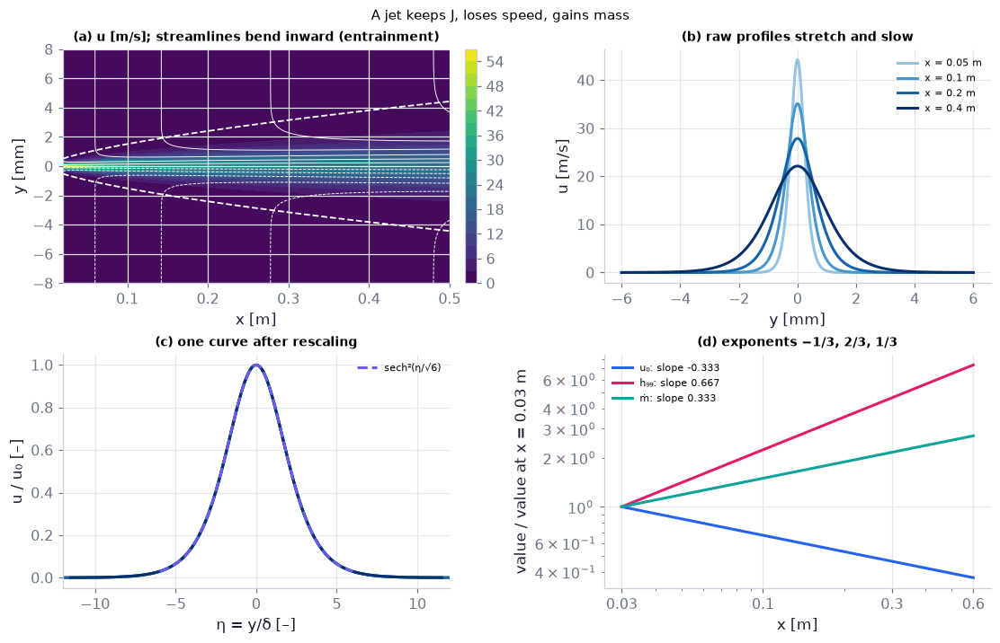

In [103]:
n_ = 200 if not FAST else 100
Xg, Yg = np.meshgrid(np.linspace(0.02, 0.5, n_), np.linspace(-8e-3, 8e-3, n_))       # x [m], y [m] (y stretched on the plot)
fj = JET.free_jet(Xg, Yg, 1.0, RHO_AIR, NU_AIR)                    # u, psi on the grid
fig, axs = plt.subplots(2, 2, figsize=(10, 6.4)); (a1, a2), (a3, a4) = axs   # the figure and its panels
cf = a1.contourf(Xg, 1e3*Yg, fj["u"], 20, cmap="viridis"); a1.contour(Xg, 1e3*Yg, fj["psi"], 14, colors="white", linewidths=0.6)   # (a) u and streamlines
xe = np.linspace(0.02, 0.5, 100); h99 = 1e3*JET.free_jet_halfwidth(xe, 1.0, RHO_AIR, NU_AIR)   # sample points
a1.plot(xe, h99, "--", color="w", lw=1.2); a1.plot(xe, -h99, "--", color="w", lw=1.2)   # draw the curve(s)
a1.set_xlabel("x [m]"); a1.set_ylabel("y [mm]"); a1.set_title("(a) u [m/s]; streamlines bend inward (entrainment)", fontsize=9); fig.colorbar(cf, ax=a1, pad=0.01)   # axis labels (with units), limits and the panel's message
for xi, col in zip(xj, plt.cm.Blues(np.linspace(0.4, 1.0, 4))):     # (b) raw profiles, (c) collapse
    d_ = JET.free_jet_thickness(xi, 1.0, RHO_AIR, NU_AIR); yy = np.linspace(-6e-3, 6e-3, 600); pj = JET.free_jet(xi, yy, 1.0, RHO_AIR, NU_AIR)   # sample points
    a2.plot(1e3*yy, pj["u"], color=col, lw=2, label=f"x = {xi} m"); a3.plot(pj["eta"], pj["u"]/pj["u0"], color=col, lw=2)   # draw the curve(s)
a2.set_xlabel("y [mm]"); a2.set_ylabel("u [m/s]"); a2.legend(fontsize=7, frameon=False); a2.set_title("(b) raw profiles stretch and slow", fontsize=9)   # axis labels (with units), limits and the panel's message
ee = np.linspace(-6, 6, 200); a3.plot(ee, 1/np.cosh(ee/np.sqrt(6))**2, "--", color=COLORS["accent"], lw=2, label="sech²(η/√6)")   # draw the curve(s)
a3.set_xlim(-12, 12); a3.set_xlabel("η = y/δ [–]"); a3.set_ylabel("u / u₀ [–]"); a3.legend(fontsize=7, frameon=False); a3.set_title("(c) one curve after rescaling", fontsize=9)   # axis labels (with units), limits and the panel's message
xl = np.geomspace(0.03, 0.6, 30); u0l = JET.free_jet_centreline(xl, 1.0, RHO_AIR, NU_AIR); hl = JET.free_jet_halfwidth(xl, 1.0, RHO_AIR, NU_AIR); ml = JET.free_jet_mass_flux(xl, 1.0, RHO_AIR, NU_AIR)   # sample points
for arr, lab, col in ((u0l, "u₀", COLORS["blue"]), (hl, "h₉₉", COLORS["rose"]), (ml, "ṁ", COLORS["teal"])):   # (d) log-log with fitted slopes
    sl = np.polyfit(np.log(xl), np.log(arr), 1)[0]; a4.loglog(xl, arr/arr[0], color=col, lw=2, label=f"{lab}: slope {sl:.3f}")   # curve(s) on logarithmic axes
a4.xaxis.set_minor_formatter(plt.NullFormatter()); a4.set_xticks([0.03, 0.1, 0.3, 0.6]); a4.set_xticklabels(["0.03", "0.1", "0.3", "0.6"]); a4.set_xlabel("x [m]"); a4.set_ylabel("value / value at x = 0.03 m"); a4.legend(fontsize=7, frameon=False); a4.set_title("(d) exponents −1/3, 2/3, 1/3", fontsize=9)   # axis labels (with units), limits and the panel's message
fig.suptitle("A jet keeps J, loses speed, gains mass", fontsize=10)   # the figure's message as its title
plt.show()   # display the figure

**What you see.** A bright thin jet whose white streamlines bend toward the axis in (a); stretching, slowing profiles in (b) that collapse onto one dashed $\mathrm{sech}^2$ in (c); straight lines of slope $-\frac13$, $\frac23$, $\frac13$ in (d).

**How to read it.** The vertical axis of (a) is stretched about a hundredfold, so the nearly sideways inflow of the entrained fluid looks steep; the area under $u^2$ is the same at every $x$; the area under $u$ grows. In (d) the slopes, fitted with `np.polyfit` (a straight line through log y against log x), are the exponents of D16: $u_0\propto x^{-1/3}$, $h_{99}\propto x^{2/3}$, $\dot m\propto x^{1/3}$.

**What would change if…** …doubling $J$: $u_0\times1.59$, $\delta\times0.79$, $\dot m\times1.26$ ($2^{2/3}$, $2^{-1/3}$, $2^{1/3}$).

In [104]:
xsl = np.geomspace(0.03, 0.6, 25 if not FAST else 12)              # stations [m]
yj = np.linspace(-6e-3, 6e-3, 150)   # sample points


def frame(x_):                                                     # the jet profile at one station
    pj = JET.free_jet(x_, yj, 1.0, RHO_AIR, NU_AIR); p0 = JET.free_jet(0.03, yj, 1.0, RHO_AIR, NU_AIR)
    h = 1e3*JET.free_jet_halfwidth(x_, 1.0, RHO_AIR, NU_AIR)
    return {"u(y) at x": (1e3*yj, pj["u"]), "profile at x = 0.03 m": (1e3*yj, p0["u"]), "±h₉₉": ([-h, h], [0.01*pj["u0"][0]]*2)}   # the values for this call


fig = slider_figure(frame, "x", xsl, unit="m", xlabel="y [mm]", ylabel="u [m/s]", title="", xrange=[-6, 6], yrange=[0, 62], modes={"±h₉₉": "markers"})   # one figure whose curves follow the slider; every position precomputed (P17)
step_titles(fig, [f"x = {x_:.3f} m: u₀ = {JET.free_jet_centreline(x_, 1.0, RHO_AIR, NU_AIR):.1f} m/s, δ = {1e3*JET.free_jet_thickness(x_, 1.0, RHO_AIR, NU_AIR):.3f} mm, ṁ = {JET.free_jet_mass_flux(x_, 1.0, RHO_AIR, NU_AIR):.4f} kg/(m s) (u₀ ∝ x^(−1/3), δ ∝ x^(2/3), ṁ ∝ x^(1/3))" for x_ in xsl])   # a title with numbers for every slider position
recolor(fig, {"u(y) at x": COLORS["blue"], "profile at x = 0.03 m": COLORS["muted"], "±h₉₉": COLORS["rose"]}, dashes={"profile at x = 0.03 m": "dash"})   # colours by meaning
fig.show()                                                         # drag x downstream: the jet slows and widens, its area under u² stays

**What to try:** drag $x$ downstream — the blue profile lowers and widens (the grey ghost is the profile at $x=0.03$ m), the rose markers (1 % points) move out like $x^{2/3}$, yet the area under $u^2$ is unchanged.

#### 🎮 Interactive: A jet keeps its momentum, spreads and slows — where does the extra mass come from?

**Why interactive rather than a static figure:** Moving $x$ and $J$ changes $u_0$, $\delta$ and $\dot m$ together while the momentum-flux integral stays fixed; entrainment arrows lengthen toward the axis; static profiles hide the invariant.

**What to try:**
- Drag $x$ from 0.05 to 0.6 m: read the slopes −1/3, 2/3, 1/3.
- Change the half-width level from 1 % to 4 %: which coefficient does the book's 5.6152 belong to?
- Click a point in the jet: $v$ and $u$ with the arithmetic.
- Open Derivation D16 and watch the powers of $x$ cancel.

In [105]:
show_viz("ch09", "free_jet_similarity")   # full-width explainer; ⤢ Full screen for more room

[explainer ch09/free_jet_similarity]

**What would change if…** …a wall is added under the jet? Friction removes momentum flux, so $J$ is no longer conserved; a subtler invariant appears (C13).

> 🔁 **Recap — Wall conditions of the wall jet** (§9.1, R04 R05). $u=v=0$ on $y=0$, $x>0$ *(9.77)*: no slip $u(x,0)=0$ *(9.12)* and no through-flow $v(x,0)=0$ *(9.13)* again.

> 🔁 **Recap — Far-field condition** (§9.1, §9.10). $u(x,y)\to0$ as $y\to\infty$ *(9.78)*: the still ambient fluid, the one-sided version of $u=0$ for $y\to\pm\infty$ *(9.53)* and of $u\to U_e$ *(9.14)* with $U_e=0$.

### 🧩 The wall jet: a hidden invariant, the ODE $4f'''+ff''+2f'^2=0$ and the implicit solution `C13`

*The question:* In a wall jet the wall eats momentum — so what is conserved, and why does the jet spread as $x^{3/4}$ instead of $x^{2/3}$?

*In one line:* $\frac d{dx}\int_0^\infty u\Big(\int_y^\infty u^2dy'\Big)dy=0$ *(9.80)* · $-\ln(1-g)+\sqrt3\tan^{-1}\frac{2g+1}{\sqrt3}+\ln(1+g+g^2)^{1/2}=\frac{f_\infty}4\eta+\sqrt3\tan^{-1}\frac1{\sqrt3},\quad g=\sqrt{f/f_\infty}$ *(9.83)*

#### The problem in plain words

A jet of air runs along a ceiling; a pressure-washer's spray slides along a wall; a cooling jet hugs a turbine blade. Near the wall the fluid sticks (a boundary layer); far from it the fluid moves like a free jet. Because the wall pulls back, the jet's ordinary momentum flux
$\rho\int u^2dy$ *decreases* downstream. Yet there is still a conserved quantity, and it fixes how the jet spreads.

#### The idea

```
slot ═►  free-jet-like outer part ─────────►       ordinary momentum flux ∫u²dy  ↓ (wall shear)
═══════ wall ═══ inner boundary layer, u = 0 at y = 0    but  ∫₀^∞ u ( ∫_y^∞ u² dy′ ) dy  = constant
```

The wall removes momentum, but the *moment* of the momentum flux about the wall survives — a flux of the exterior momentum flux.

📝 **Note.** **N114 [B]** **Laminar wall jet (Glauert 1956).** A slot along a plane wall; near the wall a boundary layer, far away a free jet; $p\approx$ const; *(6.2)*, $\frac{\partial u}{\partial x}+\frac{\partial v}{\partial y}=0$ and *(9.18)*, $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=\nu\frac{\partial^2u}{\partial y^2}$ again, with the conditions $u=v=0$ on $y=0$ *(9.77)* and $u\to0$ as $y\to\infty$ *(9.78)* (the two recaps above).

> 📎 **Primer — integration by parts with a variable lower limit.** `P218` · *Recap:* integration by parts, $\int a\,b'=[ab]-\int a'\,b$, was primed before D06 (P218a). The new twist here is a factor defined by an integral with a variable lower limit:
$\int_0^\infty u(y)G(y)\,dy$ with $G(y)=\int_y^\infty g\,dy'$ can be integrated by parts: $G'=-g$, so $\int_0^\infty uG\,dy=[WG]_0^\infty+\int_0^\infty Wg\,dy$ with $W=\int_0^yu$. Differentiating a double integral with respect to $x$ adds only the
$x$-derivative under the integral signs, since the limits $0,\infty,y$ do not depend on $x$.

In [106]:
import numpy as np   # arrays and maths
from scipy.integrate import quad   # a tool used below
G = lambda y: np.exp(-2*y)/2                       # G(y) = int_y^inf u^2 dy for u = exp(-y)
print(quad(lambda y: np.exp(-y)*G(y), 0, np.inf)[0])                 # 0.16667: int u G dy
print(quad(lambda y: (1 - np.exp(-y))*np.exp(-2*y), 0, np.inf)[0])   # 0.16667 again: by parts, W = int_0^y u = 1 - exp(-y) times u^2

0.16666666666666233
0.1666666666666666


> 🔁 **Tools from earlier chapters used here** (see `knowledge/primers.md`) — used in D21 and N123

- **free scale f → λf(λη) and the gauge C f_∞²** — if f(η) solves an ODE whose every term has the same total weight, so does λf(λη) — the Töpfer scaling of C04 (P207); with homogeneous conditions the scale is free and only a combination of constants is physical.

#### 🧮 Derivation — The wall-jet invariant: $\frac d{dx}\int_0^\infty u\Big(\int_y^\infty u^2dy'\Big)dy=0$, hence $x\,u_0^2=$ const `D19` (Eq. 9.80: $\frac d{dx}\int_0^\infty u\Big(\int_y^\infty u^2dy'\Big)dy=0$)

**What we want to show.** Find the quantity a wall jet conserves, now that the wall removes ordinary momentum flux.

**Assumptions.** dp/dx = 0; no slip and no through-flow at the wall; u decays fast enough at infinity (exponentially, D21 step 13).

**The plan.**

1. Integrate (9.18), $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=\nu\frac{\partial^2u}{\partial y^2}$ from y to ∞ so the viscous term becomes a stress.
2. Multiply by u and integrate again.
3. Use continuity and integration by parts to turn the result into a total derivative.

**Tools we use** (each explained before this point): integration by parts with a variable lower limit (primer P218) · fundamental theorem of calculus (ch02 P84) · product rule (ch01 P38) · differentiation under the integral sign (ch03 P109).

**We start from**

$$ \begin{array}{l}\text{(9.18)}\ u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=\nu\frac{\partial^2u}{\partial y^2}\ \text{, (6.2),}\ u=v=0\ \text{on y = 0 (9.77) and}\ u\to0 \\ \text{as y → ∞ (9.78)}\end{array} $$

*In words:* the book gives four displayed integrals; we fill every move.

---

**Step 1 of 13 — Collect the equations.**

$$ uu_x+vu_y=\nu u_{yy},\quad u_x+v_y=0,\quad u=v=0\ (y=0),\ u\to0\ (y\to\infty) $$

- *Why we can do this:* These are the layer equation (9.18), $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=\nu\frac{\partial^2u}{\partial y^2}$, continuity (6.2), $\frac{\partial u}{\partial x}+\frac{\partial v}{\partial y}=0$ and the wall and far-field conditions (9.77), $u=v=0\ \text{on}\ y=0,\ x>0$, (9.78), $u\to0\ \text{as}\ y\to\infty$; we collect them because every later step uses one of them.
- *In words:* the whole problem.

---

**Step 2 of 13 — Integrate (9.18) from y to ∞.**

$$ \int_y^\infty(uu_x+vu_y)\,dy'=-\nu\,u_y(y) $$

- *Why we can do this:* Fundamental theorem: ν[u_y]_y^∞ = −νu_y(y) since u_y → 0 at infinity.
- *In words:* the viscous term becomes a stress at height y.

---

**Step 3 of 13 — Write uu_x as a derivative.**

$$ \frac\partial{\partial x}\int_y^\infty\frac{u^2}2\,dy'+\int_y^\infty vu_y\,dy'=-\nu u_y $$

- *Why we can do this:* uu_x = ∂(u²/2)/∂x; the limits y, ∞ do not depend on x, so ∂/∂x passes outside.
- *In words:* a flux term and a cross-flow term.

---

**Step 4 of 13 — Multiply by u and integrate over the wall layer.**

$$ T_1+T_2=-\nu\int_0^\infty uu_y\,dy\ \text{, with}\ T_1=\int_0^\infty u\,\frac\partial{\partial x}\Big(\int_y^\infty\frac{u^2}2dy'\Big)dy,\ T_2=\int_0^\infty u\Big(\int_y^\infty vu_y\,dy'\Big)dy $$

- *Why we can do this:* The equation of step 3 holds at every y; multiplying by u and integrating over 0…∞ keeps it true.
- *In words:* two double integrals.

---

**Step 5 of 13 — Evaluate the right side.**

$$ -\nu\int_0^\infty uu_y\,dy=-\frac\nu2\big[u^2\big]_0^\infty=0 $$

- *Why we can do this:* uu_y = ∂(u²/2)/∂y; u = 0 at the wall (9.77), $u=v=0\ \text{on}\ y=0,\ x>0$ and at infinity (9.78), $u\to0\ \text{as}\ y\to\infty$.
- *In words:* friction drops out entirely.

---

**Step 6 of 13 — Rewrite vu_y with continuity.**

$$ vu_y=\frac{\partial(uv)}{\partial y}-uv_y=\frac{\partial(uv)}{\partial y}+uu_x $$

- *Why we can do this:* Product rule backwards, then v_y = −u_x from (6.2), $\frac{\partial u}{\partial x}+\frac{\partial v}{\partial y}=0$.
- *In words:* a derivative plus a term we already have.

---

**Step 7 of 13 — Integrate the inner integral of T₂.**

$$ \int_y^\infty vu_y\,dy'=-u\,v(y)+\frac\partial{\partial x}\int_y^\infty\frac{u^2}2dy' $$

- *Why we can do this:* Fundamental theorem on ∂(uv)/∂y gives [uv]_y^∞ = −u(y)v(y) (uv → 0 at infinity); the other piece is the flux term of step 3.
- *In words:* T₂ contains T₁'s integrand.

---

**Step 8 of 13 — Insert into T₂.**

$$ T_2=-\int_0^\infty u^2v\,dy+T_1 $$

- *Why we can do this:* Multiply step 7 by u and integrate over y.
- *In words:* T₂ = T₁ minus a cross-flow term.

---

**Step 9 of 13 — Use T₁ + T₂ = 0.**

$$ \int_0^\infty u\,\frac\partial{\partial x}\Big(\int_y^\infty u^2dy'\Big)dy-\int_0^\infty u^2v\,dy=0\ \text{(9.79)} $$

- *Why we can do this:* Steps 4–5 give T₁ + T₂ = 0; with T₂ = T₁ − ∫u²v dy (step 8) this is 2T₁ − ∫u²v dy = 0, and 2T₁ is the first integral above (the ½ of u²/2 is absorbed).
- *In words:* the book's (9.79), $\int_0^\infty u\frac\partial{\partial x}\Big(\int_y^\infty u^2dy'\Big)dy-\int_0^\infty u^2v\,dy=0$.

---

**Step 10 of 13 — Differentiate the double integral.**

$$ \frac d{dx}\int_0^\infty uG\,dy=\int_0^\infty u_xG\,dy+\int_0^\infty u\,G_x\,dy,\quad G(y)\equiv\int_y^\infty u^2dy' $$

- *Why we can do this:* Product rule under the integral sign (P109); limits 0, ∞ are constants.
- *In words:* two pieces.

---

**Step 11 of 13 — Transform the first piece.**

$$ \int_0^\infty u_xG\,dy=-\int_0^\infty v_yG\,dy=-\big[vG\big]_0^\infty+\int_0^\infty vG_y\,dy=-\int_0^\infty u^2v\,dy $$

- *Why we can do this:* u_x = −v_y (6.2), $\frac{\partial u}{\partial x}+\frac{\partial v}{\partial y}=0$; integrate by parts (P218): [vG]₀^∞ = 0 since v(0) = 0 (9.77), $u=v=0\ \text{on}\ y=0,\ x>0$ and G(∞) = 0; G_y = −u².
- *In words:* the cross-flow term of step 9.

---

**Step 12 of 13 — Add the pieces.**

$$ \frac d{dx}\int_0^\infty u\Big(\int_y^\infty u^2dy'\Big)dy=-\int_0^\infty u^2v\,dy+\int_0^\infty u\,G_x\,dy=0\ \text{(9.80)} $$

- *Why we can do this:* Step 11 for the first piece; the sum vanishes by (9.79), $\int_0^\infty u\frac\partial{\partial x}\Big(\int_y^\infty u^2dy'\Big)dy-\int_0^\infty u^2v\,dy=0$.
- *In words:* the flux of exterior momentum flux is conserved.

---

**Step 13 of 13 — Insert the similarity form.**

$$ \frac d{dx}\Big[u_0^3\,\frac{\nu x}{u_0}\int_0^\infty\Big(f'\int_\eta^\infty f'^2d\eta'\Big)d\eta\Big]=0\ \text{(9.81)}\ \Rightarrow\ xu_0^2=C^2,\ \ u_0=Cx^{-1/2} $$

- *Why we can do this:* With u = u₀f′(η), δ² = νx/u₀ (9.59): u∫u² dy′ = u₀³δ²·I = νxu₀²·I; the double integral I of f is a number, so x u₀² = C².
- *In words:* u₀ ∝ x^(−1/2).

---

**Result**

$$ \int_0^\infty u(\int_y^\infty u^2dy')dy\ \text{is independent of x and}\ xu_0^2=C^2 $$

*In words:* a conserved 'momentum flux of the momentum flux' fixes the exponent.

**What it means.** When the obvious invariant is lost to the wall, the next-order one survives; the exponent 3/4 (D20) follows.

**Check it.** Units: $u^3L^2=(\mathrm{m/s})^3\,\mathrm{m}^2=$ m⁵/s³ (Ψ, not a force per length). f_∞ = 1: the double integral is 1/40 (notebook, 1e-9); `JET.wall_jet_invariant` on the solution at four stations is constant (printed and asserted in the code cell of the wall-jet figure below) while ρ∫u²dy falls like x^(−1/4).

In [107]:
import sympy as sp                                               # symbolic algebra
import numpy as np                                               # numbers for the nested integrals
from scipy.integrate import quad                                 # numerical quadrature
x, y = sp.symbols('x y', positive=True)                          # streamwise and wall-normal coordinates
psi = x**sp.Rational(1, 4)*sp.exp(-y/x**sp.Rational(3, 4))*(1 - sp.exp(-y/x**sp.Rational(3, 4)))   # a smooth test stream function with psi = 0 on the wall
u, v = sp.diff(psi, y), -sp.diff(psi, x)                         # u = psi_y, v = -psi_x: continuity holds automatically
print(sp.simplify(sp.diff(u, x) + sp.diff(v, y)))                # 0: (6.2)
print(sp.simplify(v*sp.diff(u, y) - (sp.diff(u*v, y) + u*sp.diff(u, x))))   # 0: step 6, v u_y = d(uv)/dy + u u_x, using continuity
uf, uxf, vf = (sp.lambdify((x, y), e, "numpy") for e in (u, sp.diff(u, x), v))   # fast numerical versions of u, u_x, v
x0 = 1.3                                                         # a station
G = lambda yy: quad(lambda s: uf(x0, s)**2, yy, np.inf)[0]       # G(y) = int_y^inf u^2 dy'  (step 10)
lhs = quad(lambda yy: uxf(x0, yy)*G(yy), 0, np.inf)[0]           # int_0^inf u_x G dy
rhs = -quad(lambda yy: uf(x0, yy)**2*vf(x0, yy), 0, np.inf)[0]   # - int_0^inf u^2 v dy
print("step 11 (integration by parts, needs v(0) = 0 and G(inf) = 0):", lhs, rhs, abs(lhs - rhs))   # equal to 1e-15

0
0


step 11 (integration by parts, needs v(0) = 0 and G(inf) = 0): -0.00032051282051395405 -0.00032051282051281303 1.1410143663237449e-15


> ⚠️ **Common confusion (traps in `D19`):** The ordinary momentum flux is *not* conserved (wall shear); the boundary terms in steps 5, 7, 11 need the wall conditions and the decay at infinity; the factor 2 between T₁ and the integrand of (9.79), $\int_0^\infty u\frac\partial{\partial x}\Big(\int_y^\infty u^2dy'\Big)dy-\int_0^\infty u^2v\,dy=0$.

📝 **Note.** **N115–N119 [B]** **The stations of D19.** The chain: integrate *(9.18)*, $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=\nu\frac{\partial^2u}{\partial y^2}$ from $y$ to $\infty$, multiply by $u$, integrate over $y$ (N115); integration by parts of the inner integral gives
$\int_0^\infty u\frac\partial{\partial x}\big(\int_y^\infty u^2dy'\big)dy-\int_0^\infty u^2v\,dy=0$ *(9.79)*; the conserved quantity is $\frac d{dx}\int_0^\infty u\big(\int_y^\infty u^2dy'\big)dy=0$ *(9.80)* — the wall jet loses ordinary momentum flux to the wall but keeps this
"flux of exterior momentum flux"; inserting $u=u_0f'(\eta)$ turns *(9.80)* into $\frac d{dx}\big[u_0^3\frac{\nu x}{u_0}\int_0^\infty\big(f'\int_\eta^\infty f'^2d\eta'\big)d\eta\big]=0$ *(9.81)*; the double integral is a pure number, so $xu_0^2=C^2$, i.e. $u_0=Cx^{-1/2}$.
**Exponents.** $\psi=[\nu Cx^{1/2}]^{1/2}f(\eta)$, $\eta=y/\delta(x)$, $\delta=[\nu x^{3/2}/C]^{1/2}\propto x^{3/4}$ *(9.82)* — thicker than the free jet's $x^{2/3}$: the wall slows the fluid, so the layer must spread more.

#### 🧮 Derivation — Wall-jet reduction: $\psi=[\nu Cx^{1/2}]^{1/2}f(\eta)$ turns into $4f'''+ff''+2f'^2=0$ (the book prints coefficient 1) `D20` (Eq. 9.82: $\psi=[\nu Cx^{1/2}]^{1/2}f(\eta),\quad\eta=\frac y{\delta(x)},\quad\delta=\Big[\frac{\nu x^{3/2}}C\Big]^{1/2}$)

**What we want to show.** Derive the ODE of the wall jet, including the coefficient the book prints wrongly.

**Assumptions.** Boundary-layer equations, dp/dx = 0; u₀ = Cx^(−1/2) (D19).

**The plan.**

1. Write ψ in powers of x.
2. Differentiate four ways.
3. See the ηf′f″ terms cancel.
4. Compare coefficients.

**Tools we use** (each explained before this point): chain rule with x^(−3/4) in η (primer P206) · exponent rules (ch01 P43) · sympy (ch01 P40).

**We start from**

$$ \frac{\partial\psi}{\partial y}\frac\partial{\partial x}\Big(\frac{\partial\psi}{\partial y}\Big)-\frac{\partial\psi}{\partial x}\frac\partial{\partial y}\Big(\frac{\partial\psi}{\partial y}\Big)=\nu\frac{\partial^2}{\partial y^2}\Big(\frac{\partial\psi}{\partial y}\Big)\ \text{(9.65) with}\ u=\psi_y,\ v=-\psi_x,\ \text{and (9.59) with}\ u_0=Cx^{-1/2}\ \text{(D19)} $$

*In words:* the same algebra as D16 with different exponents.

---

**Step 1 of 12 — Write ψ in powers of x.**

$$ \psi=A\,x^{1/4}f(\eta),\ \ \eta=\frac y{Bx^{3/4}},\ \ A=\sqrt{\nu C},\ B=\sqrt{\nu/C}\ \text{(9.82)} $$

- *Why we can do this:* u₀δ = Cx^(−1/2)(νx^(3/2)/C)^(1/2): δ = (νx/u₀)^(1/2) = Bx^(3/4); note A/B = C, AB = ν.
- *In words:* pure powers of x again.

---

**Step 2 of 12 — Differentiate η.**

$$ \eta_x=-\frac{3\eta}{4x},\qquad\eta_y=\frac1{Bx^{3/4}} $$

- *Why we can do this:* Power rule on η = yB⁻¹x^(−3/4).
- *In words:* η moves as x^(−3/4).

---

**Step 3 of 12 — Compute u.**

$$ u=\frac AB\,x^{-1/2}f'=Cx^{-1/2}f'(\eta) $$

- *Why we can do this:* Chain rule: A x^(1/4)·1/(Bx^(3/4)); A/B = C.
- *In words:* u₀ = Cx^(−1/2), as D19 demanded.

---

**Step 4 of 12 — Compute v.**

$$ v=-\frac A4\,x^{-3/4}\big(f-3\eta f'\big) $$

- *Why we can do this:* v = −ψ_x by the product rule: −A[¼x^(−3/4)f + x^(1/4)f′η_x] with step 2.
- *In words:* cross-flow, ∝ x^(−3/4).

---

**Step 5 of 12 — Differentiate u in x.**

$$ u_x=Cx^{-3/2}\Big[-\frac{f'}2-\frac{3\eta f''}4\Big] $$

- *Why we can do this:* Product rule on x^(−1/2)f′(η) with η_x from step 2.
- *In words:* both the prefactor and η change.

---

**Step 6 of 12 — Differentiate u in y.**

$$ u_y=\frac C B\,x^{-5/4}f'',\qquad u_{yy}=\frac C{B^2}\,x^{-2}f'''=\frac{C^2}\nu x^{-2}f''' $$

- *Why we can do this:* Chain rule with η_y; 1/B² = C/ν.
- *In words:* the viscous term.

---

**Step 7 of 12 — Form uu_x.**

$$ uu_x=C^2x^{-2}f'\Big[-\frac{f'}2-\frac{3\eta f''}4\Big] $$

- *Why we can do this:* Multiply $u$ of step 3 by $u_x$ of step 5, term by term; the product is the first advective term of (9.18), $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=\nu\frac{\partial^2u}{\partial y^2}$.
- *In words:* f′² and ηf′f″.

---

**Step 8 of 12 — Form vu_y.**

$$ vu_y=-\frac{C^2}4\,x^{-2}\big[ff''-3\eta f'f''\big] $$

- *Why we can do this:* Multiply steps 4 and 6; AC/B = C².
- *In words:* ff″ and ηf′f″.

---

**Step 9 of 12 — Add them.**

$$ uu_x+vu_y=-\frac{C^2}4\,x^{-2}\big[2f'^2+ff''\big] $$

- *Why we can do this:* The ηf′f″ coefficients −¾ and +¾ cancel; the f′² coefficient is −½ = −2/4.
- *In words:* both sides scale as x^(−2).

---

**Step 10 of 12 — Form the viscous term.**

$$ \nu u_{yy}=C^2x^{-2}f''' $$

- *Why we can do this:* Step 6 gave $u_{yy}=C^2x^{-2}f'''/\nu$, and multiplying by $\nu$ removes the viscosity, leaving the same prefactor $C^2x^{-2}$ as the advective terms.
- *In words:* same prefactor C²x^(−2).

---

**Step 11 of 12 — Equate and compare coefficients.**

$$ -\frac14\big[2f'^2+ff''\big]=f'''\ \Rightarrow\ 4f'''+ff''+2f'^2=0 $$

- *Why we can do this:* Divide by C²x^(−2) (all powers of x cancel: the check that exponents 1/2 and 3/4 are right) and multiply by −4. The book prints $f'''+ff''+2f'^2=0$; the coefficient of $f'''$ is 4, as its own next line $4ff''-2f'^2+f^2f'=0$ requires.
- *In words:* the factor 4 matters.

---

**Step 12 of 12 — State the conditions.**

$$ f(0)=0,\quad f'(0)=0,\quad f'(\infty)=0 $$

- *Why we can do this:* (9.77): u = v = 0 at y = 0 gives f′(0) = 0 and f(0) = 0; (9.78), $u\to0\ \text{as}\ y\to\infty$: u → 0 far away. All three are homogeneous, so f has a free scale (D21).
- *In words:* no normalisation condition.

---

**Result**

$$ 4f'''+ff''+2f'^2=0\ \text{with}\ f(0)=f'(0)=f'(\infty)=0\ \text{; δ = (νx^\{3/2\}/C)^\{1/2\} ∝ x^\{3/4\}} $$

*In words:* thicker than the free jet (x^(2/3)).

**What it means.** The invariant and the ODE together fix exponents and profile; the wall jet spreads faster (3/4) than the free jet (2/3) because the wall slows the fluid.

**Check it.** sympy: substituting ψ leaves residual −(C²/4x²)(4f‴ + ff″ + 2f′²); the printed coefficient leaves the extra −(3/4)C²f‴/x². `JET.wall_jet_ode_solve(coeff=1.0)` ends at f_∞ = 0.397 instead of 1 for the same f″(0) — the printed ODE fails the (9.83) relation.

In [108]:
import sympy as sp                                               # symbolic algebra
x, y, nu, C = sp.symbols('x y nu C', positive=True)              # positive symbols
f = sp.Function('f')                                             # the similarity function
A, B = sp.sqrt(nu*C), sp.sqrt(nu/C)                              # step 1: psi = A x^(1/4) f(eta), eta = y/(B x^(3/4)); A B = nu, A/B = C
eta = y/(B*x**sp.Rational(3, 4))                                 # the similarity variable
psi = A*x**sp.Rational(1, 4)*f(eta)                              # the stream function (9.82)
u, v = sp.diff(psi, y), -sp.diff(psi, x)                         # u = psi_y, v = -psi_x
res = u*sp.diff(u, x) + v*sp.diff(u, y) - nu*sp.diff(u, y, 2)    # residual of (9.18)
E = sp.Symbol('E', positive=True)                                # a symbol for eta after differentiating
expr = (res*4*x**2/C**2).subs(y, E*B*x**sp.Rational(3, 4)).doit()   # divide by C^2/(4 x^2) and write y through eta = E
print(sp.simplify(expr))                                         # minus (4 f''' + f f'' + 2 f'^2): all powers of x have cancelled
ode = 4*f(E).diff(E, 3) + f(E)*f(E).diff(E, 2) + 2*f(E).diff(E)**2   # the correct reduced ODE (coefficient 4)
printed = f(E).diff(E, 3) + f(E)*f(E).diff(E, 2) + 2*f(E).diff(E)**2   # the printed one (coefficient 1)
print("correct ODE, leftover:", sp.simplify(expr + ode))         # 0
print("printed ODE, leftover:", sp.simplify(expr + printed))     # -3 f''': the printed coefficient leaves a residual

-f(E)*Derivative(f(E), (E, 2)) - 2*Derivative(f(E), E)**2 - 4*Derivative(f(E), (E, 3))
correct ODE, leftover: 0
printed ODE, leftover: -3*Derivative(f(E), (E, 3))


> ⚠️ **Common confusion (traps in `D20`):** The coefficient 4 (not 1); differentiating η with x^(−3/4); the y-dependence must cancel: only the x-powers may cancel, not the f-terms.

📝 **Note.** **N120 [B]** > ⚠️ **The book prints the reduced equation as $f'''+ff''+2f'^2=0$. The correct one is $4f'''+ff''+2f'^2=0$.**
> $$\text{printed:}\ f'''+ff''+2f'^2=0\qquad\text{correct:}\ 4f'''+ff''+2f'^2=0$$
> sympy (the check cell above) leaves the residual $-\frac{C^2}{4x^2}(4f'''+ff''+2f'^2)$; the printed coefficient leaves an extra $-\frac34C^2f'''/x^2$. The book's own next line, $4ff''-2f'^2+f^2f'=0$, needs the 4. The wall conditions are $f(0)=0$, $f'(0)=0$ and $f'(\infty)=0$.

In [109]:
print("correct ODE:", ch09.similarity_reduce_sympy("wall_jet")["ode"])                    # 4 f''' + f f'' + 2 f'^2 = 0
print("printed ODE residual:", ch09.similarity_reduce_sympy("wall_jet", printed=True)["residual"])   # -3 C^2 f'''/(4 x^2): non-zero

correct ODE: Eq(F0*F2 + 2*F1**2 + 4*F3, 0)
printed ODE residual: -3*C**2*F3/(4*x**2)


**What does the code above do?**

The library engine repeats D20 twice: with the correct coefficient the residual of *(9.18)*, $u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=\nu\frac{\partial^2u}{\partial y^2}$ is zero; with the printed coefficient 1 it leaves $-\frac34C^2f'''/x^2$, i.e. the printed equation is not the reduction of *(9.18)*.

> 📎 **Primer — partial fractions and sympy apart; inverting an implicit solution.** `P219` · A rational function such as $1/(1-g^3)$ is split into simple pieces that can be integrated (partial fractions); `sympy.apart` does it. When an integral gives $\eta$ as an explicit function of $g$ ($\eta(g)$) but we want $g(\eta)$, invert numerically:
for each $\eta$, `brentq` finds the $g$ with $\eta(g)-\eta=0$.

In [110]:
import sympy as sp   # symbolic algebra
from scipy.optimize import brentq   # a tool used below
g = sp.symbols('g')   # symbols for sympy
print(sp.apart(1/(1 - g**3), g))                        # 1/(3*(1 - g)) + (g + 2)/(3*(g**2 + g + 1))
print(brentq(lambda t: t**3 + t - 2, 0, 2))             # 1.0: invert t^3 + t = 2 numerically

(g + 2)/(3*(g**2 + g + 1)) - 1/(3*(g - 1))
1.0


#### 🧮 Derivation — Wall-jet integration: $4ff''-2f'^2+f^2f'=0$, $f^{-1/2}f'+\frac{f^{3/2}}6=\frac{f_\infty^{3/2}}6$, the implicit solution and $f''(0)=f_\infty^3/72$ `D21` (Eq. 9.83: $-\ln(1-g)+\sqrt3\tan^{-1}\frac{2g+1}{\sqrt3}+\ln(1+g+g^2)^{1/2}=\frac{f_\infty}4\eta+\sqrt3\tan^{-1}\frac1{\sqrt3},\quad g=\sqrt{f/f_\infty}$)

**What we want to show.** Integrate the wall-jet ODE in closed form, including the constants the book leaves out.

**Assumptions.** f > 0 for η > 0; f → f_∞ (finite) at infinity.

**The plan.**

1. Multiply by f and spot total derivatives.
2. Divide by f^(3/2) and integrate again.
3. Separate variables with g² = f/f_∞ and use partial fractions.
4. Read off f″
5. and the free scale.

**Tools we use** (each explained before this point): the total-derivative move (primer P216) · partial fractions, `apart` and implicit inversion (primer P219) · exponent rules (ch01 P43) · scaling symmetry (primer P207) · sympy (ch01 P40).

**We start from**

$$ 4f'''+ff''+2f'^2=0\ \text{(D20) with}\ f(0)=f'(0)=0\ \text{,}\ f'(\infty)=0 $$

*In words:* three integrations' worth of structure, if we find the right integrating factors.

---

**Step 1 of 15 — Restate the problem.**

$$ 4f'''+ff''+2f'^2=0,\quad f(0)=f'(0)=0,\ f'(\infty)=0 $$

- *Why we can do this:* The result of D20 (coefficient 4).
- *In words:* what we integrate.

---

**Step 2 of 15 — Multiply by f.**

$$ 4ff'''+f^2f''+2ff'^2=0 $$

- *Why we can do this:* An integrating factor: we hope the result is a sum of total derivatives.
- *In words:* every term has one more f.

---

**Step 3 of 15 — Spot the derivatives.**

$$ 4ff'''=4(ff'')'-2(f'^2)',\qquad f^2f''+2ff'^2=(f^2f')' $$

- *Why we can do this:* Product rule backwards (P216): (ff″)′ = f′f″ + ff‴ and (f′²)′ = 2f′f″, so 4ff‴ = 4(ff″)′ − 4f′f″ = 4(ff″)′ − 2(f′²)′; and (f²f′)′ = 2ff′² + f²f″.
- *In words:* everything is a derivative.

---

**Step 4 of 15 — Integrate once.**

$$ 4ff''-2f'^2+f^2f'=0 $$

- *Why we can do this:* The constant is zero because f = f′ = 0 at η = 0 (the book evaluates it at η = 0).
- *In words:* a second-order equation.

---

**Step 5 of 15 — Divide by $4f^{3/2}$.**

$$ f^{-1/2}f''-\tfrac12f^{-3/2}f'^2+\tfrac14f^{1/2}f'=0 $$

- *Why we can do this:* A second integrating factor; f > 0 for η > 0.
- *In words:* again look for derivatives.

---

**Step 6 of 15 — Recognise them.**

$$ \Big(f^{-1/2}f'+\tfrac16f^{3/2}\Big)'=0 $$

- *Why we can do this:* (f^(−1/2)f′)′ = f^(−1/2)f″ − ½f^(−3/2)f′², and (f^(3/2)/6)′ = ¼f^(1/2)f′.
- *In words:* another total derivative.

---

**Step 7 of 15 — Integrate.**

$$ f^{-1/2}f'+\tfrac16f^{3/2}=\tfrac16f_\infty^{3/2} $$

- *Why we can do this:* As η → ∞, f′ → 0 (faster than f^(1/2)) and f → f_∞, which fixes the constant.
- *In words:* a first-order equation.

---

**Step 8 of 15 — Solve for f′ and separate variables.**

$$ \frac{df}{f_\infty^{3/2}f^{1/2}-f^2}=\frac{d\eta}6 $$

- *Why we can do this:* f′ = f^(1/2)(f_∞^(3/2) − f^(3/2))/6 and f^(1/2)f^(3/2) = f². The book prints $\int\frac{df}{f_\infty^{3/2}f-f^2}=\frac16\int d\eta$, with $f$ in place of $f^{1/2}$ in the first term of the denominator.
- *In words:* an integrable equation.

---

**Step 9 of 15 — Substitute g² = f/f_∞.**

$$ f=f_\infty g^2\ \Rightarrow\ \frac{dg}{1-g^3}=\frac{f_\infty}{12}\,d\eta $$

- *Why we can do this:* df = 2f_∞g dg, f^(1/2) = f_∞^(1/2)g, f^(3/2) = f_∞^(3/2)g³ turn the left side into 2dg/(f_∞(1 − g³)).
- *In words:* g runs from 0 to 1.

---

**Step 10 of 15 — Split into partial fractions.**

$$ \frac1{1-g^3}=\frac13\Big[\frac1{1-g}+\frac{g+2}{1+g+g^2}\Big] $$

- *Why we can do this:* 1 − g³ = (1 − g)(1 + g + g²); putting the right side over the common denominator gives 1 (sympy `apart`, P219).
- *In words:* two simple integrals.

---

**Step 11 of 15 — Integrate.**

$$ \tfrac13\Big[-\ln(1-g)+\tfrac12\ln(1+g+g^2)+\sqrt3\tan^{-1}\tfrac{2g+1}{\sqrt3}\Big]=\tfrac{f_\infty}{12}\eta+c $$

- *Why we can do this:* ∫dg/(1 − g) = −ln(1 − g) and (g + 2)/(1 + g + g²) = ½(2g + 1)/(1 + g + g²) + (3/2)/(1 + g + g²), whose integrals are ½ln(1 + g + g²) and √3 arctan((2g + 1)/√3).
- *In words:* logs and an arctangent.

---

**Step 12 of 15 — Fix the constant.**

$$ -\ln(1-g)+\sqrt3\tan^{-1}\frac{2g+1}{\sqrt3}+\ln(1+g+g^2)^{1/2}=\frac{f_\infty}4\eta+\sqrt3\tan^{-1}\frac1{\sqrt3}\ \text{(9.83)} $$

- *Why we can do this:* Multiply by 3; g(0) = 0 sets c so that the right side carries √3 arctan(1/√3) = √3π/6. To get g(η) invert numerically with `brentq` (P219).
- *In words:* left-implicit closed form.

---

**Step 13 of 15 — Read the far field.**

$$ 1-g\approx\sqrt3\,e^{\sqrt3\pi/6}\,e^{-f_\infty\eta/4}=4.29\,e^{-f_\infty\eta/4} $$

- *Why we can do this:* As g → 1 the −ln(1 − g) term dominates; solve for 1 − g with the constants of step 12 (√3π/6 − √3π/3 − ½ln3). The book omits the factor 4.29 (its far-field statement is $1-g\propto e^{-f_\infty\eta/4}$ without it).
- *In words:* exponential decay with rate f_∞/4.

---

**Step 14 of 15 — Find f″(0).**

$$ \sqrt{2f''(0)}=\frac{f_\infty^{3/2}}6\ \Rightarrow\ f''(0)=\frac{f_\infty^3}{72} $$

- *Why we can do this:* Step 7 at η → 0: f ≈ ½f″(0)η² and f′ ≈ f″(0)η, so f^(−1/2)f′ → √(2f″(0)) while the f^(3/2) term vanishes.
- *In words:* f_∞ is tied to the initial curvature.

---

**Step 15 of 15 — Identify the free scale.**

$$ f\to\lambda f(\lambda\eta):\ \ f_\infty\to\lambda f_\infty,\ \ C\to C/\lambda^2 $$

- *Why we can do this:* Every term of 4f‴ + ff″ + 2f′² scales like λ⁴ (D06 step 1) and the conditions are homogeneous, so f_∞ is not fixed by the problem; the physical constant is C f_∞².
- *In words:* f_∞ is a gauge; only C f_∞² matters.

---

**Result**

$$ \begin{array}{l}f^{-1/2}f'+\frac16f^{3/2}=\frac16f_\infty^{3/2}\ \Rightarrow\ \text{implicit solution (9.83)} \\ f''(0)=\frac{f_\infty^3}{72},\qquad f'\approx2.14f_\infty^2e^{-f_\infty\eta/4}\ \text{far out},\qquad f_\infty\ \text{a free scale}\end{array} $$

*In words:* a closed-form wall-jet profile with one gauge freedom.

**What it means.** Together with D19–D20: u₀ ∝ x^(−1/2), δ ∝ x^(3/4), ṁ ∝ x^(1/4); one physical parameter (Ψ ~ ṁ⁴/x).

**Check it.** f_∞ = 1: an IVP from f″(0) = 1/72 ends at f_∞ = 1.000000, satisfies (9.83), $-\ln(1-g)+\sqrt3\tan^{-1}\frac{2g+1}{\sqrt3}+\ln(1+g+g^2)^{1/2}=\frac{f_\infty}4\eta+\sqrt3\tan^{-1}\frac1{\sqrt3},\quad g=\sqrt{f/f_\infty}$ to 1e-11 at η = 2, 5, 10, 20; ∫f′ = 1, ∫f′² = 1/18, ∫f′∫f′² = 1/40; peak f′ = 0.0787 at η = 8.11; 4.29 confirmed numerically (4.2896).

In [111]:
import sympy as sp                                               # symbolic algebra
g = sp.symbols('g', positive=True)                               # g = sqrt(f / f_inf), 0 < g < 1
print(sp.simplify(sp.apart(1/(1 - g**3), g) - sp.Rational(1, 3)*(1/(1 - g) + (g + 2)/(1 + g + g**2))))   # 0: step 10, the partial fractions
eta_of_g = 4*(-sp.log(1 - g) + sp.sqrt(3)*sp.atan((2*g + 1)/sp.sqrt(3)) + sp.log(1 + g + g**2)/2 - sp.sqrt(3)*sp.atan(1/sp.sqrt(3)))   # (9.83) solved for eta, f_inf = 1
print(sp.simplify(sp.diff(eta_of_g, g) - 12/(1 - g**3)))         # 0: d(eta)/dg = 12/(f_inf (1 - g^3)) from step 9
e = sp.symbols('e'); f = sp.Function('f')                        # check the first integrals against the ODE
first = 4*f(e)*f(e).diff(e, 2) - 2*f(e).diff(e)**2 + f(e)**2*f(e).diff(e)   # step 4: 4 f f'' - 2 f'^2 + f^2 f'
print(sp.simplify(first.diff(e) - f(e)*(4*f(e).diff(e, 3) + f(e)*f(e).diff(e, 2) + 2*f(e).diff(e)**2)))   # 0: its derivative is f times the ODE
second = f(e)**sp.Rational(-1, 2)*f(e).diff(e) + f(e)**sp.Rational(3, 2)/6                # step 6: f^(-1/2) f' + f^(3/2)/6
print(sp.simplify(4*f(e)**sp.Rational(3, 2)*second.diff(e) - first))   # 0: dividing 'first' by 4 f^(3/2) gives the derivative of 'second' (steps 5-6)
s, finf = sp.symbols('s f_inf', positive=True)                   # s = f''(0)
print(sp.solve(sp.sqrt(2*s) - finf**sp.Rational(3, 2)/6, s))     # step 14: f''(0) = f_inf^3/72

0


0
0
0
[f_inf**3/72]


> ⚠️ **Common confusion (traps in `D21`):** f^(1/2), not f, in the separated integral; arctan branch and the constant √3π/6; g(0) = 0 fixes c; the free scale means f_∞ and C are not both determined by data.

📝 **Note.** **N121 [B]** > ⚠️ **The book's separation of variables reads $\int\frac{df}{f_\infty^{3/2}f-f^2}=\frac16\int d\eta$; the correct integrand is $\frac1{f_\infty^{3/2}f^{1/2}-f^2}$** (from $f'=f^{1/2}(f_\infty^{3/2}-f^{3/2})/6$).
> $$\text{printed:}\ \int\frac{df}{f_\infty^{3/2}f-f^2}=\frac16\int d\eta\qquad\text{correct:}\ \int\frac{df}{f_\infty^{3/2}f^{1/2}-f^2}=\frac16\int d\eta$$
> The far-field statement $1-g\approx e^{-f_\infty\eta/4}$ also omits the factor $4.29=\sqrt3\,e^{\sqrt3\pi/6}$. The first integrals are $4ff''-2f'^2+f^2f'=0$ and $f^{-1/2}f'+\frac{f^{3/2}}6=\frac{f_\infty^{3/2}}6$.

📝 **Note.** **N122 [B]** **Entrainment.** $\dot m=\int_0^\infty\rho u\,dy=\rho u_0\delta\int f'd\eta=\rho\sqrt{\nu C}\,f_\infty x^{1/4}$ *(9.84)*: $\propto x^{1/4}$, less than the free jet's $x^{1/3}$ — the wall entrains from one side only.

$$ \dot m=\int_0^\infty\rho u\,dy=\rho\sqrt{\nu C}\,f_\infty x^{1/4} \qquad \text{(9.84)} $$

📝 **Note.** **N123 [B]** **The constants (9.85).** $u_0^2(x)\,\nu x\int_0^\infty\big(f'\int_\eta^\infty f'^2d\eta'\big)d\eta=C^2\nu\int_0^\infty\big(f'\int_\eta^\infty f'^2d\eta'\big)d\eta=\Psi$: the invariant fixes $C$; $\dot m$ at one $x$ fixes $f_\infty$.
**Our reading:** because $f'(0)=0$ (unlike the free jet's $f'(0)=1$) the ODE has a free scale, $f\to\lambda f(\lambda\eta)$, which sends $C\to C/\lambda^2$ and $f_\infty\to\lambda f_\infty$; the only physical constant is the combination $Cf_\infty^2$.
With the gauge $f_\infty=1$ the invariant integral is 1/40 (in general $f_\infty^4/40$) and $\Psi=\dot m^4/(40\rho^4\nu x)$ — so $\Psi$ and $\dot m$ are the same datum, not two.

> ⚠️ **Common confusion (units of $\Psi$).** The book reads $\Psi$ like a force per length; it has the units of $u^3L^2$, **m⁵/s³** — not N/m.

$$ \Psi=C^2\nu\int_0^\infty\Big(f'\int_\eta^\infty f'^2d\eta'\Big)d\eta \qquad \text{(9.85)} $$

📝 **Note.** **N124 [B]** **Wall-jet entrainment velocity and the profile.** The cross-flow is $v=-\partial\psi/\partial x=-\frac{\sqrt{\nu C}}{4x^{3/4}}\,(f-3\eta f')$, which tends to $-\frac{\sqrt{\nu C}\,f_\infty}{4x^{3/4}}$ far above the jet: the ambient fluid flows *toward* the jet.
The profile $f'(\eta)$ starts at zero on the wall, peaks near $\eta=8$ (for $f_\infty=1$) and decays exponentially; the figure below draws $f$ and $f'$.

#### ✏️ Tiny example: a wall jet in air, gauge f_∞ = 1

For $f_\infty=1$ the IVP from $f''(0)=f_\infty^3/72=1/72=0.013889$ gives $\int f'd\eta=1$, $\int f'^2d\eta=1/18=0.0556$ and $\int f'\int_\eta^\infty f'^2=1/40=0.025$; the profile peaks at $f'=0.0787$ at $\eta=8.11$. If $\dot m(1\,\mathrm m)=0.05$ kg/(m s) in air:
$\sqrt{\nu C}=\dot m/(\rho f_\infty x^{1/4})=0.04167$, $C=115.7$ m$^{3/2}$/s, so $u_0(1\,\mathrm m)=115.7$ m/s, the peak speed $u_0f'_{max}=9.11$ m/s, $\delta=(\nu x^{3/2}/C)^{1/2}=0.360$ mm and the peak sits at $y=8.11\,\delta=2.9$ mm. At 4 m: $\dot m$ ×$\sqrt2$ = 0.0707,
the peak speed ×½ = 4.56 m/s and $\delta$ × $4^{3/4}$ = 2.83.

In [112]:
sol = JET.wall_jet_ode_solve(fpp0=1/72)              # IVP from f''(0) = f_inf^3/72 with f_inf = 1 (the 1/72 of D21)
i_pk = int(np.argmax(sol["fp"]))
print("f_inf =", round(sol["f_inf"], 8), "| error vs (9.83):", sol["err_vs_9_83"], "| f''(0)/f_inf^3 =", sol["fpp0_over_finf_cubed"], 1/72)   # print the result
print("peak f' =", round(float(sol["fp"].max()), 6), "at eta =", round(float(sol["eta"][i_pk]), 2))   # print the result
print("integrals (int f', int f'^2, invariant, f''(0)):", JET.wall_jet_integrals(1.0))   # 1, 1/18, 1/40, 1/72
bad = JET.wall_jet_ode_solve(fpp0=1/72, coeff=1.0)  # the PRINTED ODE (coefficient 1) with the same f''(0)
print("printed ODE ends at f_inf =", round(bad["f_inf"], 3), "| misses (9.83) by", round(bad["err_vs_9_83"], 3))   # print the result
print("f'(2, 8, 20) =", JET.wall_jet_profile(np.array([2.0, 8.0, 20.0]), f_inf=1.0)["fp"])   # the implicit solution (9.83) inverted by brentq
c13 = JET.wall_jet_constants(RHO_AIR, NU_AIR, mdot=0.05, x=1.0, f_inf=1.0)                    # one physical datum: mdot at one x
print({k_: (float(v_) if v_ is not None else None) for k_, v_ in c13.items()})   # print the result

f_inf = 1.0 | error vs (9.83): 6.520011093524847e-12 | f''(0)/f_inf^3 = 0.013888888888937946 0.013888888888888888
peak f' = 0.078745 at eta = 8.1
integrals (int f', int f'^2, invariant, f''(0)): {'int_fp': 1.0, 'int_fp2': 0.05555555555555555, 'invariant': 0.025, 'fpp0': 0.013888888888888888}
printed ODE ends at f_inf = 0.397 | misses (9.83) by 0.309
f'(2, 8, 20) = [0.0276 0.0787 0.0133]
{'C': 115.74074074074076, 'C_f_inf_sq': 115.74074074074076, 'Psi': 0.005023469650205763, 'mdot_at_x': 0.05, 'residual': None}


**What does the code above do?**

1. The initial-value problem from $f''(0)=1/72$ lands on $f_\infty=1.000000$ *without being told* — the relation $f''(0)=f_\infty^3/72$ of D21 — and satisfies the implicit solution *(9.83)*, $-\ln(1-g)+\sqrt3\tan^{-1}\frac{2g+1}{\sqrt3}+\ln(1+g+g^2)^{1/2}=\frac{f_\infty}4\eta+\sqrt3\tan^{-1}\frac1{\sqrt3},\quad g=\sqrt{f/f_\infty}$ to $10^{-11}$; $f'$ peaks at 0.0787 near $\eta=8.1$.
2. The closed forms of the three integrals follow from the scaling: $\int f'=f_\infty$, $\int f'^2=f_\infty^3/18$, invariant $f_\infty^4/40$.
3. The printed ODE (coefficient 1) with the same $f''(0)$ ends at $f_\infty=0.397$ instead of 1 and misses *(9.83)* by 0.3.
4. `wall_jet_profile` inverts *(9.83)* by `brentq`; `wall_jet_constants` shows $\Psi$ and $\dot m$ are one datum: $C=115.7$ m$^{3/2}$/s and $\Psi=5.0\times10^{-3}$ m⁵/s³ from $\dot m=0.05$ kg/(m s) at 1 m.

In [113]:
# from scratch: solve_ivp of 4 f''' + f f'' + 2 f'^2 = 0 from f''(0) = f_inf^3/72 for f_inf = 1 and 2; check (9.83) at eta = 2, 5, 10 with a hand-written brentq inverse
def wall_rhs(e, Y): return [Y[1], Y[2], -(Y[0]*Y[2] + 2*Y[1]**2)/4]   # a small helper used below
def eta_of_g(g, finf):                                            # (9.83) solved for eta as a function of g = sqrt(f/f_inf)
    return 4/finf*(-np.log(1 - g) + np.sqrt(3)*np.arctan((2*g + 1)/np.sqrt(3)) + 0.5*np.log(1 + g + g*g) - np.sqrt(3)*np.pi/6)   # the values for this call
runs = {}
for finf in (1.0, 2.0):   # loop over the cases
    runs[finf] = integrate.solve_ivp(wall_rhs, [0, 120/finf], [0, 0, finf**3/72], method="DOP853", rtol=1e-12, atol=1e-14, dense_output=True)
    assert np.isclose(runs[finf].y[0, -1], finf, rtol=1e-8)       # f -> f_inf without being told
    for e_ in (2.0, 5.0, 10.0):   # loop over the cases
        g_ = optimize.brentq(lambda g: eta_of_g(g, finf) - e_, 1e-12, 1 - 1e-12)    # invert the implicit relation
        assert np.isclose(finf*g_**2, runs[finf].sol(e_)[0], rtol=1e-7)             # f = f_inf g^2 agrees with the IVP
ee = np.linspace(0, 10, 50)   # sample points
assert np.allclose(runs[2.0].sol(ee)[0], 2*runs[1.0].sol(2*ee)[0], rtol=1e-6, atol=1e-9)   # scaling: f_2(eta) = 2 f_1(2 eta)
print("IVP endpoints:", runs[1.0].y[0, -1], runs[2.0].y[0, -1], "| scaling f_2(eta) = 2 f_1(2 eta) holds")   # print the result

IVP endpoints: 0.9999999999988226 1.9999999999980322 | scaling f_2(eta) = 2 f_1(2 eta) holds


**What does the code above do?**

1. `solve_ivp` integrates the corrected wall-jet ODE $4f'''+ff''+2f'^2=0$ from the wall with $f''(0)=f_\infty^3/72$, for $f_\infty=1$ and 2, and the assert checks that $f$ lands on $f_\infty$ without being told.
2. `eta_of_g` is the implicit solution *(9.83)*, $-\ln(1-g)+\sqrt3\tan^{-1}\frac{2g+1}{\sqrt3}+\ln(1+g+g^2)^{1/2}=\frac{f_\infty}4\eta+\sqrt3\tan^{-1}\frac1{\sqrt3},\quad g=\sqrt{f/f_\infty}$ written out; `brentq` inverts it at $\eta=2,5,10$ and the result is compared with the IVP.
3. The last assert checks the free scale: $f_2(\eta)=2f_1(2\eta)$.

x = 0.1 m: rho int u^2 dy = 2.0000e+00 N/m   int u (int u^2) dy = 2.667669e-02 m^5/s^3
x = 0.2 m: rho int u^2 dy = 1.6818e+00 N/m   int u (int u^2) dy = 2.667669e-02 m^5/s^3
x = 0.4 m: rho int u^2 dy = 1.4142e+00 N/m   int u (int u^2) dy = 2.667669e-02 m^5/s^3
x = 0.8 m: rho int u^2 dy = 1.1892e+00 N/m   int u (int u^2) dy = 2.667669e-02 m^5/s^3


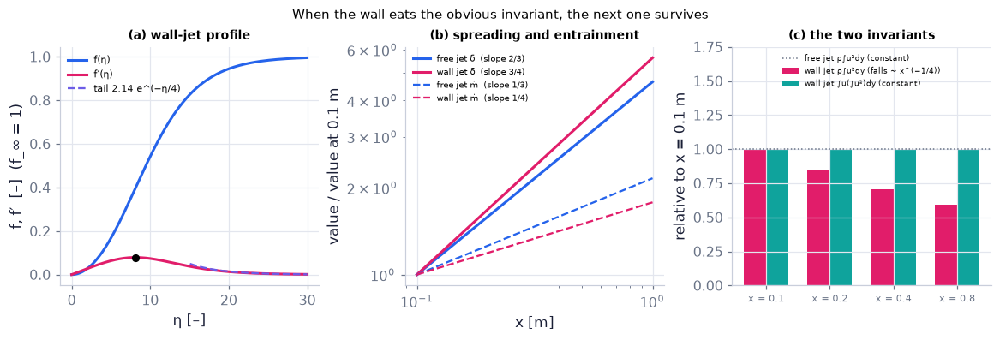

In [114]:
mdot_ref = JET.free_jet_mass_flux(0.1, 1.0, RHO_AIR, NU_AIR)      # give both jets the same mass flux at x = 0.1 m
Cw = JET.wall_jet_constants(RHO_AIR, NU_AIR, mdot=mdot_ref, x=0.1, f_inf=1.0)["C"]   # wall-jet constant C [m^(3/2)/s] (gauge f_inf = 1)
def delta_w(x_): return np.sqrt(NU_AIR*x_**1.5/Cw)               # delta = (nu x^(3/2)/C)^(1/2)  (9.82)
xs4 = (0.1, 0.2, 0.4, 0.8); w_mom, w_inv = [], []
for x_ in xs4:                                                    # (c) the two invariants at four stations
    yy = np.linspace(0, 60*delta_w(x_), 6001); wj = JET.wall_jet(x_, yy, Cw, 1.0, NU_AIR, RHO_AIR)["u"]   # sample points
    w_mom.append(JET.jet_momentum_flux(yy, wj, RHO_AIR)); w_inv.append(JET.wall_jet_invariant(yy, wj))   # store the value for the plot
for x_, mo_, iv_ in zip(xs4, w_mom, w_inv):                      # D19's check: the invariant (9.80) is constant, the momentum flux is not
    print(f"x = {x_:.1f} m: rho int u^2 dy = {mo_:.4e} N/m   int u (int u^2) dy = {iv_:.6e} m^5/s^3")   # print the result
assert np.allclose(w_inv, w_inv[0], rtol=1e-6)                   # (9.80): the same value at all four stations
assert np.allclose(np.array(w_mom)/w_mom[0], (np.array(xs4)/xs4[0])**-0.25, rtol=1e-4)   # rho int u^2 dy falls like x^(-1/4)
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(10.5, 3.5))   # the figure and its panels
et = sol["eta"]; m_ = et <= 30
a1.plot(et[m_], sol["f"][m_], color=COLORS["blue"], lw=2, label="f(η)"); a1.plot(et[m_], sol["fp"][m_], color=COLORS["rose"], lw=2, label="f′(η)")   # (a)
tail = (et > 15) & (et <= 30); a1.plot(et[tail], 2.14*np.exp(-et[tail]/4), "--", color=COLORS["accent"], lw=1.5, label="tail 2.14 e^(−η/4)")   # draw the curve(s)
a1.plot(et[i_pk], sol["fp"][i_pk], "ko", ms=5); a1.set_xlabel("η [–]"); a1.set_ylabel("f, f′  [–]  (f_∞ = 1)"); a1.legend(fontsize=7, frameon=False); a1.set_title("(a) wall-jet profile", fontsize=9)   # axis labels (with units), limits and the panel's message
xl = np.geomspace(0.1, 1.0, 20)                                   # (b) growth laws, both jets normalised at x = 0.1 m
a2.loglog(xl, JET.free_jet_thickness(xl, 1.0, RHO_AIR, NU_AIR)/JET.free_jet_thickness(0.1, 1.0, RHO_AIR, NU_AIR), color=COLORS["blue"], lw=2, label="free jet δ  (slope 2/3)")   # curve(s) on logarithmic axes
a2.loglog(xl, delta_w(xl)/delta_w(0.1), color=COLORS["rose"], lw=2, label="wall jet δ  (slope 3/4)")   # curve(s) on logarithmic axes
a2.loglog(xl, JET.free_jet_mass_flux(xl, 1.0, RHO_AIR, NU_AIR)/mdot_ref, "--", color=COLORS["blue"], lw=1.5, label="free jet ṁ  (slope 1/3)")   # curve(s) on logarithmic axes
a2.loglog(xl, JET.wall_jet_mass_flux(xl, Cw, 1.0, RHO_AIR, NU_AIR)/mdot_ref, "--", color=COLORS["rose"], lw=1.5, label="wall jet ṁ  (slope 1/4)")   # curve(s) on logarithmic axes
a2.set_xlabel("x [m]"); a2.set_ylabel("value / value at 0.1 m"); a2.legend(fontsize=6.5, frameon=False); a2.set_title("(b) spreading and entrainment", fontsize=9)   # axis labels (with units), limits and the panel's message
w = 0.35; ix = np.arange(4)   # sample points
a3.bar(ix - w/2, np.array(w_mom)/w_mom[0], w, color=COLORS["rose"], label="wall jet ρ∫u²dy (falls ~ x^(−1/4))")   # bars
a3.bar(ix + w/2, np.array(w_inv)/w_inv[0], w, color=COLORS["teal"], label="wall jet ∫u(∫u²)dy (constant)")   # bars
a3.axhline(1, color=COLORS["muted"], lw=1, ls=":", label="free jet ρ∫u²dy (constant)")   # a reference line or band
a3.set_xticks(ix); a3.set_xticklabels([f"x = {x_}" for x_ in xs4], fontsize=7); a3.set_ylabel("relative to x = 0.1 m"); a3.set_ylim(0, 1.75); a3.legend(fontsize=6, frameon=False, loc="upper center"); a3.set_title("(c) the two invariants", fontsize=9)   # axis labels (with units), limits and the panel's message
fig.suptitle("When the wall eats the obvious invariant, the next one survives", fontsize=10)   # the figure's message as its title
plt.show()   # display the figure

**What you see.** A bell-shaped $f'$ (rose) rising from zero at the wall to a peak near $\eta=8$ and an exponential tail in (a); the wall jet's straight lines are steeper than the free jet's for $\delta$ but shallower for $\dot m$ in (b); a falling rose bar next to a flat teal one in (c).

**How to read it.** Wall jet: $\rho\int u^2dy$ decays like $x^{-1/4}$ while the double integral is constant; in (b) the slopes $\frac34$ versus $\frac23$ (thickness) and $\frac14$ versus $\frac13$ (entrainment) are the exponents of D19–D21.

**What would change if…** …$f_\infty$ doubled: $C$ quarters (gauge freedom), but every dimensional profile stays put — only $Cf_\infty^2$ is physical.

In [115]:
nfr = 30 if not FAST else 16
xa = np.geomspace(0.05, 0.8, nfr)                                  # stations swept downstream [m]
xg = np.geomspace(0.03, 0.8, 100)   # sample points
hf = 1e3*JET.free_jet_halfwidth(xg, 1.0, RHO_AIR, NU_AIR)          # free-jet 1 % half-width [mm]
eta_edge = float(np.interp(0.01*sol["fp"].max(), sol["fp"][i_pk:][::-1], sol["eta"][i_pk:][::-1]))   # wall jet: eta where u falls to 1 % of its peak
hw = 1e3*eta_edge*delta_w(xg)                                      # wall-jet edge height [mm]
fig, axs = plt.subplots(2, 2, figsize=(9.5, 5.2), layout="none"); fixed_layout(fig, left=0.08, bottom=0.10, top=0.92, wspace=0.28); fig.subplots_adjust(hspace=0.42)   # the figure and its panels
(a1, a2), (a3, a4) = axs
a1.plot(xg, hf, color=COLORS["blue"], lw=2); a1.plot(xg, -hf, color=COLORS["blue"], lw=2); m1, = a1.plot([], [], "|", color=COLORS["rose"], ms=40, mew=2)   # draw the curve(s)
a2.plot(xg, hw, color=COLORS["rose"], lw=2); m2, = a2.plot([], [], "|", color=COLORS["blue"], ms=40, mew=2); a2.axhline(0, color=COLORS["ink"], lw=3)   # a reference line or band
for a_, ttl in ((a1, "free jet: half-width ∝ x^(2/3)"), (a2, "wall jet: edge ∝ x^(3/4)")):   # loop over the cases
    a_.set_xlabel("x [m]"); a_.set_ylabel("y [mm]"); a_.set_title(ttl, fontsize=9)   # axis labels (with units), limits and the panel's message
a1.set_ylim(-1.1*hf.max(), 1.1*hf.max()); a2.set_ylim(-0.1*hw.max(), 1.1*hw.max())   # axis labels (with units), limits and the panel's message
yb = np.linspace(-1.1*hf.max()*1e-3, 1.1*hf.max()*1e-3, 400); l3, = a3.plot([], [], color=COLORS["blue"], lw=2)   # draw the curve(s)
yw = np.linspace(0, 1.1*hw.max()*1e-3, 400); l4, = a4.plot([], [], color=COLORS["rose"], lw=2)   # draw the curve(s)
a3.set_xlim(-1.1*hf.max(), 1.1*hf.max()); a3.set_ylim(0, 62); a3.set_xlabel("y [mm]"); a3.set_ylabel("u [m/s]")   # axis labels (with units), limits and the panel's message
a4.set_xlim(0, 1.1*hw.max()); a4.set_ylim(0, 1.05*JET.wall_jet(0.05, yw, Cw, 1.0, NU_AIR, RHO_AIR)["u"].max()); a4.set_xlabel("y [mm]"); a4.set_ylabel("u [m/s]")   # axis labels (with units), limits and the panel's message


def update(i):                                                      # frame i = station xa[i]
    xi = xa[i]
    m1.set_data([xi], [0.0]); m2.set_data([xi], [0.5*1e3*eta_edge*delta_w(xi)])
    l3.set_data(1e3*yb, JET.free_jet(xi, yb, 1.0, RHO_AIR, NU_AIR)["u"])
    l4.set_data(1e3*yw, JET.wall_jet(xi, yw, Cw, 1.0, NU_AIR, RHO_AIR)["u"])
    a3.set_title(f"x = {xi:.2f} m: ṁ = {JET.free_jet_mass_flux(xi, 1.0, RHO_AIR, NU_AIR):.4f} kg/(m s)", fontsize=9)   # axis labels (with units), limits and the panel's message
    a4.set_title(f"x = {xi:.2f} m: ṁ = {JET.wall_jet_mass_flux(xi, Cw, 1.0, RHO_AIR, NU_AIR):.4f} kg/(m s)", fontsize=9)   # axis labels (with units), limits and the panel's message
    return []   # the values for this call


show_animation(animate(update, frames=nfr, fig=fig, interval=110))   # smooth video

**What you see.** Two jets spreading side by side: the free jet's symmetric envelope and $\mathrm{sech}^2$ profile on the left, the wall jet's one-sided envelope and its peaked profile (zero at the wall) on the right, with the mass-flux counters in the titles.

**How to read it.** The wall jet's edge grows like $x^{3/4}$ (faster than the free jet's $x^{2/3}$) but its mass flux only like $x^{1/4}$ (slower than $x^{1/3}$): the wall slows the fluid and can entrain from one side only.

**What would change if…** …a different reference mass flux: every curve scales, but the exponents $\frac34,\frac14$ and $\frac23,\frac13$ do not change.

#### 🎮 Interactive: In a wall jet the wall eats momentum — what is conserved?

**Why interactive rather than a static figure:** In free-jet mode $\int u^2dy$ is constant with $x$; in wall-jet mode it decreases but the double integral remains constant — both bars at the same instant; the $f_\infty$ slider shows the scaling symmetry that makes $f_\infty$ free.

**What to try:**
- Switch between 'free' and 'wall': which bar stays flat?
- Move the $f_\infty$ slider: the dimensional profile does not change ($C$ compensates).
- Turn on 'ODE as printed' and read the residual.
- Compare $\delta\propto x^{3/4}$ with $x^{2/3}$.

In [116]:
show_viz("ch09", "wall_jet_invariant")   # full-width explainer; ⤢ Full screen for more room

[explainer ch09/wall_jet_invariant]

**What would change if…** …the jet were round, or turbulent? The same two lessons (constant momentum flux, growing mass flux) hold; only the exponents change (Ch. 12).

---

## 9.11 Secondary Flows

**What is this section about?** So far a boundary layer only slows the flow. When the streamlines outside the layer are curved, the layer does more: it creates a flow *across* the main flow. The teacup is the everyday example — stir it and the tea
leaves go to the middle, not to the rim. The same mechanism (a friction layer in a rotating fluid) makes the Ekman layers of the ocean and atmosphere in Ch. 13.

### 🧩 Secondary flow: the teacup `C14`

*The question:* Why do tea leaves collect at the centre when the water is spinning outward?

#### The problem in plain words

Stir tea and let it spin. The leaves pile up in the middle of the cup's floor. Spinning water is flung outward, so why do heavy leaves move inward? Because the water next to the floor is slowed by friction, but the pressure difference that holds the fast water
on its circle is not reduced. In the slow layer the pressure gradient wins: it pushes the water — and the leaves — inward.

#### The idea

```
axis                         free surface (slightly dipped: the pressure gradient ∂p/∂R = ρu²/R)
 │ ▲ up      ◄── out ──                 fast core: circular streamlines, ∂p/∂R = ρ u_e²/R
 │ │        ╱                            slowed floor layer: u < u_e, centrifugal ρu²/R too small
 │ │  in ───►  ●leaves  ─ floor layer ─   net force ρ(u_e² − u²)/R pointing inward
```

The water's speed changes across the layer, the pressure gradient does not.

> 🔁 **Tools from earlier chapters used here** (see `knowledge/primers.md`) — used in C14

- **centripetal acceleration** — a parcel on a circle of radius R at speed u accelerates toward the centre at u²/R, so it needs an inward force per volume ρu²/R (Ch. 4 §4.7).

> 📎 **Primer — radial force balance in a swirl (and a thin layer).** `P220` · A fluid parcel going round a circle of radius $R$ at speed $u$ needs an inward force per volume $\rho u^2/R$ (the centripetal acceleration, Ch. 4); in the fast core that is supplied by the pressure gradient, $\partial p/\partial R=\rho u_e^2/R$.
In a thin layer the pressure hardly changes across the layer ($\partial p/\partial z\approx0$, the boundary-layer argument $\frac{\partial p}{\partial y}=0$ *(9.10)* with $z$ for $y$), so the same $\partial p/\partial R$ acts on the slower fluid, which needs less: the surplus pushes it inward.

In [117]:
rho, ue, R = 1000.0, 0.2, 0.04          # water, core swirl 0.2 m/s, radius 4 cm
dpdR = rho*ue**2/R                       # 1000 N/m^3: the radial pressure gradient set by the core
for u in (0.2, 0.1, 0.0):                # core, half speed, on the floor
    print(u, dpdR - rho*u**2/R)          # net inward force per volume: 0, 750, 1000 N/m^3

0.2 0.0
0.1 750.0000000000001
0.0 1000.0000000000001


#### 🧮 Derivation — The teacup: net inward force per volume $\rho(u_e^2-u^2)/R$ in the slowed bottom layer `D22`

**What we want to show.** Show why a friction layer beneath a swirling fluid drives a flow toward the axis.

**Assumptions.** Thin layer; steady, axisymmetric swirl; u_φ(z) illustrative (no viscous solution here — Ch. 13).

**The plan.**

1. The pressure gradient set by the core.
2. It is the same inside a thin layer.
3. Compare it with what circular motion needs there.

**Tools we use** (each explained before this point): radial force balance in a swirl (primer P220) · the thin-layer argument ∂p/∂z ≈ 0 (as (9.10), $\frac{\partial p}{\partial y}=0$).

**We start from**

$$ \frac{\partial p}{\partial R}=\frac{\rho u_e^2}{R}\ \ \text{(radial balance of the swirling core at speed }u_e(R)\text{)} $$

*In words:* the book states the argument in words; we write the force balance.

---

**Step 1 of 7 — Balance in the inviscid core.**

$$ \frac{\partial p}{\partial R}=\frac{\rho u_e^2}{R} $$

- *Why we can do this:* A parcel on a circle of radius R needs the inward force ρu_e²/R (Ch. 4 centripetal acceleration); in the core only the pressure gradient supplies it.
- *In words:* pressure holds the fast water on its circle.

---

**Step 2 of 7 — Carry the pressure into the layer.**

$$ \frac{\partial p}{\partial z}\approx0\ \Rightarrow\ p(R,z)=p_e(R) $$

- *Why we can do this:* Thin-layer argument as (9.10), $\frac{\partial p}{\partial y}=0$: the pressure does not change across the layer, so the bottom layer feels the core's ∂p/∂R.
- *In words:* the layer inherits the pressure field.

---

**Step 3 of 7 — Write the net force per volume.**

$$ F_{in}=\frac{\partial p}{\partial R}-\frac{\rho u^2}R=\frac{\rho\,(u_e^2-u^2)}R $$

- *Why we can do this:* Force pushing inward minus the inward force a parcel of speed u needs (its centripetal requirement ρu²/R). Positive = net inward.
- *In words:* the surplus of pressure over need.

---

**Step 4 of 7 — Find the sign.**

$$ u<u_e\ \Rightarrow\ F_{in}>0 $$

- *Why we can do this:* Friction slows the water near the floor (no slip, u → 0); u_e² − u² > 0 there.
- *In words:* inward on the floor, zero in the core.

---

**Step 5 of 7 — Put numbers.**

$$ F_{in}(0)=\frac{\rho u_e^2}R=\frac{1000\times0.2^2}{0.04}=1000\ \mathrm{N/m^3}\approx0.10\,\rho g $$

- *Why we can do this:* Water, u_e = 0.2 m/s, R = 4 cm; the weight density is ρg = 9810 N/m³.
- *In words:* a small but unopposed push.

---

**Step 6 of 7 — Close the loop with continuity.**

$$ \text{inflow on the floor}\ \Rightarrow\ \text{up near the axis}\to\text{out at the top}\to\text{down the side wall} $$

- *Why we can do this:* Mass conservation (the axisymmetric form of (6.2), $\frac{\partial u}{\partial x}+\frac{\partial v}{\partial y}=0$): fluid moved inward must go somewhere; the side wall and free surface complete the meridional loop; leaves ride the floor inflow.
- *In words:* the leaves collect in the middle.

---

**Step 7 of 7 — State the limit and the hook.**

$$ u=u_e\ \Rightarrow\ F_{in}=0;\quad\delta_E\sim\sqrt{\nu/\Omega},\ \Omega=u_e/R $$

- *Why we can do this:* In the core pressure and centripetal need balance exactly; the layer depth follows from viscous diffusion over one rotation time (Ekman scale, Ch. 13: 0.45 mm here).
- *In words:* the same mechanism drives Ekman layers and spin-up.

---

**Result**

$$ F_{in}=\rho(u_e^2-u^2)/R>0\ \text{inside the friction layer, zero outside} $$

*In words:* a slowed layer under an unchanged pressure gradient is pushed toward the axis.

**What it means.** Secondary flows arise whenever a boundary layer sits under curved streamlines (river bends, Ekman layers, cyclone spin-up).

**Check it.** Units: (kg/m³)(m²/s²)/m = N/m³ ✓. u_e = 0.2, R = 0.04, ρ = 1000: F at u = 0, 0.5u_e, 0.75u_e, u_e = 1000, 750, 437.5, 0 N/m³ ✓ (`secondary_flow_radial_force`).

> ⚠️ **Common confusion (traps in `D22`):** The inward flow is *not* caused by centrifugal force alone; the pressure is set by the fast core; sign of F (inward positive); the layer profile used is illustrative, not a solution.

#### ✏️ Tiny example: water in a 4 cm-radius cup

$\rho=1000$ kg/m³, core swirl $u_e=0.2$ m/s, $R=4$ cm. The core needs $\rho u_e^2/R=1000$ N/m³. On the floor $u\to0$, so the net inward force is 1000 N/m³ = 10 % of the weight density $\rho g$ (9810 N/m³): small but unopposed by any centrifugal force;
at half speed 750, at $0.75u_e$ 437.5, at $u_e$ zero.

In [118]:
z = np.linspace(0, 5e-3, 101)                                      # heights above the floor [m]
u = ch09.secondary_flow_layer_profile(z, delta=1.5e-3, u_e=0.2, shape="exponential")   # ILLUSTRATIVE profile u_e (1 - exp(-z/delta)), not a solution
F = ch09.secondary_flow_radial_force(0.2, u, 0.04, 1000.0)         # net inward force per volume rho (u_e^2 - u^2)/R [N/m^3]
print("F at z = 0, 2.5 mm, 5 mm:", F[0], F[50], F[-1])             # 1000, 342, 70
z10 = z[np.argmax(F < 0.1*F[0])]; print("F falls to 10 % of its floor value at z =", 1e3*z10, "mm  (2.97 delta =", 2.97*1.5, "mm)")
print("on the floor exactly:", ch09.secondary_flow_radial_force(0.2, 0.0, 0.04, 1000.0), "N/m^3   ratio to rho g:", ch09.secondary_flow_radial_force(0.2, 0.0, 0.04, 1000.0)/(1000*9.81))   # print the result

F at z = 0, 2.5 mm, 5 mm: 1000.0000000000001 342.07721232787134 70.0753528931652
F falls to 10 % of its floor value at z = 4.500000000000001 mm  (2.97 delta = 4.455 mm)
on the floor exactly: 1000.0000000000001 N/m^3   ratio to rho g: 0.10193679918450561


**What does the code above do?**

1. The profile is *illustrative* (the docstring says so): $u=u_e(1-e^{-z/\delta})$ with $\delta=1.5$ mm — nothing here solves the layer equations.
2. `secondary_flow_radial_force` is $\rho(u_e^2-u^2)/R$: largest on the floor (1000 N/m³), 342 N/m³ at 2.5 mm, 70 N/m³ at 5 mm, zero in the core.
3. The force falls to 10 % of its floor value at $z=2.97\,\delta=4.5$ mm, and the floor value is about 10 % of the weight density $\rho g$.

In [119]:
# from scratch: the two-line balance and a sign test on the sample profile
rho_, ue_, R_ = 1000.0, 0.2, 0.04
dpdR_ = rho_*ue_**2/R_                                            # radial pressure gradient set by the core [N/m^3]
F_mine = dpdR_ - rho_*u**2/R_                                     # minus what circular motion at speed u would need
assert np.allclose(F_mine, F)                                     # the same numbers as the library
assert (F >= 0).all()                                             # net inward everywhere, zero only where u = u_e
print("F_mine[0] =", F_mine[0], "N/m^3")   # print the result

F_mine[0] = 1000.0000000000001 N/m^3


**What does the code above do?**

1. The core's radial pressure gradient $\rho u_e^2/R$ is computed once.
2. Subtracting what circular motion at the slower speed $u$ needs, $\rho u^2/R$, gives the net inward force per volume, compared with the library's `F`.
3. The second assert checks the sign: inward everywhere, zero only where $u=u_e$.

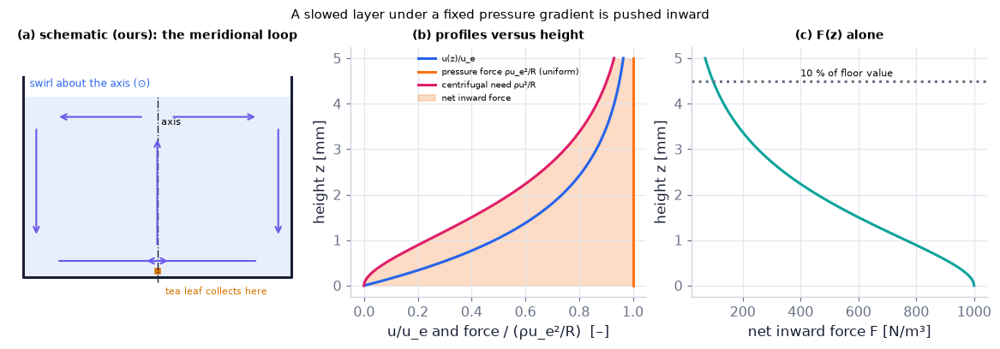

In [120]:
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(10.5, 3.6))   # the figure and its panels
cup_section(a1); a1.set_title("(a) schematic (ours): the meridional loop", fontsize=9)                       # the drawing helper (no physics)
a1.plot([0, 0], [-0.02, 0.9*0.8], ls="-.", color=COLORS["ink"], lw=0.9); a1.text(0.03, 0.76*0.8, "axis", fontsize=7)   # the cup's axis of rotation (R = 1, H = 0.8)
lp_ = dict(arrowstyle="->", color=COLORS["accent"], lw=1.4)       # mirror the loop on the left half: the flow is axisymmetric
a1.annotate("", xy=(0.1, 0.08*0.8), xytext=(-0.75, 0.08*0.8), arrowprops=lp_); a1.annotate("", xy=(-0.75, 0.8*0.8), xytext=(-0.1, 0.8*0.8), arrowprops=lp_)   # in along the floor, out along the top
a1.annotate("", xy=(-0.9, 0.2*0.8), xytext=(-0.9, 0.75*0.8), arrowprops=lp_)   # down the left side wall
for l_ in a1.lines:                                              # move the tea leaf (the small square) to the axis, where the floor inflow leaves it
    if l_.get_marker() == "s":
        l_.set_data([0.0], [0.03*0.8])
a1.text(0.06, -0.07, "tea leaf collects here", fontsize=7, color=COLORS["amber"])   # say what the square is
zz = 1e3*z
a2.plot(u/0.2, zz, color=COLORS["blue"], lw=2, label="u(z)/u_e"); a2.set_xlabel("u/u_e and force / (ρu_e²/R)  [–]"); a2.set_ylabel("height z [mm]")   # axis labels (with units), limits and the panel's message
a2.plot(np.ones_like(z), zz, color=COLORS["orange"], lw=2, label="pressure force ρu_e²/R (uniform)")                # the pressure gradient does not change across the layer
a2.plot((u/0.2)**2, zz, color=COLORS["rose"], lw=2, label="centrifugal need ρu²/R")                                 # what circular motion at the local speed requires
a2.fill_betweenx(zz, (u/0.2)**2, 1.0, color=COLORS["orange"], alpha=0.25, label="net inward force")   # shade the area between two curves
a2.legend(fontsize=6.5, frameon=False, loc="upper center"); a2.set_title("(b) profiles versus height", fontsize=9)   # axis labels (with units), limits and the panel's message
a3.plot(F, zz, color=COLORS["teal"], lw=2); a3.axhline(1e3*z10, color=COLORS["muted"], ls=":"); a3.text(400, 1e3*z10 + 0.1, "10 % of floor value", fontsize=7)   # a reference line or band
a3.set_xlabel("net inward force F [N/m³]"); a3.set_ylabel("height z [mm]"); a3.set_title("(c) F(z) alone", fontsize=9)   # axis labels (with units), limits and the panel's message
fig.suptitle("A slowed layer under a fixed pressure gradient is pushed inward", fontsize=10)   # the figure's message as its title
plt.show()   # display the figure

**What you see.** In (b) the orange line (the pressure force, uniform with height) and the rose curve (what circular motion needs, growing from zero at the floor to the core value) with the shaded wedge between them; the wedge vanishes at the top of the layer.

**How to read it.** The net force is 1000 N/m³ on the floor and 70 N/m³ at 5 mm; because it is largest where the water is slowest, the slow bottom water moves inward and the leaves go with it.

**What would change if…** …a thicker layer (viscous oil): the wedge is taller and the inflow reaches higher; a spinning-up cup ($u_e$ falling): the wedge shrinks.

**The Ekman hook (a preview — not in this chapter's book text).** The inflow speed follows from balancing this force with viscosity: the layer thickness is $\delta\sim\sqrt{\nu/\Omega}$ with $\Omega=u_e/R=5$ s⁻¹, and the water in the cup spins down (or up) in a time
$\sim H/\sqrt{\nu\Omega}$ — far faster than the pure-diffusion time $H^2/\nu$. This is the mechanism of spin-up and of the Ekman layers of the ocean and atmosphere (Ch. 13); a river bend (Exercise 9.28) has the same balance across the channel.

In [121]:
Om = 0.2/0.04                                                      # Omega = u_e / R [1/s]: the rotation rate of the core
nu_w, H = NU_W, 0.05                                               # water; a 5 cm deep cup
print("layer thickness sqrt(nu/Omega):", 1e3*np.sqrt(nu_w/Om), "mm")                    # 0.45 mm
print("spin-up time H/sqrt(nu Omega):", H/np.sqrt(nu_w*Om), "s   vs diffusion time H^2/nu:", H**2/nu_w, "s")   # 22 s vs 2500 s

layer thickness sqrt(nu/Omega): 0.4472135954999579 mm
spin-up time H/sqrt(nu Omega): 22.3606797749979 s   vs diffusion time H^2/nu: 2500.0000000000005 s


**What does the code above do?**

The Ekman scale $\sqrt{\nu/\Omega}=0.45$ mm sets the layer's depth (thinner than the illustrative 1.5 mm above), and the spin-up time $H/\sqrt{\nu\Omega}=22$ s is over a hundred times shorter than the diffusion time $H^2/\nu=2500$ s: the secondary flow, not viscosity alone, stirs the whole cup.

#### 🎮 Interactive: Why do tea leaves collect at the centre?

**Why interactive rather than a static figure:** Dragging the height $z$ shows the imbalance $\rho(u_e^2-u^2)/R$ growing toward the floor; changing the swirl profile shape or the layer thickness shows how the inflow depends on friction; a static picture cannot show the balance profile by profile.

**What to try:**
- Drag the height slider from the core to the floor.
- Change the profile shape and the layer thickness.
- Switch to 'river bend' mode: the same balance across a channel.
- Watch the force bars add to the net inward force.

In [122]:
show_viz("ch09", "teacup_secondary_flow")   # full-width explainer; ⤢ Full screen for more room

[explainer ch09/teacup_secondary_flow]

*↪ **S01 [SKIP]** The 28 exercises (plate in two orientations, RK solution of the Blasius equation, pipe entry length, Thwaites for a horn, a wavy wall, perpetual separation, a round jet, a river bend, …), the Literature Cited and the Supplemental Reading are not reproduced here; the exercises' numerical answers are computable from the functions above and are kept out of this repository. Chapter 10 solves the boundary-layer equations numerically.*

---

## ✅ What should have clicked

- **C01** Where advection and viscosity balance, the layer is $\bar\delta\sim L\,\mathrm{Re}^{-1/2}$ thick, and the equations $u\,u_x+v\,u_y=-\frac1\rho\frac{dp}{dx}+\nu u_{yy}$ *(9.9)* and $p_y=0$ *(9.10)* with the pressure from $-\frac1\rho\frac{dp}{dx}=U_e\frac{dU_e}{dx}$ *(9.11)* are all that is left.
- **C02** $\delta_{99}$, $\delta^*$ *(9.16)* and $\theta$ *(9.17)* are three integrals of one profile; $H=\delta^*/\theta$ tells how full it is.
- **C03** A plate has no length scale, so $\psi=U\delta(x)f(\eta)$ *(9.19)* turns the PDE into $f'''+\frac12ff''=0$ *(9.27)*.
- **C04** One shot with $f''(0)=1$ and a rescale gives $f''(0)=0.3321$; every Blasius number is an integral of that curve, e.g. $C_f=0.664/\sqrt{\mathrm{Re}_x}$ *(9.32)*.
- **C05** A power-law outer flow keeps the similarity form $f'''+\frac{n+1}2ff''-nf'^2+n=0$ *(9.36)*; $n$ is the dial from stagnation flow through Blasius to separation at $n=-0.0904$.
- **C06** Integrating the momentum equation across the layer gives $\frac1\rho\tau_0=\frac d{dx}[U_e^2\theta]+U_e\delta^*\frac{dU_e}{dx}$ *(9.43)*, exact for any layer, at the price of a closure.
- **C07** If shear and shape depend on $\lambda$ alone, *(9.43)* integrates to $\frac{\theta^2U_e^6}\nu=0.45\int_0^xU_e^5dx'+\dots$ *(9.50)* and separation is $\lambda$ crossing $-0.09$ (or $-0.0681$).
- **C08** At the wall $\mu u_{yy}=dp/dx$: an adverse gradient bends the profile, creates an inflection and drives $\tau_0$ to zero.
- **C09** Separation replaces the pressure recovery by a flat wake pressure: $C_{D,p}=\sin\varphi_s\big(1-\frac43\sin^2\varphi_s-C_b\big)$, so the drag falls when the base pressure rises ($C_b\to1$); at a fixed base pressure $C_b=-1.2$ later separation does not reduce it: $D(82^\circ)=0.884$, $D(90^\circ)=0.867$, $D(125^\circ)=1.07$.
- **C10** The wake of a cylinder sheds a street of alternating vortices, and only $b/a=0.2805$ ($\cosh\pi b/a=\sqrt2$) does not grow.
- **C11** A turbulent layer separates later (82° → 125°), the wake narrows and its pressure rises, so the drag falls — the higher wake pressure, not the later separation angle alone, does it; spin, seam and roughness decide which side of a ball is past the crisis.
- **C12** A free jet keeps $J=\rho\int u^2dy$, so $u_0\propto x^{-1/3}$, $\delta\propto x^{2/3}$, the profile is $u=u_0\,\mathrm{sech}^2(\eta/\sqrt6)$ *(9.71)*, and $\dot m\propto x^{1/3}$ *(9.73)* grows by entrainment.
- **C13** A wall jet loses ordinary momentum flux to the wall, but $\int u\big(\int_y^\infty u^2\big)dy$ *(9.80)* is invariant: $u_0\propto x^{-1/2}$, $\delta\propto x^{3/4}$, and $f_\infty^3=72f''(0)$.
- **C14** A friction layer under an unchanged pressure gradient is pushed inward, $F=\rho(u_e^2-u^2)/R$: the teacup, and the door to Ekman layers.

**What later chapters build on**

- Ch. 10: the marching solver and Blasius/Falkner–Skan as test problems; `BL` as the reference solution.
- Ch. 11: inflection points of *(9.52)*, $\Big(\frac{\partial^2u}{\partial y^2}\Big)_{wall}>0\quad(dp/dx>0)$ as the seat of shear instability, jet and wake profiles (sech²) as unstable shear flows, the Blasius profile for Orr–Sommerfeld and Tollmien–Schlichting waves.
- Ch. 12: the $\theta$, $H$, $C_f$ laws for turbulent layers, turbulent jets spreading ∝ x, the plate drag curve.
- Ch. 13: the Ekman layer from C14, stratified Kármán streets, spin-up.
- Ch. 14: separation and stall, $\theta$ for airfoils, Thwaites on an airfoil, the Blasius force theorem again.
- Ch. 15: compressible boundary layers.

**Not taught here (and where to find it)**
- Numerical solution of the layer equations (Ch. 10).
- The transition mechanism (Ch. 11).
- Turbulent layers and jets (Ch. 12).
- Ekman layers (Ch. 13).
- Thwaites' Table 9.1 (replaced here by our exact Falkner–Skan closure).
- All exercises (S01).